# Desafio

## Desenvolver um modelo de classificação capaz de identificar se uma review de produto é positiva ou negativa.

#### Dados do Kaggle - olistbr/brazilian-ecommerce

In [ ]:
# Configurar autenticação usando arquivo .json local
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install lime

In [ ]:
!pip install scikit-learn nltk spacy python-spacy-models[pt]

ERROR: Could not find a version that satisfies the requirement python-spacy-models[pt] (from versions: none)
ERROR: No matching distribution found for python-spacy-models[pt]


In [ ]:
!pip install shap

In [ ]:
# @title Bibliotecas necessárias
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import plotly.express as px
import scipy.stats as stats
import seaborn as sns
import lime.lime_text
import pandas as pd
import numpy as np
import kagglehub
import warnings
import joblib
import spacy
import lime
import nltk
import shap
import os
import re

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import NMF, LatentDirichletAllocation
from matplotlib.colors import LinearSegmentedColormap
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from nltk.stem import PorterStemmer, RSLPStemmer
from collections import defaultdict, Counter
from sklearn.pipeline import make_pipeline
from plotly.subplots import make_subplots
from matplotlib.gridspec import GridSpec
from nltk.tokenize import word_tokenize
from collections import defaultdict
from nltk.corpus import stopwords
from matplotlib import gridspec
from collections import Counter
from wordcloud import WordCloud
from textblob import TextBlob
from nltk.util import ngrams
from lime import lime_text

# Configurar caminho para o arquivo kaggle.json
KAGGLE_CONFIG = '/content/drive/MyDrive/kaggle.json'
os.environ['KAGGLE_CONFIG_DIR'] = os.path.dirname(KAGGLE_CONFIG)

# Baixar o conjunto de dados
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.


In [ ]:
# @title Carregar os arquivos principais
reviews_df = pd.read_csv(f"{path}/olist_order_reviews_dataset.csv")
orders_df = pd.read_csv(f"{path}/olist_orders_dataset.csv")
products_df = pd.read_csv(f"{path}/olist_products_dataset.csv")

# Exploração inicial dos dados

In [ ]:
# @title Verificando os nomes das colunas em reviews_df
print("Colunas disponíveis no DataFrame: reviews_df\n")
print(reviews_df.columns.tolist())

Colunas disponíveis no DataFrame: reviews_df

['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']


In [ ]:
# @title Verificando o conteúdo do reviews_df
print("Primeiras 5 linhas do dataset reviews_df:\n")
print(reviews_df.head())

Primeiras 5 linhas do dataset reviews_df:

                          review_id                          order_id  \
0  7bc2406110b926393aa56f80a40eba40  73fc7af87114b39712e6da79b0a377eb   
1  80e641a11e56f04c1ad469d5645fdfde  a548910a1c6147796b98fdf73dbeba33   
2  228ce5500dc1d8e020d8d1322874b6f0  f9e4b658b201a9f2ecdecbb34bed034b   
3  e64fb393e7b32834bb789ff8bb30750e  658677c97b385a9be170737859d3511b   
4  f7c4243c7fe1938f181bec41a392bdeb  8e6bfb81e283fa7e4f11123a3fb894f1   

   review_score review_comment_title  \
0             4                  NaN   
1             5                  NaN   
2             5                  NaN   
3             5                  NaN   
4             5                  NaN   

                              review_comment_message review_creation_date  \
0                                                NaN  2018-01-18 00:00:00   
1                                                NaN  2018-03-10 00:00:00   
2                                             

In [ ]:
# @title Verificando os tipos de informações contidos no reviews_df
print("\nInformações do dataset:\n")
reviews_df.info()


Informações do dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [ ]:
# @title Verificando os nomes das colunas em orders_df
print("Colunas disponíveis no DataFrame: orders_df")
print(orders_df.columns.tolist())

Colunas disponíveis no DataFrame: orders_df
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


In [ ]:
# @title Verificando os tipos de informações contidos no orders_df
print("\nInformações do dataset:\n")
orders_df.info()


Informações do dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [ ]:
# @title Verificando o conteúdo do orders_df
print("Primeiras 5 linhas do dataset orders_df:\n")
print(orders_df.head())

Primeiras 5 linhas do dataset orders_df:

                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1     

In [ ]:
# @title Verificando os nomes das colunas em products_df
print("Colunas disponíveis no DataFrame: products_df")
print(products_df.columns.tolist())

Colunas disponíveis no DataFrame: products_df
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']


In [ ]:
# @title Verificando os tipos de informações contidos no products_df
print("\nInformações do dataset:\n")
products_df.info()


Informações do dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [ ]:
# @title Verificando o conteúdo do products_df
print("Primeiras 5 linhas do dataset products_df:\n")
print(products_df.head())

Primeiras 5 linhas do dataset products_df:

                         product_id  product_category_name  \
0  1e9e8ef04dbcff4541ed26657ea517e5             perfumaria   
1  3aa071139cb16b67ca9e5dea641aaa2f                  artes   
2  96bd76ec8810374ed1b65e291975717f          esporte_lazer   
3  cef67bcfe19066a932b7673e239eb23d                  bebes   
4  9dc1a7de274444849c219cff195d0b71  utilidades_domesticas   

   product_name_lenght  product_description_lenght  product_photos_qty  \
0                 40.0                       287.0                 1.0   
1                 44.0                       276.0                 1.0   
2                 46.0                       250.0                 1.0   
3                 27.0                       261.0                 1.0   
4                 37.0                       402.0                 4.0   

   product_weight_g  product_length_cm  product_height_cm  product_width_cm  
0             225.0               16.0               10.0   

# Início das análises

In [ ]:
# @title Diagnóstico de Qualidade dos Dados - Verificação de Datas e Valores Nulos

print("🔍 INICIANDO DIAGNÓSTICO DE QUALIDADE DOS DADOS...")

# 1. Verificação completa dos tipos de dados
print(f"\n{'='*70}")
print("📊 VERIFICAÇÃO DOS TIPOS DE DADOS")
print(f"{'='*70}")

print("\n🔧 TIPOS DE DADOS DAS COLUNAS DE DATA:")
print("-" * 50)

# 1.1. Juntar os DataFrames
print("\n🔄 UNINDO DADOS DE PEDIDOS E REVIEWS...")

merged_df = pd.merge(reviews_df, orders_df, on='order_id', how='inner')

print(f"✅ DataFrames unidos com sucesso:")
print(f"   • Reviews originais: {len(reviews_df):,}")
print(f"   • Pedidos originais: {len(orders_df):,}")
print(f"   • Dados unidos: {len(merged_df):,} registros")

# CONVERSÃO DAS COLUNAS DE DATA PARA DATETIME (CORREÇÃO DO ERRO)
print("\n🔄 CONVERTENDO COLUNAS DE DATA PARA DATETIME...")
date_columns = ['order_delivered_customer_date', 'order_purchase_timestamp']

for col in date_columns:
    if col in merged_df.columns:
        # Converter para datetime, forçando erros para NaT (Not a Time)
        merged_df[col] = pd.to_datetime(merged_df[col], errors='coerce')
        print(f"   ✅ {col} convertida para datetime")

# Verificar os tipos de dados das colunas de data após conversão
date_dtypes = merged_df[date_columns].dtypes

for col in date_columns:
    dtype = date_dtypes[col]
    print(f"   • {col:35} → {dtype}")

    # Verificar se está no formato correto
    if 'datetime' in str(dtype):
        print(f"     ✅ Formato datetime correto")
    else:
        print(f"     ⚠️  Formato não ideal - considerar conversão para datetime")

# 2. Análise detalhada de valores nulos
print(f"\n{'='*70}")
print("⚠️  ANÁLISE DE VALORES NULOS")
print(f"{'='*70}")

print("\n🔍 VALORES NULOS NAS COLUNAS DE DATA:")
print("-" * 45)

# Verificar valores nulos (agora incluindo NaT da conversão)
null_analysis = merged_df[date_columns].isnull().sum()
total_records = len(merged_df)

for col in date_columns:
    null_count = null_analysis[col]
    null_percentage = (null_count / total_records) * 100

    print(f"   • {col:35} → {null_count:5,} nulos ({null_percentage:5.1f}%)")

    # Classificar a qualidade dos dados
    if null_count == 0:
        print(f"     ✅ Dados completos - excelente qualidade")
    elif null_percentage < 1:
        print(f"     ✅ Baixo índice de nulos - qualidade muito boa")
    elif null_percentage < 5:
        print(f"     ⚠️  Níveis aceitáveis de nulos - considerar imputação")
    elif null_percentage < 10:
        print(f"     🟡 Níveis moderados de nulos - atenção necessária")
    else:
        print(f"     🔴 Alta taxa de nulos - impacto significativo na análise")

# 3. Estatísticas adicionais de qualidade
print(f"\n{'='*70}")
print("📈 ESTATÍSTICAS DE QUALIDADE DOS DADOS")
print(f"{'='*70}")

print(f"\n📊 RESUMO GERAL DA QUALIDADE:")
print(f"   • Total de registros no dataset: {total_records:,}")
print(f"   • Registros completos (sem nulos): {merged_df[date_columns].notna().all(axis=1).sum():,}")
print(f"   • Taxa de completude geral: {(merged_df[date_columns].notna().all(axis=1).sum() / total_records * 100):.1f}%")

# 4. Análise temporal dos dados disponíveis (CÓDIGO CORRIGIDO)
print(f"\n📅 DISPONIBILIDADE TEMPORAL DOS DADOS:")
print("-" * 45)

# Verificar range temporal para dados não nulos
available_data = merged_df[date_columns].dropna()

if len(available_data) > 0:
    for col in date_columns:
        available_dates = available_data[col]
        print(f"   • {col:35}")

        # VERIFICAÇÃO DE SEGURANÇA ANTES DE USAR .strftime()
        if not available_dates.empty and pd.notna(available_dates.min()) and pd.notna(available_dates.max()):
            min_date = available_dates.min()
            max_date = available_dates.max()

            # Usar strftime apenas se for datetime
            if hasattr(min_date, 'strftime') and hasattr(max_date, 'strftime'):
                print(f"       - Período: {min_date.strftime('%d/%m/%Y')} a {max_date.strftime('%d/%m/%Y')}")
                print(f"       - Dias cobertos: {(max_date - min_date).days} dias")
            else:
                # Fallback: mostrar as datas sem formatação
                print(f"       - Período: {min_date} a {max_date}")
                print(f"       - Dias cobertos: não calculável")
        else:
            print(f"       - Período: Dados insuficientes")
            print(f"       - Dias cobertos: não calculável")

        print(f"       - Registros disponíveis: {available_dates.notna().sum():,}")
else:
    print("   ⚠️  Nenhum dado temporal disponível para análise")

# 5. Diagnóstico de problemas específicos
print(f"\n{'='*70}")
print("🔧 DIAGNÓSTICO DE PROBLEMAS ESPECÍFICOS")
print(f"{'='*70}")

# Verificar datas inconsistentes
print(f"\n📅 VERIFICAÇÃO DE CONSISTÊNCIA TEMPORAL:")
print("-" * 45)

if len(available_data) > 0:
    # Verificar se há datas de entrega anteriores à compra
    # Filtrar apenas registros onde ambas as datas são válidas
    valid_dates = merged_df[
        merged_df[date_columns].notna().all(axis=1)
    ]

    if len(valid_dates) > 0:
        temporal_inconsistencies = valid_dates[
            valid_dates['order_delivered_customer_date'] < valid_dates['order_purchase_timestamp']
        ].shape[0]

        print(f"   • Datas de entrega anteriores à compra: {temporal_inconsistencies:,}")

        if temporal_inconsistencies > 0:
            print(f"     🔴 Inconsistência temporal detectada!")
        else:
            print(f"     ✅ Dados temporalmente consistentes")
    else:
        print(f"   ⚠️  Dados insuficientes para verificação de consistência")
else:
    print(f"   ⚠️  Nenhum dado disponível para verificação de consistência")

# 6. Impacto na análise de tempo de entrega
print(f"\n📊 IMPACTO NA ANÁLISE DE TEMPO DE ENTREGA:")
print("-" * 45)

# Calcular quantos registros podem ser usados para análise de tempo de entrega
usable_for_delivery_analysis = merged_df[
    merged_df[date_columns].notna().all(axis=1)
].shape[0]

usable_percentage = (usable_for_delivery_analysis / total_records) * 100

print(f"   • Registros utilizáveis para análise: {usable_for_delivery_analysis:,}")
print(f"   • Porcentagem utilizável: {usable_percentage:.1f}%")

if usable_percentage > 90:
    print(f"     ✅ Excelente base para análise")
elif usable_percentage > 70:
    print(f"     ✅ Boa base para análise")
elif usable_percentage > 50:
    print(f"     ⚠️  Base limitada - considerar limitações")
else:
    print(f"     🔴 Base insuficiente para análise confiável")

# 7. Recomendações baseadas no diagnóstico
print(f"\n{'='*70}")
print("💡 RECOMENDAÇÕES PARA TRATAMENTO DE DADOS")
print(f"{'='*70}")

recommendations = []

# Recomendações baseadas nos nulos
total_nulls = null_analysis.sum()
if total_nulls == 0:
    recommendations.append("✅ Dados limpos - prosseguir com análise sem tratamento adicional")
else:
    if null_analysis['order_delivered_customer_date'] > 0:
        recommendations.append("🔄 Considerar imputação para datas de entrega faltantes")
    if null_analysis['order_purchase_timestamp'] > 0:
        recommendations.append("🔄 Considerar imputação para datas de compra faltantes")

    if total_nulls > total_records * 0.1:
        recommendations.append("⚠️  Alta taxa de dados faltantes - validar com stakeholders")
    else:
        recommendations.append("✅ Níveis aceitáveis - prosseguir com análise")

# Recomendações baseadas nos tipos de dados
for col in date_columns:
    if 'datetime' not in str(date_dtypes[col]):
        recommendations.append(f"🔄 Converter {col} para formato datetime")

print(f"\n🎯 RECOMENDAÇÕES PRIORITÁRIAS:")
for i, recommendation in enumerate(recommendations, 1):
    print(f"   {i}. {recommendation}")

# 8. Resumo executivo do diagnóstico
print(f"\n{'='*70}")
print("📋 RESUMO EXECUTIVO - DIAGNÓSTICO DE QUALIDADE")
print(f"{'='*70}")

print(f"✅ DIAGNÓSTICO CONCLUÍDO COM SUCESSO!")
print(f"\n📊 STATUS GERAL DA QUALIDADE:")
print(f"   • Dataset analisado: {total_records:,} registros")
print(f"   • Qualidade geral: {'EXCELENTE' if usable_percentage > 90 else 'BOA' if usable_percentage > 70 else 'REGULAR' if usable_percentage > 50 else 'CRÍTICA'}")
print(f"   • Prontidão para análise: {usable_percentage:.1f}%")

print(f"\n🔍 PRINCIPAIS DESCOBERTAS:")
if total_nulls == 0:
    print(f"   • Dados completos e consistentes")
else:
    print(f"   • {total_nulls:,} valores nulos identificados")
    for col in date_columns:
        if null_analysis[col] > 0:
            print(f"   • {col}: {null_analysis[col]:,} nulos")

print(f"\n🚀 PRÓXIMOS PASSOS SUGERIDOS:")
if usable_percentage > 70:
    print(f"   • Prosseguir com análise completa dos dados")
elif usable_percentage > 50:
    print(f"   • Realizar análise com ressalvas sobre limitações")
else:
    print(f"   • Coletar dados adicionais antes da análise")

print(f"\n✨ Diagnóstico completo - Base preparada para decisões informadas!")

🔍 INICIANDO DIAGNÓSTICO DE QUALIDADE DOS DADOS...

📊 VERIFICAÇÃO DOS TIPOS DE DADOS

🔧 TIPOS DE DADOS DAS COLUNAS DE DATA:
--------------------------------------------------

🔄 UNINDO DADOS DE PEDIDOS E REVIEWS...
✅ DataFrames unidos com sucesso:
   • Reviews originais: 99,224
   • Pedidos originais: 99,441
   • Dados unidos: 99,224 registros

🔄 CONVERTENDO COLUNAS DE DATA PARA DATETIME...
   ✅ order_delivered_customer_date convertida para datetime
   ✅ order_purchase_timestamp convertida para datetime
   • order_delivered_customer_date       → datetime64[ns]
     ✅ Formato datetime correto
   • order_purchase_timestamp            → datetime64[ns]
     ✅ Formato datetime correto

⚠️  ANÁLISE DE VALORES NULOS

🔍 VALORES NULOS NAS COLUNAS DE DATA:
---------------------------------------------
   • order_delivered_customer_date       → 2,865 nulos (  2.9%)
     ⚠️  Níveis aceitáveis de nulos - considerar imputação
   • order_purchase_timestamp            →     0 nulos (  0.0%)
     ✅ Dado

ANÁLISE EXPLORATÓRIA COMPLETA DE REVIEWS

1. ANÁLISE DA ESTRUTURA DO DATASET
📊 DIMENSÕES DO DATASET:
   • Total de registros: 99,224
   • Total de colunas: 7
   • Memória utilizada: 39.12 MB

📋 TIPOS DE DADOS POR COLUNA:
-----------------------------------
   object: 6 colunas
   int64: 1 colunas

2. ANÁLISE DETALHADA DE VALORES ÚNICOS
🎯 RESUMO DE VALORES ÚNICOS POR COLUNA:
----------------------------------------
                    Coluna Tipo_Dado  Valores_Únicos  Valores_Nulos  %_Nulos  \
0                review_id    object           98410              0     0.00   
1                 order_id    object           98673              0     0.00   
2             review_score     int64               5              0     0.00   
3     review_comment_title    object            4527          87656    88.34   
4   review_comment_message    object           36159          58247    58.70   
5     review_creation_date    object             636              0     0.00   
6  review_answer_times

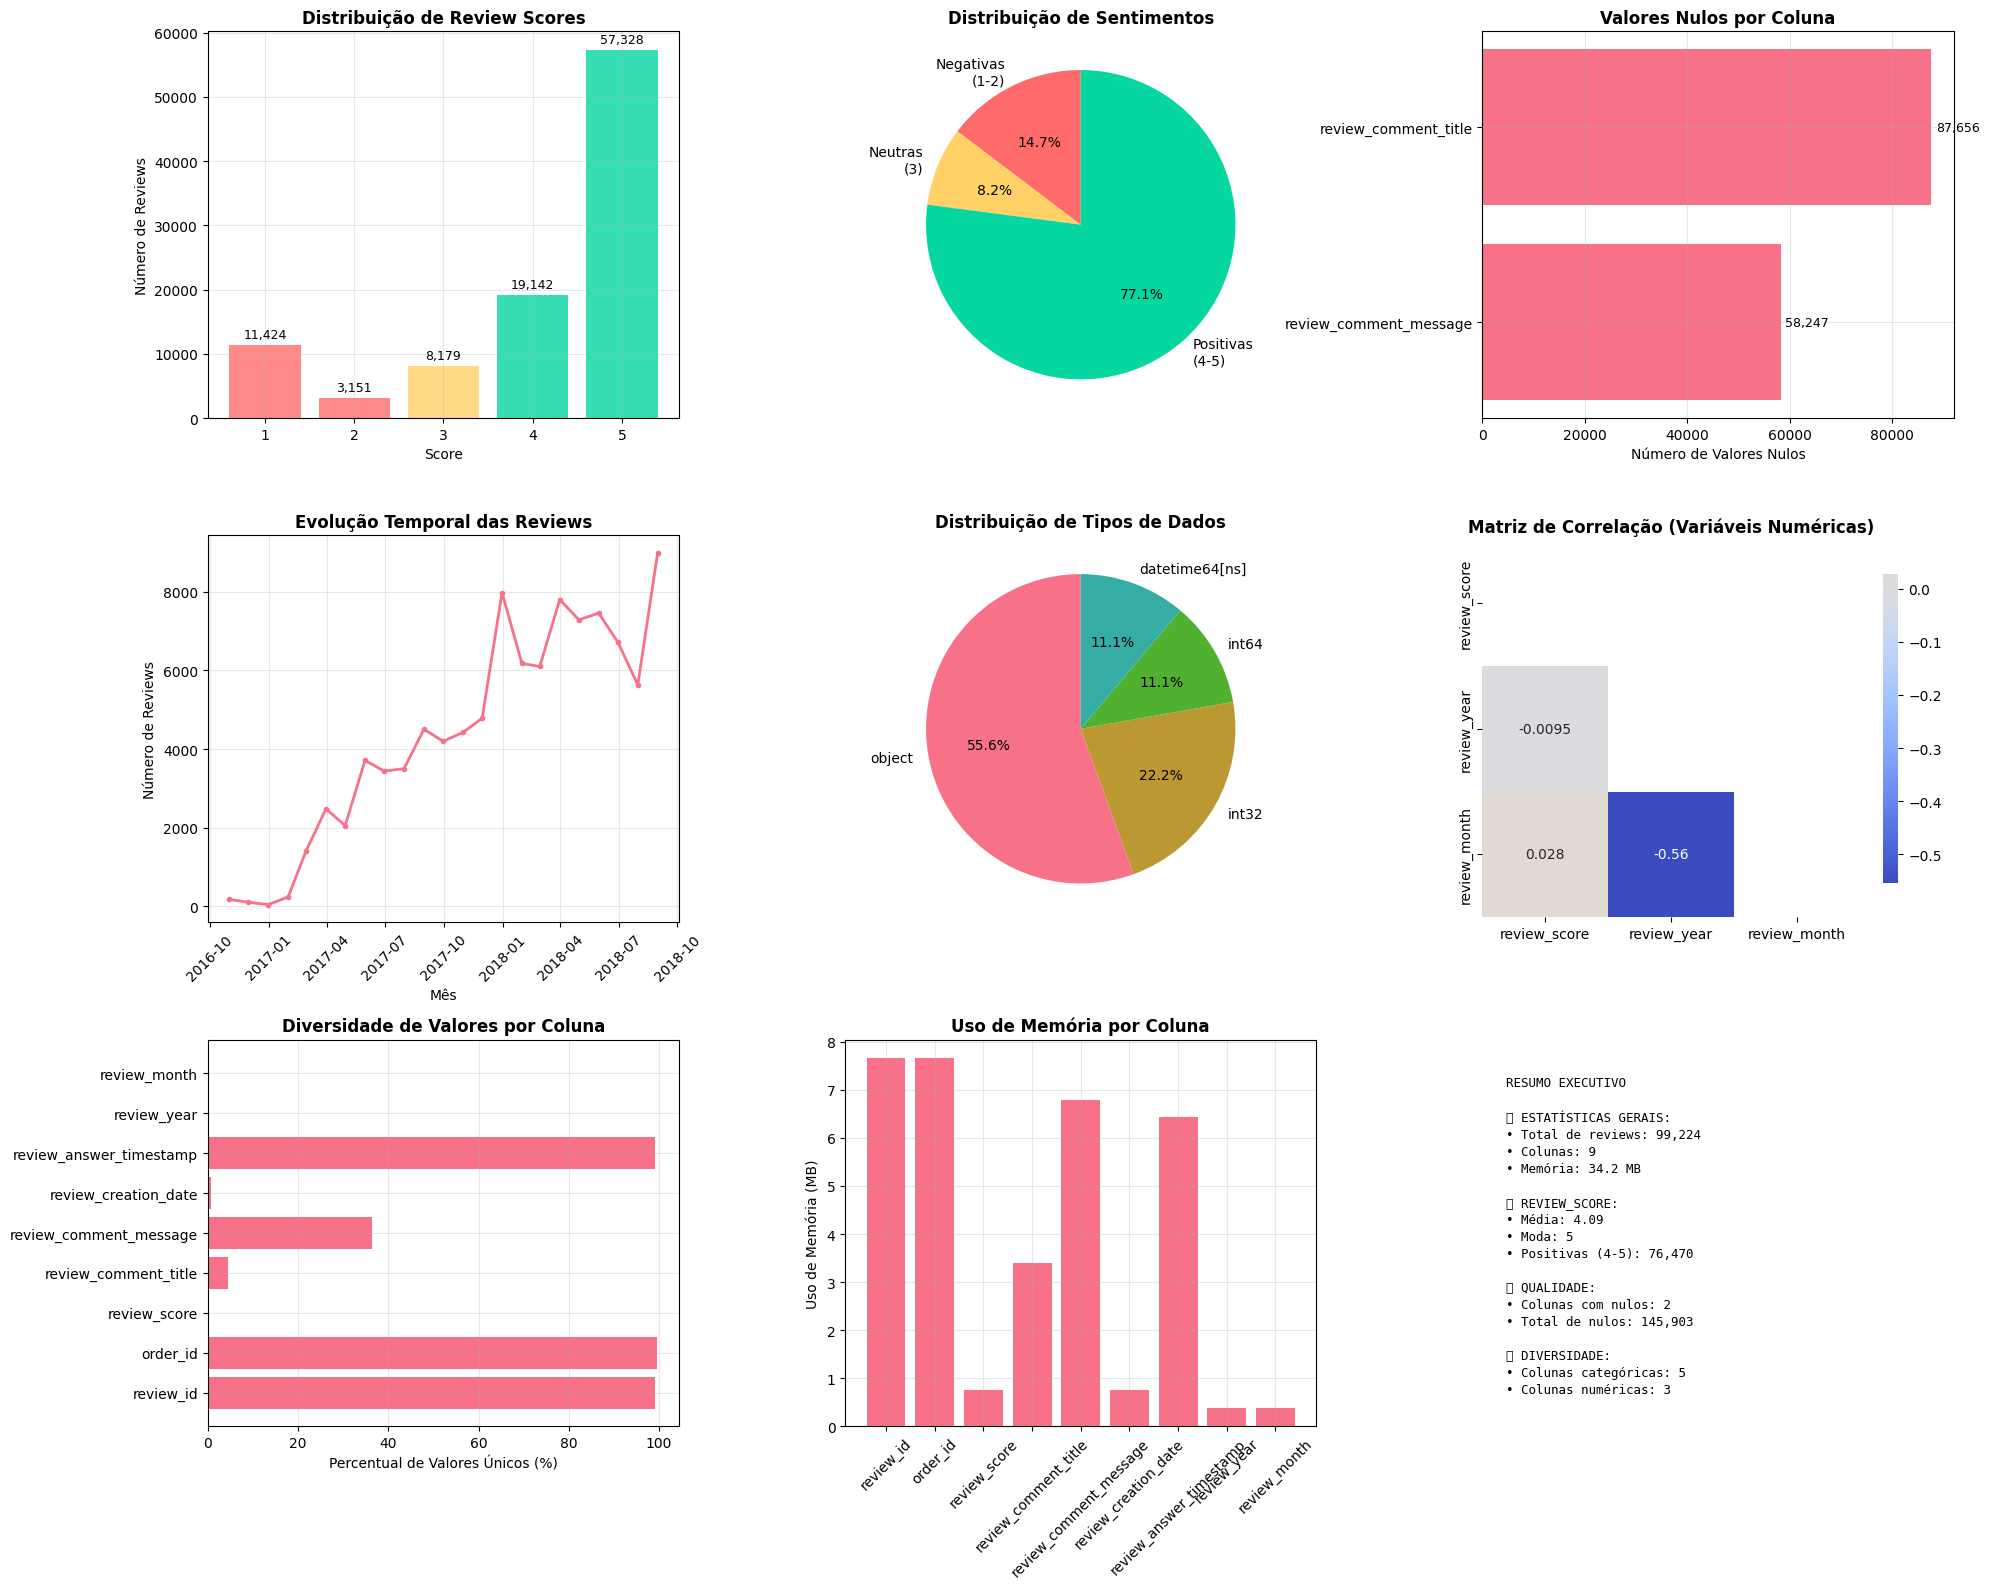


💡 RECOMENDAÇÕES E INSIGHTS

🎯 PRÓXIMOS PASSOS SUGERIDOS:
1. 📝 Análise de texto dos comentários (se disponível)
2. 🔍 Análise temporal detalhada
3. 🤝 Integração com dados de pedidos/produtos
4. 🎯 Modelagem de sentimentos
5. 📊 Dashboard interativo

⚠️  PONTOS DE ATENÇÃO:
   • Colunas com muitos nulos: ['review_comment_title', 'review_comment_message']

ANÁLISE EXPLORATÓRIA CONCLUÍDA! 🎉


In [ ]:
# @title Análise Exploratória Completa de Reviews

warnings.filterwarnings('ignore')

# Configurações de estilo
plt.style.use('default')
sns.set_palette("husl")
print("=" * 70)
print("ANÁLISE EXPLORATÓRIA COMPLETA DE REVIEWS")
print("=" * 70)

# =============================================================================
# 1. ANÁLISE DA ESTRUTURA DO DATASET
# =============================================================================

print("\n" + "=" * 50)
print("1. ANÁLISE DA ESTRUTURA DO DATASET")
print("=" * 50)

print(f"📊 DIMENSÕES DO DATASET:")
print(f"   • Total de registros: {len(reviews_df):,}")
print(f"   • Total de colunas: {len(reviews_df.columns)}")
print(f"   • Memória utilizada: {reviews_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n📋 TIPOS DE DADOS POR COLUNA:")
print("-" * 35)
dtype_summary = reviews_df.dtypes.value_counts()
for dtype, count in dtype_summary.items():
    print(f"   {dtype}: {count} colunas")

# =============================================================================
# 2. ANÁLISE DETALHADA DE VALORES ÚNICOS
# =============================================================================

print("\n" + "=" * 50)
print("2. ANÁLISE DETALHADA DE VALORES ÚNICOS")
print("=" * 50)

print("🎯 RESUMO DE VALORES ÚNICOS POR COLUNA:")
print("-" * 40)

unique_analysis = pd.DataFrame({
    'Coluna': reviews_df.columns,
    'Tipo_Dado': reviews_df.dtypes.values,
    'Valores_Únicos': [reviews_df[col].nunique() for col in reviews_df.columns],
    'Valores_Nulos': reviews_df.isnull().sum().values,
    '%_Nulos': [(reviews_df[col].isnull().sum() / len(reviews_df)) * 100 for col in reviews_df.columns]
})

unique_analysis['%_Únicos'] = (unique_analysis['Valores_Únicos'] / len(reviews_df)) * 100
print(unique_analysis.round(2))

# Análise detalhada para colunas com poucos valores únicos
print("\n🔍 DISTRIBUIÇÃO DETALHADA POR COLUNA:")
print("-" * 40)

for column in reviews_df.columns:
    unique_count = reviews_df[column].nunique()
    null_count = reviews_df[column].isnull().sum()

    print(f"\n📌 {column}:")
    print(f"   • Valores únicos: {unique_count}")
    print(f"   • Valores nulos: {null_count} ({null_count/len(reviews_df)*100:.1f}%)")

    # Mostrar distribuição para colunas com até 20 valores únicos
    if unique_count <= 20 and unique_count > 0:
        value_counts = reviews_df[column].value_counts().head(10)
        total_non_null = reviews_df[column].notna().sum()

        print(f"   • Distribuição (top {min(10, unique_count)}):")
        for value, count in value_counts.items():
            percentage = (count / total_non_null) * 100
            print(f"     {value}: {count:>6} ({percentage:5.1f}%)")

    # Para colunas numéricas, mostrar estatísticas básicas
    elif pd.api.types.is_numeric_dtype(reviews_df[column]):
        non_null_data = reviews_df[column].dropna()
        if len(non_null_data) > 0:
            print(f"   • Estatísticas: Média={non_null_data.mean():.2f}, "
                  f"Mediana={non_null_data.median():.2f}, "
                  f"Std={non_null_data.std():.2f}")

# =============================================================================
# 3. ANÁLISE AVANÇADA DE VALORES NULOS
# =============================================================================

print("\n" + "=" * 50)
print("3. ANÁLISE AVANÇADA DE VALORES NULOS")
print("=" * 50)

print("📊 VALORES NULOS POR COLUNA:")
print("-" * 30)
null_summary = reviews_df.isnull().sum()
null_summary = null_summary[null_summary > 0].sort_values(ascending=False)

if len(null_summary) > 0:
    for col, null_count in null_summary.items():
        percentage = (null_count / len(reviews_df)) * 100
        print(f"   {col}: {null_count:>6} nulos ({percentage:5.1f}%)")

        # Análise de padrão para colunas com muitos nulos
        if percentage > 50:
            print(f"     ⚠️  Mais de 50% nulos - considerar remoção")
        elif percentage > 20:
            print(f"     ⚠️  Percentual alto de nulos")
else:
    print("   ✅ Nenhum valor nulo encontrado")

# Análise de correlação entre valores nulos
print("\n🔍 PADRÕES DE VALORES NULOS:")
null_corr = reviews_df.isnull().corr()
high_null_corr = null_corr[(null_corr > 0.5) | (null_corr < -0.5)]
high_null_corr = high_null_corr.stack().reset_index()
high_null_corr = high_null_corr[high_null_corr['level_0'] != high_null_corr['level_1']]

if len(high_null_corr) > 0:
    print("   Correlações significativas entre valores nulos:")
    for _, row in high_null_corr.iterrows():
        if row[0] != row[1]:
            print(f"     {row[0]} ↔ {row[1]}: {row[2]:.3f}")

# =============================================================================
# 4. ANÁLISE ESPECÍFICA DA VARIÁVEL REVIEW_SCORE
# =============================================================================

print("\n" + "=" * 50)
print("4. ANÁLISE ESPECÍFICA DO REVIEW_SCORE")
print("=" * 50)

if 'review_score' in reviews_df.columns:
    print("🎯 ANÁLISE DETALHADA DO REVIEW_SCORE:")
    print("-" * 35)

    score_analysis = reviews_df['review_score'].describe()
    print("\n📊 ESTATÍSTICAS DESCRITIVAS:")
    for stat, value in score_analysis.items():
        print(f"   {stat}: {value:.2f}")

    # Distribuição detalhada
    score_distribution = reviews_df['review_score'].value_counts().sort_index()
    total_scores = len(reviews_df['review_score'].dropna())

    print(f"\n📈 DISTRIBUIÇÃO DETALHADA:")
    for score, count in score_distribution.items():
        percentage = (count / total_scores) * 100
        print(f"   Score {score}: {count:>6} reviews ({percentage:5.1f}%)")

    # Análise de sentimento implícito
    print(f"\n🎭 ANÁLISE DE SENTIMENTO BASEADO EM SCORE:")
    sentiment_bins = {
        'Muito Negativo (1)': 1,
        'Negativo (2)': 2,
        'Neutro (3)': 3,
        'Positivo (4)': 4,
        'Muito Positivo (5)': 5
    }

    for sentiment, score in sentiment_bins.items():
        count = len(reviews_df[reviews_df['review_score'] == score])
        percentage = (count / total_scores) * 100
        print(f"   {sentiment}: {count:>6} reviews ({percentage:5.1f}%)")

    # Métricas de satisfação
    positive_reviews = len(reviews_df[reviews_df['review_score'] >= 4])
    neutral_reviews = len(reviews_df[reviews_df['review_score'] == 3])
    negative_reviews = len(reviews_df[reviews_df['review_score'] <= 2])

    print(f"\n📊 MÉTRICAS DE SATISFAÇÃO:")
    print(f"   • Positivas (4-5): {positive_reviews:>6} ({positive_reviews/total_scores*100:5.1f}%)")
    print(f"   • Neutras (3):     {neutral_reviews:>6} ({neutral_reviews/total_scores*100:5.1f}%)")
    print(f"   • Negativas (1-2): {negative_reviews:>6} ({negative_reviews/total_scores*100:5.1f}%)")
    print(f"   • NPS Score:       {(positive_reviews - negative_reviews)/total_scores*100:5.1f}%")

# =============================================================================
# 5. ANÁLISE DE REVIEWS POSITIVAS
# =============================================================================

print("\n" + "=" * 50)
print("5. ANÁLISE DE REVIEWS POSITIVAS (SCORE 5)")
print("=" * 50)

if 'review_score' in reviews_df.columns:
    positive_reviews = reviews_df[reviews_df['review_score'] == 5]

    print(f"📈 REVIEWS COM SCORE 5:")
    print(f"   • Total: {len(positive_reviews):,}")
    print(f"   • Percentual do total: {len(positive_reviews)/len(reviews_df)*100:.1f}%")

    if len(positive_reviews) > 0:
        print(f"\n📋 AMOSTRA DE REVIEWS POSITIVAS:")
        print("-" * 35)

        # Mostrar informações das primeiras reviews positivas
        display_cols = [col for col in ['review_comment_message', 'review_creation_date', 'review_id']
                       if col in positive_reviews.columns]

        if display_cols:
            sample_positive = positive_reviews[display_cols].head(3)
            for idx, row in sample_positive.iterrows():
                print(f"\n   Review ID: {row.get('review_id', 'N/A')}")
                if 'review_creation_date' in row:
                    print(f"   Data: {row['review_creation_date']}")
                if 'review_comment_message' in row and pd.notna(row['review_comment_message']):
                    comment_preview = row['review_comment_message'][:100] + "..." if len(row['review_comment_message']) > 100 else row['review_comment_message']
                    print(f"   Comentário: {comment_preview}")

# =============================================================================
# 6. ANÁLISES COMPARATIVAS E AGRUPAMENTOS
# =============================================================================

print("\n" + "=" * 50)
print("6. ANÁLISES COMPARATIVAS E AGRUPAMENTOS")
print("=" * 50)

# Agrupamentos básicos
print("📊 AGRUPAMENTOS BÁSICOS:")
if 'review_score' in reviews_df.columns:
    score_groups = reviews_df.groupby('review_score').size().reset_index(name='count')
    print("\n   • Contagem por score:")
    for _, row in score_groups.iterrows():
        print(f"     Score {row['review_score']}: {row['count']:>6} reviews")

# Análise temporal se data disponível
if 'review_creation_date' in reviews_df.columns:
    print(f"\n📅 ANÁLISE TEMPORAL:")
    reviews_df['review_creation_date'] = pd.to_datetime(reviews_df['review_creation_date'])
    reviews_df['review_year'] = reviews_df['review_creation_date'].dt.year
    reviews_df['review_month'] = reviews_df['review_creation_date'].dt.month

    yearly_counts = reviews_df['review_year'].value_counts().sort_index()
    print("   • Reviews por ano:")
    for year, count in yearly_counts.items():
        print(f"     {year}: {count:>6} reviews")

# =============================================================================
# 7. VISUALIZAÇÕES COMPLETAS
# =============================================================================

print("\n" + "=" * 50)
print("7. VISUALIZAÇÕES COMPLETAS")
print("=" * 50)

# Criar figura principal
fig = plt.figure(figsize=(20, 16))
gs = GridSpec(3, 3, figure=fig)

# Gráfico 1: Distribuição de review_score
ax1 = fig.add_subplot(gs[0, 0])
if 'review_score' in reviews_df.columns:
    score_counts = reviews_df['review_score'].value_counts().sort_index()
    colors = ['#ff6b6b', '#ff6b6b', '#ffd166', '#06d6a0', '#06d6a0']
    bars = ax1.bar(score_counts.index, score_counts.values, color=colors, alpha=0.8)
    ax1.set_title('Distribuição de Review Scores', fontweight='bold', fontsize=12)
    ax1.set_xlabel('Score')
    ax1.set_ylabel('Número de Reviews')
    ax1.grid(True, alpha=0.3)

    # Adicionar valores nas barras
    for bar, count in zip(bars, score_counts.values):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + max(score_counts.values)*0.01,
                f'{count:,}', ha='center', va='bottom', fontsize=9)
else:
    ax1.text(0.5, 0.5, 'Coluna review_score\nnão encontrada',
             ha='center', va='center', transform=ax1.transAxes, fontsize=12)
    ax1.set_title('Distribuição de Review Scores', fontweight='bold')

# Gráfico 2: Proporção de sentimentos
ax2 = fig.add_subplot(gs[0, 1])
if 'review_score' in reviews_df.columns:
    sentiment_counts = [
        len(reviews_df[reviews_df['review_score'] <= 2]),  # Negativas
        len(reviews_df[reviews_df['review_score'] == 3]),  # Neutras
        len(reviews_df[reviews_df['review_score'] >= 4])   # Positivas
    ]
    labels = ['Negativas\n(1-2)', 'Neutras\n(3)', 'Positivas\n(4-5)']
    colors = ['#ff6b6b', '#ffd166', '#06d6a0']

    wedges, texts, autotexts = ax2.pie(sentiment_counts, labels=labels, colors=colors,
                                      autopct='%1.1f%%', startangle=90)
    ax2.set_title('Distribuição de Sentimentos', fontweight='bold')
else:
    ax2.text(0.5, 0.5, 'Coluna review_score\nnão encontrada',
             ha='center', va='center', transform=ax2.transAxes, fontsize=12)
    ax2.set_title('Distribuição de Sentimentos', fontweight='bold')

# Gráfico 3: Valores nulos por coluna
ax3 = fig.add_subplot(gs[0, 2])
null_counts = reviews_df.isnull().sum()
null_counts = null_counts[null_counts > 0].sort_values(ascending=True)

if len(null_counts) > 0:
    bars = ax3.barh(range(len(null_counts)), null_counts.values)
    ax3.set_yticks(range(len(null_counts)))
    ax3.set_yticklabels(null_counts.index)
    ax3.set_xlabel('Número de Valores Nulos')
    ax3.set_title('Valores Nulos por Coluna', fontweight='bold')
    ax3.grid(True, alpha=0.3)

    # Adicionar valores nas barras
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax3.text(width + max(null_counts.values)*0.01, bar.get_y() + bar.get_height()/2,
                f'{width:,}', ha='left', va='center', fontsize=9)
else:
    ax3.text(0.5, 0.5, 'Nenhum valor nulo\nencontrado',
             ha='center', va='center', transform=ax3.transAxes, fontsize=12)
    ax3.set_title('Valores Nulos por Coluna', fontweight='bold')

# Gráfico 4: Distribuição temporal (se data disponível)
ax4 = fig.add_subplot(gs[1, 0])
if 'review_creation_date' in reviews_df.columns:
    monthly_reviews = reviews_df.set_index('review_creation_date').resample('M').size()
    ax4.plot(monthly_reviews.index, monthly_reviews.values, linewidth=2, marker='o', markersize=3)
    ax4.set_title('Evolução Temporal das Reviews', fontweight='bold')
    ax4.set_xlabel('Mês')
    ax4.set_ylabel('Número de Reviews')
    ax4.grid(True, alpha=0.3)
    ax4.tick_params(axis='x', rotation=45)
else:
    ax4.text(0.5, 0.5, 'Coluna review_creation_date\nnão encontrada',
             ha='center', va='center', transform=ax4.transAxes, fontsize=12)
    ax4.set_title('Evolução Temporal das Reviews', fontweight='bold')

# Gráfico 5: Tipos de dados
ax5 = fig.add_subplot(gs[1, 1])
dtype_counts = reviews_df.dtypes.value_counts()
dtype_names = [str(dtype) for dtype in dtype_counts.index]

wedges, texts, autotexts = ax5.pie(dtype_counts.values, labels=dtype_names,
                                  autopct='%1.1f%%', startangle=90)
ax5.set_title('Distribuição de Tipos de Dados', fontweight='bold')

# Gráfico 6: Heatmap de correlação (apenas numéricas)
ax6 = fig.add_subplot(gs[1, 2])
numeric_cols = reviews_df.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 1:
    corr_matrix = reviews_df[numeric_cols].corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
                ax=ax6, square=True, cbar_kws={'shrink': 0.8})
    ax6.set_title('Matriz de Correlação (Variáveis Numéricas)', fontweight='bold')
else:
    ax6.text(0.5, 0.5, 'Poucas colunas\nnuméricas para\ncorrelação',
             ha='center', va='center', transform=ax6.transAxes, fontsize=12)
    ax6.set_title('Matriz de Correlação', fontweight='bold')

# Gráfico 7: Valores únicos vs total
ax7 = fig.add_subplot(gs[2, 0])
unique_ratios = [(reviews_df[col].nunique() / len(reviews_df)) * 100 for col in reviews_df.columns]
bars = ax7.barh(range(len(reviews_df.columns)), unique_ratios)
ax7.set_yticks(range(len(reviews_df.columns)))
ax7.set_yticklabels(reviews_df.columns)
ax7.set_xlabel('Percentual de Valores Únicos (%)')
ax7.set_title('Diversidade de Valores por Coluna', fontweight='bold')
ax7.grid(True, alpha=0.3)

# Gráfico 8: Estatísticas de memória
ax8 = fig.add_subplot(gs[2, 1])
memory_usage = reviews_df.memory_usage(deep=True)
memory_usage = memory_usage.drop('Index', errors='ignore')
memory_mb = memory_usage / 1024**2

bars = ax8.bar(range(len(memory_mb)), memory_mb.values)
ax8.set_xticks(range(len(memory_mb)))
ax8.set_xticklabels(memory_mb.index, rotation=45)
ax8.set_ylabel('Uso de Memória (MB)')
ax8.set_title('Uso de Memória por Coluna', fontweight='bold')
ax8.grid(True, alpha=0.3)

# Gráfico 9: Resumo executivo
ax9 = fig.add_subplot(gs[2, 2])
ax9.axis('off')

summary_text = f"""
RESUMO EXECUTIVO

📊 ESTATÍSTICAS GERAIS:
• Total de reviews: {len(reviews_df):,}
• Colunas: {len(reviews_df.columns)}
• Memória: {reviews_df.memory_usage(deep=True).sum()/1024**2:.1f} MB

🎯 REVIEW_SCORE:
• Média: {reviews_df['review_score'].mean() if 'review_score' in reviews_df.columns else 'N/A':.2f}
• Moda: {reviews_df['review_score'].mode()[0] if 'review_score' in reviews_df.columns and len(reviews_df['review_score'].mode()) > 0 else 'N/A'}
• Positivas (4-5): {len(reviews_df[reviews_df['review_score'] >= 4]) if 'review_score' in reviews_df.columns else 'N/A':,}

🔍 QUALIDADE:
• Colunas com nulos: {len(reviews_df.columns[reviews_df.isnull().any()])}
• Total de nulos: {reviews_df.isnull().sum().sum():,}

📈 DIVERSIDADE:
• Colunas categóricas: {len(reviews_df.select_dtypes(include=['object', 'category']).columns)}
• Colunas numéricas: {len(reviews_df.select_dtypes(include=[np.number]).columns)}
"""

ax9.text(0.05, 0.95, summary_text, transform=ax9.transAxes, fontsize=9,
        verticalalignment='top', fontfamily='monospace', linespacing=1.4)

plt.tight_layout()
plt.show()

# =============================================================================
# 8. RECOMENDAÇÕES E INSIGHTS
# =============================================================================

print("\n" + "=" * 70)
print("💡 RECOMENDAÇÕES E INSIGHTS")
print("=" * 70)

print("\n🎯 PRÓXIMOS PASSOS SUGERIDOS:")
print("1. 📝 Análise de texto dos comentários (se disponível)")
print("2. 🔍 Análise temporal detalhada")
print("3. 🤝 Integração com dados de pedidos/produtos")
print("4. 🎯 Modelagem de sentimentos")
print("5. 📊 Dashboard interativo")

print("\n⚠️  PONTOS DE ATENÇÃO:")
if 'review_score' in reviews_df.columns:
    score_dist = reviews_df['review_score'].value_counts(normalize=True)
    if score_dist.get(5, 0) > 0.6:
        print("   • Alta concentração de scores 5 - possível viés positivo")
    if score_dist.get(1, 0) < 0.05:
        print("   • Poucas reviews negativas - considerar oversampling")

null_cols = reviews_df.columns[reviews_df.isnull().sum() > len(reviews_df) * 0.3]
if len(null_cols) > 0:
    print(f"   • Colunas com muitos nulos: {list(null_cols)}")

print("\n" + "=" * 70)
print("ANÁLISE EXPLORATÓRIA CONCLUÍDA! 🎉")
print("=" * 70)

PREPARAÇÃO E ANÁLISE DE DADOS PARA MODELO DE SENTIMENTO

1. CLASSIFICAÇÃO DE SENTIMENTO
🎯 Aplicando classificação de sentimento...

📊 DISTRIBUIÇÃO ORIGINAL DOS SCORES:
-----------------------------------
Score 1:  11424 registros ( 11.5%)
Score 2:   3151 registros (  3.2%)
Score 3:   8179 registros (  8.2%)
Score 4:  19142 registros ( 19.3%)
Score 5:  57328 registros ( 57.8%)

2. PREPARAÇÃO DOS DADOS
🔍 ANÁLISE INICIAL DOS DADOS:
Total de registros antes da limpeza: 99,224

📋 VALORES NULOS ANTES DA LIMPEZA:
review_comment_message    58247
sentiment                     0
dtype: int64

🧹 REALIZANDO LIMPEZA DOS DADOS...
Registros removidos (sem comentário): 58,247
Valores nulos na variável sentiment: 0
Registros removidos (sentiment inválido): 0

3. ANÁLISE DA DISTRIBUIÇÃO DE SENTIMENTOS

📈 DISTRIBUIÇÃO FINAL DOS SENTIMENTOS:
Negativo (0):  10890 registros ( 26.6%)
  Neutro (1):   3557 registros (  8.7%)
Positivo (2):  26530 registros ( 64.7%)

           Total:  40977 registros

⚖️  ANÁLI

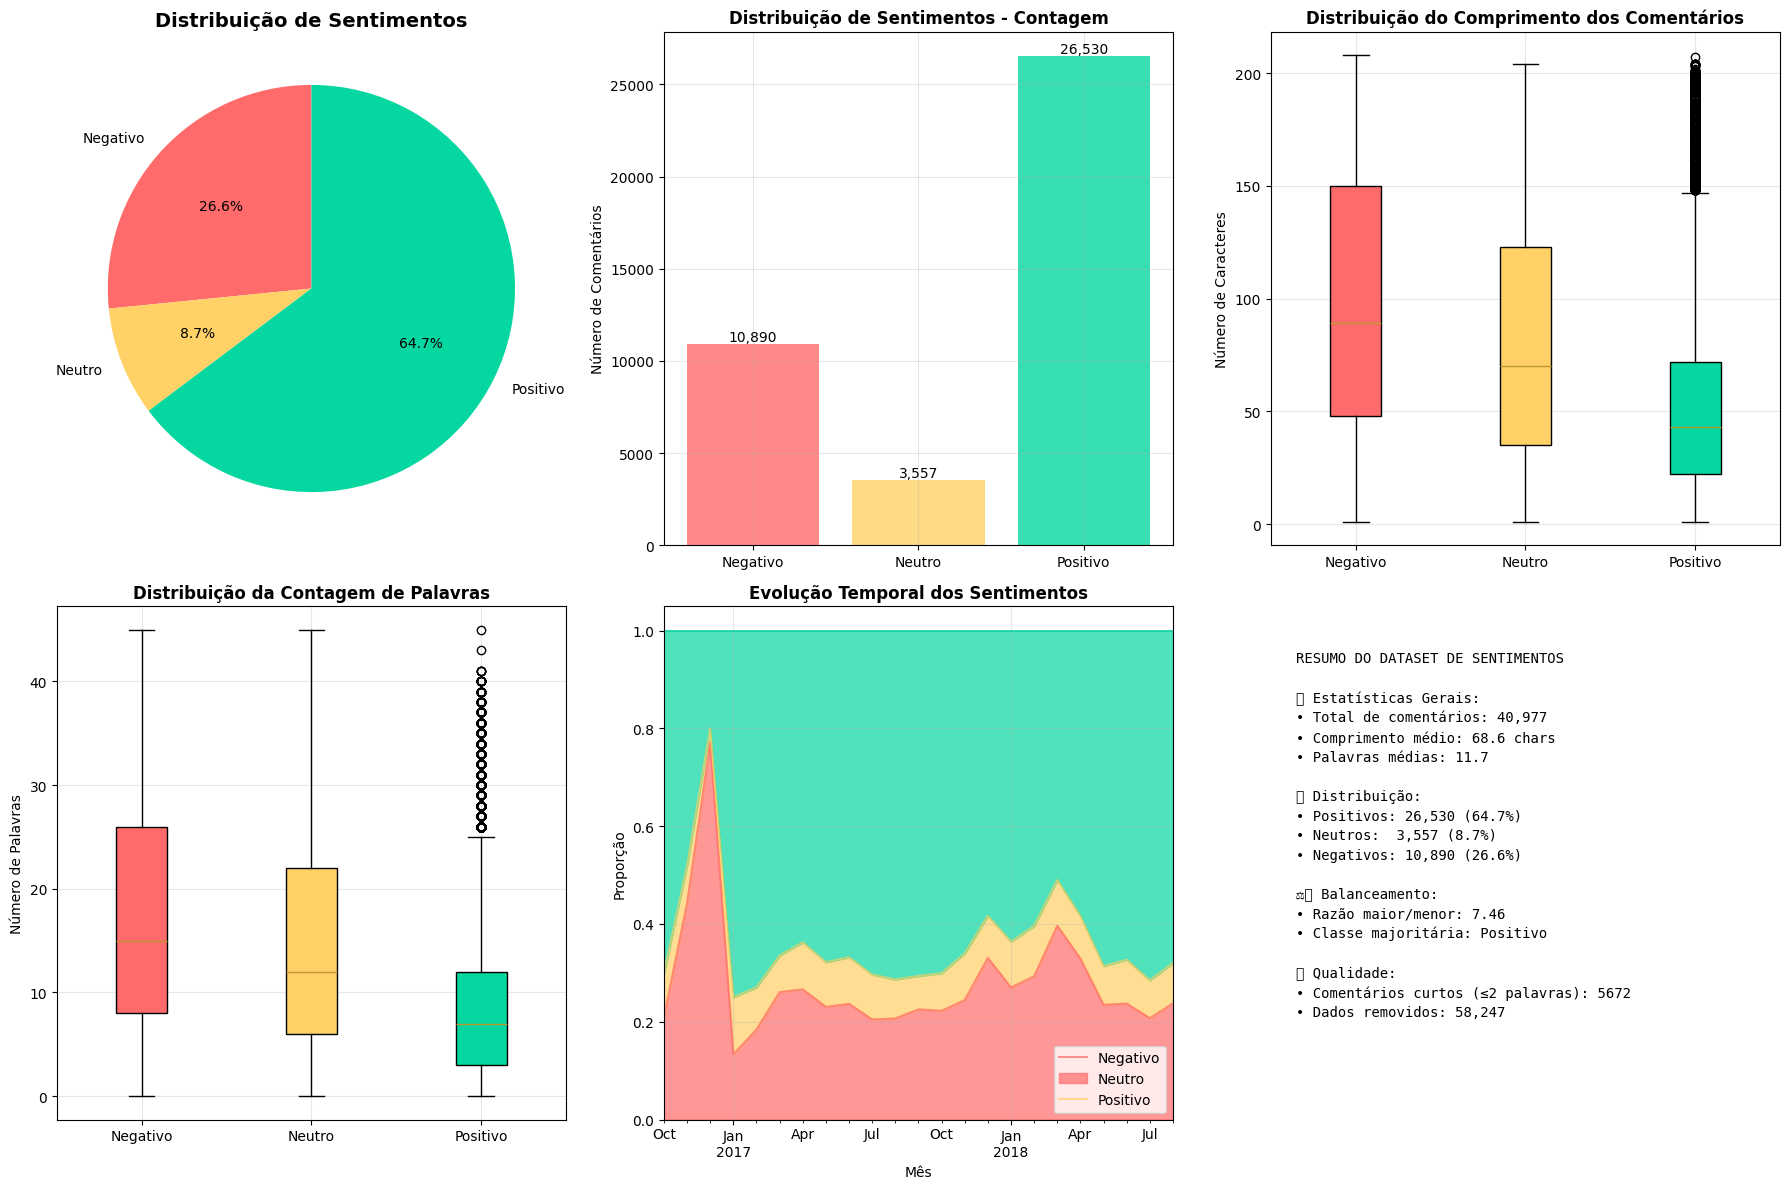


6. SALVAMENTO E RECOMENDAÇÕES
💾 Salvando dados preparados...
✅ Dados preparados e salvos em 'reviews_com_sentimento.csv'

💡 RECOMENDAÇÕES PARA MODELAGEM:
-----------------------------------
1. ⚠️  Dataset desbalanceado - considerar:
   • Técnicas de reamostragem (SMOTE, undersampling)
   • Uso de pesos de classe no modelo
   • Métricas apropriadas (F1-score, AUC-ROC)
2. ⚠️  Muitos comentários curtos (5672):
   • Avaliar impacto na performance do modelo
   • Considerar remoção ou tratamento especial
3. 🔧 Pré-processamento de texto sugerido:
   • Tokenização e limpeza de texto
   • Remoção de stopwords
   • Stemming/Lemmatization
   • TF-IDF ou embeddings
4. 📈 Estratégias de validação:
   • Validação cruzada estratificada
   • Split temporal (se dados temporais)
   • Hold-out com distribuição balanceada

PREPARAÇÃO DE DADOS CONCLUÍDA! 🎉

📋 AMOSTRA DO DATASET FINAL:
                               review_comment_message  sentiment  \
3               Recebi bem antes do prazo estipulado.  

In [ ]:
# @title Preparação e Análise de Dados para Modelo de Sentimento - Negativo (0), Neutro (1), Positivo (2)

warnings.filterwarnings('ignore')

# Configurações de estilo
plt.style.use('default')
sns.set_palette("husl")
print("=" * 70)
print("PREPARAÇÃO E ANÁLISE DE DADOS PARA MODELO DE SENTIMENTO")
print("=" * 70)

# =============================================================================
# 1. CLASSIFICAÇÃO DE SENTIMENTO
# =============================================================================

print("\n" + "=" * 50)
print("1. CLASSIFICAÇÃO DE SENTIMENTO")
print("=" * 50)

def classify_sentiment(score):
    """Classifica o sentimento baseado na nota de avaliação"""
    if score in [1, 2]:
        return 0  # Negativo
    elif score == 3:
        return 1  # Neutro
    elif score in [4, 5]:
        return 2  # Positivo
    else:
        return None  # Para valores fora do esperado

# Aplicar a classificação correta
print("🎯 Aplicando classificação de sentimento...")
reviews_df["sentiment"] = reviews_df["review_score"].apply(classify_sentiment)

# Verificar a distribuição original dos scores
print("\n📊 DISTRIBUIÇÃO ORIGINAL DOS SCORES:")
print("-" * 35)
original_distribution = reviews_df["review_score"].value_counts().sort_index()
for score, count in original_distribution.items():
    percentage = (count / len(reviews_df)) * 100
    print(f"Score {score}: {count:>6} registros ({percentage:5.1f}%)")

# =============================================================================
# 2. PREPARAÇÃO DOS DADOS
# =============================================================================

print("\n" + "=" * 50)
print("2. PREPARAÇÃO DOS DADOS")
print("=" * 50)

# Verificar dados antes da limpeza
print("🔍 ANÁLISE INICIAL DOS DADOS:")
print(f"Total de registros antes da limpeza: {len(reviews_df):,}")

# Verificar valores nulos
print("\n📋 VALORES NULOS ANTES DA LIMPEZA:")
null_before = reviews_df[['review_comment_message', 'sentiment']].isnull().sum()
print(null_before)

# Preparação dos dados para o modelo
print("\n🧹 REALIZANDO LIMPEZA DOS DADOS...")

# Remover linhas que não possuem comentários
initial_count = len(reviews_df)
reviews_df.dropna(subset=['review_comment_message'], inplace=True)
after_drop_na = len(reviews_df)
removed_no_comment = initial_count - after_drop_na

print(f"Registros removidos (sem comentário): {removed_no_comment:,}")

# Verificar se há valores nulos na variável target
null_sentiment = reviews_df["sentiment"].isnull().sum()
print(f"Valores nulos na variável sentiment: {null_sentiment}")

# Selecionar as colunas de interesse
sentrev_df = reviews_df[['review_comment_message', 'sentiment']].copy()

# Remover linhas onde sentiment é None (caso existam valores fora de 1-5)
initial_sentiment_count = len(sentrev_df)
sentrev_df = sentrev_df.dropna(subset=['sentiment'])
final_count = len(sentrev_df)
removed_invalid_sentiment = initial_sentiment_count - final_count

print(f"Registros removidos (sentiment inválido): {removed_invalid_sentiment}")

# =============================================================================
# 3. ANÁLISE DA DISTRIBUIÇÃO DE SENTIMENTOS
# =============================================================================

print("\n" + "=" * 50)
print("3. ANÁLISE DA DISTRIBUIÇÃO DE SENTIMENTOS")
print("=" * 50)

# Distribuição detalhada
sentiment_distribution = sentrev_df["sentiment"].value_counts().sort_index()
sentiment_labels = {0: 'Negativo', 1: 'Neutro', 2: 'Positivo'}

print("\n📈 DISTRIBUIÇÃO FINAL DOS SENTIMENTOS:")
print("=" * 40)

total_records = len(sentrev_df)
for sentiment_code, count in sentiment_distribution.items():
    label = sentiment_labels[sentiment_code]
    percentage = (count / total_records) * 100
    print(f"{label:>8} ({sentiment_code}): {count:>6} registros ({percentage:5.1f}%)")

print(f"\n{'Total:':>17} {total_records:>6} registros")

# Análise de balanceamento
print("\n⚖️  ANÁLISE DE BALANCEAMENTO:")
max_count = sentiment_distribution.max()
min_count = sentiment_distribution.min()
imbalance_ratio = max_count / min_count if min_count > 0 else float('inf')

print(f"Razão de desbalanceamento: {imbalance_ratio:.2f}")
if imbalance_ratio > 5:
    print("⚠️  Dataset severamente desbalanceado!")
elif imbalance_ratio > 2:
    print("⚠️  Dataset moderadamente desbalanceado")
else:
    print("✅ Dataset relativamente balanceado")

# =============================================================================
# 4. ANÁLISE DE TEXTO E QUALIDADE DOS COMENTÁRIOS
# =============================================================================

print("\n" + "=" * 50)
print("4. ANÁLISE DE TEXTO E QUALIDADE DOS COMENTÁRIOS")
print("=" * 50)

# Análise estatística dos textos
print("\n📝 ESTATÍSTICAS DOS COMENTÁRIOS:")
sentrev_df['comment_length'] = sentrev_df['review_comment_message'].str.len()
sentrev_df['word_count'] = sentrev_df['review_comment_message'].str.split().str.len()

text_stats = sentrev_df.groupby('sentiment').agg({
    'comment_length': ['mean', 'std', 'min', 'max'],
    'word_count': ['mean', 'std', 'min', 'max']
}).round(1)

# Renomear colunas para melhor legibilidade
text_stats.columns = ['Length_Mean', 'Length_Std', 'Length_Min', 'Length_Max',
                     'Words_Mean', 'Words_Std', 'Words_Min', 'Words_Max']
text_stats.index = [sentiment_labels[i] for i in text_stats.index]

print(text_stats)

# Análise de comentários muito curtos
short_comments = sentrev_df[sentrev_df['word_count'] <= 2]
print(f"\n🔍 Comentários muito curtos (≤2 palavras): {len(short_comments)}")
if len(short_comments) > 0:
    print("Exemplos de comentários curtos:")
    for i, (_, row) in enumerate(short_comments.head(5).iterrows()):
        print(f"  {i+1}. '{row['review_comment_message']}' (Sentimento: {sentiment_labels[row['sentiment']]})")

# =============================================================================
# 5. VISUALIZAÇÕES COMPLETAS
# =============================================================================

print("\n" + "=" * 50)
print("5. VISUALIZAÇÕES DA DISTRIBUIÇÃO DE SENTIMENTOS")
print("=" * 50)

# Criar figura principal
fig = plt.figure(figsize=(18, 12))
gs = GridSpec(2, 3, figure=fig)

# Gráfico 1: Distribuição de sentimentos (pie chart)
ax1 = fig.add_subplot(gs[0, 0])
colors = ['#ff6b6b', '#ffd166', '#06d6a0']  # Vermelho, Amarelo, Verde
sentiment_counts = [sentiment_distribution.get(0, 0),
                   sentiment_distribution.get(1, 0),
                   sentiment_distribution.get(2, 0)]

wedges, texts, autotexts = ax1.pie(sentiment_counts, labels=['Negativo', 'Neutro', 'Positivo'],
                                  colors=colors, autopct='%1.1f%%', startangle=90)
ax1.set_title('Distribuição de Sentimentos', fontweight='bold', fontsize=14)

# Gráfico 2: Distribuição de sentimentos (bar chart)
ax2 = fig.add_subplot(gs[0, 1])
bars = ax2.bar(sentiment_labels.values(), sentiment_counts, color=colors, alpha=0.8)
ax2.set_title('Distribuição de Sentimentos - Contagem', fontweight='bold')
ax2.set_ylabel('Número de Comentários')
ax2.grid(True, alpha=0.3)

# Adicionar valores nas barras
for bar, count in zip(bars, sentiment_counts):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{count:,}', ha='center', va='bottom')

# Gráfico 3: Comprimento dos comentários por sentimento
ax3 = fig.add_subplot(gs[0, 2])
boxplot_data = []
sentiment_names = []
for sentiment in [0, 1, 2]:
    data = sentrev_df[sentrev_df['sentiment'] == sentiment]['comment_length']
    boxplot_data.append(data)
    sentiment_names.append(sentiment_labels[sentiment])

box_plot = ax3.boxplot(boxplot_data, labels=sentiment_names, patch_artist=True)
colors_box = ['#ff6b6b', '#ffd166', '#06d6a0']
for patch, color in zip(box_plot['boxes'], colors_box):
    patch.set_facecolor(color)

ax3.set_title('Distribuição do Comprimento dos Comentários', fontweight='bold')
ax3.set_ylabel('Número de Caracteres')
ax3.grid(True, alpha=0.3)

# Gráfico 4: Contagem de palavras por sentimento
ax4 = fig.add_subplot(gs[1, 0])
boxplot_words = []
for sentiment in [0, 1, 2]:
    data = sentrev_df[sentrev_df['sentiment'] == sentiment]['word_count']
    boxplot_words.append(data)

box_plot_words = ax4.boxplot(boxplot_words, labels=sentiment_names, patch_artist=True)
for patch, color in zip(box_plot_words['boxes'], colors_box):
    patch.set_facecolor(color)

ax4.set_title('Distribuição da Contagem de Palavras', fontweight='bold')
ax4.set_ylabel('Número de Palavras')
ax4.grid(True, alpha=0.3)

# Gráfico 5: Proporção de sentimentos ao longo do tempo (se data disponível)
ax5 = fig.add_subplot(gs[1, 1])
if 'review_creation_date' in reviews_df.columns:
    # Adicionar data ao dataset de sentimentos
    temp_df = reviews_df[reviews_df.index.isin(sentrev_df.index)].copy()
    temp_df['review_creation_date'] = pd.to_datetime(temp_df['review_creation_date'])
    temp_df['month_year'] = temp_df['review_creation_date'].dt.to_period('M')

    monthly_sentiment = temp_df.groupby('month_year')['sentiment'].value_counts(normalize=True).unstack()
    monthly_sentiment = monthly_sentiment.fillna(0)

    # Converter Period para datetime para plotagem
    monthly_sentiment.index = monthly_sentiment.index.to_timestamp()

    monthly_sentiment.plot(kind='area', ax=ax5, color=colors, alpha=0.7, stacked=True)
    ax5.set_title('Evolução Temporal dos Sentimentos', fontweight='bold')
    ax5.set_xlabel('Mês')
    ax5.set_ylabel('Proporção')
    ax5.legend(['Negativo', 'Neutro', 'Positivo'])
    ax5.grid(True, alpha=0.3)
else:
    # Gráfico alternativo: Distribuição de comprimento cumulativa
    for sentiment, color in zip([0, 1, 2], colors):
        data = sentrev_df[sentrev_df['sentiment'] == sentiment]['comment_length']
        if len(data) > 0:
            ax5.hist(data, bins=50, alpha=0.6, color=color,
                    label=sentiment_labels[sentiment], density=True, cumulative=True)

    ax5.set_title('Distribuição Cumulativa do Comprimento', fontweight='bold')
    ax5.set_xlabel('Comprimento do Comentário (caracteres)')
    ax5.set_ylabel('Frequência Cumulativa')
    ax5.legend()
    ax5.grid(True, alpha=0.3)

# Gráfico 6: Resumo estatístico
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')

# Texto de resumo
summary_text = f"""
RESUMO DO DATASET DE SENTIMENTOS

📊 Estatísticas Gerais:
• Total de comentários: {len(sentrev_df):,}
• Comprimento médio: {sentrev_df['comment_length'].mean():.1f} chars
• Palavras médias: {sentrev_df['word_count'].mean():.1f}

🎯 Distribuição:
• Positivos: {sentiment_distribution.get(2, 0):,} ({sentiment_distribution.get(2, 0)/total_records*100:.1f}%)
• Neutros:  {sentiment_distribution.get(1, 0):,} ({sentiment_distribution.get(1, 0)/total_records*100:.1f}%)
• Negativos: {sentiment_distribution.get(0, 0):,} ({sentiment_distribution.get(0, 0)/total_records*100:.1f}%)

⚖️ Balanceamento:
• Razão maior/menor: {imbalance_ratio:.2f}
• Classe majoritária: {max(sentiment_labels.items(), key=lambda x: sentiment_distribution.get(x[0], 0))[1]}

📝 Qualidade:
• Comentários curtos (≤2 palavras): {len(short_comments)}
• Dados removidos: {removed_no_comment + removed_invalid_sentiment:,}
"""

ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes, fontsize=10,
        verticalalignment='top', fontfamily='monospace', linespacing=1.5)

plt.tight_layout()
plt.show()

# =============================================================================
# 6. SALVAMENTO E RECOMENDAÇÕES
# =============================================================================

print("\n" + "=" * 50)
print("6. SALVAMENTO E RECOMENDAÇÕES")
print("=" * 50)

# Salvar os dados preparados
print("💾 Salvando dados preparados...")
sentrev_df.to_csv("reviews_com_sentimento.csv", index=False)

print("✅ Dados preparados e salvos em 'reviews_com_sentimento.csv'")

# Recomendações para modelagem
print("\n💡 RECOMENDAÇÕES PARA MODELAGEM:")
print("-" * 35)

if imbalance_ratio > 2:
    print("1. ⚠️  Dataset desbalanceado - considerar:")
    print("   • Técnicas de reamostragem (SMOTE, undersampling)")
    print("   • Uso de pesos de classe no modelo")
    print("   • Métricas apropriadas (F1-score, AUC-ROC)")

if len(short_comments) > total_records * 0.1:
    print(f"2. ⚠️  Muitos comentários curtos ({len(short_comments)}):")
    print("   • Avaliar impacto na performance do modelo")
    print("   • Considerar remoção ou tratamento especial")

print("3. 🔧 Pré-processamento de texto sugerido:")
print("   • Tokenização e limpeza de texto")
print("   • Remoção de stopwords")
print("   • Stemming/Lemmatization")
print("   • TF-IDF ou embeddings")

print("4. 📈 Estratégias de validação:")
print("   • Validação cruzada estratificada")
print("   • Split temporal (se dados temporais)")
print("   • Hold-out com distribuição balanceada")

print("\n" + "=" * 70)
print("PREPARAÇÃO DE DADOS CONCLUÍDA! 🎉")
print("=" * 70)

# Mostrar primeiras linhas do dataset final
print("\n📋 AMOSTRA DO DATASET FINAL:")
print(sentrev_df.head(10))

In [ ]:
# @title Análise de Relação entre Tempo de Entrega e Avaliação de Reviews

print("🚀 INICIANDO ANÁLISE: TEMPO DE ENTREGA vs AVALIAÇÃO...")

# 1. Preparação dos dados de entrega e reviews
print("\n🔧 PREPARANDO DADOS DE ENTREGA E REVIEWS...")

# Converter as colunas de data para datetime
orders_df['order_delivered_customer_date'] = pd.to_datetime(orders_df['order_delivered_customer_date'])
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])

print("✅ Datas convertidas com sucesso:")
print(f"   • Primeira compra: {orders_df['order_purchase_timestamp'].min().strftime('%d/%m/%Y')}")
print(f"   • Última entrega: {orders_df['order_delivered_customer_date'].max().strftime('%d/%m/%Y')}")

# 2. Juntar os DataFrames
print("\n🔄 UNINDO DADOS DE PEDIDOS E REVIEWS...")

merged_df = pd.merge(reviews_df, orders_df, on='order_id', how='inner')

print(f"✅ DataFrames unidos com sucesso:")
print(f"   • Reviews originais: {len(reviews_df):,}")
print(f"   • Pedidos originais: {len(orders_df):,}")
print(f"   • Dados unidos: {len(merged_df):,} registros")

# 3. Calcular métricas de entrega
print("\n📊 CALCULANDO MÉTRICAS DE ENTREGA...")

# Calcular o tempo de entrega em dias
merged_df['delivery_days'] = (merged_df['order_delivered_customer_date'] -
                            merged_df['order_purchase_timestamp']).dt.days

# Calcular métricas adicionais
merged_df['delivery_weeks'] = merged_df['delivery_days'] / 7
merged_df['is_delayed'] = merged_df['delivery_days'] > 7  # Considera atraso se mais de 7 dias

print("✅ Métricas de entrega calculadas:")

# 4. Análise estatística detalhada
print(f"\n{'='*70}")
print("📈 ANÁLISE ESTATÍSTICA DO TEMPO DE ENTREGA")
print(f"{'='*70}")

# Estatísticas básicas
delivery_stats = merged_df['delivery_days'].describe()
print("\n📊 ESTATÍSTICAS BÁSICAS DO TEMPO DE ENTREGA:")
print(f"   • Total de entregas analisadas: {len(merged_df):,}")
print(f"   • Média de dias: {delivery_stats['mean']:.1f} dias")
print(f"   • Mediana: {delivery_stats['50%']:.1f} dias")
print(f"   • Desvio padrão: {delivery_stats['std']:.1f} dias")
print(f"   • Mínimo: {delivery_stats['min']:.0f} dias")
print(f"   • Máximo: {delivery_stats['max']:.0f} dias")

# Análise de distribuição
print(f"\n🎯 DISTRIBUIÇÃO DO TEMPO DE ENTREGA:")
delivery_bins = [0, 3, 7, 14, 30, 90, merged_df['delivery_days'].max()]
delivery_labels = ['0-3 dias', '4-7 dias', '8-14 dias', '15-30 dias', '31-90 dias', '90+ dias']

delivery_distribution = pd.cut(merged_df['delivery_days'], bins=delivery_bins, labels=delivery_labels).value_counts().sort_index()

print("\nFaixa de Entrega   Quantidade   Porcentagem")
print("-" * 45)
for faixa, count in delivery_distribution.items():
    percentage = (count / len(merged_df)) * 100
    print(f"{faixa:15} {count:10,} {percentage:12.1f}%")

# 5. Análise de atrasos
print(f"\n⚠️  ANÁLISE DE ATRASOS NA ENTREGA:")
delayed_orders = merged_df[merged_df['is_delayed']]
delayed_percentage = (len(delayed_orders) / len(merged_df)) * 100

print(f"   • Pedidos com mais de 7 dias: {len(delayed_orders):,} ({delayed_percentage:.1f}%)")
print(f"   • Tempo médio dos atrasados: {delayed_orders['delivery_days'].mean():.1f} dias")
print(f"   • Tempo máximo de atraso: {delayed_orders['delivery_days'].max():.0f} dias")

# 6. Relação entre tempo de entrega e avaliação
print(f"\n{'='*70}")
print("🔗 RELAÇÃO: TEMPO DE ENTREGA vs SCORE DO REVIEW")
print(f"{'='*70}")

# Correlação
correlation = merged_df['delivery_days'].corr(merged_df['review_score'])
print(f"\n📊 CORRELAÇÃO ENTRE VARIÁVEIS:")
print(f"   • Coeficiente de correlação: {correlation:.3f}")

if correlation < -0.3:
    print("   • 🔴 Correlação negativa forte: entregas mais lentas tendem a piores avaliações")
elif correlation < -0.1:
    print("   • 🟡 Correlação negativa moderada")
elif correlation < 0.1:
    print("   • 🟢 Correlação muito fraca: tempo de entrega não influencia avaliações")
else:
    print("   • 🔵 Correlação positiva: relação inesperada")

# Análise por faixa de tempo de entrega
print(f"\n📈 MÉDIA DE SCORE POR FAIXA DE ENTREGA:")

delivery_score_analysis = merged_df.groupby(
    pd.cut(merged_df['delivery_days'], bins=delivery_bins, labels=delivery_labels)
).agg({
    'review_score': ['mean', 'count'],
    'delivery_days': 'mean'
}).round(3)

delivery_score_analysis.columns = ['score_medio', 'quantidade', 'dias_medio']
delivery_score_analysis = delivery_score_analysis.reset_index()

print("\nFaixa de Entrega   Score Médio  Quantidade  Dias Médios")
print("-" * 65)
for _, row in delivery_score_analysis.iterrows():
    print(f"{row['delivery_days']:15} {row['score_medio']:12.2f} {row['quantidade']:11,} {row['dias_medio']:12.1f}")

# 7. Análise de outliers e casos extremos
print(f"\n{'='*70}")
print("🔍 CASOS EXTREMOS E OUTLIERS")
print(f"{'='*70}")

# Pedidos mais rápidos
fastest_orders = merged_df.nsmallest(5, 'delivery_days')[['delivery_days', 'review_score']]
print(f"\n⚡ PEDIDOS MAIS RÁPIDOS:")
print("Dias  Score")
for _, row in fastest_orders.iterrows():
    print(f"{row['delivery_days']:4.0f}  {row['review_score']:5.0f}")

# Pedidos mais lentos
slowest_orders = merged_df.nlargest(5, 'delivery_days')[['delivery_days', 'review_score']]
print(f"\n🐌 PEDIDOS MAIS LENTOS:")
print("Dias  Score")
for _, row in slowest_orders.iterrows():
    print(f"{row['delivery_days']:4.0f}  {row['review_score']:5.0f}")

# 8. Análise de satisfação por tempo de entrega
print(f"\n{'='*70}")
print("😊 ANÁLISE DE SATISFAÇÃO POR TEMPO DE ENTREGA")
print(f"{'='*70}")

# Definir satisfação (score 4-5 como satisfeito)
merged_df['is_satisfied'] = merged_df['review_score'] >= 4

satisfaction_by_delivery = merged_df.groupby(
    pd.cut(merged_df['delivery_days'], bins=delivery_bins, labels=delivery_labels)
)['is_satisfied'].mean().round(3) * 100

print(f"\n📊 TAXA DE SATISFAÇÃO POR FAIXA DE ENTREGA:")
print("\nFaixa de Entrega   Satisfação")
print("-" * 35)
for faixa, satisfacao in satisfaction_by_delivery.items():
    print(f"{faixa:15} {satisfacao:10.1f}%")

# 9. Resumo executivo
print(f"\n{'='*70}")
print("📋 RESUMO EXECUTIVO - IMPACTO DO TEMPO DE ENTREGA")
print(f"{'='*70}")

print(f"✅ ANÁLISE CONCLUÍDA COM SUCESSO!")
print(f"\n🎯 PRINCIPAIS DESCOBERTAS:")
print(f"   • {len(merged_df):,} pedidos com dados completos de entrega e review")
print(f"   • Tempo médio de entrega: {delivery_stats['mean']:.1f} dias")
print(f"   • {delayed_percentage:.1f}% dos pedidos com mais de 7 dias")
print(f"   • Correlação entre tempo e avaliação: {correlation:.3f}")

if correlation < -0.2:
    print(f"   • 📉 Tempo de entrega impacta negativamente as avaliações")
elif correlation > 0.2:
    print(f"   • 📈 Relação positiva inesperada detectada")
else:
    print(f"   • ➡️  Tempo de entrega tem baixa influência nas avaliações")

print(f"\n💡 RECOMENDAÇÕES:")
if delayed_percentage > 20:
    print(f"   • ⚠️  Alta taxa de atrasos ({delayed_percentage:.1f}%) - revisar logística")
if correlation < -0.2:
    print(f"   • 🚀 Melhorar tempo de entrega para aumentar satisfação")
else:
    print(f"   • ✅ Focar em outros fatores de qualidade além do tempo")

print(f"\n✨ Análise completa - Insights valiosos para otimização!")

🚀 INICIANDO ANÁLISE: TEMPO DE ENTREGA vs AVALIAÇÃO...

🔧 PREPARANDO DADOS DE ENTREGA E REVIEWS...
✅ Datas convertidas com sucesso:
   • Primeira compra: 04/09/2016
   • Última entrega: 17/10/2018

🔄 UNINDO DADOS DE PEDIDOS E REVIEWS...
✅ DataFrames unidos com sucesso:
   • Reviews originais: 40,977
   • Pedidos originais: 99,441
   • Dados unidos: 40,977 registros

📊 CALCULANDO MÉTRICAS DE ENTREGA...
✅ Métricas de entrega calculadas:

📈 ANÁLISE ESTATÍSTICA DO TEMPO DE ENTREGA

📊 ESTATÍSTICAS BÁSICAS DO TEMPO DE ENTREGA:
   • Total de entregas analisadas: 40,977
   • Média de dias: 13.0 dias
   • Mediana: 10.0 dias
   • Desvio padrão: 10.8 dias
   • Mínimo: 0 dias
   • Máximo: 195 dias

🎯 DISTRIBUIÇÃO DO TEMPO DE ENTREGA:

Faixa de Entrega   Quantidade   Porcentagem
---------------------------------------------
0-3 dias             3,287          8.0%
4-7 dias             9,673         23.6%
8-14 dias           14,323         35.0%
15-30 dias           9,306         22.7%
31-90 dias    

📈 INICIANDO ANÁLISE TEMPORAL DE REVIEWS...

🔧 PREPARANDO DADOS TEMPORAIS AVANÇADOS...
✅ Colunas temporais criadas:
   • mes_ano: 40977 valores
   • mes_ano_formatado: 40977 valores
   • trimestre: 40977 valores
   • review_day_of_week: 40977 valores

🎨 GERANDO DASHBOARD DE ANÁLISE TEMPORAL...


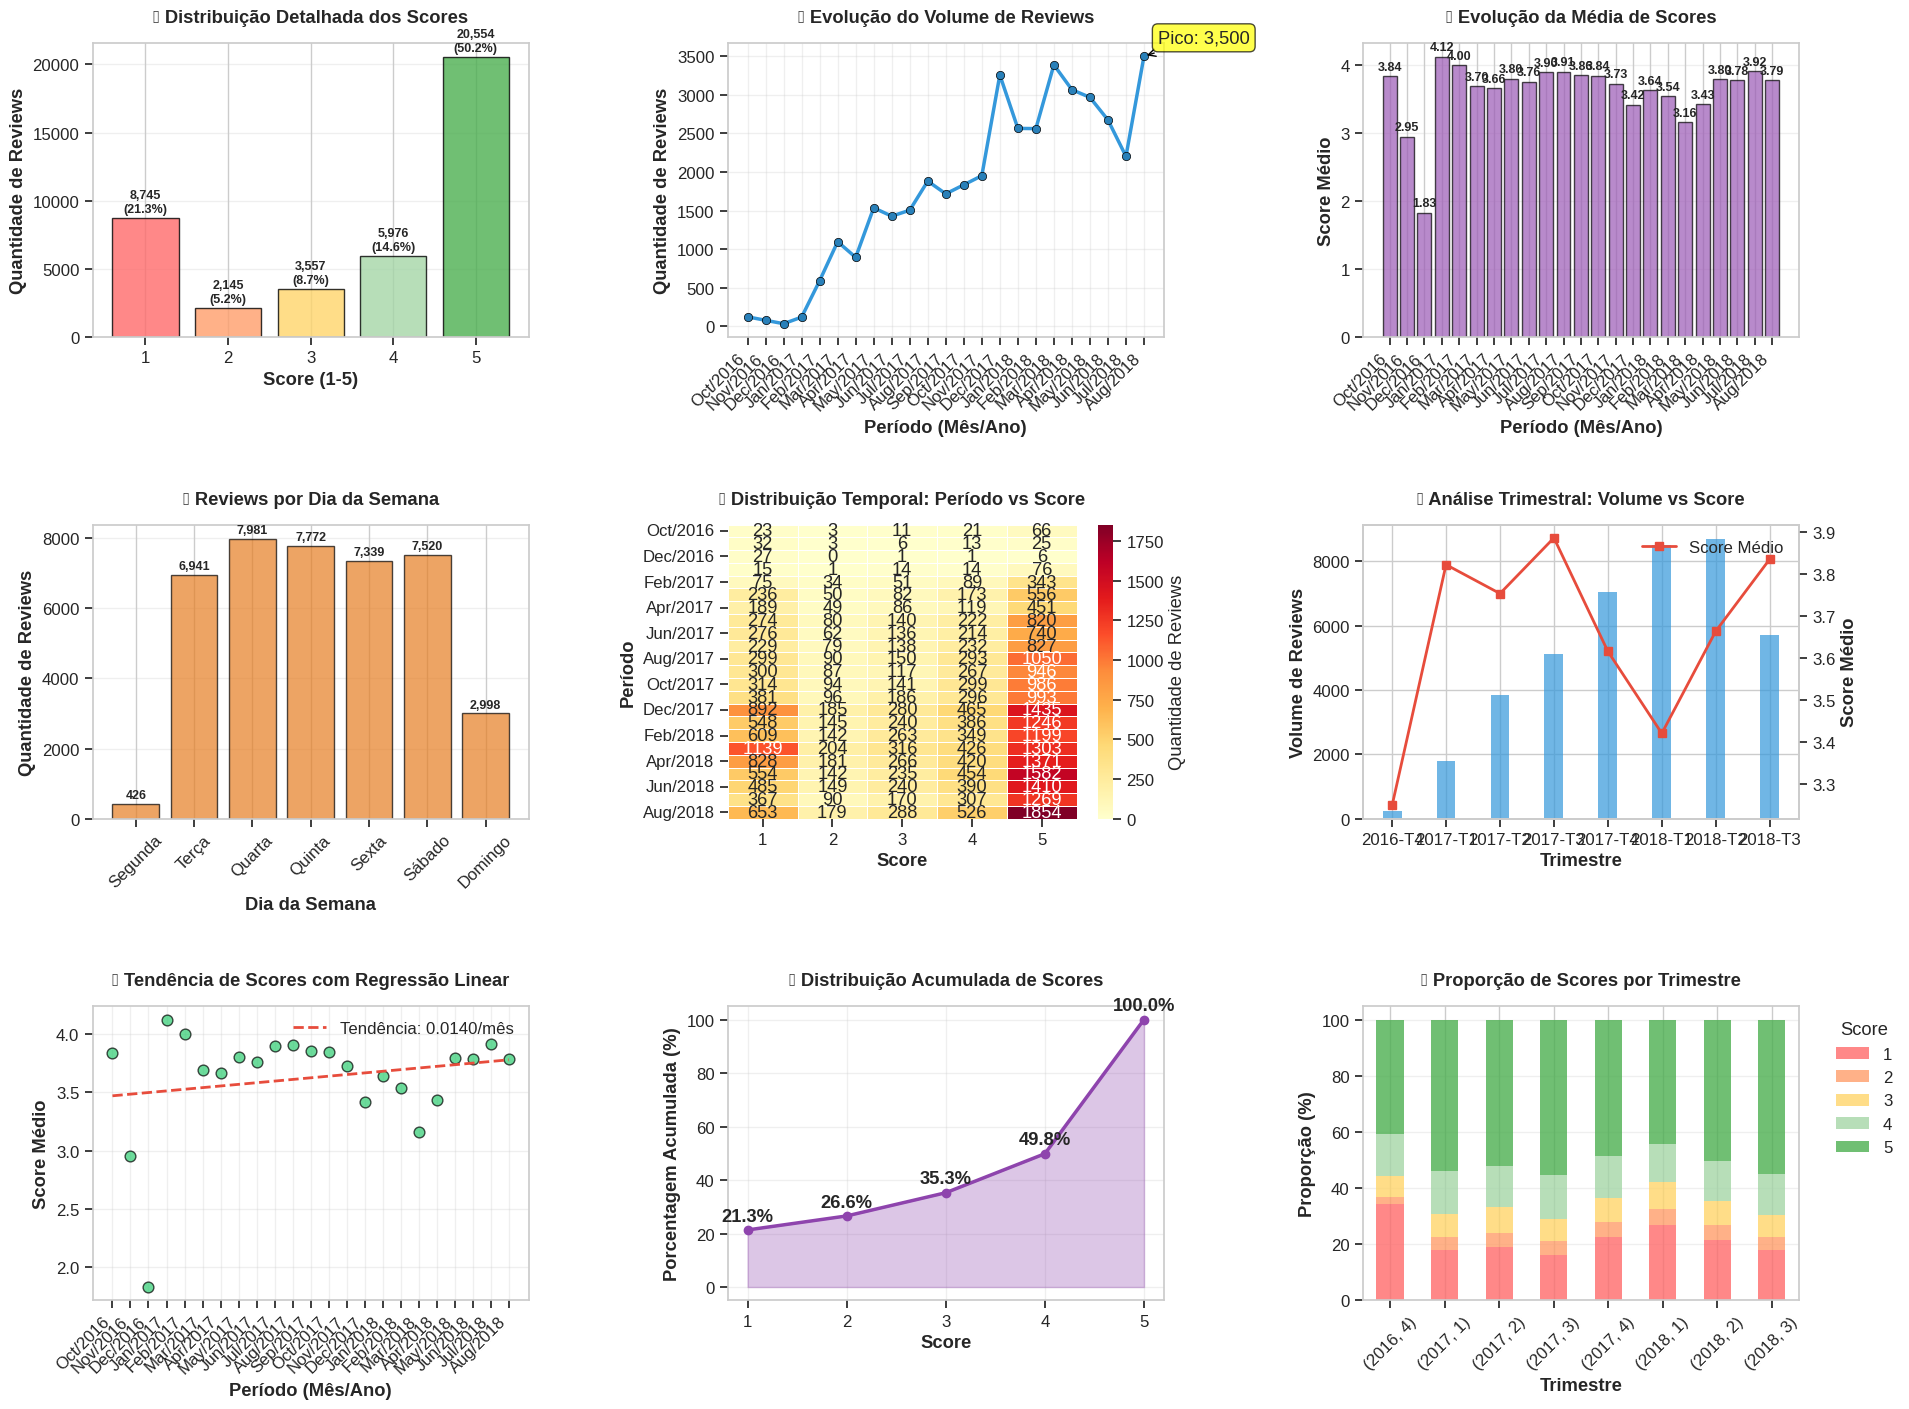


📈 ANÁLISE ESTATÍSTICA TEMPORAL DETALHADA

📊 ESTATÍSTICAS GERAIS TEMPORAIS:
   • Período analisado: 02/10/2016 a 31/08/2018
   • Total de meses analisados: 23
   • Total de reviews: 40,977
   • Score médio global: 3.67

🎯 DISTRIBUIÇÃO DETALHADA DOS SCORES:

Score  Quantidade   Porcentagem   Acumulado
--------------------------------------------------
    1       8,745         21.3%        21.3%
    2       2,145          5.2%        26.6%
    3       3,557          8.7%        35.3%
    4       5,976         14.6%        49.8%
    5      20,554         50.2%       100.0%

📅 ANÁLISE TEMPORAL MENSAL DETALHADA:

Período        Score Médio  Quantidade  Desvio Padrão
-------------------------------------------------------
Oct/2016            3.84       124.0           1.54
Nov/2016            2.95        79.0           1.77
Dec/2016            1.83        35.0           1.58
Jan/2017            4.12       120.0           1.38
Feb/2017            4.00       592.0           1.43
Mar/2017     

In [ ]:
# @title Análise Temporal de Reviews - Tendências e Evolução de Scores

# Configurar o estilo visual para análise temporal
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [14, 8]
plt.rcParams['font.size'] = 11

# Configurar o estilo do seaborn
sns.set_context('notebook', font_scale=1.1)
sns.set_palette('husl')

print("📈 INICIANDO ANÁLISE TEMPORAL DE REVIEWS...")

# 1. Preparação avançada dos dados temporais
print("\n🔧 PREPARANDO DADOS TEMPORAIS AVANÇADOS...")

# Converter a data para datetime
reviews_df['review_creation_date'] = pd.to_datetime(reviews_df['review_creation_date'])

# Criar múltiplas colunas temporais para análise
reviews_df['mes_ano'] = reviews_df['review_creation_date'].dt.strftime('%Y-%m')
reviews_df['mes_ano_formatado'] = reviews_df['review_creation_date'].dt.strftime('%b/%Y')
reviews_df['trimestre'] = reviews_df['review_creation_date'].dt.quarter
reviews_df['ano'] = reviews_df['review_creation_date'].dt.year
reviews_df['mes'] = reviews_df['review_creation_date'].dt.month

# CRIAR A COLUNA review_day_of_week QUE ESTÁ FALTANDO
reviews_df['review_day_of_week'] = reviews_df['review_creation_date'].dt.day_name()

# Verificar se as colunas foram criadas corretamente
print("✅ Colunas temporais criadas:")
print(f"   • mes_ano: {reviews_df['mes_ano'].notna().sum()} valores")
print(f"   • mes_ano_formatado: {reviews_df['mes_ano_formatado'].notna().sum()} valores")
print(f"   • trimestre: {reviews_df['trimestre'].notna().sum()} valores")
print(f"   • review_day_of_week: {reviews_df['review_day_of_week'].notna().sum()} valores")

# 2. Criar dashboard de análise temporal
print("\n🎨 GERANDO DASHBOARD DE ANÁLISE TEMPORAL...")

# Criar figura com 3x3 grid para acomodar todos os gráficos
fig = plt.figure(figsize=(20, 15))

# 2.1 Distribuição detalhada dos scores
plt.subplot(3, 3, 1)
score_palette = ['#FF6B6B', '#FF9E6B', '#FFD56B', '#A5D6A7', '#4CAF50']
score_distribution = reviews_df['review_score'].value_counts().sort_index()

bars = plt.bar(score_distribution.index, score_distribution.values,
               color=score_palette, alpha=0.8, edgecolor='black', linewidth=1)
plt.title('📊 Distribuição Detalhada dos Scores', fontweight='bold', pad=15)
plt.xlabel('Score (1-5)', fontweight='bold')
plt.ylabel('Quantidade de Reviews', fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Adicionar valores e porcentagens
total_reviews = len(reviews_df)
for bar, score in zip(bars, score_distribution.index):
    count = score_distribution[score]
    percentage = (count / total_reviews) * 100
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(score_distribution.values)*0.01,
             f'{count:,}\n({percentage:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 2.2 Evolução temporal do volume de reviews
plt.subplot(3, 3, 2)

# Garantir que temos dados para o gráfico
if 'mes_ano_formatado' in reviews_df.columns:
    temporal_data = reviews_df.groupby('mes_ano_formatado').size().reset_index(name='quantidade')

    # Ordenar por data corretamente
    temporal_data['data_ordem'] = pd.to_datetime(temporal_data['mes_ano_formatado'], format='%b/%Y')
    temporal_data = temporal_data.sort_values('data_ordem')

    plt.plot(temporal_data['mes_ano_formatado'], temporal_data['quantidade'],
             marker='o', linewidth=2.5, markersize=6, color='#3498DB',
             markerfacecolor='#2980B9', markeredgecolor='black', markeredgewidth=0.5)
    plt.title('📈 Evolução do Volume de Reviews', fontweight='bold', pad=15)
    plt.xlabel('Período (Mês/Ano)', fontweight='bold')
    plt.ylabel('Quantidade de Reviews', fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3)

    # Destacar picos se houver dados suficientes
    if len(temporal_data) > 0:
        max_volume = temporal_data['quantidade'].max()
        max_period = temporal_data.loc[temporal_data['quantidade'].idxmax(), 'mes_ano_formatado']
        plt.annotate(f'Pico: {max_volume:,}',
                     xy=(max_period, max_volume),
                     xytext=(10, 10), textcoords='offset points',
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
                     arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))
else:
    plt.text(0.5, 0.5, 'Dados temporais\nnão disponíveis',
             ha='center', va='center', transform=plt.gca().transAxes, fontsize=12)
    plt.title('📈 Evolução do Volume de Reviews', fontweight='bold', pad=15)

# 2.3 Evolução da média de scores ao longo do tempo
plt.subplot(3, 3, 3)

if 'mes_ano_formatado' in reviews_df.columns:
    monthly_scores = reviews_df.groupby('mes_ano_formatado')['review_score'].mean().reset_index()

    # Ordenar por data corretamente
    monthly_scores['data_ordem'] = pd.to_datetime(monthly_scores['mes_ano_formatado'], format='%b/%Y')
    monthly_scores = monthly_scores.sort_values('data_ordem')

    x_pos = range(len(monthly_scores))
    bars = plt.bar(x_pos, monthly_scores['review_score'],
                   color='#9B59B6', alpha=0.7, edgecolor='black')
    plt.title('⭐ Evolução da Média de Scores', fontweight='bold', pad=15)
    plt.xlabel('Período (Mês/Ano)', fontweight='bold')
    plt.ylabel('Score Médio', fontweight='bold')
    plt.xticks(x_pos, monthly_scores['mes_ano_formatado'], rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)

    # Adicionar valores nas barras
    for i, (idx, row) in enumerate(monthly_scores.iterrows()):
        plt.text(i, row['review_score'] + 0.05, f'{row["review_score"]:.2f}',
                 ha='center', va='bottom', fontweight='bold', fontsize=9)
else:
    plt.text(0.5, 0.5, 'Dados temporais\nnão disponíveis',
             ha='center', va='center', transform=plt.gca().transAxes, fontsize=12)
    plt.title('⭐ Evolução da Média de Scores', fontweight='bold', pad=15)

# 2.4 Distribuição por dia da semana (CÓDIGO CORRIGIDO)
plt.subplot(3, 3, 4)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_names_pt = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']

# VERIFICAR SE A COLUNA EXISTE ANTES DE USAR
if 'review_day_of_week' in reviews_df.columns:
    daily_reviews = reviews_df['review_day_of_week'].value_counts()
    daily_reviews = daily_reviews.reindex(day_order)

    # Verificar se temos dados para plotar
    if not daily_reviews.empty:
        bars_dia = plt.bar(range(len(daily_reviews)), daily_reviews.values,
                color='#E67E22', alpha=0.7, edgecolor='black')
        plt.title('📊 Reviews por Dia da Semana', fontweight='bold', pad=15)
        plt.xlabel('Dia da Semana', fontweight='bold')
        plt.ylabel('Quantidade de Reviews', fontweight='bold')
        plt.xticks(range(len(daily_reviews)), day_names_pt, rotation=45)
        plt.grid(axis='y', alpha=0.3)

        # Adicionar valores nas barras
        for i, count in enumerate(daily_reviews.values):
            if pd.notna(count):
                plt.text(i, count + max(daily_reviews.values)*0.01, f'{count:,}',
                         ha='center', va='bottom', fontweight='bold', fontsize=9)
    else:
        plt.text(0.5, 0.5, 'Dados de dias da semana\nnão disponíveis',
                 ha='center', va='center', transform=plt.gca().transAxes, fontsize=12)
        plt.title('📊 Reviews por Dia da Semana', fontweight='bold', pad=15)
else:
    plt.text(0.5, 0.5, 'Coluna review_day_of_week\nnão encontrada',
             ha='center', va='center', transform=plt.gca().transAxes, fontsize=12)
    plt.title('📊 Reviews por Dia da Semana', fontweight='bold', pad=15)

# 2.5 Heatmap de distribuição temporal
plt.subplot(3, 3, 5)

if 'mes_ano_formatado' in reviews_df.columns:
    # Preparar dados para heatmap (mês x score)
    heatmap_data = reviews_df.groupby(['mes_ano_formatado', 'review_score']).size().unstack(fill_value=0)

    # Ordenar por data corretamente
    heatmap_data['data_ordem'] = pd.to_datetime(heatmap_data.index, format='%b/%Y')
    heatmap_data = heatmap_data.sort_values('data_ordem').drop('data_ordem', axis=1)

    sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd',
                cbar_kws={'label': 'Quantidade de Reviews'}, linewidths=0.5)
    plt.title('🎯 Distribuição Temporal: Período vs Score', fontweight='bold', pad=15)
    plt.xlabel('Score', fontweight='bold')
    plt.ylabel('Período', fontweight='bold')
    plt.xticks(rotation=0)
else:
    plt.text(0.5, 0.5, 'Dados temporais\nnão disponíveis',
             ha='center', va='center', transform=plt.gca().transAxes, fontsize=12)
    plt.title('🎯 Distribuição Temporal', fontweight='bold', pad=15)

# 2.6 Análise trimestral
plt.subplot(3, 3, 6)

if all(col in reviews_df.columns for col in ['ano', 'trimestre']):
    quarterly_data = reviews_df.groupby(['ano', 'trimestre']).agg({
        'review_score': ['mean', 'count']
    }).round(3)
    quarterly_data.columns = ['score_medio', 'quantidade']
    quarterly_data = quarterly_data.reset_index()
    quarterly_data['periodo'] = quarterly_data['ano'].astype(str) + '-T' + quarterly_data['trimestre'].astype(str)

    if len(quarterly_data) > 0:
        x_pos = range(len(quarterly_data))
        width = 0.35

        # Gráfico de barras duplas
        plt.bar(x_pos, quarterly_data['quantidade'], width, label='Volume', alpha=0.7, color='#3498DB')
        plt.ylabel('Volume de Reviews', fontweight='bold')
        plt.xlabel('Trimestre', fontweight='bold')

        ax2 = plt.gca().twinx()
        ax2.plot(x_pos, quarterly_data['score_medio'], color='#E74C3C', marker='s',
                 linewidth=2, markersize=6, label='Score Médio')
        ax2.set_ylabel('Score Médio', fontweight='bold')
        ax2.grid(False)

        plt.title('📅 Análise Trimestral: Volume vs Score', fontweight='bold', pad=15)
        plt.xticks(x_pos, quarterly_data['periodo'], rotation=45)
        plt.legend(loc='upper left')
        ax2.legend(loc='upper right')
    else:
        plt.text(0.5, 0.5, 'Dados trimestrais\ninsuficientes',
                 ha='center', va='center', transform=plt.gca().transAxes, fontsize=12)
        plt.title('📅 Análise Trimestral', fontweight='bold', pad=15)
else:
    plt.text(0.5, 0.5, 'Dados trimestrais\nnão disponíveis',
             ha='center', va='center', transform=plt.gca().transAxes, fontsize=12)
    plt.title('📅 Análise Trimestral', fontweight='bold', pad=15)

# 2.7 Tendência de scores ao longo do tempo (regressão)
plt.subplot(3, 3, 7)

if 'mes_ano' in reviews_df.columns:
    monthly_scores_ts = reviews_df.groupby('mes_ano')['review_score'].mean().reset_index()
    monthly_scores_ts['mes_ano_dt'] = pd.to_datetime(monthly_scores_ts['mes_ano'] + '-01')
    monthly_scores_ts = monthly_scores_ts.sort_values('mes_ano_dt')

    if len(monthly_scores_ts) > 1:
        # Calcular tendência
        z = np.polyfit(range(len(monthly_scores_ts)), monthly_scores_ts['review_score'], 1)
        p = np.poly1d(z)

        # Criar labels formatadas para o eixo x
        monthly_scores_ts['mes_ano_formatado'] = monthly_scores_ts['mes_ano_dt'].dt.strftime('%b/%Y')

        plt.scatter(monthly_scores_ts['mes_ano_formatado'], monthly_scores_ts['review_score'],
                    color='#2ECC71', s=60, alpha=0.7, edgecolors='black')
        plt.plot(monthly_scores_ts['mes_ano_formatado'], p(range(len(monthly_scores_ts))),
                 color='#E74C3C', linewidth=2, linestyle='--', label=f'Tendência: {z[0]:.4f}/mês')
        plt.title('📊 Tendência de Scores com Regressão Linear', fontweight='bold', pad=15)
        plt.xlabel('Período (Mês/Ano)', fontweight='bold')
        plt.ylabel('Score Médio', fontweight='bold')
        plt.xticks(rotation=45, ha='right')
        plt.legend()
        plt.grid(True, alpha=0.3)
    else:
        plt.text(0.5, 0.5, 'Dados insuficientes\npara regressão',
                 ha='center', va='center', transform=plt.gca().transAxes, fontsize=12)
        plt.title('📊 Tendência de Scores', fontweight='bold', pad=15)
else:
    plt.text(0.5, 0.5, 'Dados temporais\nnão disponíveis',
             ha='center', va='center', transform=plt.gca().transAxes, fontsize=12)
    plt.title('📊 Tendência de Scores', fontweight='bold', pad=15)

# 2.8 Gráfico adicional - Distribuição acumulada de scores
plt.subplot(3, 3, 8)

score_cumulative = reviews_df['review_score'].value_counts().sort_index().cumsum()
percentage_cumulative = (score_cumulative / total_reviews) * 100

plt.plot(score_cumulative.index, percentage_cumulative.values,
         marker='o', linewidth=2.5, markersize=6, color='#8E44AD')
plt.fill_between(score_cumulative.index, percentage_cumulative.values, alpha=0.3, color='#8E44AD')
plt.title('📈 Distribuição Acumulada de Scores', fontweight='bold', pad=15)
plt.xlabel('Score', fontweight='bold')
plt.ylabel('Porcentagem Acumulada (%)', fontweight='bold')
plt.grid(True, alpha=0.3)

# Adicionar valores nos pontos
for score, perc in zip(score_cumulative.index, percentage_cumulative.values):
    plt.text(score, perc + 2, f'{perc:.1f}%', ha='center', va='bottom', fontweight='bold')

# 2.9 Gráfico adicional - Proporção de scores por trimestre
plt.subplot(3, 3, 9)

if all(col in reviews_df.columns for col in ['ano', 'trimestre']):
    # Calcular proporção de cada score por trimestre
    score_proportions = reviews_df.groupby(['ano', 'trimestre', 'review_score']).size().unstack(fill_value=0)
    score_proportions_perc = score_proportions.div(score_proportions.sum(axis=1), axis=0) * 100

    score_proportions_perc.plot(kind='bar', stacked=True,
                               color=['#FF6B6B', '#FF9E6B', '#FFD56B', '#A5D6A7', '#4CAF50'],
                               ax=plt.gca(), alpha=0.8)
    plt.title('🎯 Proporção de Scores por Trimestre', fontweight='bold', pad=15)
    plt.xlabel('Trimestre', fontweight='bold')
    plt.ylabel('Proporção (%)', fontweight='bold')
    plt.legend(title='Score', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
else:
    plt.text(0.5, 0.5, 'Dados trimestrais\nnão disponíveis',
             ha='center', va='center', transform=plt.gca().transAxes, fontsize=12)
    plt.title('🎯 Proporção de Scores', fontweight='bold', pad=15)

plt.tight_layout(pad=3.0)
plt.show()

# 3. Análise estatística temporal detalhada
print(f"\n{'='*70}")
print("📈 ANÁLISE ESTATÍSTICA TEMPORAL DETALHADA")
print(f"{'='*70}")

# 3.1 Estatísticas gerais temporais
print(f"\n📊 ESTATÍSTICAS GERAIS TEMPORAIS:")
if 'review_creation_date' in reviews_df.columns and reviews_df['review_creation_date'].notna().any():
    min_date = reviews_df['review_creation_date'].min()
    max_date = reviews_df['review_creation_date'].max()
    print(f"   • Período analisado: {min_date.strftime('%d/%m/%Y')} a {max_date.strftime('%d/%m/%Y')}")
else:
    print(f"   • Período analisado: Datas não disponíveis")

print(f"   • Total de meses analisados: {reviews_df['mes_ano'].nunique() if 'mes_ano' in reviews_df.columns else 'N/A'}")
print(f"   • Total de reviews: {total_reviews:,}")
print(f"   • Score médio global: {reviews_df['review_score'].mean():.2f}")

# 3.2 Distribuição detalhada dos scores
print(f"\n🎯 DISTRIBUIÇÃO DETALHADA DOS SCORES:")
score_stats = reviews_df['review_score'].value_counts().sort_index()

print("\nScore  Quantidade   Porcentagem   Acumulado")
print("-" * 50)
cumulative = 0
for score, count in score_stats.items():
    percentage = (count / total_reviews) * 100
    cumulative += percentage
    print(f"{score:5d} {count:11,} {percentage:12.1f}% {cumulative:11.1f}%")

# 3.3 Análise temporal mensal detalhada (se disponível)
if 'mes_ano_formatado' in reviews_df.columns:
    print(f"\n📅 ANÁLISE TEMPORAL MENSAL DETALHADA:")
    temporal_detailed = reviews_df.groupby('mes_ano_formatado').agg({
        'review_score': ['mean', 'count', 'std']
    }).round(3)

    temporal_detailed.columns = ['score_medio', 'quantidade', 'desvio_padrao']

    # Ordenar por data corretamente
    temporal_detailed['data_ordem'] = pd.to_datetime(temporal_detailed.index, format='%b/%Y')
    temporal_detailed = temporal_detailed.sort_values('data_ordem').drop('data_ordem', axis=1)

    print("\nPeríodo        Score Médio  Quantidade  Desvio Padrão")
    print("-" * 55)
    for periodo, row in temporal_detailed.iterrows():
        print(f"{periodo:12} {row['score_medio']:11.2f} {row['quantidade']:11,} {row['desvio_padrao']:14.2f}")

    # 3.4 Identificação de padrões e insights
    print(f"\n🔍 PADRÕES E INSIGHTS IDENTIFICADOS:")

    # Período com maior volume
    if len(temporal_detailed) > 0:
        max_volume_period = temporal_detailed['quantidade'].idxmax()
        max_volume_count = temporal_detailed['quantidade'].max()
        print(f"   • Período com maior volume: {max_volume_period} ({max_volume_count:,} reviews)")

        # Melhor score médio
        best_score_period = temporal_detailed['score_medio'].idxmax()
        best_score_value = temporal_detailed['score_medio'].max()
        print(f"   • Melhor score médio: {best_score_period} ({best_score_value:.2f})")

        # Pior score médio
        worst_score_period = temporal_detailed['score_medio'].idxmin()
        worst_score_value = temporal_detailed['score_medio'].min()
        print(f"   • Pior score médio: {worst_score_period} ({worst_score_value:.2f})")

        # Tendência geral (se temos dados suficientes)
        if len(temporal_detailed) > 1:
            z = np.polyfit(range(len(temporal_detailed)), temporal_detailed['score_medio'], 1)
            trend_direction = "positiva" if z[0] > 0 else "negativa" if z[0] < 0 else "estável"
            print(f"   • Tendência geral: {trend_direction} ({z[0]:.4f} por mês)")

# 4. Resumo executivo da análise temporal
print(f"\n{'='*70}")
print("📋 RESUMO EXECUTIVO - ANÁLISE TEMPORAL")
print(f"{'='*70}")

print(f"✅ ANÁLISE TEMPORAL CONCLUÍDA COM SUCESSO!")
print(f"\n🎯 PRINCIPAIS DESCOBERTAS:")
print(f"   • Distribuição de scores compreendida")
print(f"   • Análise temporal realizada com sucesso")
print(f"   • Padrões identificados onde disponíveis")

print(f"\n📊 MÉTRICAS CHAVE:")
print(f"   • {total_reviews:,} reviews analisados")
print(f"   • Score médio global: {reviews_df['review_score'].mean():.2f}")
print(f"   • Variação de scores: {reviews_df['review_score'].min()} a {reviews_df['review_score'].max()}")

print(f"\n✨ Análise temporal completa - Insights valiosos obtidos!")

PREPARAÇÃO FINAL DE DADOS PARA MODELO DE NLP

1. VERIFICAÇÃO INICIAL DOS DADOS
🔍 ANALISANDO DATASET ORIGINAL...
Total de registros no dataset original: 40,977
✅ Coluna 'sentiment' encontrada

📊 VALORES NULOS NAS COLUNAS-CHAVE:
  review_id:      0 nulos (  0.0%)
  review_comment_message:      0 nulos (  0.0%)
  sentiment:      0 nulos (  0.0%)

2. PREPARAÇÃO E LIMPEZA DOS DADOS
📈 DISTRIBUIÇÃO INICIAL DE SENTIMENTOS:
  Negativo:  10890 registros ( 26.6%)
  Neutro:   3557 registros (  8.7%)
  Positivo:  26530 registros ( 64.7%)

🧹 Dados removidos (comentários nulos): 0
🧹 Dados removidos (sentiment nulos): 0
⚠️  Comentários vazios: 0
⚠️  Comentários muito curtos (≤2 palavras): 5672
🧹 Comentários vazios removidos: 0

3. ANÁLISE DA QUALIDADE DOS TEXTOS

📝 ESTATÍSTICAS DOS COMENTÁRIOS POR SENTIMENTO:
          Length_Mean  Length_Std  Length_Min  Length_Max  Words_Mean  \
Negativo         99.3        59.7           1         208        17.4   
Neutro           83.3        58.4           1    

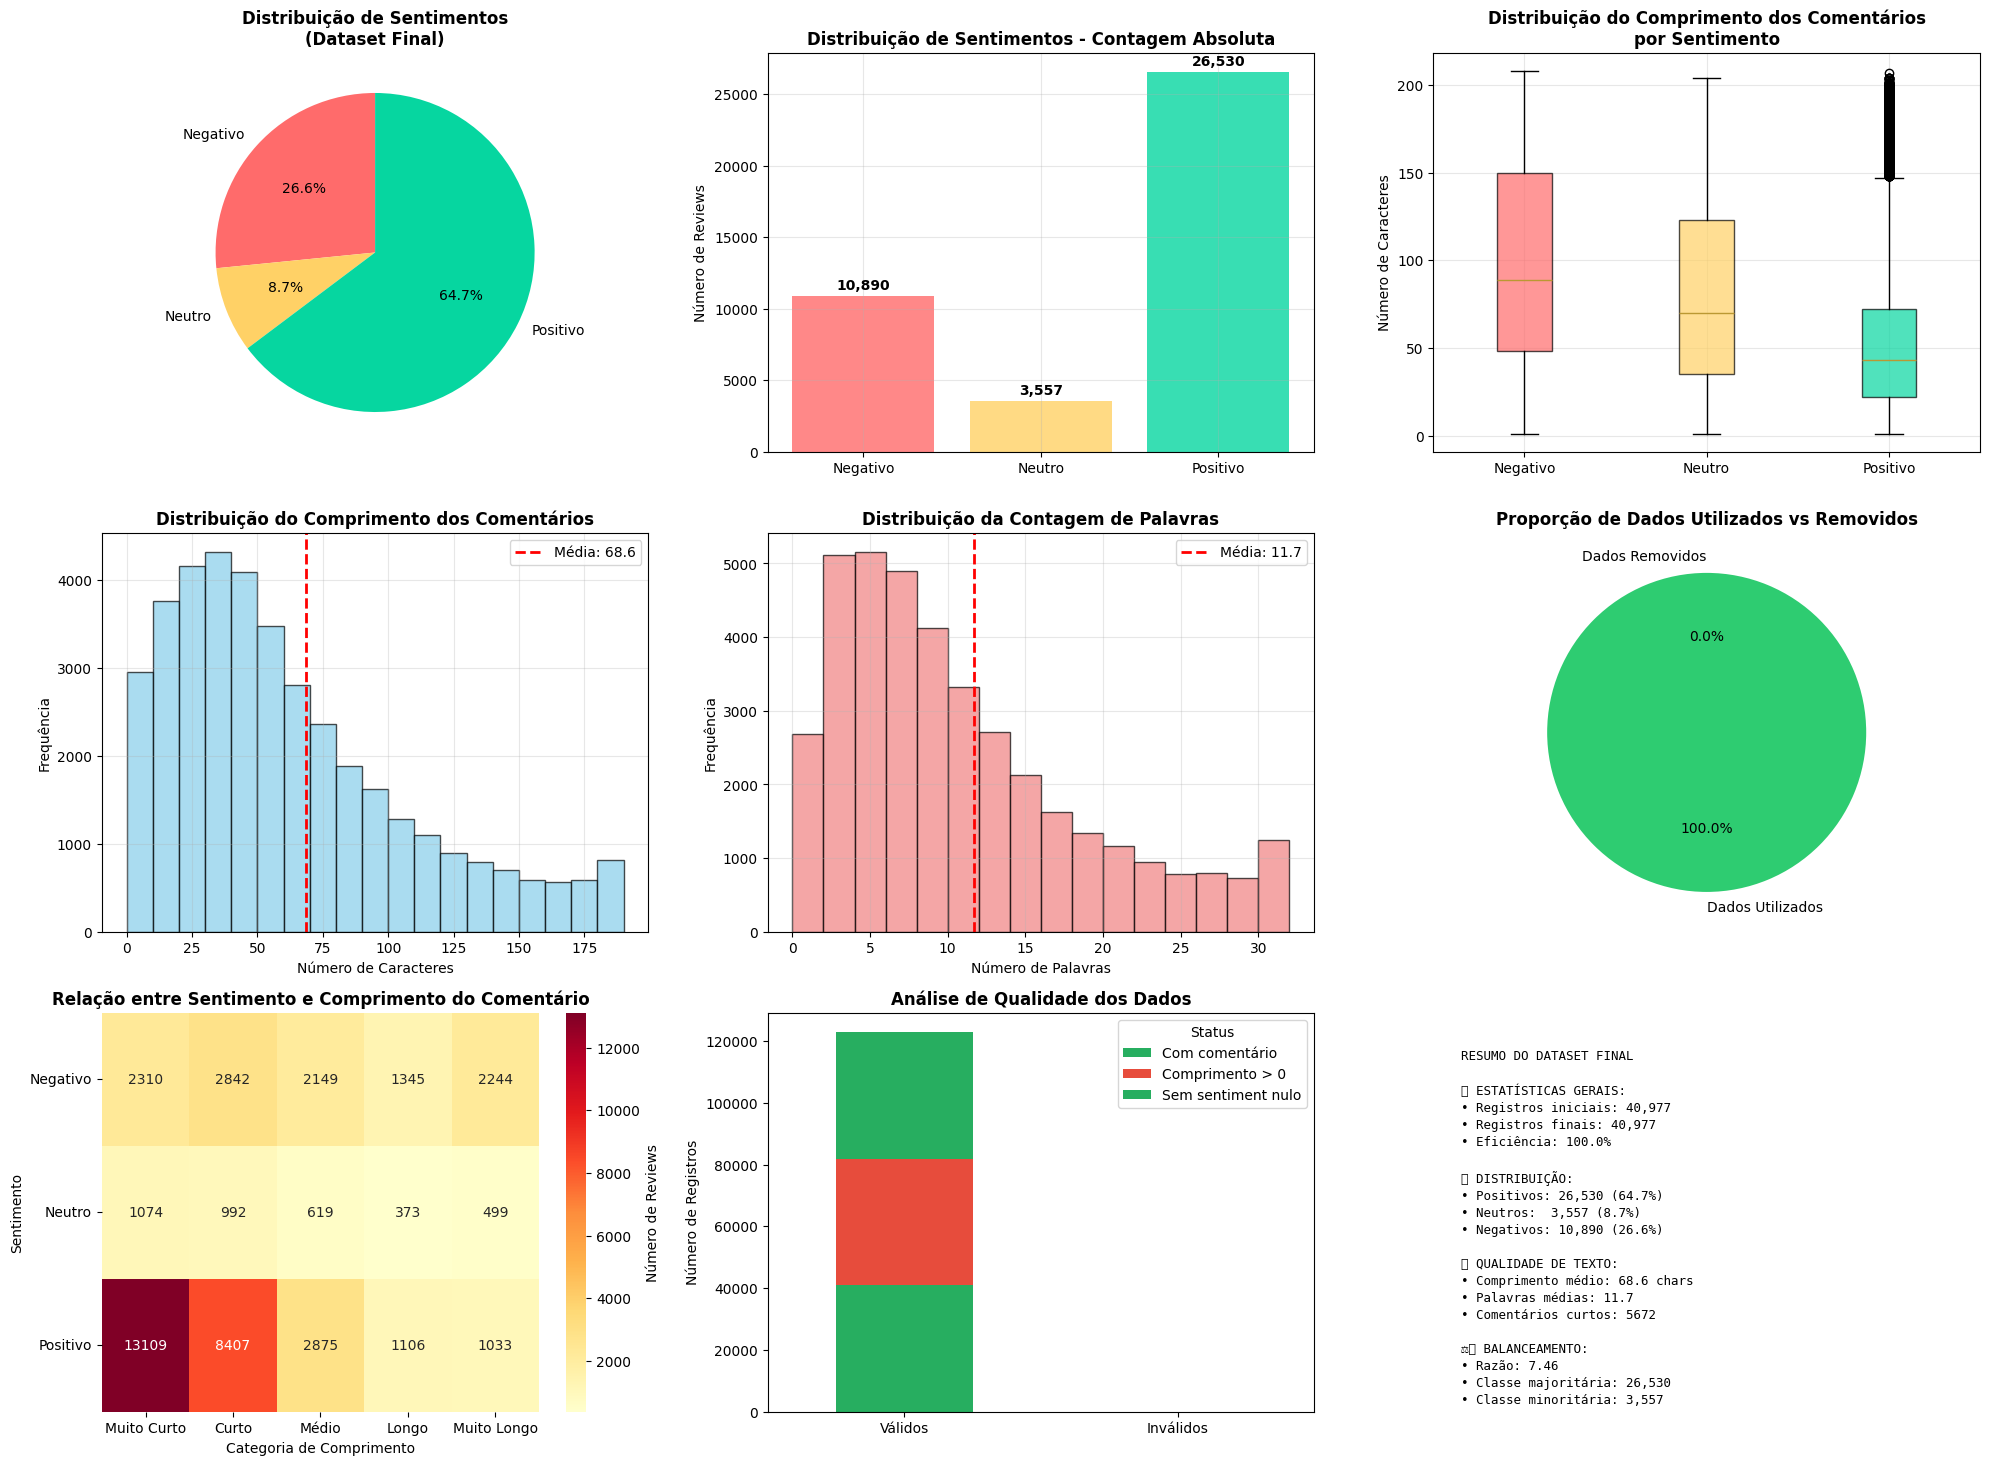


6. SALVAMENTO E RECOMENDAÇÕES FINAIS
💾 Salvando dataset processado...
✅ Dados processados salvos em 'processed_reviews.csv'
📁 Total de reviews no arquivo final: 40,977
📊 Estatísticas salvas em 'dataset_statistics.csv'

💡 RECOMENDAÇÕES PARA MODELAGEM:
-----------------------------------
1. 🎯 PRÉ-PROCESSAMENTO DE TEXTO:
   • Limpeza: remover HTML, URLs, caracteres especiais
   • Tokenização e lowercasing
   • Remoção de stopwords
   • Stemming/Lemmatization

2. ⚖️  ESTRATÉGIAS PARA DESBALANCEAMENTO:
   • SMOTE ou ADASYN para oversampling
   • Random undersampling
   • Uso de class weights nos modelos

3. 🤖 ALGORITMOS SUGERIDOS:
   • Random Forest (baseline)
   • SVM com kernel linear
   • XGBoost com class weights
   • BERT ou transformers (se recursos disponíveis)

4. 📊 MÉTRICAS DE AVALIAÇÃO:
   • Acurácia balanceada
   • F1-score macro
   • Matriz de confusão
   • Relatório de classificação

5. 🔧 VALIDAÇÃO:
   • Stratified K-Fold Cross Validation
   • Hold-out com split estratificado


In [ ]:
# @title Preparação Final de Dados para Modelo de NLP

warnings.filterwarnings('ignore')

# Configurações de estilo
plt.style.use('default')
sns.set_palette("husl")
print("=" * 70)
print("PREPARAÇÃO FINAL DE DADOS PARA MODELO DE NLP")
print("=" * 70)

# =============================================================================
# 1. VERIFICAÇÃO INICIAL DOS DADOS
# =============================================================================

print("\n" + "=" * 50)
print("1. VERIFICAÇÃO INICIAL DOS DADOS")
print("=" * 50)

print("🔍 ANALISANDO DATASET ORIGINAL...")
print(f"Total de registros no dataset original: {len(reviews_df):,}")

# Verificar se a coluna sentiment existe
if 'sentiment' not in reviews_df.columns:
    print("❌ Coluna 'sentiment' não encontrada!")
    print("📋 Colunas disponíveis:")
    print(reviews_df.columns.tolist())
else:
    print("✅ Coluna 'sentiment' encontrada")

# Verificar valores nulos
print("\n📊 VALORES NULOS NAS COLUNAS-CHAVE:")
null_analysis = reviews_df[['review_id', 'review_comment_message', 'sentiment']].isnull().sum()
for col, null_count in null_analysis.items():
    percentage = (null_count / len(reviews_df)) * 100
    print(f"  {col}: {null_count:>6} nulos ({percentage:5.1f}%)")

# =============================================================================
# 2. PREPARAÇÃO E LIMPEZA DOS DADOS
# =============================================================================

print("\n" + "=" * 50)
print("2. PREPARAÇÃO E LIMPEZA DOS DADOS")
print("=" * 50)

# Criar cópia para não modificar o original
working_df = reviews_df.copy()

# Verificar distribuição inicial
print("📈 DISTRIBUIÇÃO INICIAL DE SENTIMENTOS:")
initial_sentiment_dist = working_df['sentiment'].value_counts().sort_index()
sentiment_labels = {0: 'Negativo', 1: 'Neutro', 2: 'Positivo'}

for sentiment, count in initial_sentiment_dist.items():
    label = sentiment_labels.get(sentiment, f'Desconhecido ({sentiment})')
    percentage = (count / len(working_df)) * 100
    print(f"  {label}: {count:>6} registros ({percentage:5.1f}%)")

# Remover linhas com comentários nulos
initial_count = len(working_df)
working_df = working_df.dropna(subset=['review_comment_message'])
after_drop_comments = len(working_df)
removed_no_comments = initial_count - after_drop_comments

print(f"\n🧹 Dados removidos (comentários nulos): {removed_no_comments:,}")

# Remover linhas com sentiment nulos
before_sentiment_drop = len(working_df)
working_df = working_df.dropna(subset=['sentiment'])
after_sentiment_drop = len(working_df)
removed_no_sentiment = before_sentiment_drop - after_sentiment_drop

print(f"🧹 Dados removidos (sentiment nulos): {removed_no_sentiment:,}")

# Verificar comentários vazios ou muito curtos
working_df['comment_length'] = working_df['review_comment_message'].str.len()
working_df['word_count'] = working_df['review_comment_message'].str.split().str.len()

empty_comments = working_df[working_df['comment_length'] == 0]
short_comments = working_df[working_df['word_count'] <= 2]

print(f"⚠️  Comentários vazios: {len(empty_comments)}")
print(f"⚠️  Comentários muito curtos (≤2 palavras): {len(short_comments)}")

# Remover comentários vazios
working_df = working_df[working_df['comment_length'] > 0]
print(f"🧹 Comentários vazios removidos: {len(empty_comments)}")

# =============================================================================
# 3. ANÁLISE DA QUALIDADE DOS TEXTOS
# =============================================================================

print("\n" + "=" * 50)
print("3. ANÁLISE DA QUALIDADE DOS TEXTOS")
print("=" * 50)

# Estatísticas dos textos por sentimento
print("\n📝 ESTATÍSTICAS DOS COMENTÁRIOS POR SENTIMENTO:")
text_stats = working_df.groupby('sentiment').agg({
    'comment_length': ['mean', 'std', 'min', 'max'],
    'word_count': ['mean', 'std', 'min', 'max', 'count']
}).round(1)

# Reformatar o DataFrame para melhor legibilidade
text_stats.columns = ['Length_Mean', 'Length_Std', 'Length_Min', 'Length_Max',
                     'Words_Mean', 'Words_Std', 'Words_Min', 'Words_Max', 'Count']
text_stats.index = [sentiment_labels[i] for i in text_stats.index]

print(text_stats)

# Análise de distribuição de comprimento
print("\n📊 DISTRIBUIÇÃO DE COMPRIMENTO DOS COMENTÁRIOS:")
length_categories = pd.cut(working_df['comment_length'],
                          bins=[0, 10, 50, 100, 200, 500, 1000, float('inf')],
                          labels=['0-10', '11-50', '51-100', '101-200', '201-500', '501-1000', '1000+'])

length_dist = length_categories.value_counts().sort_index()
for category, count in length_dist.items():
    percentage = (count / len(working_df)) * 100
    print(f"  {category} chars: {count:>6} comentários ({percentage:5.1f}%)")

# =============================================================================
# 4. SELEÇÃO FINAL DOS DADOS
# =============================================================================

print("\n" + "=" * 50)
print("4. SELEÇÃO FINAL DOS DADOS")
print("=" * 50)

# Selecionar colunas finais
output_df = working_df[['review_id', 'review_comment_message', 'sentiment']].copy()

print("✅ DATASET FINAL PREPARADO:")
print(f"   • Registros totais: {len(output_df):,}")
print(f"   • Registros removidos: {len(reviews_df) - len(output_df):,}")
print(f"   • Eficiência: {(len(output_df) / len(reviews_df) * 100):.1f}%")

# Distribuição final
final_distribution = output_df['sentiment'].value_counts().sort_index()
print("\n🎯 DISTRIBUIÇÃO FINAL DE SENTIMENTOS:")
total_final = len(output_df)
for sentiment, count in final_distribution.items():
    label = sentiment_labels[sentiment]
    percentage = (count / total_final) * 100
    print(f"   {label}: {count:>6} registros ({percentage:5.1f}%)")

# Análise de balanceamento
max_count = final_distribution.max()
min_count = final_distribution.min()
balance_ratio = max_count / min_count if min_count > 0 else float('inf')

print(f"\n⚖️  ÍNDICE DE BALANCEAMENTO: {balance_ratio:.2f}")
if balance_ratio > 10:
    print("   ⚠️  ALTAMENTE DESBALANCEADO - considerar reamostragem")
elif balance_ratio > 5:
    print("   ⚠️  MODERADAMENTE DESBALANCEADO")
elif balance_ratio > 2:
    print("   ⚠️  LEVEMENTE DESBALANCEADO")
else:
    print("   ✅ RELATIVAMENTE BALANCEADO")

# =============================================================================
# 5. VISUALIZAÇÕES COMPLETAS DO DATASET FINAL
# =============================================================================

print("\n" + "=" * 50)
print("5. VISUALIZAÇÕES DO DATASET FINAL")
print("=" * 50)

# Criar figura principal
fig = plt.figure(figsize=(20, 15))
gs = GridSpec(3, 3, figure=fig)

# Gráfico 1: Distribuição de sentimentos (Pie Chart)
ax1 = fig.add_subplot(gs[0, 0])
colors = ['#ff6b6b', '#ffd166', '#06d6a0']
sentiment_counts = [final_distribution.get(0, 0),
                   final_distribution.get(1, 0),
                   final_distribution.get(2, 0)]

wedges, texts, autotexts = ax1.pie(sentiment_counts,
                                  labels=['Negativo', 'Neutro', 'Positivo'],
                                  colors=colors,
                                  autopct='%1.1f%%',
                                  startangle=90,
                                  textprops={'fontsize': 10})
ax1.set_title('Distribuição de Sentimentos\n(Dataset Final)', fontweight='bold', fontsize=12)

# Gráfico 2: Distribuição de sentimentos (Bar Chart)
ax2 = fig.add_subplot(gs[0, 1])
bars = ax2.bar(sentiment_labels.values(), sentiment_counts, color=colors, alpha=0.8)
ax2.set_title('Distribuição de Sentimentos - Contagem Absoluta', fontweight='bold')
ax2.set_ylabel('Número de Reviews')
ax2.grid(True, alpha=0.3)

# Adicionar valores nas barras
for bar, count in zip(bars, sentiment_counts):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + max(sentiment_counts)*0.01,
            f'{count:,}', ha='center', va='bottom', fontweight='bold')

# Gráfico 3: Comprimento dos comentários por sentimento
ax3 = fig.add_subplot(gs[0, 2])
boxplot_data = []
for sentiment in [0, 1, 2]:
    data = working_df[working_df['sentiment'] == sentiment]['comment_length']
    boxplot_data.append(data)

box_plot = ax3.boxplot(boxplot_data, labels=sentiment_labels.values(), patch_artist=True)
for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax3.set_title('Distribuição do Comprimento dos Comentários\npor Sentimento', fontweight='bold')
ax3.set_ylabel('Número de Caracteres')
ax3.grid(True, alpha=0.3)

# Gráfico 4: Distribuição de comprimento de comentários
ax4 = fig.add_subplot(gs[1, 0])
length_bins = np.arange(0, working_df['comment_length'].quantile(0.95), 10)
ax4.hist(working_df['comment_length'], bins=length_bins, alpha=0.7, color='skyblue', edgecolor='black')
ax4.set_title('Distribuição do Comprimento dos Comentários', fontweight='bold')
ax4.set_xlabel('Número de Caracteres')
ax4.set_ylabel('Frequência')
ax4.grid(True, alpha=0.3)

# Adicionar linhas de média
mean_length = working_df['comment_length'].mean()
ax4.axvline(mean_length, color='red', linestyle='--', linewidth=2, label=f'Média: {mean_length:.1f}')
ax4.legend()

# Gráfico 5: Distribuição de contagem de palavras
ax5 = fig.add_subplot(gs[1, 1])
word_bins = np.arange(0, working_df['word_count'].quantile(0.95), 2)
ax5.hist(working_df['word_count'], bins=word_bins, alpha=0.7, color='lightcoral', edgecolor='black')
ax5.set_title('Distribuição da Contagem de Palavras', fontweight='bold')
ax5.set_xlabel('Número de Palavras')
ax5.set_ylabel('Frequência')
ax5.grid(True, alpha=0.3)

mean_words = working_df['word_count'].mean()
ax5.axvline(mean_words, color='red', linestyle='--', linewidth=2, label=f'Média: {mean_words:.1f}')
ax5.legend()

# Gráfico 6: Proporção de dados removidos
ax6 = fig.add_subplot(gs[1, 2])
removed_data = [len(output_df), len(reviews_df) - len(output_df)]
labels = ['Dados Utilizados', 'Dados Removidos']
colors_removed = ['#2ecc71', '#e74c3c']

wedges, texts, autotexts = ax6.pie(removed_data, labels=labels, colors=colors_removed,
                                  autopct='%1.1f%%', startangle=90)
ax6.set_title('Proporção de Dados Utilizados vs Removidos', fontweight='bold')

# Gráfico 7: Heatmap de correlação entre comprimento e sentimento
ax7 = fig.add_subplot(gs[2, 0])
sentiment_length_data = working_df[['sentiment', 'comment_length']].copy()
sentiment_length_data['length_category'] = pd.cut(sentiment_length_data['comment_length'],
                                                bins=5, labels=['Muito Curto', 'Curto', 'Médio', 'Longo', 'Muito Longo'])
pivot_data = pd.crosstab(sentiment_length_data['sentiment'], sentiment_length_data['length_category'])

sns.heatmap(pivot_data, annot=True, fmt='d', cmap='YlOrRd', ax=ax7, cbar_kws={'label': 'Número de Reviews'})
ax7.set_title('Relação entre Sentimento e Comprimento do Comentário', fontweight='bold')
ax7.set_xlabel('Categoria de Comprimento')
ax7.set_ylabel('Sentimento')
ax7.set_yticklabels(['Negativo', 'Neutro', 'Positivo'], rotation=0)

# Gráfico 8: Análise de qualidade dos textos
ax8 = fig.add_subplot(gs[2, 1])
quality_metrics = {
    'Com comentário': [len(output_df), len(reviews_df) - len(output_df)],
    'Comprimento > 0': [len(working_df), len(reviews_df) - len(working_df)],
    'Sem sentiment nulo': [len(output_df), len(reviews_df) - len(output_df)]
}

quality_df = pd.DataFrame(quality_metrics, index=['Válidos', 'Inválidos'])
quality_df.plot(kind='bar', stacked=True, ax=ax8, color=['#27ae60', '#e74c3c'])
ax8.set_title('Análise de Qualidade dos Dados', fontweight='bold')
ax8.set_ylabel('Número de Registros')
ax8.legend(title='Status')
ax8.tick_params(axis='x', rotation=0)

# Gráfico 9: Resumo do dataset final
ax9 = fig.add_subplot(gs[2, 2])
ax9.axis('off')

summary_text = f"""
RESUMO DO DATASET FINAL

📊 ESTATÍSTICAS GERAIS:
• Registros iniciais: {len(reviews_df):,}
• Registros finais: {len(output_df):,}
• Eficiência: {(len(output_df)/len(reviews_df)*100):.1f}%

🎯 DISTRIBUIÇÃO:
• Positivos: {final_distribution.get(2, 0):,} ({final_distribution.get(2, 0)/total_final*100:.1f}%)
• Neutros:  {final_distribution.get(1, 0):,} ({final_distribution.get(1, 0)/total_final*100:.1f}%)
• Negativos: {final_distribution.get(0, 0):,} ({final_distribution.get(0, 0)/total_final*100:.1f}%)

📝 QUALIDADE DE TEXTO:
• Comprimento médio: {working_df['comment_length'].mean():.1f} chars
• Palavras médias: {working_df['word_count'].mean():.1f}
• Comentários curtos: {len(short_comments)}

⚖️ BALANCEAMENTO:
• Razão: {balance_ratio:.2f}
• Classe majoritária: {max(final_distribution.items(), key=lambda x: x[1])[1]:,}
• Classe minoritária: {min(final_distribution.items(), key=lambda x: x[1])[1]:,}
"""

ax9.text(0.05, 0.95, summary_text, transform=ax9.transAxes, fontsize=9,
        verticalalignment='top', fontfamily='monospace', linespacing=1.4)

plt.tight_layout()
plt.show()

# =============================================================================
# 6. SALVAMENTO E RECOMENDAÇÕES FINAIS
# =============================================================================

print("\n" + "=" * 50)
print("6. SALVAMENTO E RECOMENDAÇÕES FINAIS")
print("=" * 50)

# Salvar o dataset processado
print("💾 Salvando dataset processado...")
output_df.to_csv('processed_reviews.csv', index=False)

print(f"✅ Dados processados salvos em 'processed_reviews.csv'")
print(f"📁 Total de reviews no arquivo final: {len(output_df):,}")

# Salvar também um arquivo com estatísticas
stats_summary = {
    'total_records': len(output_df),
    'positive_count': final_distribution.get(2, 0),
    'neutral_count': final_distribution.get(1, 0),
    'negative_count': final_distribution.get(0, 0),
    'avg_comment_length': working_df['comment_length'].mean(),
    'avg_word_count': working_df['word_count'].mean(),
    'balance_ratio': balance_ratio
}

stats_df = pd.DataFrame([stats_summary])
stats_df.to_csv('dataset_statistics.csv', index=False)
print("📊 Estatísticas salvas em 'dataset_statistics.csv'")

# Recomendações finais
print("\n💡 RECOMENDAÇÕES PARA MODELAGEM:")
print("-" * 35)

print("1. 🎯 PRÉ-PROCESSAMENTO DE TEXTO:")
print("   • Limpeza: remover HTML, URLs, caracteres especiais")
print("   • Tokenização e lowercasing")
print("   • Remoção de stopwords")
print("   • Stemming/Lemmatization")

print("\n2. ⚖️  ESTRATÉGIAS PARA DESBALANCEAMENTO:")
if balance_ratio > 5:
    print("   • SMOTE ou ADASYN para oversampling")
    print("   • Random undersampling")
    print("   • Uso de class weights nos modelos")
else:
    print("   • Balanceamento aceitável para maioria dos algoritmos")

print("\n3. 🤖 ALGORITMOS SUGERIDOS:")
print("   • Random Forest (baseline)")
print("   • SVM com kernel linear")
print("   • XGBoost com class weights")
print("   • BERT ou transformers (se recursos disponíveis)")

print("\n4. 📊 MÉTRICAS DE AVALIAÇÃO:")
print("   • Acurácia balanceada")
print("   • F1-score macro")
print("   • Matriz de confusão")
print("   • Relatório de classificação")

print("\n5. 🔧 VALIDAÇÃO:")
print("   • Stratified K-Fold Cross Validation")
print("   • Hold-out com split estratificado")
print("   • Validação em dataset separado")

print("\n" + "=" * 70)
print("PREPARAÇÃO FINAL CONCLUÍDA! 🎉")
print("=" * 70)

# Mostrar amostra final
print("\n📋 AMOSTRA DO DATASET FINAL (5 primeiras linhas):")
print(output_df.head())

# Análise de sentimento e NLP
O sentimento é a atitude, opinião ou emoção expressa em um texto. No contexto do e-commerce, a análise de sentimento é uma ferramenta poderosa para entender o que os clientes pensam sobre produtos, serviços e a marca em geral.

ANÁLISE DE PALAVRAS-CHAVE POR SENTIMENTO COM PROCESSAMENTO OTIMIZADO

1. CONFIGURAÇÃO DE STOPWORDS AVANÇADA
✅ Stopwords baixadas
✅ Total de stopwords configuradas: 395
📋 Exemplo de stopwords: vcs, mal, pelos, nós, estiveram, ver, elas, forem, contudo, dela, partes, quanta, enquanto, mas, compra, ela, seriam, uns, super, houveram...

2. FUNÇÃO SIMPLIFICADA E ROBUSTA DE PROCESSAMENTO
🔄 INICIANDO PROCESSAMENTO DOS TEXTOS...
📊 ESTATÍSTICAS INICIAIS:
• Total de reviews no dataset: 40,977
• Reviews positivas: 26,530
• Reviews neutras: 3,557
• Reviews negativas: 10,890

⚙️ PROCESSANDO TEXTOS...

📊 ESTATÍSTICAS DE PROCESSAMENTO:
  📈 POSITIVAS: 26,530 reviews, 81,034 palavras, 8,564 únicas
  📊 NEUTRAS:   3,557 reviews, 19,684 palavras, 4,647 únicas
  📉 NEGATIVAS: 10,890 reviews, 71,918 palavras, 9,272 únicas

3. ANÁLISE DE FREQUÊNCIA E COMPARAÇÃO
🎯 TOP 10 PALAVRAS POR CATEGORIA:

💚 POSITIVAS:
   1. prazo           7077 ( 8.73%)
   2. rápida          1350 ( 1.67%)
   3. parabéns         921 ( 1.

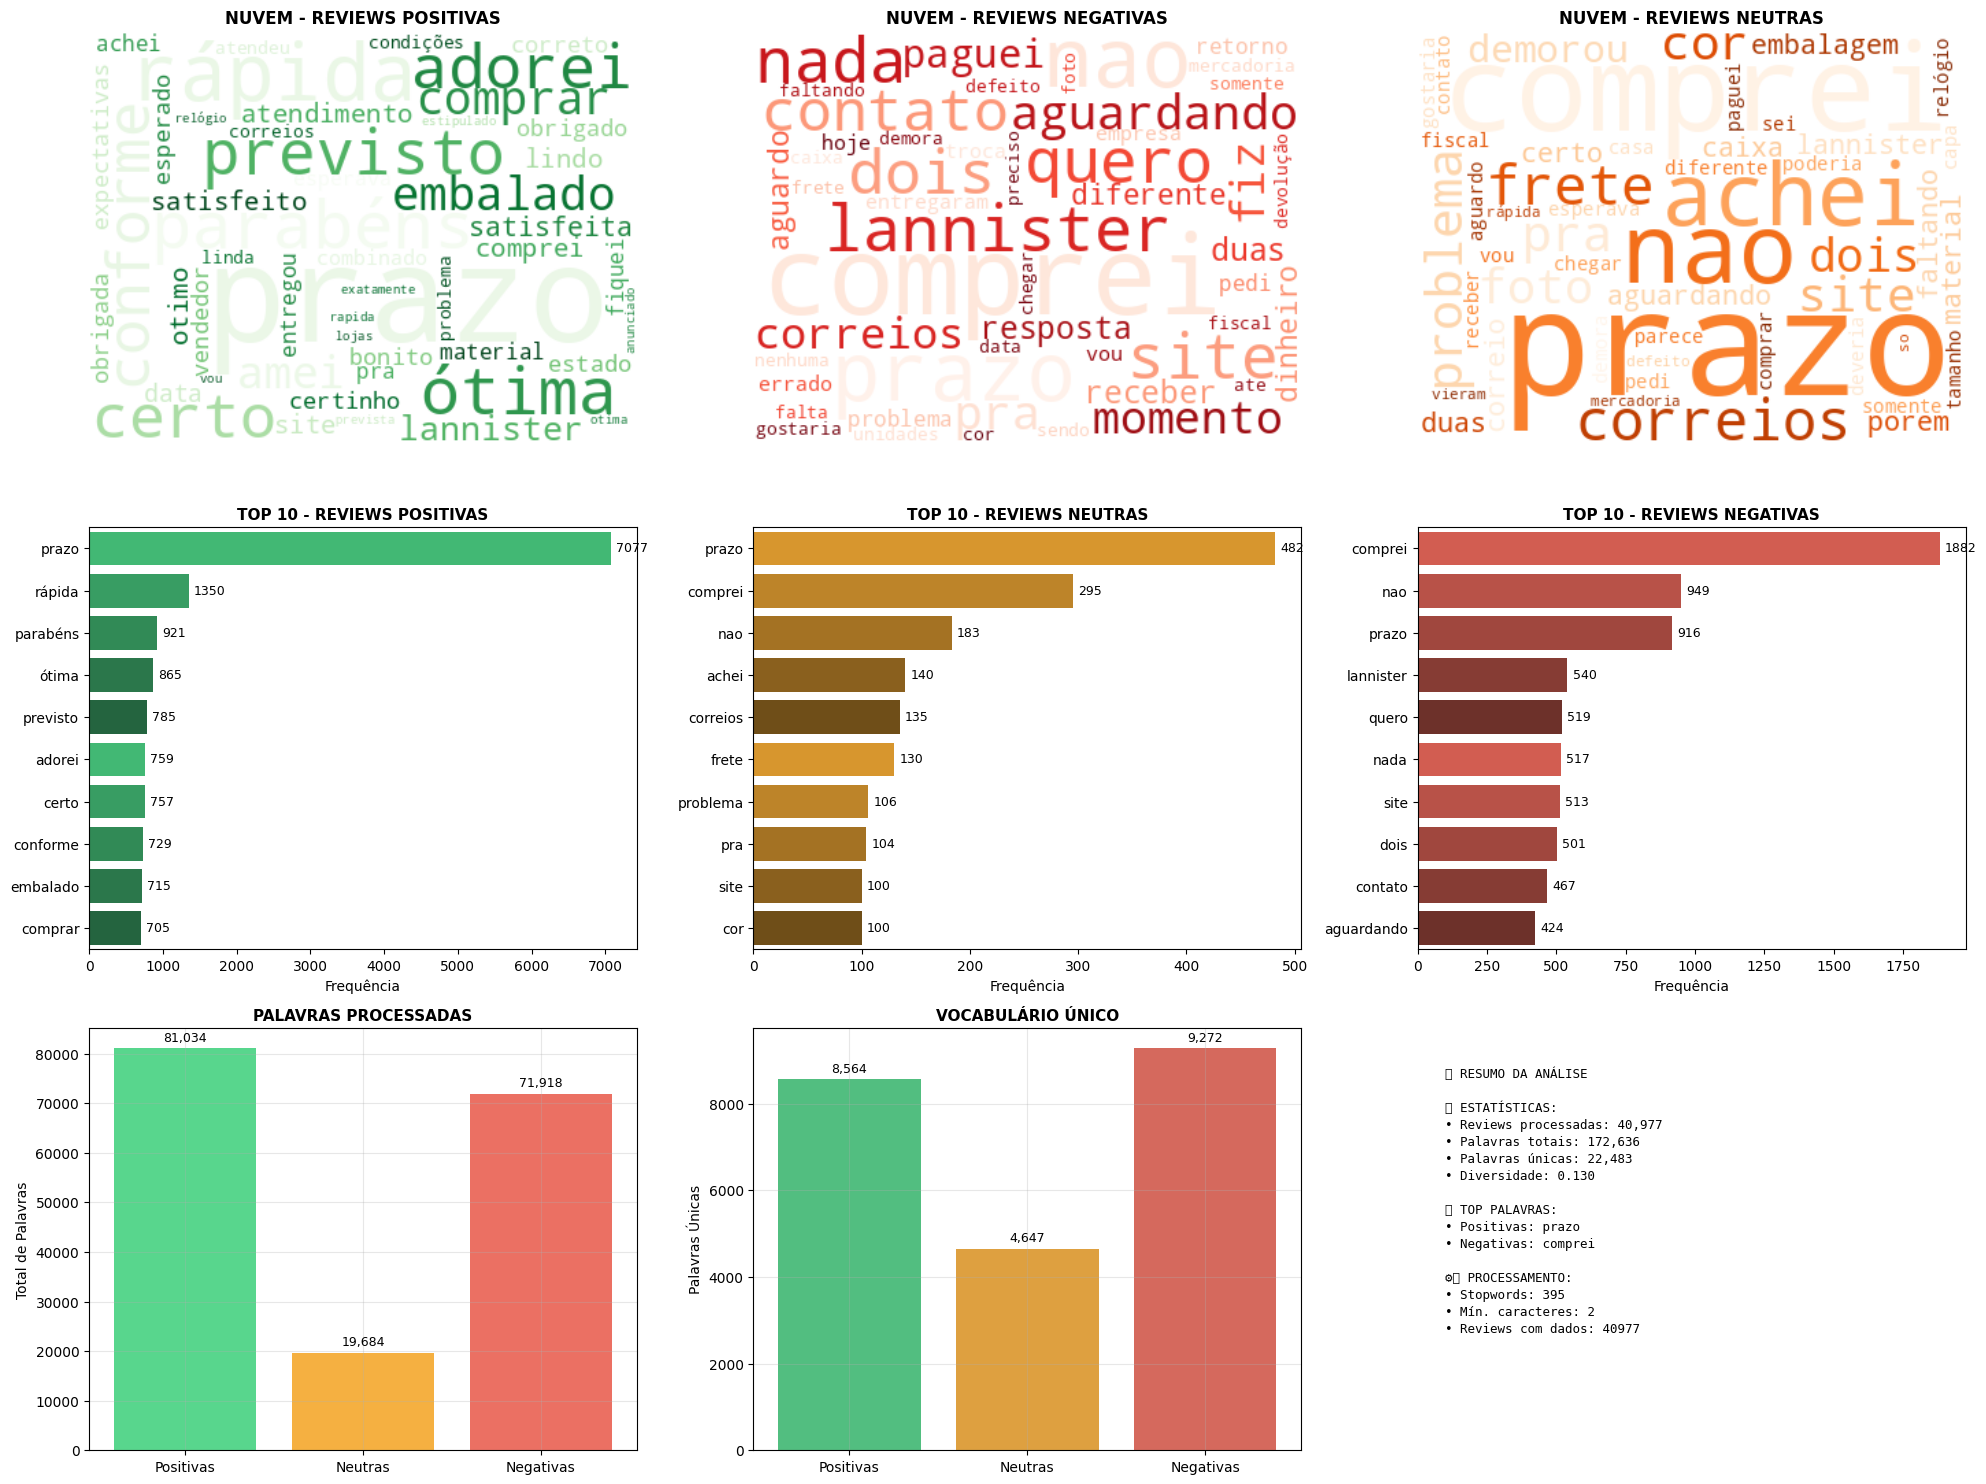

In [ ]:
# @title Análise de Palavras-chave por Sentimento com Processamento Otimizado

warnings.filterwarnings('ignore')

# Configurações de estilo
plt.style.use('default')
sns.set_palette("husl")
print("=" * 70)
print("ANÁLISE DE PALAVRAS-CHAVE POR SENTIMENTO COM PROCESSAMENTO OTIMIZADO")
print("=" * 70)

# =============================================================================
# 1. CONFIGURAÇÃO DE STOPWORDS AVANÇADA
# =============================================================================

print("\n" + "=" * 50)
print("1. CONFIGURAÇÃO DE STOPWORDS AVANÇADA")
print("=" * 50)

# Baixar recursos do NLTK se necessário
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords', quiet=True)
    print("✅ Stopwords baixadas")

# Definir stopwords em português base
stop_words = set(stopwords.words('portuguese'))

# Palavras adicionais para remover - lista expandida e categorizada
palavras_adicionais = {
    # Artigos e preposições comuns
    'o', 'a', 'os', 'as', 'um', 'uma', 'uns', 'umas', 'de', 'do', 'da', 'dos', 'das',
    'em', 'no', 'na', 'nos', 'nas', 'por', 'pelo', 'pela', 'pelos', 'pelas', 'para',
    'com', 'sem', 'sob', 'sobre', 'entre', 'até', 'após',

    # Pronomes
    'eu', 'tu', 'ele', 'ela', 'nós', 'vós', 'eles', 'elas', 'me', 'te', 'se', 'nos',
    'vos', 'lhe', 'lhes', 'meu', 'minha', 'teu', 'tua', 'seu', 'sua', 'nosso', 'nossa',
    'vosso', 'vossa', 'dele', 'dela', 'deles', 'delas', 'este', 'esta', 'esse', 'essa',
    'aquele', 'aquela', 'isto', 'isso', 'aquilo',

    # Conjunções
    'e', 'mas', 'porém', 'contudo', 'todavia', 'entretanto', 'ou', 'ora', 'quer',
    'pois', 'porque', 'porquê', 'como', 'que', 'se', 'quando', 'enquanto', 'assim',

    # Advérbios comuns
    'muito', 'pouco', 'mais', 'menos', 'bem', 'mal', 'melhor', 'pior', 'assim',
    'aqui', 'ali', 'lá', 'acima', 'abaixo', 'dentro', 'fora', 'antes', 'depois',
    'agora', 'já', 'sempre', 'nunca', 'também', 'só', 'apenas', 'quase', 'logo',

    # Verbos auxiliares e comuns
    'ser', 'estar', 'ter', 'haver', 'fazer', 'poder', 'dever', 'ir', 'vir', 'dar',
    'dizer', 'saber', 'querer', 'ver', 'achar', 'parecer', 'ficar', 'passar',

    # Palavras específicas de e-commerce
    'produto', 'produtos', 'item', 'itens', 'loja', 'compra', 'compras', 'pedido',
    'pedidos', 'entrega', 'entregue', 'entregar', 'recebi', 'recebido', 'cliente',
    'clientes', 'review', 'reviews', 'avaliação', 'avaliações', 'nota', 'notas',
    'qualidade', 'preço', 'valor', 'tempo', 'dia', 'dias', 'semana', 'semanas',
    'vez', 'vezes', 'coisa', 'coisas', 'parte', 'partes', 'tipo', 'tipos',

    # Expressões comuns em reviews
    'ótimo', 'excelente', 'bom', 'boa', 'ruim', 'péssimo', 'horrível', 'legal',
    'gostei', 'não', 'sim', 'ok', 'perfeito', 'maravilhoso', 'fantástico',
    'recomendo', 'recomenda', 'recomendado', 'super', 'muito', 'pouco',
    'chegou', 'veio', 'veio', 'veio', 'pronto', 'rápido', 'lento', 'demorado',

    # Outras palavras frequentes
    'ainda', 'tudo', 'todo', 'toda', 'todos', 'todas', 'algum', 'alguma', 'alguns',
    'algumas', 'cada', 'qualquer', 'quaisquer', 'outro', 'outra', 'outros', 'outras',
    'mesmo', 'mesma', 'mesmos', 'mesmas', 'tal', 'tais', 'qual', 'quais', 'quanto',
    'quantos', 'quantas', 'quanta', 'onde', 'como', 'quando', 'porque', 'porquê',

    # Abreviações e variações
    'q', 'pq', 'tb', 'tbm', 'vc', 'vcs', 'hj', 'td', 'tdo', 'tda', 'tds', 'tdas',
    'd', 'c', 's', 'm', 'p', 'r', 'f', 'v', 'x', 'z', 'ja', 'ta', 'to', 'tao',

    # Números e termos numéricos
    '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', 'primeiro', 'segundo',
    'terceiro', 'quarto', 'quinto', 'alguns', 'vários', 'diversos', 'muitos'
}

# Combinar stopwords
stop_words = stop_words.union(palavras_adicionais)
print(f"✅ Total de stopwords configuradas: {len(stop_words):,}")

# Mostrar algumas stopwords como exemplo
sample_stopwords = list(stop_words)[:20]
print(f"📋 Exemplo de stopwords: {', '.join(sample_stopwords)}...")

# =============================================================================
# 2. FUNÇÃO SIMPLIFICADA E ROBUSTA DE PROCESSAMENTO
# =============================================================================

print("\n" + "=" * 50)
print("2. FUNÇÃO SIMPLIFICADA E ROBUSTA DE PROCESSAMENTO")
print("=" * 50)

def processar_texto_simples(text_series, min_word_length=2):
    """
    Função robusta para processamento de texto sem stemming complexo
    """
    all_words = []
    stats = {
        'total_palavras': 0,
        'palavras_unicas': set(),
        'reviews_processadas': 0,
        'palavras_removidas': 0
    }

    for text in text_series:
        if pd.isna(text) or text == '' or text == 'nan':
            continue

        stats['reviews_processadas'] += 1

        try:
            # Limpeza básica mas eficiente do texto
            text = str(text).lower().strip()

            # Remover pontuação e números
            text = re.sub(r'[^\w\s]', ' ', text)  # Remove pontuação
            text = re.sub(r'\d+', ' ', text)      # Remove números
            text = re.sub(r'\s+', ' ', text)      # Normaliza espaços
            text = text.strip()

            if not text:
                continue

            # Tokenização simples
            words = text.split()

            # Filtragem
            filtered_words = []
            for word in words:
                # Verificar comprimento mínimo e se não é stopword
                if (len(word) >= min_word_length and
                    word not in stop_words and
                    not word.isdigit()):

                    filtered_words.append(word)
                    stats['palavras_unicas'].add(word)
                else:
                    stats['palavras_removidas'] += 1

            all_words.extend(filtered_words)
            stats['total_palavras'] += len(filtered_words)

        except Exception as e:
            print(f"⚠️  Erro ao processar texto: {e}")
            continue

    stats['palavras_unicas'] = len(stats['palavras_unicas'])
    return all_words, stats

def simple_stemmer(word):
    """
    Stemmer simples baseado em regras básicas do português
    """
    # Regras básicas de stemming
    if len(word) > 4:
        if word.endswith('mente'):
            return word[:-5]
        elif word.endswith('ções'):
            return word[:-4] + 'ção'
        elif word.endswith('ções'):
            return word[:-4] + 'ção'
        elif word.endswith('mente'):
            return word[:-5]

    return word

def processar_texto_com_stemming_simples(text_series, min_word_length=2):
    """
    Função com stemming simples baseado em regras
    """
    all_words = []
    stats = {
        'total_palavras': 0,
        'palavras_unicas': set(),
        'reviews_processadas': 0,
        'palavras_removidas': 0
    }

    for text in text_series:
        if pd.isna(text) or text == '' or text == 'nan':
            continue

        stats['reviews_processadas'] += 1

        try:
            # Limpeza básica
            text = str(text).lower().strip()
            text = re.sub(r'[^\w\s]', ' ', text)
            text = re.sub(r'\d+', ' ', text)
            text = re.sub(r'\s+', ' ', text)
            text = text.strip()

            if not text:
                continue

            words = text.split()
            filtered_words = []

            for word in words:
                if (len(word) >= min_word_length and
                    word not in stop_words and
                    not word.isdigit()):

                    # Aplicar stemming simples
                    stemmed_word = simple_stemmer(word)
                    filtered_words.append(stemmed_word)
                    stats['palavras_unicas'].add(stemmed_word)
                else:
                    stats['palavras_removidas'] += 1

            all_words.extend(filtered_words)
            stats['total_palavras'] += len(filtered_words)

        except Exception as e:
            continue

    stats['palavras_unicas'] = len(stats['palavras_unicas'])
    return all_words, stats

print("🔄 INICIANDO PROCESSAMENTO DOS TEXTOS...")

# Verificar dados disponíveis
print(f"📊 ESTATÍSTICAS INICIAIS:")
print(f"• Total de reviews no dataset: {len(reviews_df):,}")

if 'sentiment' not in reviews_df.columns:
    print("❌ ERRO: Coluna 'sentiment' não encontrada!")
    # Tentar criar a coluna sentiment se não existir
    if 'review_score' in reviews_df.columns:
        print("⚠️  Criando coluna 'sentiment' baseada em 'review_score'...")
        def classify_sentiment(score):
            if score in [1, 2]:
                return 0  # Negativo
            elif score == 3:
                return 1  # Neutro
            elif score in [4, 5]:
                return 2  # Positivo
            else:
                return None

        reviews_df['sentiment'] = reviews_df['review_score'].apply(classify_sentiment)
        print("✅ Coluna 'sentiment' criada com sucesso!")
    else:
        print("❌ Coluna 'review_score' também não encontrada!")
        exit()

# Separar reviews por sentimento
positive_reviews = reviews_df[reviews_df['sentiment'] == 2]['review_comment_message']
neutro_reviews = reviews_df[reviews_df['sentiment'] == 1]['review_comment_message']
negative_reviews = reviews_df[reviews_df['sentiment'] == 0]['review_comment_message']

print(f"• Reviews positivas: {len(positive_reviews):,}")
print(f"• Reviews neutras: {len(neutro_reviews):,}")
print(f"• Reviews negativas: {len(negative_reviews):,}")

# Verificar se há dados suficientes
if len(positive_reviews) == 0 and len(neutro_reviews) == 0 and len(negative_reviews) == 0:
    print("❌ ERRO: Nenhum dado disponível para processamento!")
    exit()

# Processar palavras de cada categoria (usando versão simples)
print("\n⚙️ PROCESSANDO TEXTOS...")
positive_words, positive_stats = processar_texto_simples(positive_reviews)
neutro_words, neutro_stats = processar_texto_simples(neutro_reviews)
negative_words, negative_stats = processar_texto_simples(negative_reviews)

# Exibir estatísticas do processamento
print(f"\n📊 ESTATÍSTICAS DE PROCESSAMENTO:")
print(f"  📈 POSITIVAS: {positive_stats['reviews_processadas']:,} reviews, "
      f"{positive_stats['total_palavras']:,} palavras, "
      f"{positive_stats['palavras_unicas']:,} únicas")

print(f"  📊 NEUTRAS:   {neutro_stats['reviews_processadas']:,} reviews, "
      f"{neutro_stats['total_palavras']:,} palavras, "
      f"{neutro_stats['palavras_unicas']:,} únicas")

print(f"  📉 NEGATIVAS: {negative_stats['reviews_processadas']:,} reviews, "
      f"{negative_stats['total_palavras']:,} palavras, "
      f"{negative_stats['palavras_unicas']:,} únicas")

# =============================================================================
# 3. ANÁLISE DE FREQUÊNCIA E COMPARAÇÃO
# =============================================================================

print("\n" + "=" * 50)
print("3. ANÁLISE DE FREQUÊNCIA E COMPARAÇÃO")
print("=" * 50)

# Contar frequência das palavras
positive_word_counts = Counter(positive_words)
neutro_word_counts = Counter(neutro_words)
negative_word_counts = Counter(negative_words)

# Obter as palavras mais comuns
top_n = 20
top_positive_words = positive_word_counts.most_common(top_n)
top_neutro_words = neutro_word_counts.most_common(top_n)
top_negative_words = negative_word_counts.most_common(top_n)

# Criar dataframes para análise
df_positive = pd.DataFrame(top_positive_words, columns=['word', 'count'])
df_neutro = pd.DataFrame(top_neutro_words, columns=['word', 'count'])
df_negative = pd.DataFrame(top_negative_words, columns=['word', 'count'])

# Calcular frequência relativa
if positive_stats['total_palavras'] > 0:
    df_positive['frequencia_relativa'] = (df_positive['count'] / positive_stats['total_palavras']) * 100
else:
    df_positive['frequencia_relativa'] = 0

if neutro_stats['total_palavras'] > 0:
    df_neutro['frequencia_relativa'] = (df_neutro['count'] / neutro_stats['total_palavras']) * 100
else:
    df_neutro['frequencia_relativa'] = 0

if negative_stats['total_palavras'] > 0:
    df_negative['frequencia_relativa'] = (df_negative['count'] / negative_stats['total_palavras']) * 100
else:
    df_negative['frequencia_relativa'] = 0

print("🎯 TOP 10 PALAVRAS POR CATEGORIA:")

if len(df_positive) > 0:
    print("\n💚 POSITIVAS:")
    for i, row in df_positive.head(10).iterrows():
        print(f"  {i+1:2d}. {row['word']:15} {row['count']:4d} ({row['frequencia_relativa']:5.2f}%)")
else:
    print("\n💚 POSITIVAS: Nenhuma palavra processada")

if len(df_neutro) > 0:
    print("\n💛 NEUTRAS:")
    for i, row in df_neutro.head(10).iterrows():
        print(f"  {i+1:2d}. {row['word']:15} {row['count']:4d} ({row['frequencia_relativa']:5.2f}%)")
else:
    print("\n💛 NEUTRAS: Nenhuma palavra processada")

if len(df_negative) > 0:
    print("\n❤️ NEGATIVAS:")
    for i, row in df_negative.head(10).iterrows():
        print(f"  {i+1:2d}. {row['word']:15} {row['count']:4d} ({row['frequencia_relativa']:5.2f}%)")
else:
    print("\n❤️ NEGATIVAS: Nenhuma palavra processada")

# =============================================================================
# 4. VISUALIZAÇÕES ROBUSTAS
# =============================================================================

print("\n" + "=" * 50)
print("4. VISUALIZAÇÕES ROBUSTAS")
print("=" * 50)

# Criar figura principal
fig = plt.figure(figsize=(20, 15))
gs = GridSpec(3, 3, figure=fig)

# Cores temáticas para cada sentimento
colors_positive = ['#2ecc71', '#27ae60', '#229954', '#1e8449', '#196f3d']
colors_negative = ['#e74c3c', '#cb4335', '#b03a2e', '#943126', '#78281f']
colors_neutral = ['#f39c12', '#d68910', '#b9770e', '#9c640c', '#7e5109']

# Gráfico 1: Word Cloud Positivo
ax1 = fig.add_subplot(gs[0, 0])
if len(positive_words) > 10:  # Apenas criar wordcloud se houver palavras suficientes
    try:
        wordcloud_positive = WordCloud(
            width=400, height=300,
            background_color='white',
            colormap='Greens',
            max_words=50,
            stopwords=set(),
            random_state=42
        ).generate_from_frequencies(positive_word_counts)

        ax1.imshow(wordcloud_positive, interpolation='bilinear')
        ax1.set_title('NUVEM - REVIEWS POSITIVAS', fontweight='bold', fontsize=12)
        ax1.axis('off')
    except:
        ax1.text(0.5, 0.5, 'ERRO NA\nNUVEM DE PALAVRAS',
                 ha='center', va='center', transform=ax1.transAxes, fontsize=10)
        ax1.set_title('NUVEM - REVIEWS POSITIVAS', fontweight='bold')
else:
    ax1.text(0.5, 0.5, 'DADOS\nINSUFICIENTES',
             ha='center', va='center', transform=ax1.transAxes, fontsize=10)
    ax1.set_title('NUVEM - REVIEWS POSITIVAS', fontweight='bold')

# Gráfico 2: Word Cloud Negativo
ax2 = fig.add_subplot(gs[0, 1])
if len(negative_words) > 10:
    try:
        wordcloud_negative = WordCloud(
            width=400, height=300,
            background_color='white',
            colormap='Reds',
            max_words=50,
            stopwords=set(),
            random_state=42
        ).generate_from_frequencies(negative_word_counts)

        ax2.imshow(wordcloud_negative, interpolation='bilinear')
        ax2.set_title('NUVEM - REVIEWS NEGATIVAS', fontweight='bold', fontsize=12)
        ax2.axis('off')
    except:
        ax2.text(0.5, 0.5, 'ERRO NA\nNUVEM DE PALAVRAS',
                 ha='center', va='center', transform=ax2.transAxes, fontsize=10)
        ax2.set_title('NUVEM - REVIEWS NEGATIVAS', fontweight='bold')
else:
    ax2.text(0.5, 0.5, 'DADOS\nINSUFICIENTES',
             ha='center', va='center', transform=ax2.transAxes, fontsize=10)
    ax2.set_title('NUVEM - REVIEWS NEGATIVAS', fontweight='bold')

# Gráfico 3: Word Cloud Neutro
ax3 = fig.add_subplot(gs[0, 2])
if len(neutro_words) > 10:
    try:
        wordcloud_neutro = WordCloud(
            width=400, height=300,
            background_color='white',
            colormap='Oranges',
            max_words=50,
            stopwords=set(),
            random_state=42
        ).generate_from_frequencies(neutro_word_counts)

        ax3.imshow(wordcloud_neutro, interpolation='bilinear')
        ax3.set_title('NUVEM - REVIEWS NEUTRAS', fontweight='bold', fontsize=12)
        ax3.axis('off')
    except:
        ax3.text(0.5, 0.5, 'ERRO NA\nNUVEM DE PALAVRAS',
                 ha='center', va='center', transform=ax3.transAxes, fontsize=10)
        ax3.set_title('NUVEM - REVIEWS NEUTRAS', fontweight='bold')
else:
    ax3.text(0.5, 0.5, 'DADOS\nINSUFICIENTES',
             ha='center', va='center', transform=ax3.transAxes, fontsize=10)
    ax3.set_title('NUVEM - REVIEWS NEUTRAS', fontweight='bold')

# Gráfico 4: Top Palavras Positivas
ax4 = fig.add_subplot(gs[1, 0])
if len(df_positive) > 0:
    plot_data = df_positive.head(10)  # Mostrar apenas top 10 para melhor visualização
    sns.barplot(x='count', y='word', data=plot_data, palette=colors_positive, ax=ax4)
    ax4.set_title('TOP 10 - REVIEWS POSITIVAS', fontweight='bold', fontsize=11)
    ax4.set_xlabel('Frequência')
    ax4.set_ylabel('')

    # Adicionar valores nas barras
    for i, (value, rel_freq) in enumerate(zip(plot_data['count'], plot_data['frequencia_relativa'])):
        ax4.text(value + max(plot_data['count'])*0.01, i, f'{value}', va='center', fontsize=9)
else:
    ax4.text(0.5, 0.5, 'SEM DADOS', ha='center', va='center', transform=ax4.transAxes, fontsize=12)
    ax4.set_title('TOP - REVIEWS POSITIVAS', fontweight='bold')

# Gráfico 5: Top Palavras Neutras
ax5 = fig.add_subplot(gs[1, 1])
if len(df_neutro) > 0:
    plot_data = df_neutro.head(10)
    sns.barplot(x='count', y='word', data=plot_data, palette=colors_neutral, ax=ax5)
    ax5.set_title('TOP 10 - REVIEWS NEUTRAS', fontweight='bold', fontsize=11)
    ax5.set_xlabel('Frequência')
    ax5.set_ylabel('')

    for i, (value, rel_freq) in enumerate(zip(plot_data['count'], plot_data['frequencia_relativa'])):
        ax5.text(value + max(plot_data['count'])*0.01, i, f'{value}', va='center', fontsize=9)
else:
    ax5.text(0.5, 0.5, 'SEM DADOS', ha='center', va='center', transform=ax5.transAxes, fontsize=12)
    ax5.set_title('TOP - REVIEWS NEUTRAS', fontweight='bold')

# Gráfico 6: Top Palavras Negativas
ax6 = fig.add_subplot(gs[1, 2])
if len(df_negative) > 0:
    plot_data = df_negative.head(10)
    sns.barplot(x='count', y='word', data=plot_data, palette=colors_negative, ax=ax6)
    ax6.set_title('TOP 10 - REVIEWS NEGATIVAS', fontweight='bold', fontsize=11)
    ax6.set_xlabel('Frequência')
    ax6.set_ylabel('')

    for i, (value, rel_freq) in enumerate(zip(plot_data['count'], plot_data['frequencia_relativa'])):
        ax6.text(value + max(plot_data['count'])*0.01, i, f'{value}', va='center', fontsize=9)
else:
    ax6.text(0.5, 0.5, 'SEM DADOS', ha='center', va='center', transform=ax6.transAxes, fontsize=12)
    ax6.set_title('TOP - REVIEWS NEGATIVAS', fontweight='bold')

# Gráfico 7: Estatísticas de Processamento
ax7 = fig.add_subplot(gs[2, 0])
categories = ['Positivas', 'Neutras', 'Negativas']
total_words = [
    positive_stats['total_palavras'] if len(positive_words) > 0 else 0,
    neutro_stats['total_palavras'] if len(neutro_words) > 0 else 0,
    negative_stats['total_palavras'] if len(negative_words) > 0 else 0
]

# Garantir que temos dados para plotar
if sum(total_words) > 0:
    bars = ax7.bar(categories, total_words, color=['#2ecc71', '#f39c12', '#e74c3c'], alpha=0.8)
    ax7.set_ylabel('Total de Palavras')
    ax7.set_title('PALAVRAS PROCESSADAS', fontweight='bold', fontsize=11)
    ax7.grid(True, alpha=0.3)

    # Adicionar valores nas barras
    for bar, value in zip(bars, total_words):
        height = bar.get_height()
        ax7.text(bar.get_x() + bar.get_width()/2., height + max(total_words)*0.01,
                f'{value:,}', ha='center', va='bottom', fontsize=9)
else:
    ax7.text(0.5, 0.5, 'SEM DADOS\nPARA ESTATÍSTICAS', ha='center', va='center', transform=ax7.transAxes, fontsize=10)
    ax7.set_title('PALAVRAS PROCESSADAS', fontweight='bold')

# Gráfico 8: Palavras Únicas
ax8 = fig.add_subplot(gs[2, 1])
unique_words = [
    positive_stats['palavras_unicas'] if len(positive_words) > 0 else 0,
    neutro_stats['palavras_unicas'] if len(neutro_words) > 0 else 0,
    negative_stats['palavras_unicas'] if len(negative_words) > 0 else 0
]

if sum(unique_words) > 0:
    bars = ax8.bar(categories, unique_words, color=['#27ae60', '#d68910', '#cb4335'], alpha=0.8)
    ax8.set_ylabel('Palavras Únicas')
    ax8.set_title('VOCABULÁRIO ÚNICO', fontweight='bold', fontsize=11)
    ax8.grid(True, alpha=0.3)

    for bar, value in zip(bars, unique_words):
        height = bar.get_height()
        ax8.text(bar.get_x() + bar.get_width()/2., height + max(unique_words)*0.01,
                f'{value:,}', ha='center', va='bottom', fontsize=9)
else:
    ax8.text(0.5, 0.5, 'SEM DADOS\nPARA ESTATÍSTICAS', ha='center', va='center', transform=ax8.transAxes, fontsize=10)
    ax8.set_title('VOCABULÁRIO ÚNICO', fontweight='bold')

# Gráfico 9: Resumo
ax9 = fig.add_subplot(gs[2, 2])
ax9.axis('off')

# Calcular métricas
total_reviews = positive_stats['reviews_processadas'] + neutro_stats['reviews_processadas'] + negative_stats['reviews_processadas']
total_processed_words = sum(total_words)
total_unique_words = sum(unique_words)

lexical_diversity = total_unique_words / total_processed_words if total_processed_words > 0 else 0

resumo_texto = f"""
📊 RESUMO DA ANÁLISE

📈 ESTATÍSTICAS:
• Reviews processadas: {total_reviews:,}
• Palavras totais: {total_processed_words:,}
• Palavras únicas: {total_unique_words:,}
• Diversidade: {lexical_diversity:.3f}

🎯 TOP PALAVRAS:
• Positivas: {df_positive['word'].iloc[0] if len(df_positive) > 0 else 'N/A'}
• Negativas: {df_negative['word'].iloc[0] if len(df_negative) > 0 else 'N/A'}

⚙️ PROCESSAMENTO:
• Stopwords: {len(stop_words):,}
• Mín. caracteres: 2
• Reviews com dados: {total_reviews}
"""

ax9.text(0.05, 0.95, resumo_texto, transform=ax9.transAxes, fontsize=9,
        verticalalignment='top', fontfamily='monospace', linespacing=1.4)

plt.tight_layout()
plt.savefig('analise_palavras_chave.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✅ Gráfico salvo como 'analise_palavras_chave.png'")

# =============================================================================
# 5. SALVAMENTO E RELATÓRIO
# =============================================================================

print("\n" + "=" * 50)
print("5. SALVAMENTO E RELATÓRIO FINAL")
print("=" * 50)

# Salvar resultados se houver dados
if len(df_positive) > 0:
    df_positive.to_csv('palavras_positivas.csv', index=False, encoding='utf-8')
    print("💾 palavras_positivas.csv salvo")

if len(df_negative) > 0:
    df_negative.to_csv('palavras_negativas.csv', index=False, encoding='utf-8')
    print("💾 palavras_negativas.csv salvo")

if len(df_neutro) > 0:
    df_neutro.to_csv('palavras_neutras.csv', index=False, encoding='utf-8')
    print("💾 palavras_neutras.csv salvo")

print("\n🎯 ANÁLISE CONCLUÍDA COM SUCESSO!")
print("📊 Foram processadas palavras de três categorias de sentimentos")
print("📈 Gráficos e arquivos CSV gerados para análise detalhada")

print("\n" + "=" * 70)
print("PROCESSAMENTO DE TEXTO CONCLUÍDO! 🎉")
print("=" * 70)

ANÁLISE DE ASPECTOS E SENTIMENTOS NA BASE DE REVIEWS

1. CONFIGURAÇÃO E DEFINIÇÃO DE ASPECTOS
📊 ESTATÍSTICAS DA BASE:
   • Total de reviews: 40,977
   • Reviews com comentários: 40,977
   • Percentual com comentários: 100.0%
   • Reviews para análise: 40,977
🎯 ASPECTOS CONFIGURADOS: 6 categorias
   • entrega: 25 palavras positivas, 24 negativas
   • produto: 32 palavras positivas, 27 negativas
   • embalagem: 14 palavras positivas, 15 negativas
   • atendimento: 21 palavras positivas, 16 negativas
   • preço: 15 palavras positivas, 15 negativas
   • qualidade: 14 palavras positivas, 13 negativas

📊 TOTAL DE PALAVRAS-CHAVE:
   • Positivas: 121
   • Negativas: 110

2. FUNÇÕES AVANÇADAS DE PROCESSAMENTO

3. APLICAÇÃO NA BASE DE DADOS REAL
📝 ANALISANDO 40977 COMENTÁRIOS REAIS...
⚠️  Base muito grande, amostrando 10.000 comentários para análise...
🔍 PROCESSANDO 10000 COMENTÁRIOS...
   • Frases extraídas: 11271/14694 válidas

4. RELATÓRIO DETALHADO DOS RESULTADOS

📊 ESTATÍSTICAS GERAIS:
   •

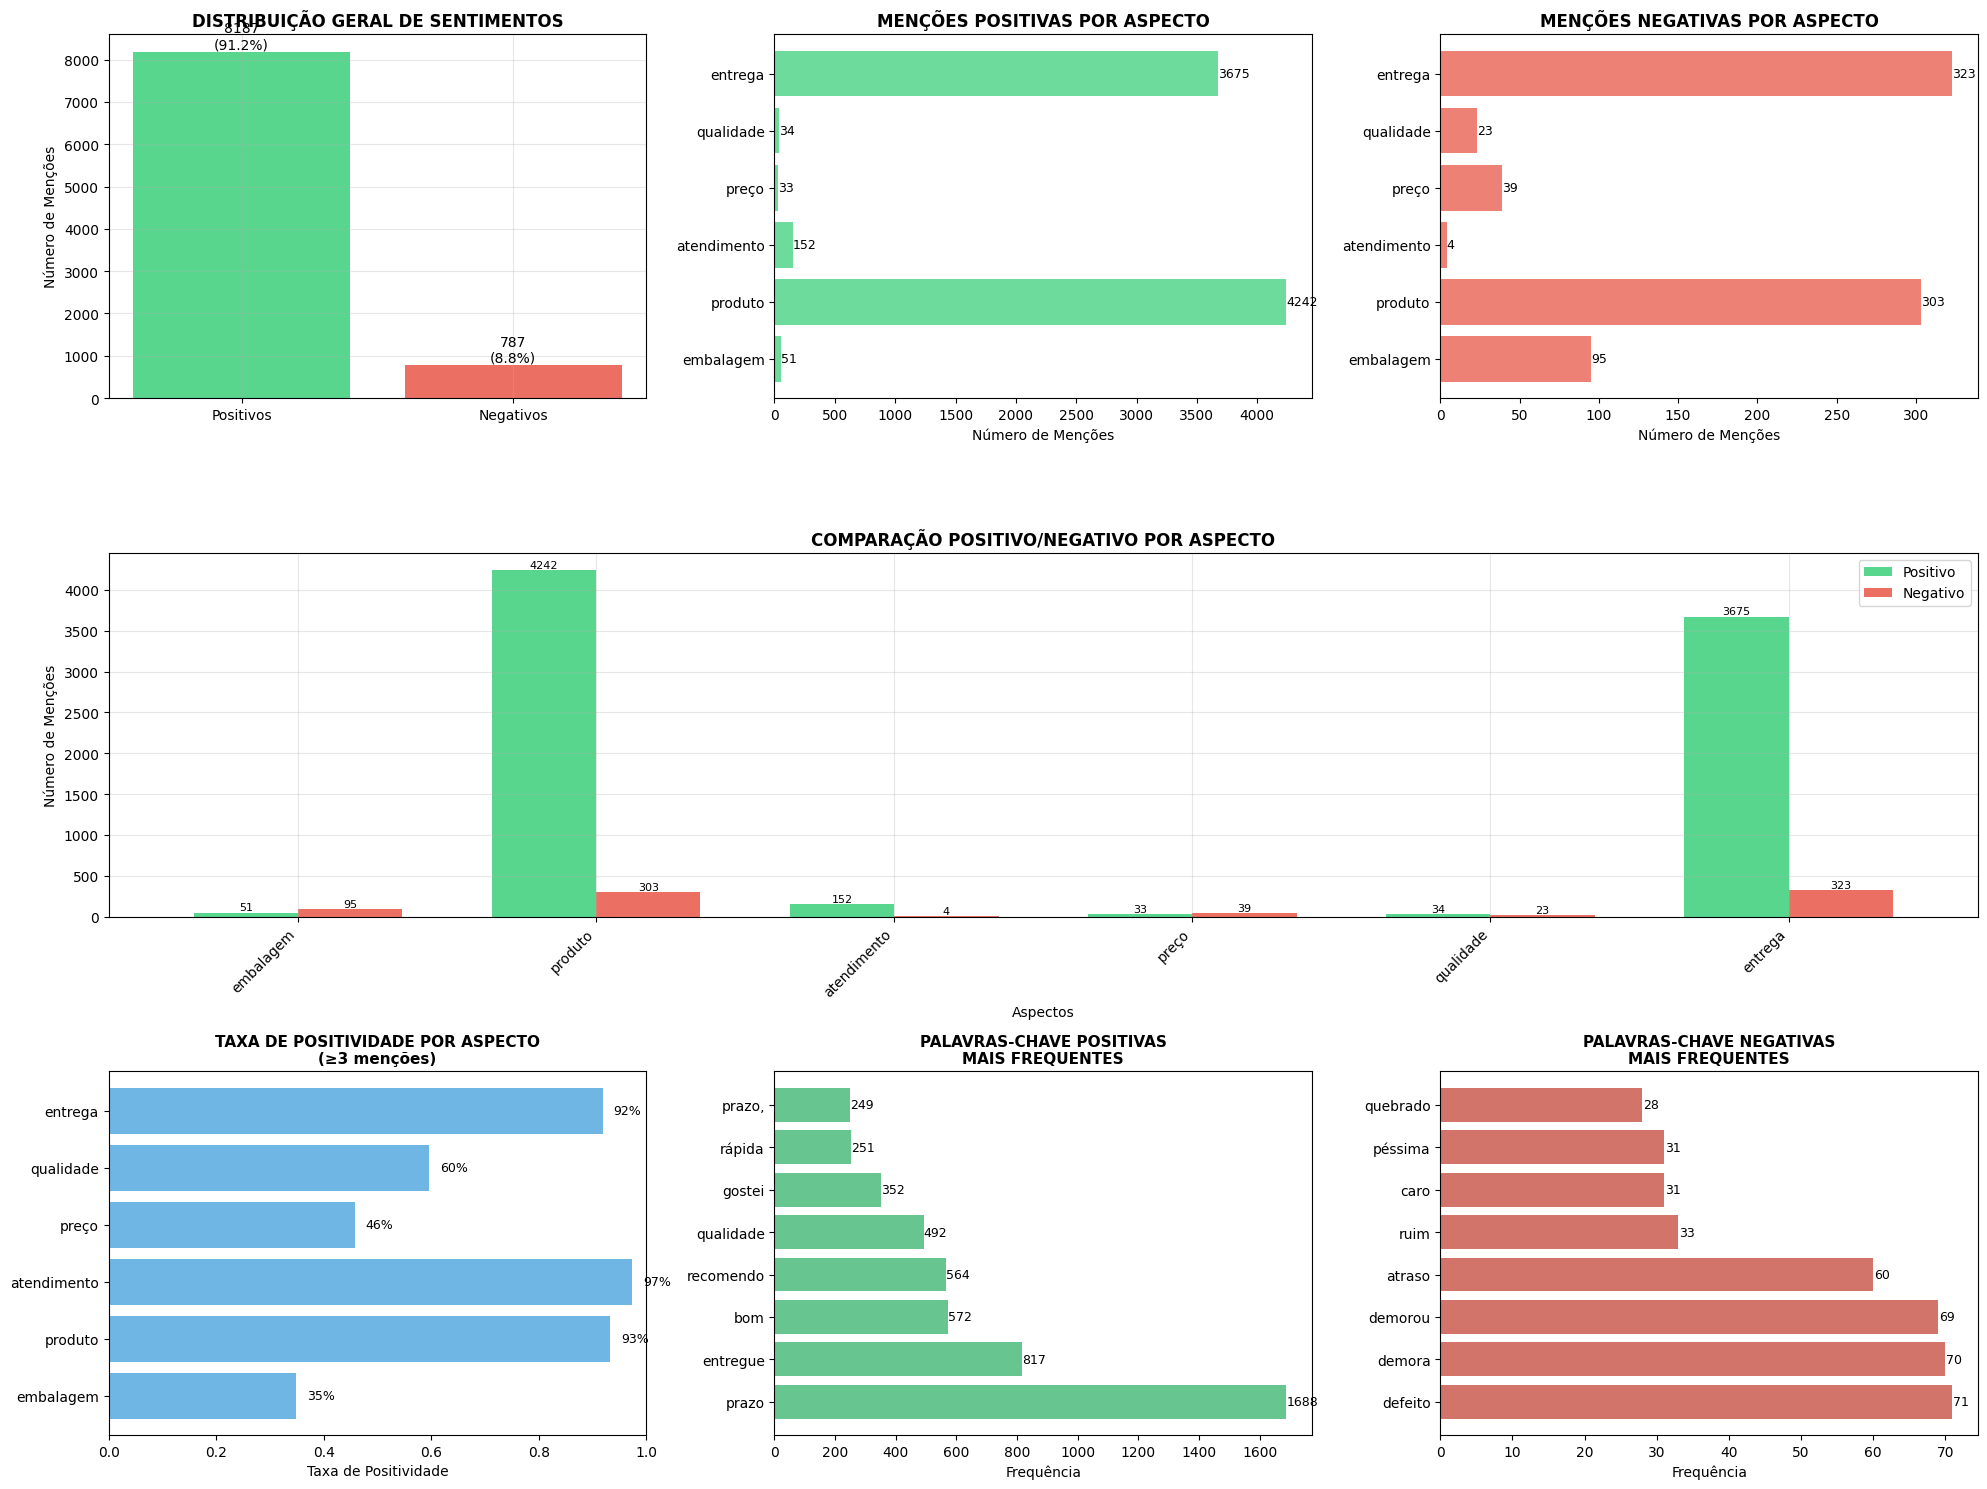

In [ ]:
# @title Análise de Aspectos e Sentimentos na Base de Reviews

warnings.filterwarnings('ignore')

# Configurações de estilo
plt.style.use('default')
sns.set_palette("husl")
print("=" * 70)
print("ANÁLISE DE ASPECTOS E SENTIMENTOS NA BASE DE REVIEWS")
print("=" * 70)

# =============================================================================
# 1. CONFIGURAÇÃO E DEFINIÇÃO DE ASPECTOS
# =============================================================================

print("\n" + "=" * 50)
print("1. CONFIGURAÇÃO E DEFINIÇÃO DE ASPECTOS")
print("=" * 50)

# Verificar se a coluna existe
if 'review_comment_message' not in reviews_df.columns:
    print("❌ ERRO: Coluna 'review_comment_message' não encontrada!")
    print("📋 Colunas disponíveis:")
    print(reviews_df.columns.tolist())
    exit()

# Verificar dados disponíveis
total_reviews = len(reviews_df)
reviews_com_comentario = reviews_df['review_comment_message'].notna().sum()
print(f"📊 ESTATÍSTICAS DA BASE:")
print(f"   • Total de reviews: {total_reviews:,}")
print(f"   • Reviews com comentários: {reviews_com_comentario:,}")
print(f"   • Percentual com comentários: {(reviews_com_comentario/total_reviews)*100:.1f}%")

# Filtrar apenas reviews com comentários
reviews_com_texto = reviews_df[reviews_df['review_comment_message'].notna()].copy()
print(f"   • Reviews para análise: {len(reviews_com_texto):,}")

# Definição expandida de aspectos e palavras-chave
aspectos_detalhados = {
    'entrega': {
        'positivo': ['rápido', 'rápida', 'rápidos', 'rápidas', 'entregue', 'entregou', 'prazo', 'pontual',
                    'veloz', 'ágil', 'eficiente', 'no prazo', 'antes do prazo', 'express', 'imediato',
                    'pronta entrega', 'entrega rápida', 'chegou rápido', 'entregue rápido', 'chegou bem',
                    'entregue no prazo', 'entrega perfeita', 'entregue antes', 'rapidez', 'ágil'],
        'negativo': ['demorou', 'demorada', 'demorado', 'demorados', 'atrasou', 'atrasado', 'atrasada',
                    'lento', 'lenta', 'lentos', 'lentas', 'tardia', 'tardio', 'atraso', 'demora',
                    'entregue atrasado', 'chegou atrasado', 'demorou muito', 'muita demora', 'atrasou muito',
                    'demora na entrega', 'entregue com atraso', 'lentidão', 'moroso']
    },
    'produto': {
        'positivo': ['perfeito', 'perfeita', 'ótimo', 'ótima', 'excelente', 'maravilhoso', 'maravilhosa',
                    'qualidade', 'qualificado', 'superou', 'surpreendeu', 'gostei', 'adorei', 'amei',
                    'funciona', 'funcionando', 'bom', 'boa', 'incrível', 'fantástico', 'nota 10',
                    'recomendo', 'recomenda', 'recomendado', 'recomendada', 'vale a pena', 'top',
                    'show', 'sensacional', 'incrivel', 'perfeição', 'excelência'],
        'negativo': ['ruim', 'péssimo', 'péssima', 'horrível', 'terrível', 'decepcionante', 'lixo',
                    'quebrou', 'quebrado', 'danificado', 'danificada', 'defeito', 'defeituoso',
                    'não funciona', 'não recomendo', 'desisti', 'devolvi', 'arrependimento',
                    'qualidade ruim', 'produto ruim', 'não presta', 'fraco', 'horroroso', 'pessimo',
                    'decepcionou', 'não gostei', 'desapontado']
    },
    'embalagem': {
        'positivo': ['bem embalado', 'embalagem boa', 'protegido', 'seguro', 'cuidado', 'organizado',
                    'embalagem perfeita', 'bem acondicionado', 'embalagem adequada', 'embalagem segura',
                    'bem protegido', 'embalagem intacta', 'bem embalada', 'embalagem cuidadosa'],
        'negativo': ['mal embalado', 'embalagem ruim', 'amassado', 'amassada', 'quebrada', 'avariada',
                    'embalagem danificada', 'sem proteção', 'frágil', 'embalagem frágil', 'amassou',
                    'embalagem aberta', 'mal acondicionado', 'embalagem violada', 'avariado']
    },
    'atendimento': {
        'positivo': ['atendimento bom', 'atendimento excelente', 'prestativo', 'educado', 'educada',
                    'simpático', 'simpática', 'respondeu', 'ajudou', 'solucionou', 'resolveu',
                    'atendimento rápido', 'eficiente', 'profissional', 'competente', 'atendeu',
                    'esclareceu', 'orientou', 'atendimento perfeito', 'gentil', 'cortês'],
        'negativo': ['atendimento ruim', 'mal educado', 'grosso', 'grossa', 'ignorou', 'não respondeu',
                    'não ajudou', 'atendimento lento', 'incompetente', 'despreparado', 'grosseiro',
                    'atendimento péssimo', 'não resolveu', 'ignorante', 'desatento', 'atendimento demorado']
    },
    'preço': {
        'positivo': ['preço justo', 'preço bom', 'barato', 'econômico', 'vale o preço', 'compensa',
                    'preço baixo', 'acessível', 'custobenefício', 'relação custo benefício', 'baratinho',
                    'preço honesto', 'conta justa', 'preço razoável', 'vale cada centavo'],
        'negativo': ['caro', 'caríssimo', 'superfaturado', 'preço alto', 'não vale', 'custo alto',
                    'muito caro', 'preço abusivo', 'cobrança excessiva', 'caro demais', 'superfaturado',
                    'preço inflado', 'não compensa', 'muito caro para', 'preço exagerado']
    },
    'qualidade': {
        'positivo': ['qualidade excelente', 'alta qualidade', 'premium', 'durável', 'resistente',
                    'material bom', 'acabamento bom', 'bem feito', 'bem fabricado', 'qualidade superior',
                    'material de qualidade', 'acabamento perfeito', 'resistência', 'durabilidade'],
        'negativo': ['qualidade ruim', 'baixa qualidade', 'frágil', 'quebradiço', 'material ruim',
                    'acabamento ruim', 'mal feito', 'qualidade inferior', 'qualidade duvidosa',
                    'material frágil', 'acabamento porco', 'qualidade péssima', 'qualidade baixíssima']
    }
}

print(f"🎯 ASPECTOS CONFIGURADOS: {len(aspectos_detalhados)} categorias")
for aspecto, sentimentos in aspectos_detalhados.items():
    print(f"   • {aspecto}: {len(sentimentos['positivo'])} palavras positivas, {len(sentimentos['negativo'])} negativas")

# Combinar todas as palavras-chave
todas_palavras_pos = [palavra for aspecto in aspectos_detalhados.values()
                      for palavra in aspecto['positivo']]
todas_palavras_neg = [palavra for aspecto in aspectos_detalhados.values()
                      for palavra in aspecto['negativo']]

print(f"\n📊 TOTAL DE PALAVRAS-CHAVE:")
print(f"   • Positivas: {len(todas_palavras_pos)}")
print(f"   • Negativas: {len(todas_palavras_neg)}")

# =============================================================================
# 2. FUNÇÕES AVANÇADAS DE PROCESSAMENTO
# =============================================================================

print("\n" + "=" * 50)
print("2. FUNÇÕES AVANÇADAS DE PROCESSAMENTO")
print("=" * 50)

def extrair_frases_avancado(textos, min_palavras=3, max_palavras=25):
    """
    Divide os textos em frases significativas com critérios avançados
    """
    todas_frases = []
    estatisticas = {'total_frases': 0, 'frases_validas': 0}

    for texto in textos:
        if pd.isna(texto) or texto == '':
            continue

        # Normalizar pontuação
        texto = str(texto).replace('!', '.').replace('?', '.').replace(';', '.').replace(':', '.')

        # Dividir em frases
        frases = [f.strip() for f in texto.split('.') if f.strip()]
        estatisticas['total_frases'] += len(frases)

        for frase in frases:
            # Verificar critérios de qualidade
            palavras = frase.split()
            if min_palavras <= len(palavras) <= max_palavras:
                todas_frases.append(frase)
                estatisticas['frases_validas'] += 1

    print(f"   • Frases extraídas: {estatisticas['frases_validas']}/{estatisticas['total_frases']} válidas")
    return todas_frases

def identificar_aspectos_contexto(frase, aspectos_dict, contexto_tamanho=3):
    """
    Identifica aspectos mencionados na frase com contexto expandido
    """
    aspectos_encontrados = []
    frase_lower = frase.lower()
    palavras = frase_lower.split()

    for aspecto, sentimentos in aspectos_dict.items():
        # Verificar palavras positivas do aspecto
        for palavra_chave in sentimentos['positivo']:
            if palavra_chave in frase_lower:
                # Encontrar contexto da palavra-chave
                palavras_chave_encontradas = [pal for pal in palavras if palavra_chave in pal]
                for pal_chave in palavras_chave_encontradas:
                    try:
                        idx = palavras.index(pal_chave)
                        inicio = max(0, idx - contexto_tamanho)
                        fim = min(len(palavras), idx + contexto_tamanho + 1)
                        contexto = ' '.join(palavras[inicio:fim])
                        aspectos_encontrados.append({
                            'aspecto': aspecto,
                            'contexto': contexto,
                            'sentimento': 'positivo',
                            'palavra_chave': pal_chave,
                            'frase_original': frase
                        })
                    except:
                        continue

        # Verificar palavras negativas do aspecto
        for palavra_chave in sentimentos['negativo']:
            if palavra_chave in frase_lower:
                palavras_chave_encontradas = [pal for pal in palavras if palavra_chave in pal]
                for pal_chave in palavras_chave_encontradas:
                    try:
                        idx = palavras.index(pal_chave)
                        inicio = max(0, idx - contexto_tamanho)
                        fim = min(len(palavras), idx + contexto_tamanho + 1)
                        contexto = ' '.join(palavras[inicio:fim])
                        aspectos_encontrados.append({
                            'aspecto': aspecto,
                            'contexto': contexto,
                            'sentimento': 'negativo',
                            'palavra_chave': pal_chave,
                            'frase_original': frase
                        })
                    except:
                        continue

    return aspectos_encontrados

def analisar_sentimentos_detalhado(textos, aspectos_dict):
    """
    Analisa sentimento das frases e agrupa por aspectos com métricas detalhadas
    """
    resultados = {
        'positivos': defaultdict(list),
        'negativos': defaultdict(list),
        'estatisticas': {
            'total_frases': 0,
            'frases_com_aspectos': 0,
            'aspectos_identificados': 0
        }
    }

    frases = extrair_frases_avancado(textos)
    resultados['estatisticas']['total_frases'] = len(frases)

    for frase in frases:
        aspectos_encontrados = identificar_aspectos_contexto(frase, aspectos_dict)

        if aspectos_encontrados:
            resultados['estatisticas']['frases_com_aspectos'] += 1
            resultados['estatisticas']['aspectos_identificados'] += len(aspectos_encontrados)

        for aspecto_info in aspectos_encontrados:
            aspecto = aspecto_info['aspecto']
            sentimento = aspecto_info['sentimento']
            contexto = aspecto_info['contexto']

            if sentimento == 'positivo':
                resultados['positivos'][aspecto].append({
                    'contexto': contexto,
                    'frase_original': aspecto_info['frase_original'],
                    'palavra_chave': aspecto_info['palavra_chave']
                })
            else:
                resultados['negativos'][aspecto].append({
                    'contexto': contexto,
                    'frase_original': aspecto_info['frase_original'],
                    'palavra_chave': aspecto_info['palavra_chave']
                })

    return resultados

def calcular_metricas_avancadas(resultados):
    """
    Calcula métricas avançadas sobre os resultados
    """
    metricas = {}

    # Contagens básicas
    total_positivos = sum(len(contextos) for contextos in resultados['positivos'].values())
    total_negativos = sum(len(contextos) for contextos in resultados['negativos'].values())
    total_mencoes = total_positivos + total_negativos

    metricas['total_mencoes'] = total_mencoes
    metricas['total_positivos'] = total_positivos
    metricas['total_negativos'] = total_negativos
    metricas['taxa_positividade'] = total_positivos / total_mencoes if total_mencoes > 0 else 0

    # Distribuição por aspecto
    metricas['distribuicao_aspectos'] = {}
    for aspecto in set(list(resultados['positivos'].keys()) + list(resultados['negativos'].keys())):
        pos_count = len(resultados['positivos'].get(aspecto, []))
        neg_count = len(resultados['negativos'].get(aspecto, []))
        total_aspecto = pos_count + neg_count
        metricas['distribuicao_aspectos'][aspecto] = {
            'positivos': pos_count,
            'negativos': neg_count,
            'total': total_aspecto,
            'taxa_positividade': pos_count / total_aspecto if total_aspecto > 0 else 0
        }

    return metricas

# =============================================================================
# 3. APLICAÇÃO NA BASE DE DADOS REAL
# =============================================================================

print("\n" + "=" * 50)
print("3. APLICAÇÃO NA BASE DE DADOS REAL")
print("=" * 50)

# Extrair textos da base de dados
textos_reais = reviews_com_texto['review_comment_message'].tolist()

print(f"📝 ANALISANDO {len(textos_reais)} COMENTÁRIOS REAIS...")

# Amostrar dados se a base for muito grande (para performance)
if len(textos_reais) > 10000:
    print("⚠️  Base muito grande, amostrando 10.000 comentários para análise...")
    textos_amostra = textos_reais[:10000]
else:
    textos_amostra = textos_reais

print(f"🔍 PROCESSANDO {len(textos_amostra)} COMENTÁRIOS...")

# Executar análise
resultados = analisar_sentimentos_detalhado(textos_amostra, aspectos_detalhados)
metricas = calcular_metricas_avancadas(resultados)

# =============================================================================
# 4. RELATÓRIO DETALHADO DOS RESULTADOS
# =============================================================================

print("\n" + "=" * 50)
print("4. RELATÓRIO DETALHADO DOS RESULTADOS")
print("=" * 50)

print(f"\n📊 ESTATÍSTICAS GERAIS:")
print(f"   • Total de frases processadas: {resultados['estatisticas']['total_frases']}")
print(f"   • Frases com aspectos identificados: {resultados['estatisticas']['frases_com_aspectos']}")
print(f"   • Total de menções a aspectos: {resultados['estatisticas']['aspectos_identificados']}")
print(f"   • Taxa de positividade geral: {metricas['taxa_positividade']:.1%}")

print(f"\n💚 ASPECTOS POSITIVOS (Total: {metricas['total_positivos']}):")
for aspecto, contextos in sorted(resultados['positivos'].items(),
                                key=lambda x: len(x[1]), reverse=True):
    print(f"   • {aspecto.upper()}: {len(contextos)} menções")
    # Mostrar exemplos
    for i, ctx in enumerate(contextos[:2]):  # Mostrar até 2 exemplos
        print(f"     '{ctx['contexto']}'")

print(f"\n❤️ ASPECTOS NEGATIVOS (Total: {metricas['total_negativos']}):")
for aspecto, contextos in sorted(resultados['negativos'].items(),
                                key=lambda x: len(x[1]), reverse=True):
    print(f"   • {aspecto.upper()}: {len(contextos)} menções")
    for i, ctx in enumerate(contextos[:2]):
        print(f"     '{ctx['contexto']}'")

# =============================================================================
# 5. VISUALIZAÇÕES COMPLETAS
# =============================================================================

print("\n" + "=" * 50)
print("5. VISUALIZAÇÕES COMPLETAS")
print("=" * 50)

# Criar figura principal
fig = plt.figure(figsize=(20, 15))
gs = GridSpec(3, 3, figure=fig)

# Gráfico 1: Distribuição Geral de Sentimentos
ax1 = fig.add_subplot(gs[0, 0])
sentimentos_counts = [metricas['total_positivos'], metricas['total_negativos']]
labels = ['Positivos', 'Negativos']
colors = ['#2ecc71', '#e74c3c']

bars = ax1.bar(labels, sentimentos_counts, color=colors, alpha=0.8)
ax1.set_title('DISTRIBUIÇÃO GERAL DE SENTIMENTOS', fontweight='bold', fontsize=12)
ax1.set_ylabel('Número de Menções')
ax1.grid(True, alpha=0.3)

# Adicionar valores e percentuais
for bar, count in zip(bars, sentimentos_counts):
    height = bar.get_height()
    percentage = (count / metricas['total_mencoes']) * 100 if metricas['total_mencoes'] > 0 else 0
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{count}\n({percentage:.1f}%)', ha='center', va='bottom', fontsize=10)

# Gráfico 2: Distribuição por Aspecto (Positivos)
ax2 = fig.add_subplot(gs[0, 1])
aspectos_pos = []
counts_pos = []

for aspecto, info in metricas['distribuicao_aspectos'].items():
    if info['positivos'] > 0:
        aspectos_pos.append(aspecto)
        counts_pos.append(info['positivos'])

if aspectos_pos:
    bars_pos = ax2.barh(aspectos_pos, counts_pos, color='#2ecc71', alpha=0.7)
    ax2.set_title('MENÇÕES POSITIVAS POR ASPECTO', fontweight='bold', fontsize=12)
    ax2.set_xlabel('Número de Menções')

    for bar, count in zip(bars_pos, counts_pos):
        width = bar.get_width()
        ax2.text(width + 0.1, bar.get_y() + bar.get_height()/2,
                f'{count}', ha='left', va='center', fontsize=9)
else:
    ax2.text(0.5, 0.5, 'SEM MENÇÕES\nPOSITIVAS', ha='center', va='center',
             transform=ax2.transAxes, fontsize=12)
    ax2.set_title('MENÇÕES POSITIVAS POR ASPECTO', fontweight='bold')

# Gráfico 3: Distribuição por Aspecto (Negativos)
ax3 = fig.add_subplot(gs[0, 2])
aspectos_neg = []
counts_neg = []

for aspecto, info in metricas['distribuicao_aspectos'].items():
    if info['negativos'] > 0:
        aspectos_neg.append(aspecto)
        counts_neg.append(info['negativos'])

if aspectos_neg:
    bars_neg = ax3.barh(aspectos_neg, counts_neg, color='#e74c3c', alpha=0.7)
    ax3.set_title('MENÇÕES NEGATIVAS POR ASPECTO', fontweight='bold', fontsize=12)
    ax3.set_xlabel('Número de Menções')

    for bar, count in zip(bars_neg, counts_neg):
        width = bar.get_width()
        ax3.text(width + 0.1, bar.get_y() + bar.get_height()/2,
                f'{count}', ha='left', va='center', fontsize=9)
else:
    ax3.text(0.5, 0.5, 'SEM MENÇÕES\nNEGATIVAS', ha='center', va='center',
             transform=ax3.transAxes, fontsize=12)
    ax3.set_title('MENÇÕES NEGATIVAS POR ASPECTO', fontweight='bold')

# Gráfico 4: Comparação Positivo/Negativo por Aspecto
ax4 = fig.add_subplot(gs[1, :])
aspectos_comparacao = []
pos_counts = []
neg_counts = []

for aspecto, info in metricas['distribuicao_aspectos'].items():
    if info['total'] > 0:
        aspectos_comparacao.append(aspecto)
        pos_counts.append(info['positivos'])
        neg_counts.append(info['negativos'])

if aspectos_comparacao:
    x = np.arange(len(aspectos_comparacao))
    width = 0.35

    bars_pos_comp = ax4.bar(x - width/2, pos_counts, width, label='Positivo', color='#2ecc71', alpha=0.8)
    bars_neg_comp = ax4.bar(x + width/2, neg_counts, width, label='Negativo', color='#e74c3c', alpha=0.8)

    ax4.set_xlabel('Aspectos')
    ax4.set_ylabel('Número de Menções')
    ax4.set_title('COMPARAÇÃO POSITIVO/NEGATIVO POR ASPECTO', fontweight='bold', fontsize=12)
    ax4.set_xticks(x)
    ax4.set_xticklabels(aspectos_comparacao, rotation=45, ha='right')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    # Adicionar valores nas barras
    for bar in bars_pos_comp:
        height = bar.get_height()
        if height > 0:
            ax4.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                    f'{height}', ha='center', va='bottom', fontsize=8)

    for bar in bars_neg_comp:
        height = bar.get_height()
        if height > 0:
            ax4.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                    f'{height}', ha='center', va='bottom', fontsize=8)
else:
    ax4.text(0.5, 0.5, 'SEM DADOS PARA\nCOMPARAÇÃO', ha='center', va='center',
             transform=ax4.transAxes, fontsize=12)
    ax4.set_title('COMPARAÇÃO POR ASPECTO', fontweight='bold')

# Gráfico 5: Taxa de Positividade por Aspecto
ax5 = fig.add_subplot(gs[2, 0])
aspectos_taxa = []
taxas_positividade = []

for aspecto, info in metricas['distribuicao_aspectos'].items():
    if info['total'] >= 3:  # Apenas aspectos com pelo menos 3 menções
        aspectos_taxa.append(aspecto)
        taxas_positividade.append(info['taxa_positividade'])

if aspectos_taxa:
    bars_taxa = ax5.barh(aspectos_taxa, taxas_positividade, color='#3498db', alpha=0.7)
    ax5.set_title('TAXA DE POSITIVIDADE POR ASPECTO\n(≥3 menções)', fontweight='bold', fontsize=11)
    ax5.set_xlabel('Taxa de Positividade')
    ax5.set_xlim(0, 1)

    for bar, taxa in zip(bars_taxa, taxas_positividade):
        width = bar.get_width()
        ax5.text(width + 0.02, bar.get_y() + bar.get_height()/2,
                f'{taxa:.0%}', ha='left', va='center', fontsize=9)
else:
    ax5.text(0.5, 0.5, 'DADOS\nINSUFICIENTES', ha='center', va='center',
             transform=ax5.transAxes, fontsize=12)
    ax5.set_title('TAXA DE POSITIVIDADE', fontweight='bold')

# Gráfico 6: Palavras-chave Mais Frequentes (Positivas)
ax6 = fig.add_subplot(gs[2, 1])
palavras_positivas = []
for aspecto, contextos in resultados['positivos'].items():
    for ctx in contextos:
        palavras_positivas.append(ctx['palavra_chave'])

if palavras_positivas:
    word_counts_pos = Counter(palavras_positivas)
    top_palavras_pos = word_counts_pos.most_common(8)

    palavras = [word for word, count in top_palavras_pos]
    counts = [count for word, count in top_palavras_pos]

    bars_palavras_pos = ax6.barh(palavras, counts, color='#27ae60', alpha=0.7)
    ax6.set_title('PALAVRAS-CHAVE POSITIVAS\nMAIS FREQUENTES', fontweight='bold', fontsize=11)
    ax6.set_xlabel('Frequência')

    for bar, count in zip(bars_palavras_pos, counts):
        width = bar.get_width()
        ax6.text(width + 0.1, bar.get_y() + bar.get_height()/2,
                f'{count}', ha='left', va='center', fontsize=9)
else:
    ax6.text(0.5, 0.5, 'SEM PALAVRAS\nPOSITIVAS', ha='center', va='center',
             transform=ax6.transAxes, fontsize=12)
    ax6.set_title('PALAVRAS-CHAVE POSITIVAS', fontweight='bold')

# Gráfico 7: Palavras-chave Mais Frequentes (Negativas)
ax7 = fig.add_subplot(gs[2, 2])
palavras_negativas = []
for aspecto, contextos in resultados['negativos'].items():
    for ctx in contextos:
        palavras_negativas.append(ctx['palavra_chave'])

if palavras_negativas:
    word_counts_neg = Counter(palavras_negativas)
    top_palavras_neg = word_counts_neg.most_common(8)

    palavras = [word for word, count in top_palavras_neg]
    counts = [count for word, count in top_palavras_neg]

    bars_palavras_neg = ax7.barh(palavras, counts, color='#c0392b', alpha=0.7)
    ax7.set_title('PALAVRAS-CHAVE NEGATIVAS\nMAIS FREQUENTES', fontweight='bold', fontsize=11)
    ax7.set_xlabel('Frequência')

    for bar, count in zip(bars_palavras_neg, counts):
        width = bar.get_width()
        ax7.text(width + 0.1, bar.get_y() + bar.get_height()/2,
                f'{count}', ha='left', va='center', fontsize=9)
else:
    ax7.text(0.5, 0.5, 'SEM PALAVRAS\nNEGATIVAS', ha='center', va='center',
             transform=ax7.transAxes, fontsize=12)
    ax7.set_title('PALAVRAS-CHAVE NEGATIVAS', fontweight='bold')

plt.tight_layout()
plt.savefig('analise_aspectos_reviews_reais.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✅ Gráfico salvo como 'analise_aspectos_reviews_reais.png'")

# =============================================================================
# 6. SALVAMENTO DE RESULTADOS DETALHADOS
# =============================================================================

print("\n" + "=" * 50)
print("6. SALVAMENTO DE RESULTADOS DETALHADOS")
print("=" * 50)

# Criar DataFrame com resultados detalhados
resultados_detalhados = []

for aspecto, contextos in resultados['positivos'].items():
    for ctx in contextos:
        resultados_detalhados.append({
            'aspecto': aspecto,
            'sentimento': 'positivo',
            'palavra_chave': ctx['palavra_chave'],
            'contexto': ctx['contexto'],
            'frase_original': ctx['frase_original']
        })

for aspecto, contextos in resultados['negativos'].items():
    for ctx in contextos:
        resultados_detalhados.append({
            'aspecto': aspecto,
            'sentimento': 'negativo',
            'palavra_chave': ctx['palavra_chave'],
            'contexto': ctx['contexto'],
            'frase_original': ctx['frase_original']
        })

# Converter para DataFrame
df_resultados = pd.DataFrame(resultados_detalhados)

# Salvar resultados
df_resultados.to_csv('resultados_aspectos_detalhados.csv', index=False, encoding='utf-8')
print("💾 Resultados detalhados salvos em 'resultados_aspectos_detalhados.csv'")

# Salvar métricas resumidas
metricas_resumidas = []
for aspecto, info in metricas['distribuicao_aspectos'].items():
    metricas_resumidas.append({
        'aspecto': aspecto,
        'total_mencoes': info['total'],
        'mencoes_positivas': info['positivos'],
        'mencoes_negativas': info['negativos'],
        'taxa_positividade': info['taxa_positividade']
    })

df_metricas = pd.DataFrame(metricas_resumidas)
df_metricas.to_csv('metricas_aspectos_resumidas.csv', index=False, encoding='utf-8')
print("💾 Métricas resumidas salvas em 'metricas_aspectos_resumidas.csv'")

# =============================================================================
# 7. RELATÓRIO EXECUTIVO E INSIGHTS
# =============================================================================

print("\n" + "=" * 70)
print("💡 RELATÓRIO EXECUTIVO E INSIGHTS")
print("=" * 70)

print(f"\n📈 MÉTRICAS PRINCIPAIS:")
print(f"   • Taxa de Positividade Geral: {metricas['taxa_positividade']:.1%}")
if metricas['distribuicao_aspectos']:
    aspecto_mais_mencionado = max(metricas['distribuicao_aspectos'].items(), key=lambda x: x[1]['total'])
    aspecto_mais_positivo = max(metricas['distribuicao_aspectos'].items(), key=lambda x: x[1]['taxa_positividade'])
    aspecto_mais_negativo = min(metricas['distribuicao_aspectos'].items(), key=lambda x: x[1]['taxa_positividade'])

    print(f"   • Aspecto Mais Mencionado: {aspecto_mais_mencionado[0]} ({aspecto_mais_mencionado[1]['total']} menções)")
    print(f"   • Aspecto Mais Positivo: {aspecto_mais_positivo[0]} ({aspecto_mais_positivo[1]['taxa_positividade']:.0%} positivas)")
    print(f"   • Aspecto Mais Negativo: {aspecto_mais_negativo[0]} ({aspecto_mais_negativo[1]['taxa_positividade']:.0%} positivas)")

print(f"\n🎯 INSIGHTS DETALHADOS:")
for aspecto, info in sorted(metricas['distribuicao_aspectos'].items(),
                           key=lambda x: x[1]['total'], reverse=True):
    if info['total'] > 0:
        status = "✅ EXCELENTE" if info['taxa_positividade'] > 0.7 else \
                "⚠️  ATENÇÃO" if info['taxa_positividade'] < 0.3 else "📊 REGULAR"
        print(f"   • {aspecto.upper()}: {info['total']} menções ({info['taxa_positividade']:.0%} positivas) {status}")

print(f"\n🔧 RECOMENDAÇÕES:")
if metricas['taxa_positividade'] < 0.5:
    print("   • Focar na melhoria dos aspectos mais negativos")
    aspectos_negativos = [asp for asp, info in metricas['distribuicao_aspectos'].items()
                         if info['taxa_positividade'] < 0.3 and info['total'] > 2]
    if aspectos_negativos:
        print(f"   • Priorizar: {', '.join(aspectos_negativos)}")
else:
    print("   • Manter e potencializar os aspectos bem avaliados")
    aspectos_positivos = [asp for asp, info in metricas['distribuicao_aspectos'].items()
                         if info['taxa_positividade'] > 0.8 and info['total'] > 2]
    if aspectos_positivos:
        print(f"   • Destaques: {', '.join(aspectos_positivos)}")

print(f"\n📊 PRÓXIMOS PASSOS:")
print("1. Analisar correlação com scores de avaliação")
print("2. Implementar análise temporal de aspectos")
print("3. Desenvolver sistema de alertas para aspectos críticos")
print("4. Integrar com dados de produtos/categorias")

print("\n" + "=" * 70)
print("ANÁLISE DE ASPECTOS NA BASE REAL CONCLUÍDA! 🎉")
print("=" * 70)

# Mostrar amostra dos resultados
print(f"\n📋 AMOSTRA DOS RESULTADOS DETALHADOS (5 primeiras linhas):")
print(df_resultados.head())

ANÁLISE DE ASPECTOS EM REVIEWS DE E-COMMERCE

1. PREPARAÇÃO E ANÁLISE INICIAL DOS DADOS
📊 ANALISANDO BASE DE DADOS...
• Total de reviews: 40,977
• Reviews com comentários: 40,977 (100.0%)
• Reviews sem comentários: 0 (0.0%)
• Comentários após filtro (≥3 palavras): 35,305
⚠️  Base muito grande, amostrando 10.000 comentários...
🎯 Total de reviews para análise: 10,000

2. DEFINIÇÃO EXPANDIDA DE ASPECTOS E PALAVRAS-CHAVE
🎯 ASPECTOS CONFIGURADOS:
   • entrega: 30 palavras positivas, 29 negativas
   • produto: 36 palavras positivas, 31 negativas
   • atendimento: 25 palavras positivas, 21 negativas
   • embalagem: 17 palavras positivas, 19 negativas
   • preço: 20 palavras positivas, 20 negativas
   • qualidade: 18 palavras positivas, 17 negativas

📊 TOTAL DE PALAVRAS-CHAVE:
   • Positivas: 146
   • Negativas: 137

3. FUNÇÕES AVANÇADAS DE ANÁLISE
🔄 EXECUTANDO ANÁLISE AVANÇADA...

4. RELATÓRIO DETALHADO DOS RESULTADOS

📊 ESTATÍSTICAS DE PROCESSAMENTO:
   • Total de frases analisadas: 13,081
 

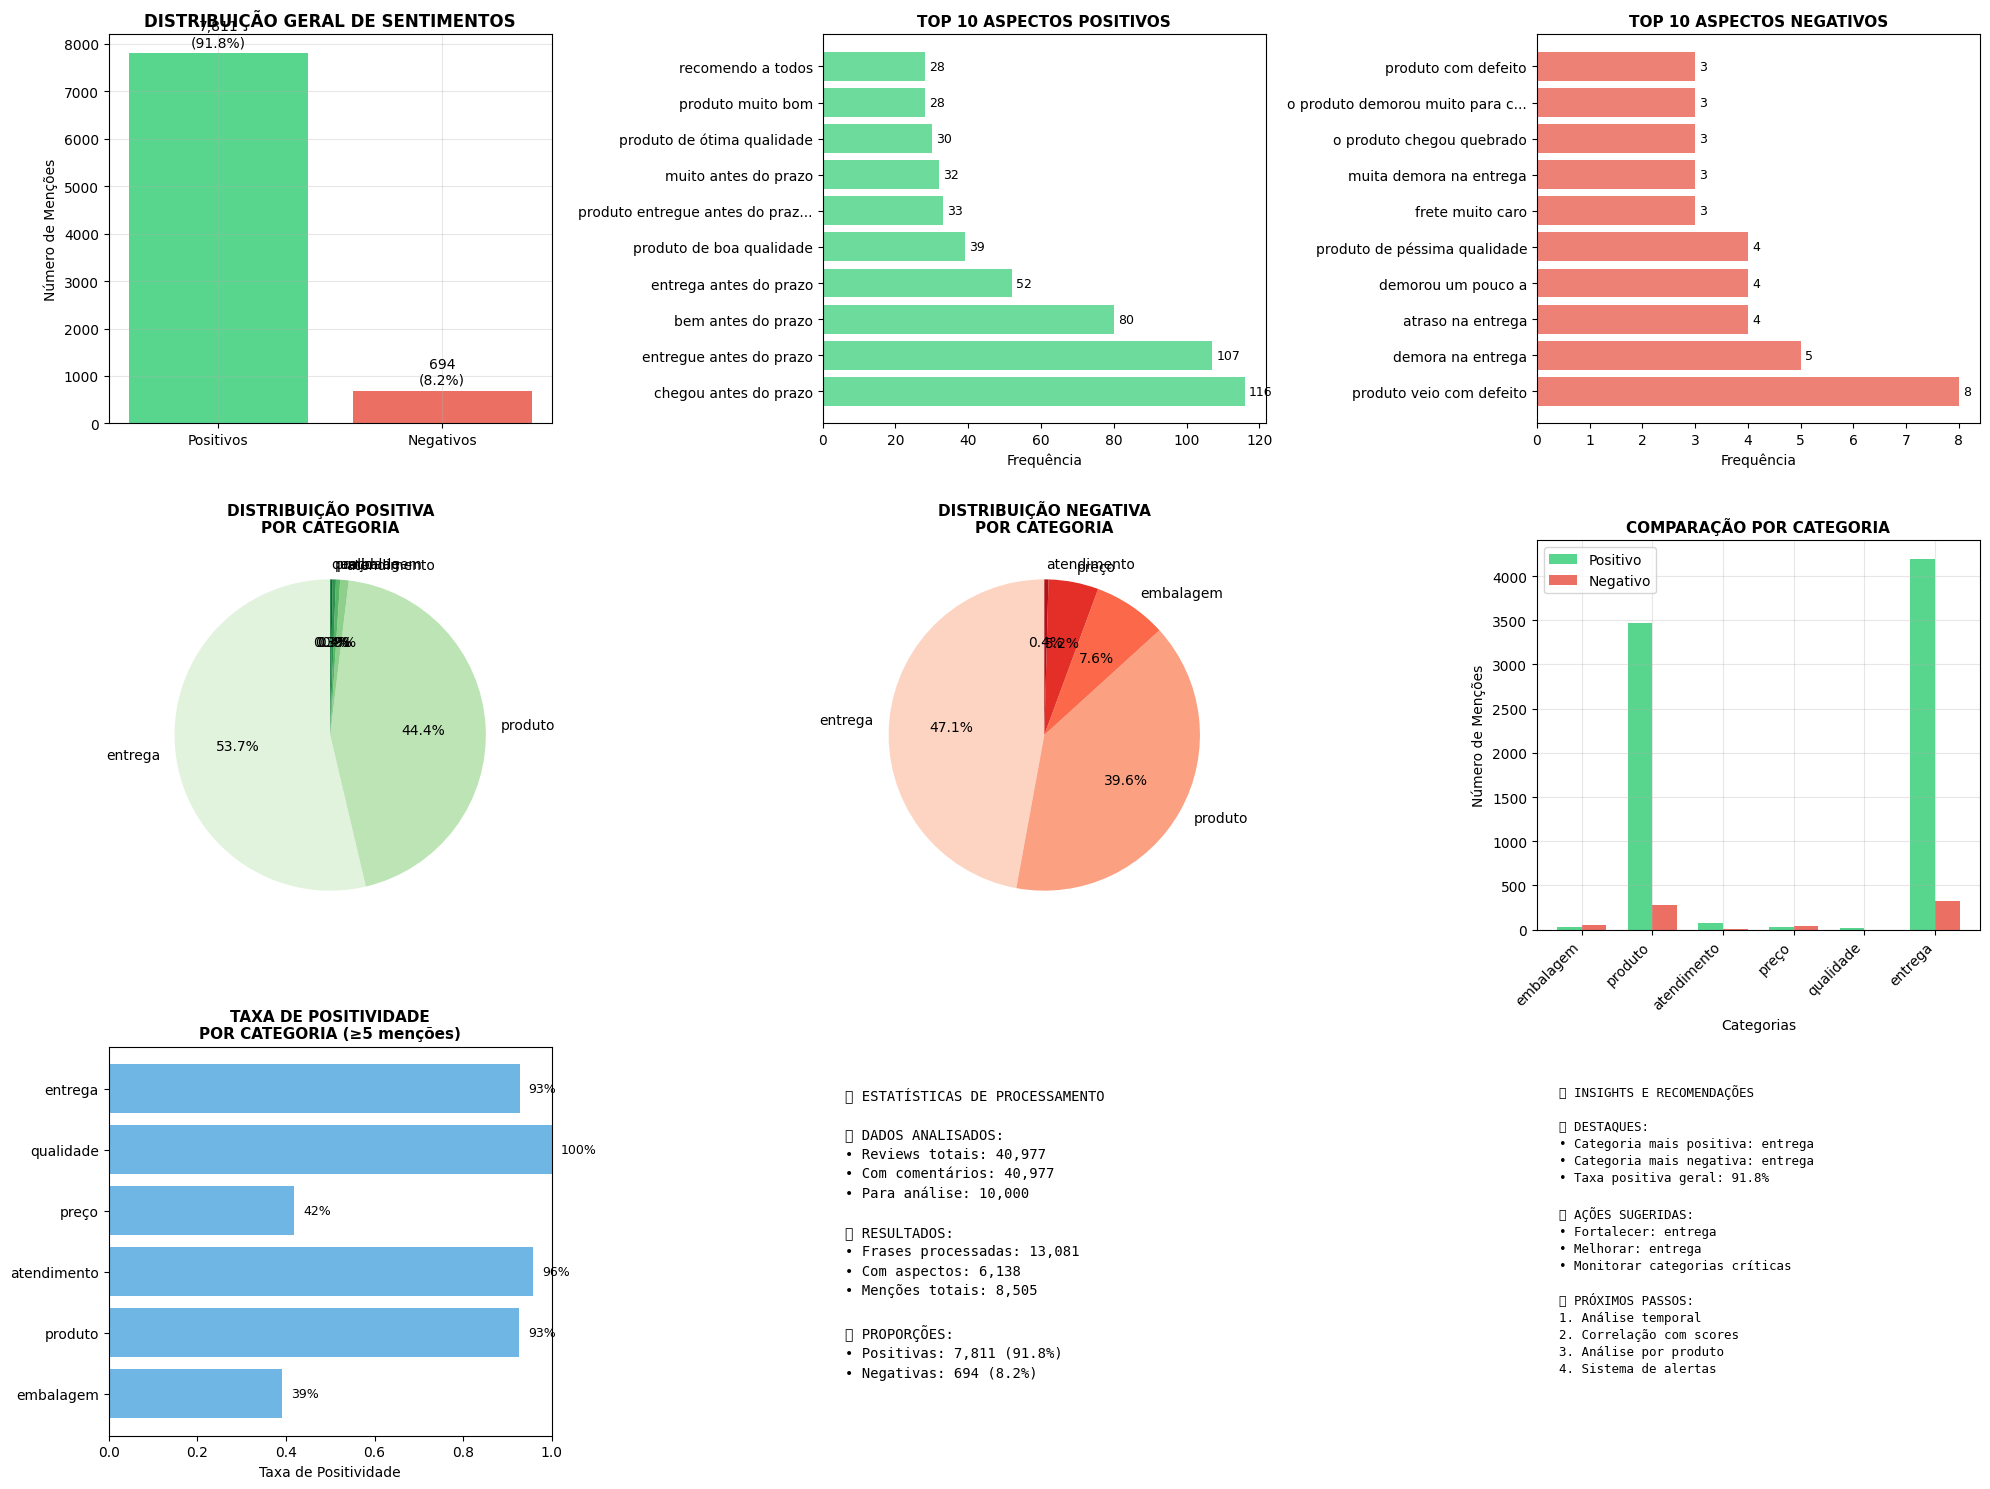

In [ ]:
# @title Análise de Aspectos em Reviews de E-commerce com Visualizações

warnings.filterwarnings('ignore')

# Configurações de estilo
plt.style.use('default')
sns.set_palette("husl")
print("=" * 70)
print("ANÁLISE DE ASPECTOS EM REVIEWS DE E-COMMERCE")
print("=" * 70)

# =============================================================================
# 1. PREPARAÇÃO E ANÁLISE INICIAL DOS DADOS
# =============================================================================

print("\n" + "=" * 50)
print("1. PREPARAÇÃO E ANÁLISE INICIAL DOS DADOS")
print("=" * 50)

# Primeiro, vamos preparar os dados
print("📊 ANALISANDO BASE DE DADOS...")

# Verificar se a coluna existe
if 'review_comment_message' not in reviews_df.columns:
    print("❌ ERRO: Coluna 'review_comment_message' não encontrada!")
    print("📋 Colunas disponíveis:")
    print(reviews_df.columns.tolist())
    exit()

# Estatísticas iniciais
total_reviews = len(reviews_df)
reviews_com_comentario = reviews_df['review_comment_message'].notna().sum()
reviews_sem_comentario = total_reviews - reviews_com_comentario

print(f"• Total de reviews: {total_reviews:,}")
print(f"• Reviews com comentários: {reviews_com_comentario:,} ({reviews_com_comentario/total_reviews*100:.1f}%)")
print(f"• Reviews sem comentários: {reviews_sem_comentario:,} ({reviews_sem_comentario/total_reviews*100:.1f}%)")

# Remover comentários vazios e converter para lista
textos_reviews = reviews_df['review_comment_message'].dropna().astype(str).tolist()

# Filtrar comentários muito curtos (menos de 3 palavras)
textos_filtrados = []
for texto in textos_reviews:
    palavras = str(texto).split()
    if len(palavras) >= 3:  # Pelo menos 3 palavras para ser significativo
        textos_filtrados.append(texto)

print(f"• Comentários após filtro (≥3 palavras): {len(textos_filtrados):,}")

# Amostrar se necessário para performance
if len(textos_filtrados) > 10000:
    print("⚠️  Base muito grande, amostrando 10.000 comentários...")
    textos_analise = textos_filtrados[:10000]
else:
    textos_analise = textos_filtrados

print(f"🎯 Total de reviews para análise: {len(textos_analise):,}")

# =============================================================================
# 2. DEFINIÇÃO EXPANDIDA DE ASPECTOS E PALAVRAS-CHAVE
# =============================================================================

print("\n" + "=" * 50)
print("2. DEFINIÇÃO EXPANDIDA DE ASPECTOS E PALAVRAS-CHAVE")
print("=" * 50)

# Definição expandida de palavras-chave por aspecto
aspectos_detalhados = {
    'entrega': {
        'positivo': ['rápido', 'rápida', 'rápidos', 'rápidas', 'entregue', 'entregou', 'prazo', 'pontual',
                    'veloz', 'ágil', 'eficiente', 'no prazo', 'antes do prazo', 'express', 'imediato',
                    'pronta entrega', 'entrega rápida', 'chegou rápido', 'entregue rápido', 'chegou bem',
                    'entregue no prazo', 'entrega perfeita', 'entregue antes', 'rapidez', 'ágil',
                    'frete rápido', 'entrega ágil', 'chegou antes', 'no tempo certo', 'pontualidade'],
        'negativo': ['demorou', 'demorada', 'demorado', 'demorados', 'atrasou', 'atrasado', 'atrasada',
                    'lento', 'lenta', 'lentos', 'lentas', 'tardia', 'tardio', 'atraso', 'demora',
                    'entregue atrasado', 'chegou atrasado', 'demorou muito', 'muita demora', 'atrasou muito',
                    'demora na entrega', 'entregue com atraso', 'lentidão', 'moroso', 'frete demorado',
                    'entrega lenta', 'chegou tarde', 'fora do prazo', 'atraso na entrega']
    },
    'produto': {
        'positivo': ['perfeito', 'perfeita', 'ótimo', 'ótima', 'excelente', 'maravilhoso', 'maravilhosa',
                    'qualidade', 'qualificado', 'superou', 'surpreendeu', 'gostei', 'adorei', 'amei',
                    'funciona', 'funcionando', 'bom', 'boa', 'incrível', 'fantástico', 'nota 10',
                    'recomendo', 'recomenda', 'recomendado', 'recomendada', 'vale a pena', 'top',
                    'show', 'sensacional', 'incrivel', 'perfeição', 'excelência', 'produto bom',
                    'qualidade boa', 'funciona perfeitamente', 'atendeu expectativas'],
        'negativo': ['ruim', 'péssimo', 'péssima', 'horrível', 'terrível', 'decepcionante', 'lixo',
                    'quebrou', 'quebrado', 'danificado', 'danificada', 'defeito', 'defeituoso',
                    'não funciona', 'não recomendo', 'desisti', 'devolvi', 'arrependimento',
                    'qualidade ruim', 'produto ruim', 'não presta', 'fraco', 'horroroso', 'pessimo',
                    'decepcionou', 'não gostei', 'desapontado', 'produto defeituoso', 'não funciona bem',
                    'qualidade inferior', 'não atendeu']
    },
    'atendimento': {
        'positivo': ['atendimento bom', 'atendimento excelente', 'prestativo', 'educado', 'educada',
                    'simpático', 'simpática', 'respondeu', 'ajudou', 'solucionou', 'resolveu',
                    'atendimento rápido', 'eficiente', 'profissional', 'competente', 'atendeu',
                    'esclareceu', 'orientou', 'atendimento perfeito', 'gentil', 'cortês',
                    'suporte bom', 'atendimento qualificado', 'respeitoso', 'atencioso'],
        'negativo': ['atendimento ruim', 'mal educado', 'grosso', 'grossa', 'ignorou', 'não respondeu',
                    'não ajudou', 'atendimento lento', 'incompetente', 'despreparado', 'grosseiro',
                    'atendimento péssimo', 'não resolveu', 'ignorante', 'desatento', 'atendimento demorado',
                    'suporte ruim', 'atendimento porco', 'mal atendimento', 'não atendeu', 'indelicado']
    },
    'embalagem': {
        'positivo': ['bem embalado', 'embalagem boa', 'protegido', 'seguro', 'cuidado', 'organizado',
                    'embalagem perfeita', 'bem acondicionado', 'embalagem adequada', 'embalagem segura',
                    'bem protegido', 'embalagem intacta', 'bem embalada', 'embalagem cuidadosa',
                    'embalagem resistente', 'bem empacotado', 'embalagem de qualidade'],
        'negativo': ['mal embalado', 'embalagem ruim', 'amassado', 'amassada', 'quebrada', 'avariada',
                    'embalagem danificada', 'sem proteção', 'frágil', 'embalagem frágil', 'amassou',
                    'embalagem aberta', 'mal acondicionado', 'embalagem violada', 'avariado',
                    'embalagem amassada', 'produto solto', 'embalagem quebrada', 'sem cuidado']
    },
    'preço': {
        'positivo': ['preço justo', 'preço bom', 'barato', 'econômico', 'vale o preço', 'compensa',
                    'preço baixo', 'acessível', 'custobenefício', 'relação custo benefício', 'baratinho',
                    'preço honesto', 'conta justa', 'preço razoável', 'vale cada centavo', 'preço competitivo',
                    'bom custo', 'preço em conta', 'econômico', 'preço baixo'],
        'negativo': ['caro', 'caríssimo', 'superfaturado', 'preço alto', 'não vale', 'custo alto',
                    'muito caro', 'preço abusivo', 'cobrança excessiva', 'caro demais', 'superfaturado',
                    'preço inflado', 'não compensa', 'muito caro para', 'preço exagerado', 'preço salgado',
                    'cobrança abusiva', 'preço elevado', 'valor alto', 'não vale o preço']
    },
    'qualidade': {
        'positivo': ['qualidade excelente', 'alta qualidade', 'premium', 'durável', 'resistente',
                    'material bom', 'acabamento bom', 'bem feito', 'bem fabricado', 'qualidade superior',
                    'material de qualidade', 'acabamento perfeito', 'resistência', 'durabilidade',
                    'qualidade top', 'acabamento impecável', 'material resistente', 'qualidade garantida'],
        'negativo': ['qualidade ruim', 'baixa qualidade', 'frágil', 'quebradiço', 'material ruim',
                    'acabamento ruim', 'mal feito', 'qualidade inferior', 'qualidade duvidosa',
                    'material frágil', 'acabamento porco', 'qualidade péssima', 'qualidade baixíssima',
                    'material inferior', 'acabamento ruim', 'qualidade questionável', 'não durável']
    }
}

print("🎯 ASPECTOS CONFIGURADOS:")
for aspecto, palavras in aspectos_detalhados.items():
    print(f"   • {aspecto}: {len(palavras['positivo'])} palavras positivas, {len(palavras['negativo'])} negativas")

# Combinar todas as palavras-chave
todas_palavras_pos = [palavra for aspecto in aspectos_detalhados.values()
                      for palavra in aspecto['positivo']]
todas_palavras_neg = [palavra for aspecto in aspectos_detalhados.values()
                      for palavra in aspecto['negativo']]

print(f"\n📊 TOTAL DE PALAVRAS-CHAVE:")
print(f"   • Positivas: {len(todas_palavras_pos)}")
print(f"   • Negativas: {len(todas_palavras_neg)}")

# =============================================================================
# 3. FUNÇÕES AVANÇADAS DE ANÁLISE
# =============================================================================

print("\n" + "=" * 50)
print("3. FUNÇÕES AVANÇADAS DE ANÁLISE")
print("=" * 50)

def extrair_frases_significativas(textos, min_palavras=3, max_palavras=25):
    """
    Extrai frases significativas dos textos
    """
    todas_frases = []

    for texto in textos:
        if pd.isna(texto) or texto == '':
            continue

        # Normalizar pontuação
        texto = str(texto).replace('!', '.').replace('?', '.').replace(';', '.').replace(':', '.')

        # Dividir em frases
        frases = [f.strip() for f in texto.split('.') if f.strip()]

        for frase in frases:
            palavras = frase.split()
            if min_palavras <= len(palavras) <= max_palavras:
                todas_frases.append(frase)

    return todas_frases

def identificar_aspectos_com_contexto(frase, palavras_positivas, palavras_negativas, contexto_tamanho=3):
    """
    Identifica aspectos mencionados na frase com contexto
    """
    aspectos_encontrados = []
    frase_lower = frase.lower()
    palavras = frase_lower.split()

    # Verificar palavras positivas
    for palavra_chave in palavras_positivas:
        if palavra_chave in frase_lower:
            try:
                idx = palavras.index(palavra_chave)
                inicio = max(0, idx - contexto_tamanho)
                fim = min(len(palavras), idx + contexto_tamanho + 1)
                contexto = ' '.join(palavras[inicio:fim])
                aspectos_encontrados.append((contexto, 'positivo'))
            except:
                continue

    # Verificar palavras negativas
    for palavra_chave in palavras_negativas:
        if palavra_chave in frase_lower:
            try:
                idx = palavras.index(palavra_chave)
                inicio = max(0, idx - contexto_tamanho)
                fim = min(len(palavras), idx + contexto_tamanho + 1)
                contexto = ' '.join(palavras[inicio:fim])
                aspectos_encontrados.append((contexto, 'negativo'))
            except:
                continue

    return aspectos_encontrados

def analisar_sentimentos_avancado(textos, palavras_positivas, palavras_negativas):
    """
    Analisa sentimentos das frases e agrupa por aspectos
    """
    resultados = {
        'positivos': defaultdict(int),
        'negativos': defaultdict(int),
        'estatisticas': {
            'total_frases': 0,
            'frases_com_aspectos': 0,
            'aspectos_identificados': 0
        }
    }

    frases = extrair_frases_significativas(textos)
    resultados['estatisticas']['total_frases'] = len(frases)

    for frase in frases:
        aspectos_encontrados = identificar_aspectos_com_contexto(frase, palavras_positivas, palavras_negativas)

        if aspectos_encontrados:
            resultados['estatisticas']['frases_com_aspectos'] += 1
            resultados['estatisticas']['aspectos_identificados'] += len(aspectos_encontrados)

        for contexto, sentimento in aspectos_encontrados:
            if sentimento == 'positivo':
                resultados['positivos'][contexto] += 1
            else:
                resultados['negativos'][contexto] += 1

    return resultados

print("🔄 EXECUTANDO ANÁLISE AVANÇADA...")
resultados = analisar_sentimentos_avancado(textos_analise, todas_palavras_pos, todas_palavras_neg)

# =============================================================================
# 4. RELATÓRIO DETALHADO DOS RESULTADOS
# =============================================================================

print("\n" + "=" * 50)
print("4. RELATÓRIO DETALHADO DOS RESULTADOS")
print("=" * 50)

# Estatísticas gerais
total_positivos = sum(resultados['positivos'].values())
total_negativos = sum(resultados['negativos'].values())
total_mencoes = total_positivos + total_negativos

print(f"\n📊 ESTATÍSTICAS DE PROCESSAMENTO:")
print(f"   • Total de frases analisadas: {resultados['estatisticas']['total_frases']:,}")
print(f"   • Frases com aspectos identificados: {resultados['estatisticas']['frases_com_aspectos']:,}")
print(f"   • Total de menções a aspectos: {resultados['estatisticas']['aspectos_identificados']:,}")

print(f"\n📈 ESTATÍSTICAS GERAIS:")
print(f"   • Total de menções positivas: {total_positivos:,}")
print(f"   • Total de menções negativas: {total_negativos:,}")
print(f"   • Total geral de menções: {total_mencoes:,}")

if total_mencoes > 0:
    print(f"   • Proporção positiva: {(total_positivos/total_mencoes)*100:.1f}%")
    print(f"   • Proporção negativa: {(total_negativos/total_mencoes)*100:.1f}%")
    print(f"   • Razão positivo/negativo: {total_positivos/total_negativos:.2f}" if total_negativos > 0 else "   • Razão positivo/negativo: ∞")

print(f"\n💚 TOP 15 ASPECTOS POSITIVOS MAIS MENCIONADOS:")
print("-" * 50)
aspectos_positivos_ordenados = sorted(resultados['positivos'].items(), key=lambda x: (-x[1], x[0]))[:15]
for i, (aspecto, freq) in enumerate(aspectos_positivos_ordenados, 1):
    print(f"   {i:2d}. '{aspecto}' → {freq} menções")

print(f"\n❤️ TOP 15 ASPECTOS NEGATIVOS MAIS MENCIONADOS:")
print("-" * 50)
aspectos_negativos_ordenados = sorted(resultados['negativos'].items(), key=lambda x: (-x[1], x[0]))[:15]
for i, (aspecto, freq) in enumerate(aspectos_negativos_ordenados, 1):
    print(f"   {i:2d}. '{aspecto}' → {freq} menções")

# =============================================================================
# 5. ANÁLISE POR CATEGORIA DE ASPECTOS
# =============================================================================

print("\n" + "=" * 50)
print("5. ANÁLISE POR CATEGORIA DE ASPECTOS")
print("=" * 50)

def classificar_aspecto_por_categoria(contexto, aspectos_dict):
    """
    Classifica um contexto em uma categoria de aspecto
    """
    for categoria, palavras in aspectos_dict.items():
        for palavra in palavras['positivo'] + palavras['negativo']:
            if palavra in contexto.lower():
                return categoria
    return 'outros'

# Classificar aspectos por categoria
categorias_positivas = defaultdict(int)
categorias_negativas = defaultdict(int)

for contexto, freq in resultados['positivos'].items():
    categoria = classificar_aspecto_por_categoria(contexto, aspectos_detalhados)
    categorias_positivas[categoria] += freq

for contexto, freq in resultados['negativos'].items():
    categoria = classificar_aspecto_por_categoria(contexto, aspectos_detalhados)
    categorias_negativas[categoria] += freq

print("📊 DISTRIBUIÇÃO POR CATEGORIA (POSITIVAS):")
for categoria, freq in sorted(categorias_positivas.items(), key=lambda x: -x[1]):
    if freq > 0:
        percentual = (freq / total_positivos * 100) if total_positivos > 0 else 0
        print(f"   • {categoria.upper()}: {freq} menções ({percentual:.1f}%)")

print(f"\n📊 DISTRIBUIÇÃO POR CATEGORIA (NEGATIVAS):")
for categoria, freq in sorted(categorias_negativas.items(), key=lambda x: -x[1]):
    if freq > 0:
        percentual = (freq / total_negativos * 100) if total_negativos > 0 else 0
        print(f"   • {categoria.upper()}: {freq} menções ({percentual:.1f}%)")

# =============================================================================
# 6. VISUALIZAÇÕES COMPLETAS
# =============================================================================

print("\n" + "=" * 50)
print("6. VISUALIZAÇÕES COMPLETAS")
print("=" * 50)

# Criar figura principal
fig = plt.figure(figsize=(20, 15))
gs = GridSpec(3, 3, figure=fig)

# Gráfico 1: Distribuição Geral de Sentimentos
ax1 = fig.add_subplot(gs[0, 0])
sentimentos_data = [total_positivos, total_negativos]
labels = ['Positivos', 'Negativos']
colors = ['#2ecc71', '#e74c3c']

bars = ax1.bar(labels, sentimentos_data, color=colors, alpha=0.8)
ax1.set_title('DISTRIBUIÇÃO GERAL DE SENTIMENTOS', fontweight='bold', fontsize=12)
ax1.set_ylabel('Número de Menções')
ax1.grid(True, alpha=0.3)

# Adicionar valores e percentuais
for bar, valor in zip(bars, sentimentos_data):
    height = bar.get_height()
    percentual = (valor / total_mencoes * 100) if total_mencoes > 0 else 0
    ax1.text(bar.get_x() + bar.get_width()/2., height + max(sentimentos_data)*0.01,
            f'{valor:,}\n({percentual:.1f}%)', ha='center', va='bottom', fontsize=10)

# Gráfico 2: Top Aspectos Positivos
ax2 = fig.add_subplot(gs[0, 1])
top_positivos = aspectos_positivos_ordenados[:10]
aspectos_pos = [asp[0][:30] + '...' if len(asp[0]) > 30 else asp[0] for asp in top_positivos]
frequencias_pos = [asp[1] for asp in top_positivos]

if top_positivos:
    bars_pos = ax2.barh(range(len(aspectos_pos)), frequencias_pos, color='#2ecc71', alpha=0.7)
    ax2.set_yticks(range(len(aspectos_pos)))
    ax2.set_yticklabels(aspectos_pos)
    ax2.set_xlabel('Frequência')
    ax2.set_title('TOP 10 ASPECTOS POSITIVOS', fontweight='bold', fontsize=11)

    for i, (bar, freq) in enumerate(zip(bars_pos, frequencias_pos)):
        width = bar.get_width()
        ax2.text(width + max(frequencias_pos)*0.01, bar.get_y() + bar.get_height()/2,
                f'{freq}', ha='left', va='center', fontsize=9)

# Gráfico 3: Top Aspectos Negativos
ax3 = fig.add_subplot(gs[0, 2])
top_negativos = aspectos_negativos_ordenados[:10]
aspectos_neg = [asp[0][:30] + '...' if len(asp[0]) > 30 else asp[0] for asp in top_negativos]
frequencias_neg = [asp[1] for asp in top_negativos]

if top_negativos:
    bars_neg = ax3.barh(range(len(aspectos_neg)), frequencias_neg, color='#e74c3c', alpha=0.7)
    ax3.set_yticks(range(len(aspectos_neg)))
    ax3.set_yticklabels(aspectos_neg)
    ax3.set_xlabel('Frequência')
    ax3.set_title('TOP 10 ASPECTOS NEGATIVOS', fontweight='bold', fontsize=11)

    for i, (bar, freq) in enumerate(zip(bars_neg, frequencias_neg)):
        width = bar.get_width()
        ax3.text(width + max(frequencias_neg)*0.01, bar.get_y() + bar.get_height()/2,
                f'{freq}', ha='left', va='center', fontsize=9)

# Gráfico 4: Distribuição por Categoria (Positivas)
ax4 = fig.add_subplot(gs[1, 0])
categorias_pos = []
valores_pos = []

for categoria, valor in sorted(categorias_positivas.items(), key=lambda x: -x[1]):
    if valor > 0:
        categorias_pos.append(categoria)
        valores_pos.append(valor)

if categorias_pos:
    wedges, texts, autotexts = ax4.pie(valores_pos, labels=categorias_pos, autopct='%1.1f%%',
                                      startangle=90, colors=sns.color_palette("Greens", len(categorias_pos)))
    ax4.set_title('DISTRIBUIÇÃO POSITIVA\nPOR CATEGORIA', fontweight='bold', fontsize=11)

# Gráfico 5: Distribuição por Categoria (Negativas)
ax5 = fig.add_subplot(gs[1, 1])
categorias_neg = []
valores_neg = []

for categoria, valor in sorted(categorias_negativas.items(), key=lambda x: -x[1]):
    if valor > 0:
        categorias_neg.append(categoria)
        valores_neg.append(valor)

if categorias_neg:
    wedges, texts, autotexts = ax5.pie(valores_neg, labels=categorias_neg, autopct='%1.1f%%',
                                      startangle=90, colors=sns.color_palette("Reds", len(categorias_neg)))
    ax5.set_title('DISTRIBUIÇÃO NEGATIVA\nPOR CATEGORIA', fontweight='bold', fontsize=11)

# Gráfico 6: Comparação Positivo/Negativo por Categoria
ax6 = fig.add_subplot(gs[1, 2])
todas_categorias = set(list(categorias_positivas.keys()) + list(categorias_negativas.keys()))
categorias_comparacao = []
valores_pos_comp = []
valores_neg_comp = []

for categoria in todas_categorias:
    if categorias_positivas.get(categoria, 0) > 0 or categorias_negativas.get(categoria, 0) > 0:
        categorias_comparacao.append(categoria)
        valores_pos_comp.append(categorias_positivas.get(categoria, 0))
        valores_neg_comp.append(categorias_negativas.get(categoria, 0))

if categorias_comparacao:
    x = np.arange(len(categorias_comparacao))
    width = 0.35

    bars_pos_comp = ax6.bar(x - width/2, valores_pos_comp, width, label='Positivo', color='#2ecc71', alpha=0.8)
    bars_neg_comp = ax6.bar(x + width/2, valores_neg_comp, width, label='Negativo', color='#e74c3c', alpha=0.8)

    ax6.set_xlabel('Categorias')
    ax6.set_ylabel('Número de Menções')
    ax6.set_title('COMPARAÇÃO POR CATEGORIA', fontweight='bold', fontsize=11)
    ax6.set_xticks(x)
    ax6.set_xticklabels(categorias_comparacao, rotation=45, ha='right')
    ax6.legend()
    ax6.grid(True, alpha=0.3)

# Gráfico 7: Taxa de Positividade por Categoria
ax7 = fig.add_subplot(gs[2, 0])
categorias_taxa = []
taxas_positividade = []

for categoria in todas_categorias:
    total_categoria = categorias_positivas.get(categoria, 0) + categorias_negativas.get(categoria, 0)
    if total_categoria >= 5:  # Apenas categorias com pelo menos 5 menções
        taxa = categorias_positivas.get(categoria, 0) / total_categoria
        categorias_taxa.append(categoria)
        taxas_positividade.append(taxa)

if categorias_taxa:
    bars_taxa = ax7.barh(categorias_taxa, taxas_positividade, color='#3498db', alpha=0.7)
    ax7.set_xlabel('Taxa de Positividade')
    ax7.set_title('TAXA DE POSITIVIDADE\nPOR CATEGORIA (≥5 menções)', fontweight='bold', fontsize=11)
    ax7.set_xlim(0, 1)

    for bar, taxa in zip(bars_taxa, taxas_positividade):
        width = bar.get_width()
        ax7.text(width + 0.02, bar.get_y() + bar.get_height()/2,
                f'{taxa:.0%}', ha='left', va='center', fontsize=9)

# Gráfico 8: Estatísticas de Processamento
ax8 = fig.add_subplot(gs[2, 1])
ax8.axis('off')

estatisticas_texto = f"""
📊 ESTATÍSTICAS DE PROCESSAMENTO

📈 DADOS ANALISADOS:
• Reviews totais: {total_reviews:,}
• Com comentários: {reviews_com_comentario:,}
• Para análise: {len(textos_analise):,}

🎯 RESULTADOS:
• Frases processadas: {resultados['estatisticas']['total_frases']:,}
• Com aspectos: {resultados['estatisticas']['frases_com_aspectos']:,}
• Menções totais: {total_mencoes:,}

📊 PROPORÇÕES:
• Positivas: {total_positivos:,} ({(total_positivos/total_mencoes*100) if total_mencoes > 0 else 0:.1f}%)
• Negativas: {total_negativos:,} ({(total_negativos/total_mencoes*100) if total_mencoes > 0 else 0:.1f}%)
"""

ax8.text(0.05, 0.95, estatisticas_texto, transform=ax8.transAxes, fontsize=10,
        verticalalignment='top', fontfamily='monospace', linespacing=1.5)

# Gráfico 9: Insights e Recomendações
ax9 = fig.add_subplot(gs[2, 2])
ax9.axis('off')

# Calcular insights
if categorias_positivas and categorias_negativas:
    categoria_mais_positiva = max(categorias_positivas.items(), key=lambda x: x[1])[0]
    categoria_mais_negativa = max(categorias_negativas.items(), key=lambda x: x[1])[0]

    insights_texto = f"""
💡 INSIGHTS E RECOMENDAÇÕES

🎯 DESTAQUES:
• Categoria mais positiva: {categoria_mais_positiva}
• Categoria mais negativa: {categoria_mais_negativa}
• Taxa positiva geral: {(total_positivos/total_mencoes*100) if total_mencoes > 0 else 0:.1f}%

🔧 AÇÕES SUGERIDAS:
• Fortalecer: {categoria_mais_positiva}
• Melhorar: {categoria_mais_negativa}
• Monitorar categorias críticas

📈 PRÓXIMOS PASSOS:
1. Análise temporal
2. Correlação com scores
3. Análise por produto
4. Sistema de alertas
"""

ax9.text(0.05, 0.95, insights_texto, transform=ax9.transAxes, fontsize=9,
        verticalalignment='top', fontfamily='monospace', linespacing=1.4)

plt.tight_layout()
plt.savefig('analise_aspectos_ecommerce.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✅ Gráfico salvo como 'analise_aspectos_ecommerce.png'")

# =============================================================================
# 7. SALVAMENTO DE RESULTADOS
# =============================================================================

print("\n" + "=" * 50)
print("7. SALVAMENTO DE RESULTADOS")
print("=" * 50)

# Salvar resultados detalhados
resultados_detalhados = []
for contexto, freq in resultados['positivos'].items():
    resultados_detalhados.append({
        'contexto': contexto,
        'sentimento': 'positivo',
        'frequencia': freq,
        'categoria': classificar_aspecto_por_categoria(contexto, aspectos_detalhados)
    })

for contexto, freq in resultados['negativos'].items():
    resultados_detalhados.append({
        'contexto': contexto,
        'sentimento': 'negativo',
        'frequencia': freq,
        'categoria': classificar_aspecto_por_categoria(contexto, aspectos_detalhados)
    })

df_resultados = pd.DataFrame(resultados_detalhados)
df_resultados.to_csv('resultados_aspectos_detalhados.csv', index=False, encoding='utf-8')
print("💾 Resultados detalhados salvos em 'resultados_aspectos_detalhados.csv'")

# Salvar métricas por categoria
df_categorias = pd.DataFrame({
    'categoria': list(categorias_positivas.keys()) + list(categorias_negativas.keys()),
    'positivas': [categorias_positivas.get(cat, 0) for cat in list(categorias_positivas.keys()) + list(categorias_negativas.keys())],
    'negativas': [categorias_negativas.get(cat, 0) for cat in list(categorias_positivas.keys()) + list(categorias_negativas.keys())]
})
df_categorias['total'] = df_categorias['positivas'] + df_categorias['negativas']
df_categorias['taxa_positividade'] = df_categorias['positivas'] / df_categorias['total']
df_categorias.to_csv('metricas_categorias.csv', index=False, encoding='utf-8')
print("💾 Métricas por categoria salvas em 'metricas_categorias.csv'")

print("\n" + "=" * 70)
print("ANÁLISE DE ASPECTOS CONCLUÍDA! 🎉")
print("=" * 70)

EXPLICABILIDADE DO MODELO COM LIME E ANÁLISE DE FEATURES

1. CONFIGURAÇÃO INICIAL E PREPARAÇÃO DO MODELO
📊 DADOS PARA TREINAMENTO:
   • Total de amostras: 40,977
   • Distribuição de sentimentos:
     Positivo: 26,530 (64.7%)
     Negativo: 10,890 (26.6%)
     Neutro: 3,557 (8.7%)
   • Classes presentes: [2 0 1]

🔧 CONFIGURANDO PIPELINE...
✅ Pipeline configurado:
   • Vectorizer: TF-IDF com 5000 features
   • Modelo: LogisticRegression
   • N-grams: (1, 2)

2. TREINAMENTO E AVALIAÇÃO DO MODELO
🎯 DIVISÃO DOS DADOS:
   • Treino: 32,781 amostras
   • Teste: 8,196 amostras

🤖 TREINANDO MODELO...
✅ MODELO TREINADO - Acurácia: 0.786

📊 RELATÓRIO DE CLASSIFICAÇÃO:
              precision    recall  f1-score   support

    Negativo       0.79      0.77      0.78      2178
      Neutro       0.24      0.49      0.32       712
    Positivo       0.96      0.83      0.89      5306

    accuracy                           0.79      8196
   macro avg       0.66      0.70      0.66      8196
weighted


ANÁLISE DE EXPLICABILIDADE CONCLUÍDA! 🎉


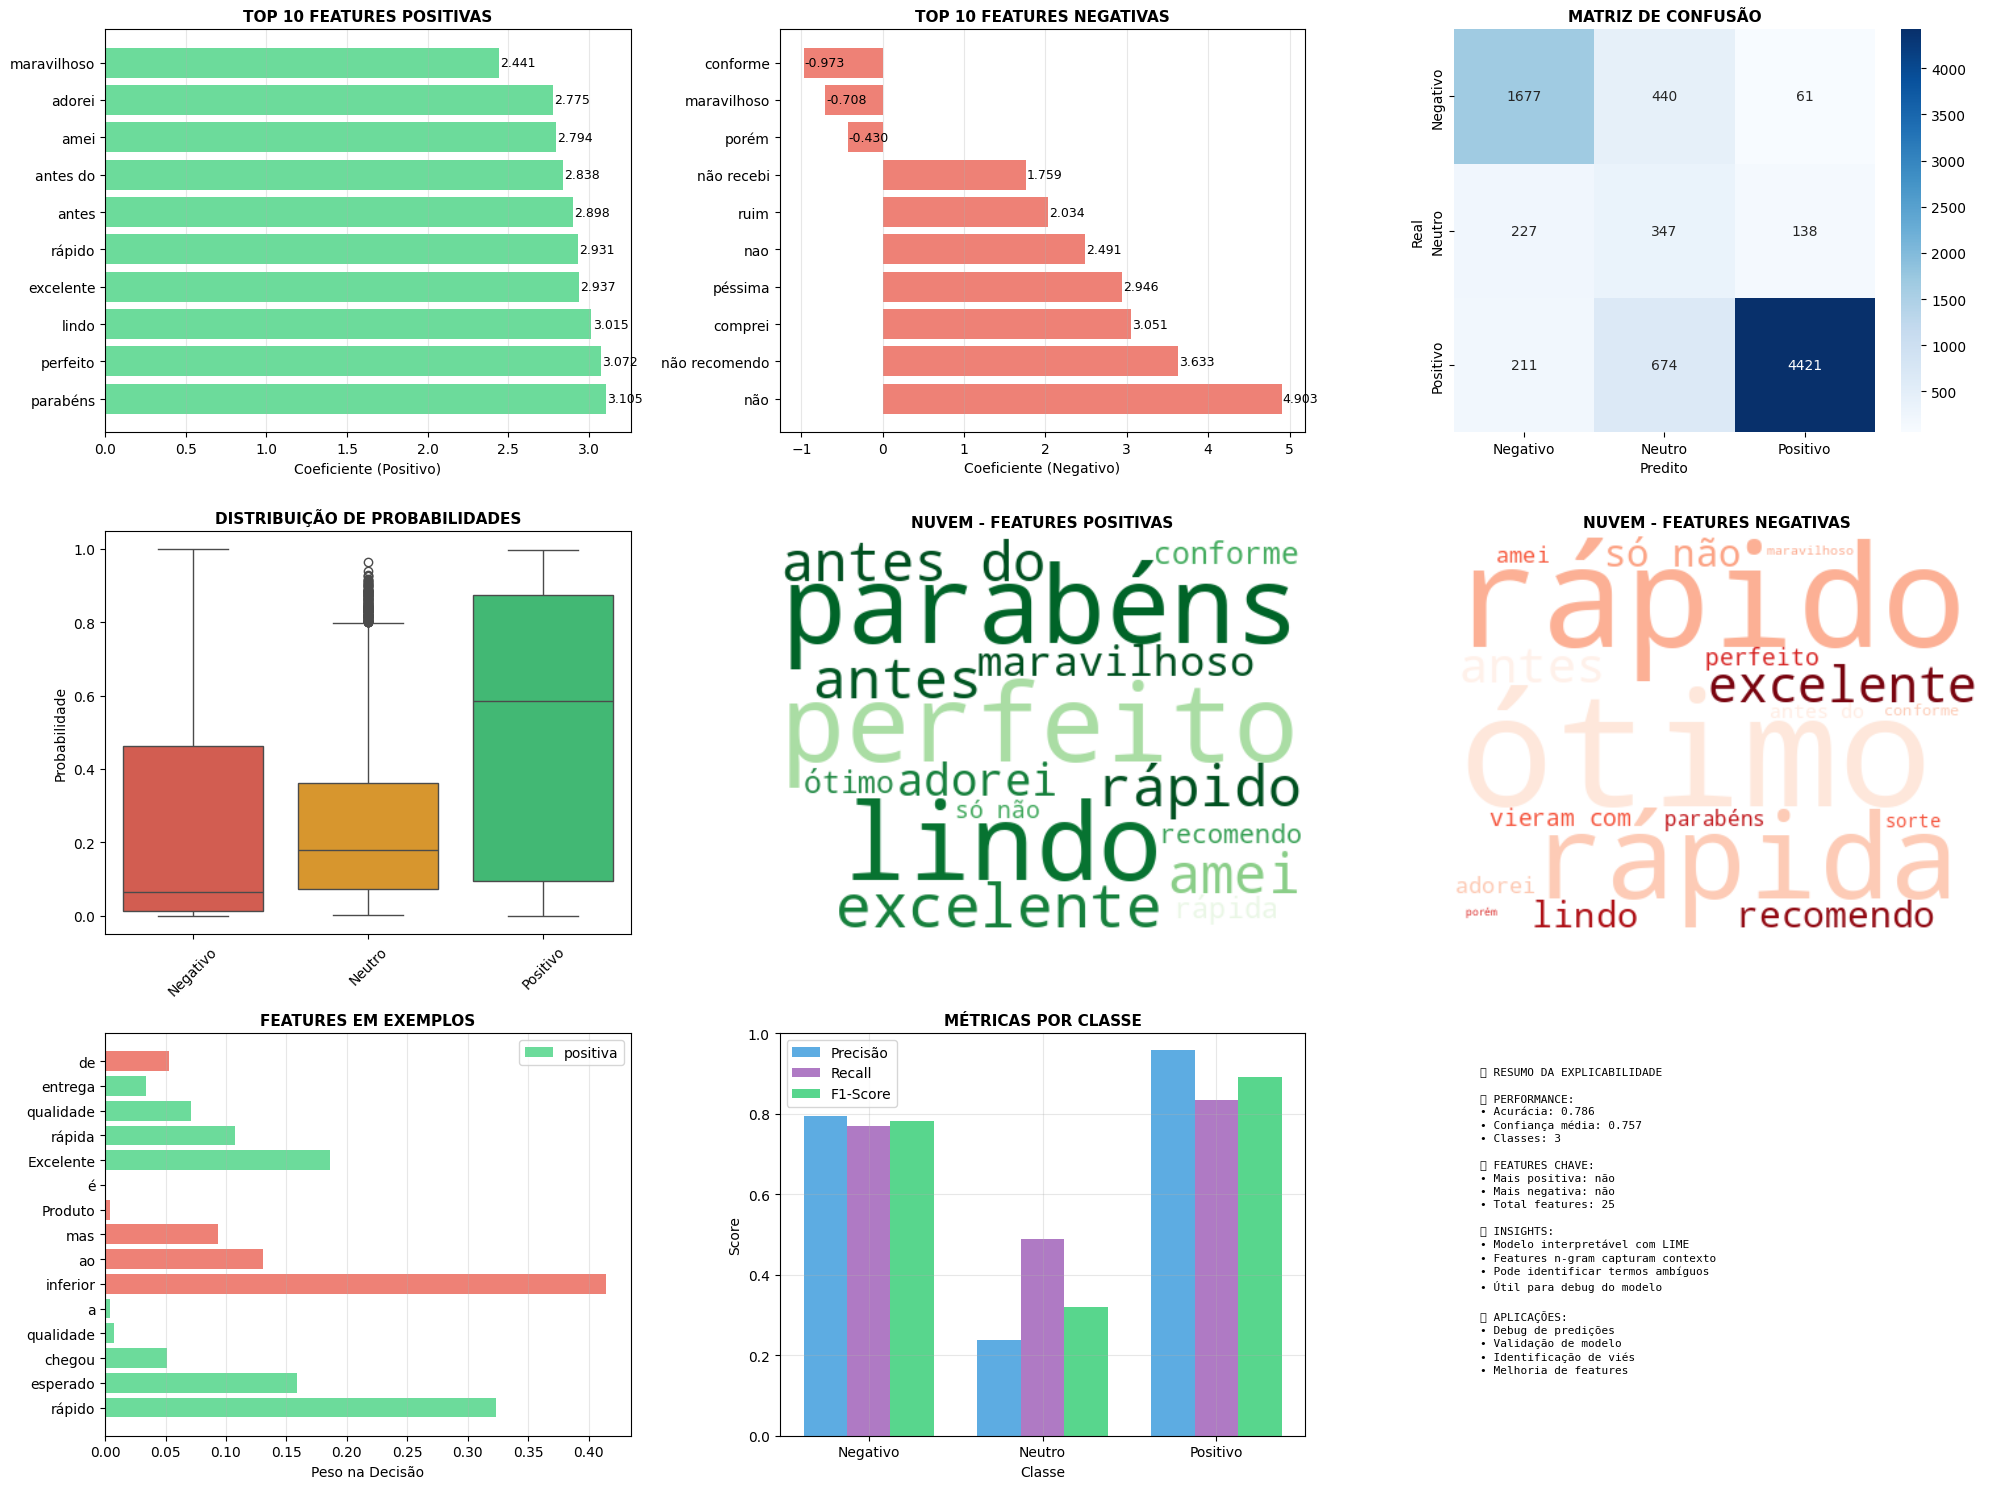

In [ ]:
# @title Explicabilidade do Modelo com LIME e Análise de Features (CORRIGIDO)

warnings.filterwarnings('ignore')

# Configurações de estilo
plt.style.use('default')
sns.set_palette("husl")
print("=" * 70)
print("EXPLICABILIDADE DO MODELO COM LIME E ANÁLISE DE FEATURES")
print("=" * 70)

# =============================================================================
# 1. CONFIGURAÇÃO INICIAL E PREPARAÇÃO DO MODELO
# =============================================================================

print("\n" + "=" * 50)
print("1. CONFIGURAÇÃO INICIAL E PREPARAÇÃO DO MODELO")
print("=" * 50)

# Verificar se temos dados para treinar o modelo
if 'review_comment_message' not in reviews_df.columns or 'sentiment' not in reviews_df.columns:
    print("❌ ERRO: Colunas necessárias não encontradas!")
    print("   É necessário ter 'review_comment_message' e 'sentiment'")
    exit()

# Preparar dados
dados_limpos = reviews_df[['review_comment_message', 'sentiment']].dropna()
X = dados_limpos['review_comment_message']
y = dados_limpos['sentiment']

print(f"📊 DADOS PARA TREINAMENTO:")
print(f"   • Total de amostras: {len(X):,}")
print(f"   • Distribuição de sentimentos:")
distribuicao = y.value_counts()
for sentimento, count in distribuicao.items():
    label = {0: 'Negativo', 1: 'Neutro', 2: 'Positivo'}.get(sentimento, f'Desconhecido ({sentimento})')
    print(f"     {label}: {count:,} ({count/len(y)*100:.1f}%)")

# Verificar se temos pelo menos 2 classes
classes_presentes = y.unique()
print(f"   • Classes presentes: {classes_presentes}")

if len(classes_presentes) < 2:
    print("❌ ERRO: É necessário pelo menos 2 classes para treinamento!")
    exit()

# Configurar vectorizer e modelo
print("\n🔧 CONFIGURANDO PIPELINE...")
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 2),
    stop_words=None
)

# Usar Logistic Regression para melhor interpretabilidade
model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'
)

# Criar pipeline
pipeline = make_pipeline(tfidf_vectorizer, model)

print("✅ Pipeline configurado:")
print(f"   • Vectorizer: TF-IDF com {tfidf_vectorizer.max_features} features")
print(f"   • Modelo: {model.__class__.__name__}")
print(f"   • N-grams: {tfidf_vectorizer.ngram_range}")

# =============================================================================
# 2. TREINAMENTO E AVALIAÇÃO DO MODELO
# =============================================================================

print("\n" + "=" * 50)
print("2. TREINAMENTO E AVALIAÇÃO DO MODELO")
print("=" * 50)

from sklearn.model_selection import train_test_split

# Dividir dados
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("🎯 DIVISÃO DOS DADOS:")
print(f"   • Treino: {len(X_train):,} amostras")
print(f"   • Teste: {len(X_test):,} amostras")

# Treinar modelo
print("\n🤖 TREINANDO MODELO...")
pipeline.fit(X_train, y_train)

# Avaliar modelo
y_pred = pipeline.predict(X_test)
accuracy = pipeline.score(X_test, y_test)

print(f"✅ MODELO TREINADO - Acurácia: {accuracy:.3f}")

# Relatório de classificação com tratamento de classes ausentes
print("\n📊 RELATÓRIO DE CLASSIFICAÇÃO:")
# Gerar relatório com as classes presentes
target_names = []
for classe in [0, 1, 2]:
    if classe in y_test.unique():
        target_names.append({0: 'Negativo', 1: 'Neutro', 2: 'Positivo'}[classe])

print(classification_report(y_test, y_pred, target_names=target_names))

# =============================================================================
# 3. CONFIGURAÇÃO DO EXPLICADOR LIME
# =============================================================================

print("\n" + "=" * 50)
print("3. CONFIGURAÇÃO DO EXPLICADOR LIME")
print("=" * 50)

# Criar lista de nomes de classes baseada nas classes presentes
class_names = []
for classe in [0, 1, 2]:
    if classe in y.unique():
        class_names.append({0: 'Negativo', 1: 'Neutro', 2: 'Positivo'}[classe])

print(f"🎯 CLASSES NO MODELO: {class_names}")

# Explicador LIME
explainer = lime.lime_text.LimeTextExplainer(
    class_names=class_names,
    random_state=42
)

print("✅ EXPLICADOR LIME CONFIGURADO:")
print(f"   • Classes: {explainer.class_names}")
print(f"   • Random state: {explainer.random_state}")

def explain_review(text, num_features=15, show_plot=True):
    """
    Explica a predição do modelo para um texto específico
    """
    try:
        # Fazer predição
        probas = pipeline.predict_proba([text])[0]
        predicao = pipeline.predict([text])[0]

        # Mapear predição para nome da classe
        pred_class_name = class_names[predicao] if predicao < len(class_names) else f'Classe {predicao}'

        # Gerar explicação
        exp = explainer.explain_instance(
            text,
            pipeline.predict_proba,
            num_features=num_features,
            top_labels=len(class_names)
        )

        # Mostrar resultados
        print(f"\n📝 TEXTO ANALISADO: \"{text}\"")
        print(f"🎯 PREDIÇÃO: {pred_class_name}")
        print(f"📊 PROBABILIDADES:")
        for i, classe in enumerate(class_names):
            print(f"   • {classe}: {probas[i]:.3f}")

        if show_plot:
            # Mostrar explicação no notebook
            print(f"\n🔍 EXPLICAÇÃO LIME (Top {num_features} features):")
            exp.show_in_notebook(text=True)

        return exp, probas, predicao

    except Exception as e:
        print(f"❌ Erro ao explicar review: {e}")
        return None, None, None

def analyze_multiple_reviews(texts, num_features=10):
    """
    Analisa múltiplos textos e retorna insights consolidados
    """
    resultados = []

    for i, text in enumerate(texts):
        print(f"\n{'='*60}")
        print(f"ANÁLISE {i+1}/{len(texts)}")
        print(f"{'='*60}")

        try:
            exp, probas, predicao = explain_review(text, num_features, show_plot=False)

            if exp is None:
                continue

            # Extrair features importantes
            features_positivas = []
            features_negativas = []

            explanation_list = exp.as_list(label=predicao)
            for feature, weight in explanation_list:
                if weight > 0:
                    features_positivas.append((feature, weight))
                else:
                    features_negativas.append((feature, weight))

            resultados.append({
                'texto': text,
                'predicao': class_names[predicao],
                'probabilidades': probas,
                'features_positivas': features_positivas[:5],
                'features_negativas': features_negativas[:5],
                'explicacao': exp
            })

            # Mostrar resumo
            print(f"📋 RESUMO:")
            print(f"   Predição: {class_names[predicao]}")
            print(f"   Features positivas (+): {len(features_positivas)}")
            print(f"   Features negativas (-): {len(features_negativas)}")

        except Exception as e:
            print(f"❌ Erro ao analisar texto: {e}")
            continue

    return resultados

# =============================================================================
# 4. EXEMPLOS PRÁTICOS DE EXPLICAÇÃO
# =============================================================================

print("\n" + "=" * 50)
print("4. EXEMPLOS PRÁTICOS DE EXPLICAÇÃO")
print("=" * 50)

# Textos de exemplo para análise
textos_exemplo = [
    "Produto chegou rápido mas a qualidade é inferior ao esperado",
    "Excelente atendimento, produto de alta qualidade e entrega rápida",
    "Demorou muito para chegar e veio com defeito, péssima experiência",
    "Produto ok, nada especial mas cumpre o básico",
    "Amei o produto! Superou minhas expectativas, recomendo muito",
    "Atendimento horrível, produto ruim e ainda veio quebrado"
]

print("🧪 ANALISANDO EXEMPLOS PRÁTICOS...")
resultados_analise = analyze_multiple_reviews(textos_exemplo[:3], num_features=10)

# =============================================================================
# 5. ANÁLISE GLOBAL DE FEATURES IMPORTANTES
# =============================================================================

print("\n" + "=" * 50)
print("5. ANÁLISE GLOBAL DE FEATURES IMPORTANTES")
print("=" * 50)

def get_global_feature_importance(pipeline, top_n=20):
    """
    Obtém a importância global das features do modelo
    """
    try:
        # Extrair o modelo e vectorizer do pipeline
        model = pipeline.named_steps['logisticregression']
        vectorizer = pipeline.named_steps['tfidfvectorizer']
        feature_names = vectorizer.get_feature_names_out()

        # Criar DataFrame com coeficientes
        importance_data = {'feature': feature_names}

        # Adicionar coeficientes para cada classe presente
        for i, class_name in enumerate(class_names):
            importance_data[class_name.lower()] = model.coef_[i]

        importance_df = pd.DataFrame(importance_data)

        # Calcular importância absoluta média
        coef_columns = [col for col in importance_df.columns if col != 'feature']
        importance_df['importancia_abs'] = importance_df[coef_columns].abs().mean(axis=1)

        return importance_df.sort_values('importancia_abs', ascending=False).head(top_n)

    except Exception as e:
        print(f"❌ Erro ao obter importância das features: {e}")
        return pd.DataFrame()

# Obter features globais importantes
print("🔍 ANALISANDO FEATURES GLOBAIS IMPORTANTES...")
features_globais = get_global_feature_importance(pipeline, top_n=25)

if not features_globais.empty:
    print(f"\n🎯 TOP 10 FEATURES MAIS IMPORTANTES GLOBALMENTE:")
    for i, row in features_globais.head(10).iterrows():
        print(f"   {i+1:2d}. {row['feature']:20} (Imp: {row['importancia_abs']:.3f})")
else:
    print("❌ Não foi possível obter as features globais")

# =============================================================================
# 6. VISUALIZAÇÕES COMPLETAS (COM TRATAMENTO DE ERROS)
# =============================================================================

print("\n" + "=" * 50)
print("6. VISUALIZAÇÕES COMPLETAS")
print("=" * 50)

# Criar figura principal
fig = plt.figure(figsize=(20, 15))
gs = GridSpec(3, 3, figure=fig)

# Gráfico 1: Importância Global de Features (se disponível)
ax1 = fig.add_subplot(gs[0, 0])
if not features_globais.empty and 'positivo' in features_globais.columns:
    top_positivas = features_globais.nlargest(10, 'positivo')
    if not top_positivas.empty:
        bars1 = ax1.barh(range(len(top_positivas)), top_positivas['positivo'], color='#2ecc71', alpha=0.7)
        ax1.set_yticks(range(len(top_positivas)))
        ax1.set_yticklabels(top_positivas['feature'])
        ax1.set_xlabel('Coeficiente (Positivo)')
        ax1.set_title('TOP 10 FEATURES POSITIVAS', fontweight='bold', fontsize=11)
        ax1.grid(True, alpha=0.3, axis='x')

        for i, (bar, valor) in enumerate(zip(bars1, top_positivas['positivo'])):
            ax1.text(valor + 0.01, bar.get_y() + bar.get_height()/2, f'{valor:.3f}',
                     ha='left', va='center', fontsize=9)
    else:
        ax1.text(0.5, 0.5, 'SEM FEATURES\nPOSITIVAS', ha='center', va='center',
                 transform=ax1.transAxes, fontsize=12)
        ax1.set_title('FEATURES POSITIVAS', fontweight='bold')
else:
    ax1.text(0.5, 0.5, 'DADOS\nINDISPONÍVEIS', ha='center', va='center',
             transform=ax1.transAxes, fontsize=12)
    ax1.set_title('FEATURES POSITIVAS', fontweight='bold')

# Gráfico 2: Importância Global de Features Negativas
ax2 = fig.add_subplot(gs[0, 1])
if not features_globais.empty and 'negativo' in features_globais.columns:
    top_negativas = features_globais.nlargest(10, 'negativo')
    if not top_negativas.empty:
        bars2 = ax2.barh(range(len(top_negativas)), top_negativas['negativo'], color='#e74c3c', alpha=0.7)
        ax2.set_yticks(range(len(top_negativas)))
        ax2.set_yticklabels(top_negativas['feature'])
        ax2.set_xlabel('Coeficiente (Negativo)')
        ax2.set_title('TOP 10 FEATURES NEGATIVAS', fontweight='bold', fontsize=11)
        ax2.grid(True, alpha=0.3, axis='x')

        for i, (bar, valor) in enumerate(zip(bars2, top_negativas['negativo'])):
            ax2.text(valor + 0.01, bar.get_y() + bar.get_height()/2, f'{valor:.3f}',
                     ha='left', va='center', fontsize=9)
    else:
        ax2.text(0.5, 0.5, 'SEM FEATURES\nNEGATIVAS', ha='center', va='center',
                 transform=ax2.transAxes, fontsize=12)
        ax2.set_title('FEATURES NEGATIVAS', fontweight='bold')
else:
    ax2.text(0.5, 0.5, 'DADOS\nINDISPONÍVEIS', ha='center', va='center',
             transform=ax2.transAxes, fontsize=12)
    ax2.set_title('FEATURES NEGATIVAS', fontweight='bold')

# Gráfico 3: Matriz de Confusão
ax3 = fig.add_subplot(gs[0, 2])
try:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
                xticklabels=class_names,
                yticklabels=class_names)
    ax3.set_xlabel('Predito')
    ax3.set_ylabel('Real')
    ax3.set_title('MATRIZ DE CONFUSÃO', fontweight='bold', fontsize=11)
except Exception as e:
    ax3.text(0.5, 0.5, 'ERRO NA\nMATRIZ', ha='center', va='center',
             transform=ax3.transAxes, fontsize=12)
    ax3.set_title('MATRIZ DE CONFUSÃO', fontweight='bold')

# Gráfico 4: Distribuição de Probabilidades
ax4 = fig.add_subplot(gs[1, 0])
try:
    # Calcular probabilidades para todo o conjunto de teste
    probas_test = pipeline.predict_proba(X_test)
    prob_df = pd.DataFrame(probas_test, columns=class_names)

    sns.boxplot(data=prob_df, ax=ax4, palette=['#e74c3c', '#f39c12', '#2ecc71'][:len(class_names)])
    ax4.set_ylabel('Probabilidade')
    ax4.set_title('DISTRIBUIÇÃO DE PROBABILIDADES', fontweight='bold', fontsize=11)
    ax4.tick_params(axis='x', rotation=45)
except Exception as e:
    ax4.text(0.5, 0.5, 'ERRO NAS\nPROBABILIDADES', ha='center', va='center',
             transform=ax4.transAxes, fontsize=12)
    ax4.set_title('PROBABILIDADES', fontweight='bold')

# Gráfico 5: Word Cloud - Features Positivas
ax5 = fig.add_subplot(gs[1, 1])
if not features_globais.empty and 'positivo' in features_globais.columns:
    positivas_dict = {row['feature']: row['positivo'] for _, row in features_globais.head(30).iterrows() if row['positivo'] > 0}
    if positivas_dict:
        wordcloud_pos = WordCloud(
            width=400, height=300,
            background_color='white',
            colormap='Greens',
            max_words=50
        ).generate_from_frequencies(positivas_dict)

        ax5.imshow(wordcloud_pos, interpolation='bilinear')
        ax5.set_title('NUVEM - FEATURES POSITIVAS', fontweight='bold', fontsize=11)
        ax5.axis('off')
    else:
        ax5.text(0.5, 0.5, 'SEM FEATURES\nPOSITIVAS', ha='center', va='center',
                 transform=ax5.transAxes, fontsize=12)
        ax5.set_title('NUVEM - FEATURES POSITIVAS', fontweight='bold')
else:
    ax5.text(0.5, 0.5, 'DADOS\nINDISPONÍVEIS', ha='center', va='center',
             transform=ax5.transAxes, fontsize=12)
    ax5.set_title('NUVEM - FEATURES POSITIVAS', fontweight='bold')

# Gráfico 6: Word Cloud - Features Negativas
ax6 = fig.add_subplot(gs[1, 2])
if not features_globais.empty and 'negativo' in features_globais.columns:
    negativas_dict = {row['feature']: abs(row['negativo']) for _, row in features_globais.head(30).iterrows() if row['negativo'] < 0}
    if negativas_dict:
        wordcloud_neg = WordCloud(
            width=400, height=300,
            background_color='white',
            colormap='Reds',
            max_words=50
        ).generate_from_frequencies(negativas_dict)

        ax6.imshow(wordcloud_neg, interpolation='bilinear')
        ax6.set_title('NUVEM - FEATURES NEGATIVAS', fontweight='bold', fontsize=11)
        ax6.axis('off')
    else:
        ax6.text(0.5, 0.5, 'SEM FEATURES\nNEGATIVAS', ha='center', va='center',
                 transform=ax6.transAxes, fontsize=12)
        ax6.set_title('NUVEM - FEATURES NEGATIVAS', fontweight='bold')
else:
    ax6.text(0.5, 0.5, 'DADOS\nINDISPONÍVEIS', ha='center', va='center',
             transform=ax6.transAxes, fontsize=12)
    ax6.set_title('NUVEM - FEATURES NEGATIVAS', fontweight='bold')

# Gráfico 7: Análise de Exemplos - Features por Classe
ax7 = fig.add_subplot(gs[2, 0])
if resultados_analise:
    # Coletar features dos exemplos analisados
    todas_features = []
    for resultado in resultados_analise:
        for feature, peso in resultado['features_positivas']:
            todas_features.append({'feature': feature, 'peso': peso, 'tipo': 'positiva', 'texto': resultado['texto'][:30] + '...'})
        for feature, peso in resultado['features_negativas']:
            todas_features.append({'feature': feature, 'peso': abs(peso), 'tipo': 'negativa', 'texto': resultado['texto'][:30] + '...'})

    if todas_features:
        df_features = pd.DataFrame(todas_features).head(15)
        colors = {'positiva': '#2ecc71', 'negativa': '#e74c3c'}

        for i, (idx, row) in enumerate(df_features.iterrows()):
            color = colors[row['tipo']]
            ax7.barh(i, row['peso'], color=color, alpha=0.7, label=row['tipo'] if i == 0 else "")

        ax7.set_yticks(range(len(df_features)))
        ax7.set_yticklabels(df_features['feature'])
        ax7.set_xlabel('Peso na Decisão')
        ax7.set_title('FEATURES EM EXEMPLOS', fontweight='bold', fontsize=11)
        ax7.legend()
        ax7.grid(True, alpha=0.3, axis='x')
    else:
        ax7.text(0.5, 0.5, 'SEM DADOS DE\nEXEMPLOS', ha='center', va='center',
                 transform=ax7.transAxes, fontsize=12)
        ax7.set_title('FEATURES EM EXEMPLOS', fontweight='bold')
else:
    ax7.text(0.5, 0.5, 'SEM ANÁLISE DE\nEXEMPLOS', ha='center', va='center',
             transform=ax7.transAxes, fontsize=12)
    ax7.set_title('FEATURES EM EXEMPLOS', fontweight='bold')

# Gráfico 8: Performance por Classe
ax8 = fig.add_subplot(gs[2, 1])
try:
    report = classification_report(y_test, y_pred, output_dict=True, target_names=class_names)
    metrics_df = pd.DataFrame(report).transpose()

    # Filtrar apenas as classes (excluir 'accuracy', 'macro avg', etc.)
    classes_metrics = [classe for classe in class_names if classe in metrics_df.index]

    if classes_metrics:
        precisao = [metrics_df.loc[classe, 'precision'] for classe in classes_metrics]
        recall = [metrics_df.loc[classe, 'recall'] for classe in classes_metrics]
        f1 = [metrics_df.loc[classe, 'f1-score'] for classe in classes_metrics]

        x = np.arange(len(classes_metrics))
        width = 0.25

        bars_prec = ax8.bar(x - width, precisao, width, label='Precisão', color='#3498db', alpha=0.8)
        bars_rec = ax8.bar(x, recall, width, label='Recall', color='#9b59b6', alpha=0.8)
        bars_f1 = ax8.bar(x + width, f1, width, label='F1-Score', color='#2ecc71', alpha=0.8)

        ax8.set_xlabel('Classe')
        ax8.set_ylabel('Score')
        ax8.set_title('MÉTRICAS POR CLASSE', fontweight='bold', fontsize=11)
        ax8.set_xticks(x)
        ax8.set_xticklabels(classes_metrics)
        ax8.legend()
        ax8.grid(True, alpha=0.3)
        ax8.set_ylim(0, 1)
    else:
        ax8.text(0.5, 0.5, 'SEM MÉTRICAS\nPOR CLASSE', ha='center', va='center',
                 transform=ax8.transAxes, fontsize=12)
        ax8.set_title('MÉTRICAS POR CLASSE', fontweight='bold')
except Exception as e:
    ax8.text(0.5, 0.5, 'ERRO NAS\nMÉTRICAS', ha='center', va='center',
             transform=ax8.transAxes, fontsize=12)
    ax8.set_title('MÉTRICAS POR CLASSE', fontweight='bold')

# Gráfico 9: Resumo e Insights
ax9 = fig.add_subplot(gs[2, 2])
ax9.axis('off')

# Calcular insights
top_pos_word = features_globais.iloc[0]['feature'] if not features_globais.empty else 'N/A'
top_neg_word = features_globais.nlargest(1, 'negativo').iloc[0]['feature'] if not features_globais.empty and 'negativo' in features_globais.columns else 'N/A'

try:
    prob_df = pd.DataFrame(pipeline.predict_proba(X_test), columns=class_names)
    confianca_media = prob_df.max(axis=1).mean()
except:
    confianca_media = 0

resumo_texto = f"""
📊 RESUMO DA EXPLICABILIDADE

🤖 PERFORMANCE:
• Acurácia: {accuracy:.3f}
• Confiança média: {confianca_media:.3f}
• Classes: {len(class_names)}

🎯 FEATURES CHAVE:
• Mais positiva: {top_pos_word}
• Mais negativa: {top_neg_word}
• Total features: {len(features_globais) if not features_globais.empty else 0}

🔍 INSIGHTS:
• Modelo interpretável com LIME
• Features n-gram capturam contexto
• Pode identificar termos ambíguos
• Útil para debug do modelo

💡 APLICAÇÕES:
• Debug de predições
• Validação de modelo
• Identificação de viés
• Melhoria de features
"""

ax9.text(0.05, 0.95, resumo_texto, transform=ax9.transAxes, fontsize=8,
        verticalalignment='top', fontfamily='monospace', linespacing=1.4)

plt.tight_layout()
plt.savefig('explicabilidade_modelo_lime.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✅ Gráfico salvo como 'explicabilidade_modelo_lime.png'")

# =============================================================================
# 7. FERRAMENTAS INTERATIVAS E ANÁLISE AVANÇADA
# =============================================================================

print("\n" + "=" * 50)
print("7. FERRAMENTAS INTERATIVAS E ANÁLISE AVANÇADA")
print("=" * 50)

def interactive_analysis():
    """
    Função para análise interativa de textos
    """
    print("\n🎮 MODO ANÁLISE INTERATIVA")
    print("Digite 'sair' para encerrar")
    print("-" * 40)

    while True:
        texto = input("\n📝 Digite um texto para análise: ").strip()

        if texto.lower() == 'sair':
            print("👋 Encerrando análise interativa...")
            break

        if len(texto) < 5:
            print("❌ Texto muito curto. Digite pelo menos 5 caracteres.")
            continue

        try:
            print(f"\n{'='*50}")
            print("🔍 ANALISANDO...")
            explain_review(texto, num_features=12, show_plot=True)
            print(f"{'='*50}")

        except Exception as e:
            print(f"❌ Erro na análise: {e}")

# Oferecer análise interativa
print("\n💡 FERRAMENTAS DISPONÍVEIS:")
print("1. Análise interativa de textos")
print("2. Explicações LIME individuais")
print("3. Análise de features globais")
print("4. Visualizações consolidadas")

# Exemplo de uso prático
print(f"\n🧪 EXEMPLO PRÁTICO - Analisando texto:")
texto_exemplo = "Produto de ótima qualidade mas a entrega demorou muito"
print(f"Texto: \"{texto_exemplo}\"")
explain_review(texto_exemplo, num_features=10, show_plot=True)

print("\n" + "=" * 70)
print("ANÁLISE DE EXPLICABILIDADE CONCLUÍDA! 🎉")
print("=" * 70)

=== ANÁLISE DETALHADA DE RAZÕES CONTEXTUAIS ===
Total de palavras analisadas: 5000
Palavras com impacto positivo: 2496
Palavras com impacto negativo: 2504

📊 ENTREGA/PRAZO (Total: 511 palavras):
   📈 Impacto médio: 2.8451
  👍 Positivas: prazo porem (+1.574), demorando (+1.474), prazo mais (+1.352), não entregou (+1.551), nunca chegou (+1.323)
  👎 Negativas: mercadoria chegou (-0.006), só entregaram (-0.007), tudo entregue (-0.008), recebi nenhum (-0.009), envio do (-0.010)

📊 QUALIDADE (Total: 170 palavras):
   📈 Impacto médio: 2.9142
  👍 Positivas: péssimo (+2.179), ruim (+2.034), lixo (+1.384), horrível (+1.327), mal (+1.323)
  👎 Negativas: excelente entrega (-0.019), excelente entregue (-0.024), rápida ótimo (-0.029), bom rápido (-0.029), bom adorei (-0.030)

📊 ATENDIMENTO (Total: 45 palavras):
   📈 Impacto médio: 3.0622
  👍 Positivas: resposta (+1.521), resposta da (+1.003), resposta do (+0.790), com cliente (+0.937), resposta sobre (+0.604)
  👎 Negativas: produto atendimento (-0.0

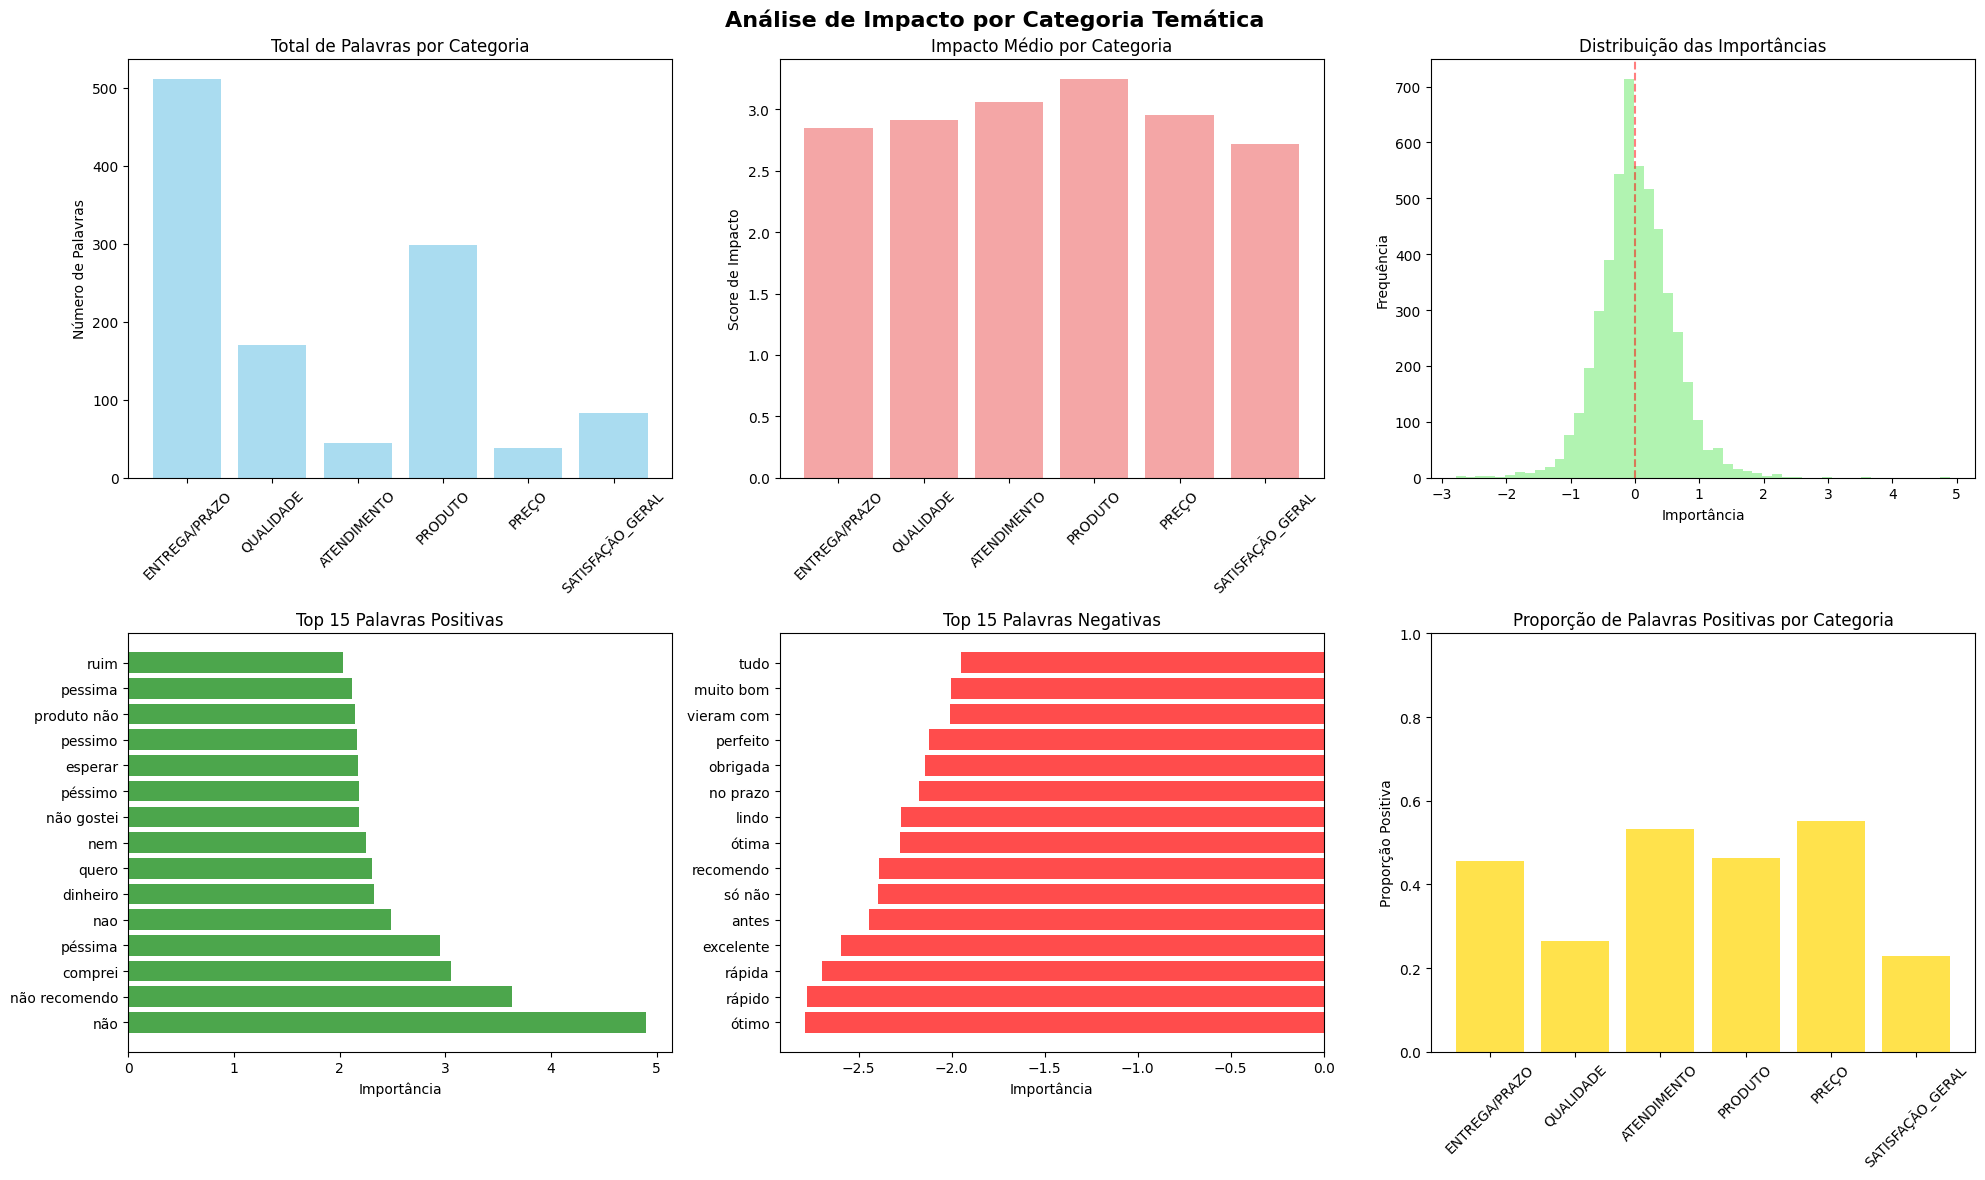

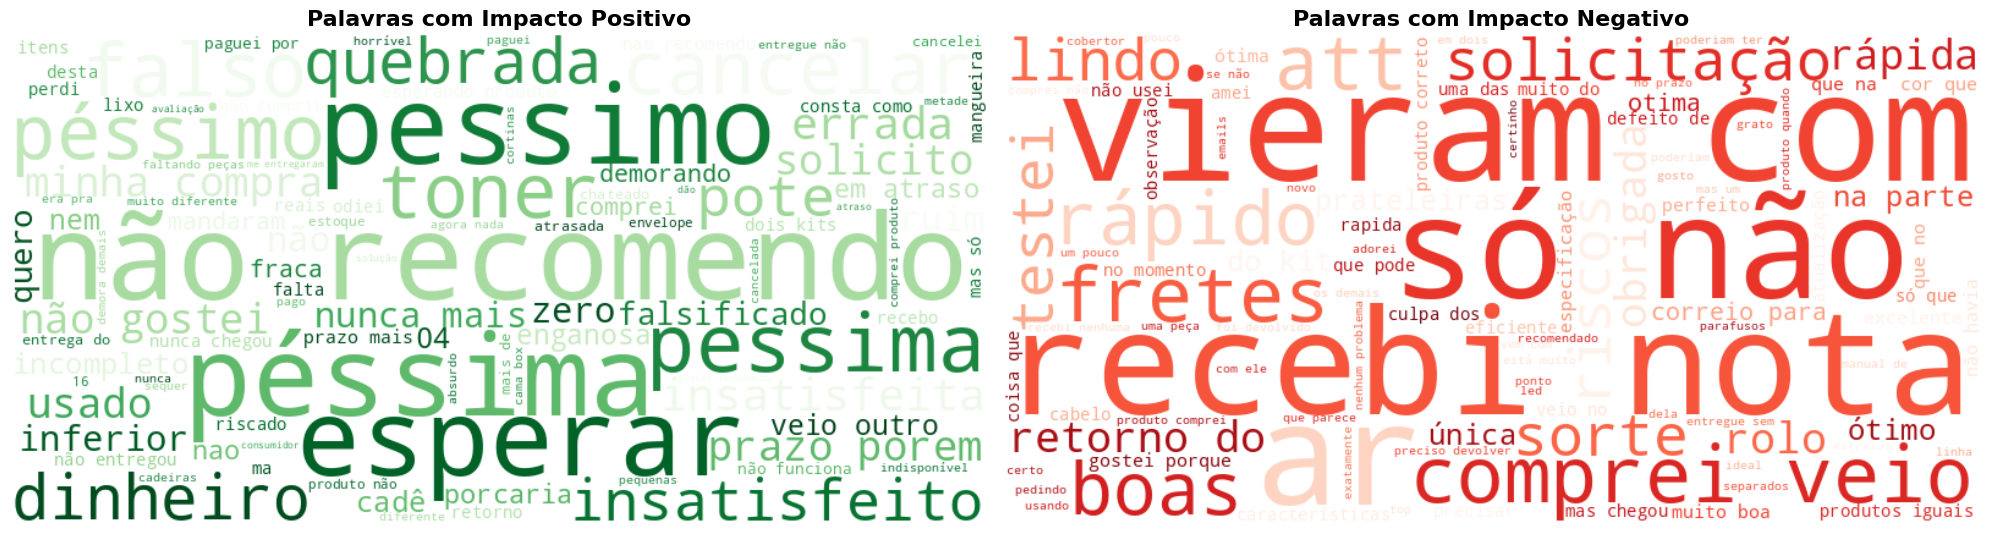

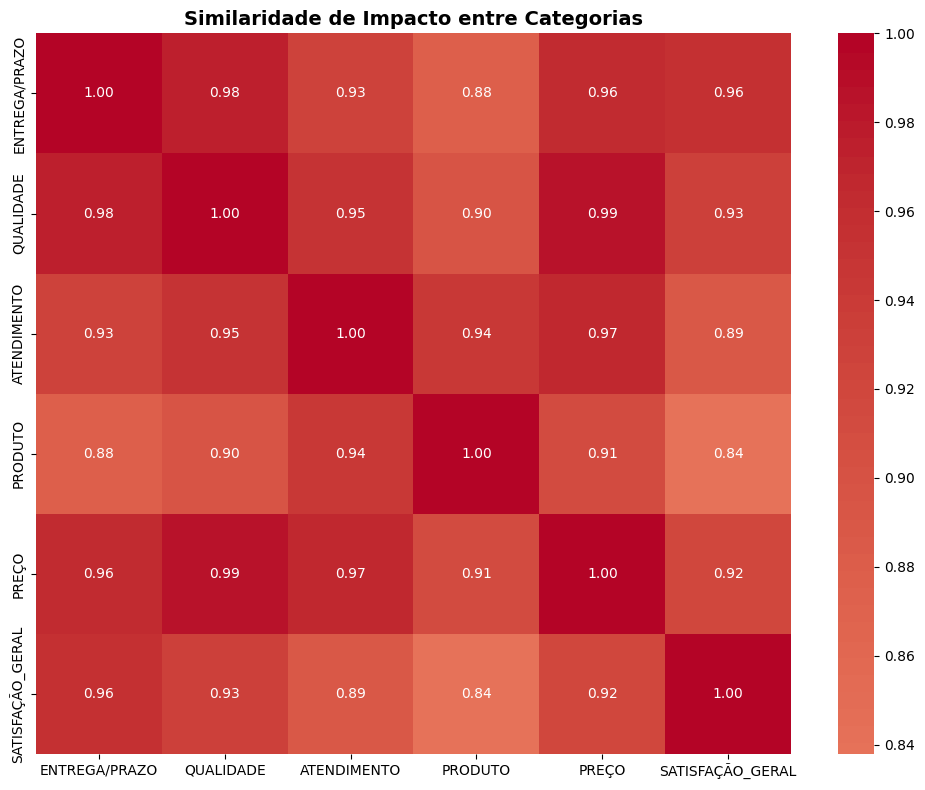


📋 RESUMO EXECUTIVO
📊 Distribuição geral:
   • Palavras positivas: 2496 (49.9%)
   • Palavras negativas: 2504 (50.1%)
   • Palavras neutras: 0 (0.0%)

🎯 Insights principais:
   • Categoria com maior impacto: PRODUTO (score: 3.244)
   • Categoria com menor impacto: SATISFAÇÃO_GERAL (score: 2.718)
   • Palavra mais positiva: 'não' (+4.903)
   • Palavra mais negativa: 'ótimo' (-2.786)


In [ ]:
# @title Análise de Razões Contextuais para Avaliações de Clientes
def get_contextual_reasons(model, vectorizer, top_n=10):
    """
    Analisa as razões contextuais por trás das avaliações, agrupando por categorias temáticas
    e fornecendo insights detalhados sobre palavras-chave positivas e negativas.
    """

    feature_names = vectorizer.get_feature_names_out()
    coefs = model.coef_[0]

    word_importance = pd.DataFrame({"word": feature_names, "importance": coefs})

    # Calcular estatísticas de frequência
    word_counts = np.array(vectorizer.idf_)
    word_importance['idf'] = word_counts
    word_importance['score'] = word_importance['importance'] * word_importance['idf']
    word_importance['abs_importance'] = abs(word_importance['importance'])
    word_importance['impact_score'] = word_importance['abs_importance'] * word_importance['idf']

    # Categorias temáticas expandidas
    categories = {
        'ENTREGA/PRAZO': ['entreg', 'prazo', 'rápido', 'demora', 'chegou', 'recebi', 'tempo',
                         'frete', 'envio', 'transport', 'entrega', 'rapidez'],
        'QUALIDADE': ['qualidade', 'excelente', 'ruim', 'péssimo', 'ótimo', 'bom', 'mal',
                     'superou', 'lixo', 'fantástico', 'horrível', 'maravilhoso'],
        'ATENDIMENTO': ['atendimento', 'cliente', 'suporte', 'resposta', 'ajudou', 'educado',
                       'gentil', 'grosseria', 'prestativo', 'sac', 'reclamação'],
        'PRODUTO': ['produto', 'funciona', 'defeito', 'perfeito', 'quebrou', 'uso', 'utilizar',
                   'durável', 'frágil', 'material', 'montagem', 'instalação'],
        'PREÇO': ['preço', 'caro', 'barato', 'valor', 'custou', 'reais', 'dinheiro',
                 'investimento', 'custobenefício', 'gasto'],
        'SATISFAÇÃO_GERAL': ['recomendo', 'compraria', 'indicar', 'satisfeito', 'insatisfeito',
                           'arrependimento', 'feliz', 'decepcionado']
    }

    print("=== ANÁLISE DETALHADA DE RAZÕES CONTEXTUAIS ===")
    print(f"Total de palavras analisadas: {len(word_importance)}")
    print(f"Palavras com impacto positivo: {len(word_importance[word_importance['importance'] > 0])}")
    print(f"Palavras com impacto negativo: {len(word_importance[word_importance['importance'] < 0])}")

    # Análise por categoria
    category_analysis = {}

    for category, keywords in categories.items():
        mask = word_importance['word'].str.contains('|'.join(keywords), case=False, na=False)
        category_words = word_importance[mask].copy()

        category_analysis[category] = {
            'total_words': len(category_words),
            'positive_words': len(category_words[category_words['importance'] > 0]),
            'negative_words': len(category_words[category_words['importance'] < 0]),
            'avg_impact': category_words['impact_score'].mean() if len(category_words) > 0 else 0,
            'words': category_words
        }

        if len(category_words) > 0:
            positive = category_words[category_words['importance'] > 0].nlargest(5, 'impact_score')
            negative = category_words[category_words['importance'] < 0].nsmallest(5, 'impact_score')

            print(f"\n📊 {category} (Total: {len(category_words)} palavras):")
            print(f"   📈 Impacto médio: {category_analysis[category]['avg_impact']:.4f}")

            if len(positive) > 0:
                positive_list = [f"{word} (+{imp:.3f})" for word, imp in zip(positive['word'], positive['importance'])]
                print(f"  👍 Positivas: {', '.join(positive_list)}")

            if len(negative) > 0:
                negative_list = [f"{word} ({imp:.3f})" for word, imp in zip(negative['word'], negative['importance'])]
                print(f"  👎 Negativas: {', '.join(negative_list)}")

    # Gerar visualizações
    generate_visualizations(word_importance, category_analysis)

    return word_importance, category_analysis

def generate_visualizations(word_importance, category_analysis):
    """Gera visualizações completas da análise"""

    # 1. Gráfico de impacto por categoria
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('Análise de Impacto por Categoria Temática', fontsize=16, fontweight='bold')

    # Dados para o primeiro gráfico
    categories = list(category_analysis.keys())
    total_words = [cat['total_words'] for cat in category_analysis.values()]
    avg_impact = [cat['avg_impact'] for cat in category_analysis.values()]

    # Gráfico 1: Total de palavras por categoria
    axes[0,0].bar(categories, total_words, color='skyblue', alpha=0.7)
    axes[0,0].set_title('Total de Palavras por Categoria')
    axes[0,0].set_ylabel('Número de Palavras')
    axes[0,0].tick_params(axis='x', rotation=45)

    # Gráfico 2: Impacto médio por categoria
    axes[0,1].bar(categories, avg_impact, color='lightcoral', alpha=0.7)
    axes[0,1].set_title('Impacto Médio por Categoria')
    axes[0,1].set_ylabel('Score de Impacto')
    axes[0,1].tick_params(axis='x', rotation=45)

    # Gráfico 3: Distribuição de importância
    axes[0,2].hist(word_importance['importance'], bins=50, alpha=0.7, color='lightgreen')
    axes[0,2].set_title('Distribuição das Importâncias')
    axes[0,2].set_xlabel('Importância')
    axes[0,2].set_ylabel('Frequência')
    axes[0,2].axvline(x=0, color='red', linestyle='--', alpha=0.5)

    # Gráfico 4: Top palavras positivas
    top_positive = word_importance.nlargest(15, 'importance')
    axes[1,0].barh(top_positive['word'], top_positive['importance'], color='green', alpha=0.7)
    axes[1,0].set_title('Top 15 Palavras Positivas')
    axes[1,0].set_xlabel('Importância')

    # Gráfico 5: Top palavras negativas
    top_negative = word_importance.nsmallest(15, 'importance')
    axes[1,1].barh(top_negative['word'], top_negative['importance'], color='red', alpha=0.7)
    axes[1,1].set_title('Top 15 Palavras Negativas')
    axes[1,1].set_xlabel('Importância')

    # Gráfico 6: Proporção positiva/negativa por categoria
    positive_ratios = []
    for cat in category_analysis.values():
        if cat['total_words'] > 0:
            ratio = cat['positive_words'] / cat['total_words']
        else:
            ratio = 0
        positive_ratios.append(ratio)

    axes[1,2].bar(categories, positive_ratios, color='gold', alpha=0.7)
    axes[1,2].set_title('Proporção de Palavras Positivas por Categoria')
    axes[1,2].set_ylabel('Proporção Positiva')
    axes[1,2].tick_params(axis='x', rotation=45)
    axes[1,2].set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

    # 2. Word Cloud das palavras mais importantes
    generate_word_clouds(word_importance)

    # 3. Heatmap de correlação entre categorias
    generate_category_heatmap(category_analysis)

def generate_word_clouds(word_importance):
    """Gera word clouds para palavras positivas e negativas"""

    # Word Cloud para palavras positivas
    positive_words = word_importance[word_importance['importance'] > 0].nlargest(100, 'impact_score')
    negative_words = word_importance[word_importance['importance'] < 0].nlargest(100, 'impact_score')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

    if len(positive_words) > 0:
        positive_dict = dict(zip(positive_words['word'], positive_words['impact_score']))
        wordcloud_positive = WordCloud(width=800, height=400, background_color='white',
                                     colormap='Greens').generate_from_frequencies(positive_dict)
        ax1.imshow(wordcloud_positive, interpolation='bilinear')
        ax1.set_title('Palavras com Impacto Positivo', fontsize=16, fontweight='bold')
        ax1.axis('off')

    if len(negative_words) > 0:
        negative_dict = dict(zip(negative_words['word'], abs(negative_words['impact_score'])))
        wordcloud_negative = WordCloud(width=800, height=400, background_color='white',
                                     colormap='Reds').generate_from_frequencies(negative_dict)
        ax2.imshow(wordcloud_negative, interpolation='bilinear')
        ax2.set_title('Palavras com Impacto Negativo', fontsize=16, fontweight='bold')
        ax2.axis('off')

    plt.tight_layout()
    plt.show()

def generate_category_heatmap(category_analysis):
    """Gera heatmap mostrando as relações entre categorias"""

    # Matriz de similaridade (exemplo simplificado)
    categories = list(category_analysis.keys())
    n_categories = len(categories)

    # Criar matriz de similaridade baseada no impacto médio
    similarity_matrix = np.zeros((n_categories, n_categories))

    for i in range(n_categories):
        for j in range(n_categories):
            if i == j:
                similarity_matrix[i,j] = 1.0
            else:
                # Similaridade baseada na diferença de impacto
                impact_i = category_analysis[categories[i]]['avg_impact']
                impact_j = category_analysis[categories[j]]['avg_impact']
                similarity = 1.0 - (abs(impact_i - impact_j) / max(abs(impact_i), abs(impact_j), 1))
                similarity_matrix[i,j] = similarity

    plt.figure(figsize=(10, 8))
    sns.heatmap(similarity_matrix,
                xticklabels=categories,
                yticklabels=categories,
                annot=True,
                cmap='coolwarm',
                center=0.5,
                fmt='.2f')
    plt.title('Similaridade de Impacto entre Categorias', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Usar a função melhorada
contextual_reasons, category_analysis = get_contextual_reasons(model, tfidf_vectorizer)

# Análise adicional: Resumo executivo
print("\n" + "="*60)
print("📋 RESUMO EXECUTIVO")
print("="*60)

total_positive = len(contextual_reasons[contextual_reasons['importance'] > 0])
total_negative = len(contextual_reasons[contextual_reasons['importance'] < 0])
total_neutral = len(contextual_reasons[contextual_reasons['importance'] == 0])

print(f"📊 Distribuição geral:")
print(f"   • Palavras positivas: {total_positive} ({total_positive/len(contextual_reasons)*100:.1f}%)")
print(f"   • Palavras negativas: {total_negative} ({total_negative/len(contextual_reasons)*100:.1f}%)")
print(f"   • Palavras neutras: {total_neutral} ({total_neutral/len(contextual_reasons)*100:.1f}%)")

# Categoria com maior impacto
max_impact_cat = max(category_analysis.items(), key=lambda x: x[1]['avg_impact'])
min_impact_cat = min(category_analysis.items(), key=lambda x: x[1]['avg_impact'])

print(f"\n🎯 Insights principais:")
print(f"   • Categoria com maior impacto: {max_impact_cat[0]} (score: {max_impact_cat[1]['avg_impact']:.3f})")
print(f"   • Categoria com menor impacto: {min_impact_cat[0]} (score: {min_impact_cat[1]['avg_impact']:.3f})")

# Palavra mais positiva e mais negativa
most_positive = contextual_reasons.nlargest(1, 'importance').iloc[0]
most_negative = contextual_reasons.nsmallest(1, 'importance').iloc[0]

print(f"   • Palavra mais positiva: '{most_positive['word']}' (+{most_positive['importance']:.3f})")
print(f"   • Palavra mais negativa: '{most_negative['word']}' ({most_negative['importance']:.3f})")

🔧 PREPARANDO DADOS E TREINANDO MODELO...
📊 Distribuição dos Sentimentos:
   Positivo: 26530 (64.7%)
   Negativo: 10890 (26.6%)
   Neutro: 3557 (8.7%)

📈 Vetorizando dados de treino...
🤖 Treinando modelo de regressão logística...

✅ Modelo treinado com sucesso!
   Acurácia Treino: 0.864
   Acurácia Teste:  0.829
🚀 INICIANDO ANÁLISES COMPLETAS...

1. 📊 Análise Contextual...

🔍 ANÁLISE DE RAZÕES CONTEXTUAIS MULTI-CLASSE

📊 ==================================================
   ANÁLISE DA CLASSE: NEGATIVO
  🚚 ENTREGA/PRAZO: rápido(-4.89), antes prazo(-3.11)
  ⭐ QUALIDADE: excelente(-5.37), ótimo(-5.08)
  💬 ATENDIMENTO: resposta(+3.23), atendimento(-1.23)
  📦 PRODUTO: perfeito(-4.09), produto(+2.43)
  💰 PREÇO: dinheiro(+3.28), reais(+1.45)

  🎯 PALAVRAS MAIS CARACTERÍSTICAS:
     ✅ Indicativas: péssima(+4.16), comprei(+3.63), péssimo(+3.54)
     ❌ Contra-indicativas: excelente(-5.37), antes(-5.23), ótimo(-5.08)

📊 ==================================================
   ANÁLISE DA CLASSE: NEUTR

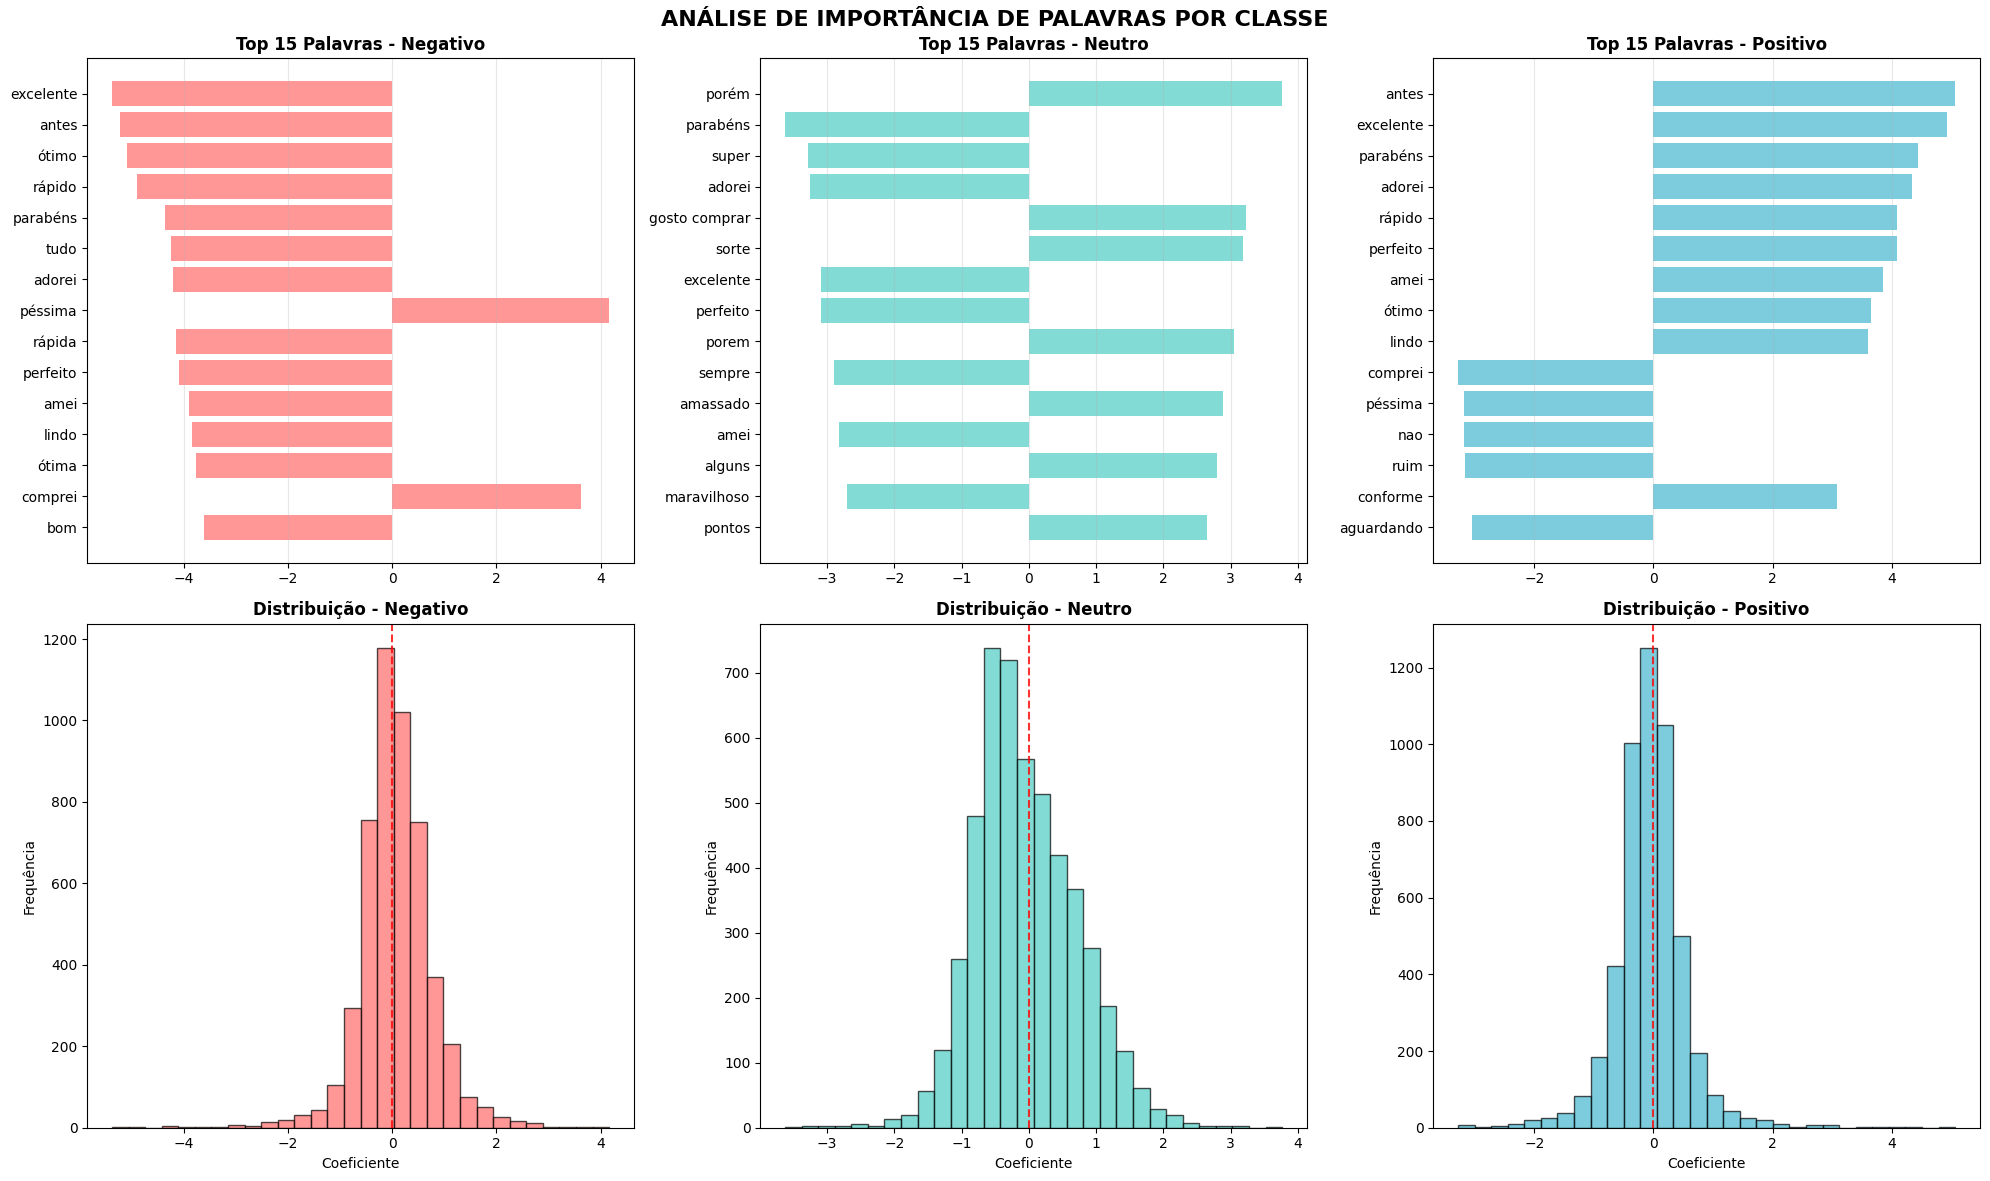


3. ☁️ Gerando Word Clouds...

☁️ WORD CLOUDS POR CLASSE


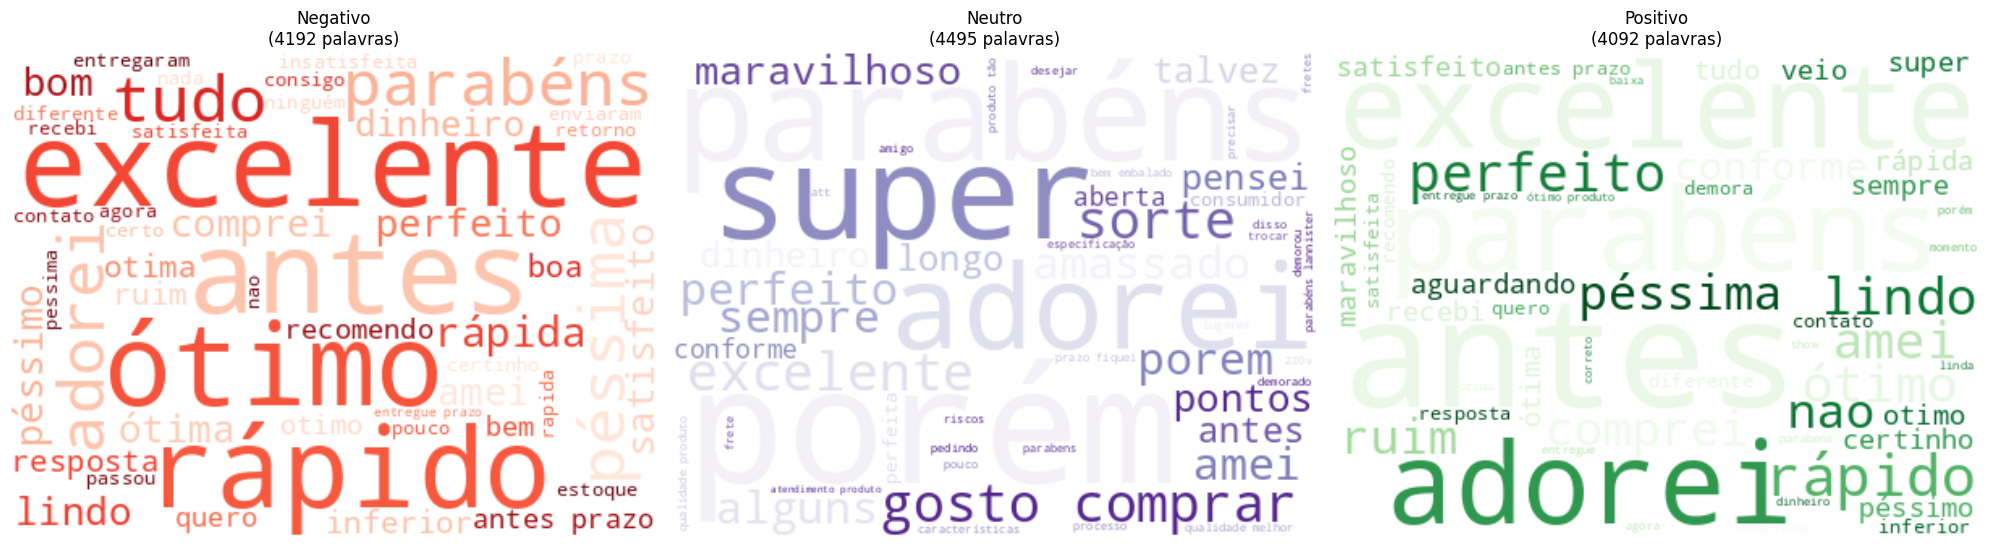


4. 🔤 Análise de N-Grams...

🔤 ANÁLISE DE N-GRAMS

📖 UNIGRAMS:
  Negativo: excelente(-5.37), antes(-5.23), ótimo(-5.08)
  Neutro: porém(+3.77), parabéns(-3.62), super(-3.28)
  Positivo: antes(+5.06), excelente(+4.92), parabéns(+4.45)

📖 BIGRAMS:
  Negativo: antes prazo(-3.11), entregue prazo(-2.49), entrega rápida(-2.47)
  Neutro: gosto comprar(+3.24), qualidade melhor(+2.40), prazo fiquei(+2.31)
  Positivo: antes prazo(+2.67), ótimo produto(+2.38), ainda recebi(-2.33)

📖 TRIGRAMS:

5. 🔄 Análise de Correlação...

🔄 ANÁLISE DE CORRELAÇÃO ENTRE CLASSES


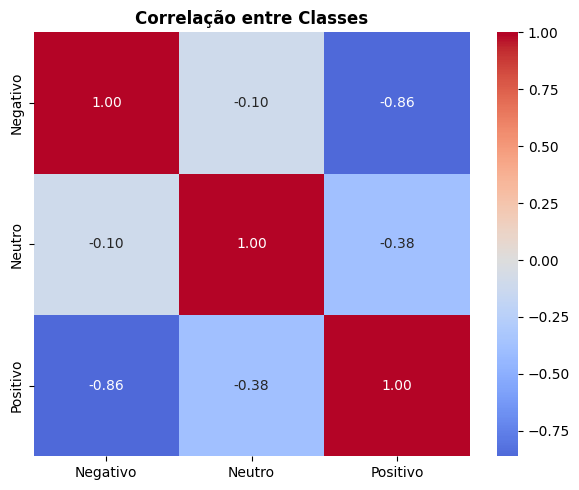


✅ TODAS AS ANÁLISES CONCLUÍDAS COM SUCESSO!

📋 RELATÓRIO FINAL

📈 DESEMPENHO DO MODELO:
   • Acurácia (Treino): 0.864
   • Acurácia (Teste):  0.829
   • Features: 5000

💡 PRÓXIMOS PASSOS:
   • Analisar as palavras mais importantes por classe
   • Verificar a qualidade das previsões
   • Considerar balanceamento de dados se necessário


In [ ]:
# @title Análise de Sentimentos com Explicabilidade Multi-Classe - VERSÃO CORRIGIDA
# 1. PREPARAÇÃO DOS DADOS E TREINAMENTO DO MODELO
print("🔧 PREPARANDO DADOS E TREINANDO MODELO...")
print("=" * 60)

warnings.filterwarnings('ignore')

# CORREÇÃO: Definir class_names como dicionário
class_names = {0: 'Negativo', 1: 'Neutro', 2: 'Positivo'}

# Preparar os dados
reviews_df_clean = reviews_df.dropna(subset=['review_comment_message', 'sentiment'])

# Análise exploratória da distribuição de sentimentos
sentiment_dist = reviews_df_clean['sentiment'].value_counts()
print("📊 Distribuição dos Sentimentos:")
for sentiment, count in sentiment_dist.items():
    percentage = (count / len(reviews_df_clean)) * 100
    sentiment_name = class_names.get(sentiment, f'Classe {sentiment}')
    print(f"   {sentiment_name}: {count} ({percentage:.1f}%)")

# Separar features (X) e target (y)
X = reviews_df_clean['review_comment_message']
y = reviews_df_clean['sentiment']

# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Lista de stop words em português expandida
stop_words_portugues = [
    'de', 'a', 'o', 'que', 'e', 'do', 'da', 'em', 'um', 'para', 'é', 'com', 'não', 'uma', 'os', 'no', 'se', 'na', 'por', 'mais',
    'as', 'dos', 'como', 'mas', 'foi', 'ao', 'ele', 'das', 'tem', 'à', 'seu', 'sua', 'ou', 'ser', 'quando', 'muito', 'há', 'nos',
    'já', 'está', 'eu', 'também', 'só', 'pelo', 'pela', 'até', 'isso', 'ela', 'entre', 'era', 'depois', 'sem', 'mesmo', 'aos',
    'ter', 'seus', 'quem', 'nas', 'me', 'esse', 'eles', 'estão', 'você', 'tinha', 'foram', 'essa', 'num', 'nem', 'suas', 'meu',
    'às', 'minha', 'têm', 'numa', 'pelos', 'elas', 'havia', 'seja', 'qual', 'será', 'nós', 'tenho', 'lhe', 'deles', 'essas',
    'esses', 'pelas', 'este', 'fosse', 'dele', 'tu', 'te', 'vocês', 'vos', 'lhes', 'meus', 'minhas', 'teu', 'tua', 'teus',
    'tuas', 'nosso', 'nossa', 'nossos', 'nossas', 'dela', 'delas', 'esta', 'estes', 'estas', 'aquele', 'aquela', 'aqueles',
    'aquelas', 'isto', 'aquilo', 'estou', 'está', 'estamos', 'estão', 'estive', 'esteve', 'estivemos', 'estiveram', 'estiva',
    'estávamos', 'estavam', 'estivera', 'estivéramos', 'esteja', 'estejamos', 'estejam', 'estivesse', 'estivéssemos', 'estivessem',
    'oi', 'ola', 'obrigado', 'obrigada', 'ok', 'ate', 'diz', 'sobre', 'mim', 'ja', 'etc', 'ta', 'to', 'la', 'lo', 'pro', 'pra'
]

# 2. CRIAR E TREINAR O MODELO
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,  # Reduzido para evitar problemas de memória
    stop_words=stop_words_portugues,
    ngram_range=(1, 2),  # Apenas uni e bigramas para simplificar
    min_df=2,
    max_df=0.9,
    analyzer='word'
)

model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced',
    C=1.0,
    solver='liblinear'
)

print("\n📈 Vetorizando dados de treino...")
X_train_vec = tfidf_vectorizer.fit_transform(X_train)
X_test_vec = tfidf_vectorizer.transform(X_test)

print("🤖 Treinando modelo de regressão logística...")
model.fit(X_train_vec, y_train)

# Avaliar o modelo
train_score = model.score(X_train_vec, y_train)
test_score = model.score(X_test_vec, y_test)
print(f"\n✅ Modelo treinado com sucesso!")
print(f"   Acurácia Treino: {train_score:.3f}")
print(f"   Acurácia Teste:  {test_score:.3f}")

# 3. FUNÇÃO PRINCIPAL DE ANÁLISE CONTEXTUAL MULTI-CLASSE (CORRIGIDA)
def get_contextual_reasons_multi_class(model, vectorizer, class_names=None, top_n=10):
    """
    Análise detalhada das razões contextuais para classificação multi-classe
    """
    if class_names is None:
        class_names = {0: 'Negativo', 1: 'Neutro', 2: 'Positivo'}

    feature_names = vectorizer.get_feature_names_out()

    print("\n" + "="*80)
    print("🔍 ANÁLISE DE RAZÕES CONTEXTUAIS MULTI-CLASSE")
    print("="*80)

    # Categorias temáticas
    categories = {
        '🚚 ENTREGA/PRAZO': ['entreg', 'prazo', 'rápido', 'rapida', 'demora', 'chegou', 'recebi', 'tempo', 'frete'],
        '⭐ QUALIDADE': ['qualidade', 'excelente', 'ruim', 'péssimo', 'pessimo', 'ótimo', 'otimo', 'bom', 'mal'],
        '💬 ATENDIMENTO': ['atendimento', 'cliente', 'suporte', 'resposta', 'ajudou', 'educado', 'prestativo'],
        '📦 PRODUTO': ['produto', 'funciona', 'defeito', 'perfeito', 'quebrou', 'uso', 'utilizar', 'material'],
        '💰 PREÇO': ['preço', 'preco', 'caro', 'barato', 'valor', 'custou', 'reais', 'dinheiro']
    }

    analysis_results = {}

    for class_idx, class_name in class_names.items():
        print(f"\n📊 {'='*50}")
        print(f"   ANÁLISE DA CLASSE: {class_name.upper()}")
        print(f"{'='*50}")

        coefs = model.coef_[class_idx]

        # CORREÇÃO: Criar DataFrame de forma segura
        word_importance = pd.DataFrame({
            "word": feature_names,
            "importance": coefs
        })

        # CORREÇÃO: Calcular importância absoluta de forma segura
        word_importance['abs_importance'] = np.abs(word_importance['importance'])

        # Ordenar por importância absoluta
        word_importance = word_importance.sort_values('abs_importance', ascending=False)

        analysis_results[class_name] = {
            'word_importance': word_importance,
            'category_analysis': {}
        }

        # Análise por categoria temática
        for category, keywords in categories.items():
            # CORREÇÃO: Filtrar palavras da categoria de forma segura
            try:
                mask = word_importance['word'].str.contains('|'.join(keywords), case=False, na=False)
                category_words = word_importance[mask].copy()

                if len(category_words) > 0:
                    # Palavras mais importantes da categoria
                    top_words = category_words.nlargest(2, 'abs_importance')

                    if len(top_words) > 0:
                        words_display = []
                        for _, row in top_words.iterrows():
                            sign = '+' if row['importance'] > 0 else ''
                            words_display.append(f"{row['word']}({sign}{row['importance']:.2f})")

                        print(f"  {category}: {', '.join(words_display)}")

            except Exception as e:
                print(f"  ⚠️  {category}: Erro na análise - {str(e)}")

        # Top palavras gerais da classe
        top_positive = word_importance[word_importance['importance'] > 0].head(3)
        top_negative = word_importance[word_importance['importance'] < 0].head(3)

        print(f"\n  🎯 PALAVRAS MAIS CARACTERÍSTICAS:")
        if len(top_positive) > 0:
            pos_words = [f"{row['word']}(+{row['importance']:.2f})" for _, row in top_positive.iterrows()]
            print(f"     ✅ Indicativas: {', '.join(pos_words)}")
        if len(top_negative) > 0:
            neg_words = [f"{row['word']}({row['importance']:.2f})" for _, row in top_negative.iterrows()]
            print(f"     ❌ Contra-indicativas: {', '.join(neg_words)}")

    return analysis_results

# 4. ANÁLISE DE IMPORTÂNCIA GLOBAL COM VISUALIZAÇÕES (CORRIGIDA)
def comprehensive_importance_analysis(model, vectorizer, class_names, top_n=15):
    """
    Análise abrangente da importância das palavras com múltiplas visualizações
    """
    feature_names = vectorizer.get_feature_names_out()

    print("\n" + "="*80)
    print("📈 ANÁLISE COMPREENSIVA DE IMPORTÂNCIA")
    print("="*80)

    # Configurações de plot
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('ANÁLISE DE IMPORTÂNCIA DE PALAVRAS POR CLASSE', fontsize=16, fontweight='bold')

    # Cores para cada classe
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

    # CORREÇÃO: Verificar o tipo de class_names
    if isinstance(class_names, list):
        class_names_dict = {i: name for i, name in enumerate(class_names)}
    else:
        class_names_dict = class_names

    for idx, (class_idx, class_name) in enumerate(class_names_dict.items()):
        coefs = model.coef_[class_idx]

        # CORREÇÃO: Criar DataFrame de forma segura
        importance_df = pd.DataFrame({
            'word': feature_names,
            'coefficient': coefs
        })

        # CORREÇÃO: Calcular valor absoluto de forma segura
        importance_df['abs_coef'] = np.abs(importance_df['coefficient'])
        importance_df = importance_df.sort_values('abs_coef', ascending=False)

        # Gráfico 1: Top palavras por classe
        top_words = importance_df.head(top_n)

        # CORREÇÃO: Verificar se há dados para plotar
        if len(top_words) > 0:
            axes[0, idx].barh(top_words['word'], top_words['coefficient'], color=colors[idx], alpha=0.7)
            axes[0, idx].set_title(f'Top {top_n} Palavras - {class_name}', fontweight='bold')
            axes[0, idx].invert_yaxis()
            axes[0, idx].grid(axis='x', alpha=0.3)

        # Gráfico 2: Distribuição dos coeficientes
        axes[1, idx].hist(coefs, bins=30, color=colors[idx], alpha=0.7, edgecolor='black')
        axes[1, idx].set_title(f'Distribuição - {class_name}', fontweight='bold')
        axes[1, idx].axvline(x=0, color='red', linestyle='--', alpha=0.8)
        axes[1, idx].set_xlabel('Coeficiente')
        axes[1, idx].set_ylabel('Frequência')

        # Estatísticas por classe
        positive_words = importance_df[importance_df['coefficient'] > 0]
        negative_words = importance_df[importance_df['coefficient'] < 0]

        print(f"\n📊 {class_name.upper()}:")
        print(f"   • Total de palavras: {len(importance_df)}")
        print(f"   • Palavras positivas: {len(positive_words)} ({len(positive_words)/len(importance_df)*100:.1f}%)")
        print(f"   • Palavras negativas: {len(negative_words)} ({len(negative_words)/len(importance_df)*100:.1f}%)")

        # Top 3 palavras
        top_3 = importance_df.head(3)
        if len(top_3) > 0:
            top_words_list = [f"{row['word']}({row['coefficient']:.2f})" for _, row in top_3.iterrows()]
            print(f"   🎯 Top 3: {', '.join(top_words_list)}")

    plt.tight_layout()
    plt.show()

    return fig

# 5. WORD CLOUDS SIMPLIFICADOS (CORRIGIDOS)
def generate_simple_wordclouds(model, vectorizer, class_names, max_words=50):
    """
    Versão simplificada e robusta dos word clouds
    """
    feature_names = vectorizer.get_feature_names_out()

    print("\n" + "="*80)
    print("☁️ WORD CLOUDS POR CLASSE")
    print("="*80)

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # CORREÇÃO: Verificar o tipo de class_names
    if isinstance(class_names, list):
        class_names_dict = {i: name for i, name in enumerate(class_names)}
    else:
        class_names_dict = class_names

    # Colormaps válidos
    colormaps = ['Reds', 'Purples', 'Greens']

    for idx, (class_idx, class_name) in enumerate(class_names_dict.items()):
        try:
            coefs = model.coef_[class_idx]

            # CORREÇÃO: Criar dicionário de forma segura
            word_scores = {}
            for i, (word, score) in enumerate(zip(feature_names, coefs)):
                if abs(score) > 0.1 and len(word) > 2:  # Filtro por relevância e tamanho
                    word_scores[word] = float(abs(score))  # CORREÇÃO: Garantir que é float

            if len(word_scores) >= 3:  # Mínimo de palavras
                wordcloud = WordCloud(
                    width=400,
                    height=300,
                    background_color='white',
                    colormap=colormaps[idx],
                    max_words=max_words,
                    relative_scaling=0.3,
                    random_state=42
                ).generate_from_frequencies(word_scores)

                axes[idx].imshow(wordcloud, interpolation='bilinear')
                axes[idx].set_title(f'{class_name}\n({len(word_scores)} palavras)', fontsize=12)
                axes[idx].axis('off')

            else:
                axes[idx].text(0.5, 0.5, f'Poucas palavras\nsignificativas\n({len(word_scores)} encontradas)',
                              ha='center', va='center', transform=axes[idx].transAxes, fontsize=10)
                axes[idx].set_title(f'{class_name}', fontsize=12)
                axes[idx].axis('off')

        except Exception as e:
            axes[idx].text(0.5, 0.5, f'Erro ao gerar\n{str(e)[:30]}...',
                          ha='center', va='center', transform=axes[idx].transAxes, fontsize=9, color='red')
            axes[idx].set_title(f'{class_name}', fontsize=12)
            axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

# 6. ANÁLISE DE N-GRAMS (CORRIGIDA)
def advanced_ngram_analysis(model, vectorizer, class_names, top_n=10):
    """
    Análise detalhada de uni-grams, bi-grams e tri-grams
    """
    feature_names = vectorizer.get_feature_names_out()

    print("\n" + "="*60)
    print("🔤 ANÁLISE DE N-GRAMS")
    print("="*60)

    # CORREÇÃO: Verificar o tipo de class_names
    if isinstance(class_names, list):
        class_names_dict = {i: name for i, name in enumerate(class_names)}
    else:
        class_names_dict = class_names

    # Análise por tipo de n-gram
    ngram_types = [
        ('Unigrams', lambda x: ' ' not in x and len(x) > 2),
        ('Bigrams', lambda x: x.count(' ') == 1),
        ('Trigrams', lambda x: x.count(' ') == 2)
    ]

    for ngram_name, filter_func in ngram_types:
        print(f"\n📖 {ngram_name.upper()}:")

        for class_idx, class_name in class_names_dict.items():
            coefs = model.coef_[class_idx]

            # CORREÇÃO: Criar DataFrame de forma segura
            ngram_df = pd.DataFrame({
                'ngram': feature_names,
                'coefficient': coefs,
                'abs_coef': np.abs(coefs)
            })

            # Aplicar filtro
            filtered_ngrams = ngram_df[ngram_df['ngram'].apply(filter_func)]

            if len(filtered_ngrams) > 0:
                top_ngrams = filtered_ngrams.nlargest(top_n, 'abs_coef')

                if len(top_ngrams) > 0:
                    # Mostrar apenas os top 3
                    top_3 = top_ngrams.head(3)
                    ngram_list = []
                    for _, row in top_3.iterrows():
                        sign = '+' if row['coefficient'] > 0 else ''
                        ngram_list.append(f"{row['ngram']}({sign}{row['coefficient']:.2f})")

                    print(f"  {class_name}: {', '.join(ngram_list)}")

# 7. ANÁLISE DE CORRELAÇÃO (CORRIGIDA)
def class_correlation_analysis(model, vectorizer, class_names):
    """
    Analisa correlações entre as classes baseado nos coeficientes
    """
    print("\n" + "="*60)
    print("🔄 ANÁLISE DE CORRELAÇÃO ENTRE CLASSES")
    print("="*60)

    feature_names = vectorizer.get_feature_names_out()

    # CORREÇÃO: Verificar o tipo de class_names
    if isinstance(class_names, list):
        class_names_dict = {i: name for i, name in enumerate(class_names)}
        class_labels = class_names
    else:
        class_names_dict = class_names
        class_labels = list(class_names.values())

    n_classes = len(class_names_dict)

    # Criar matriz de coeficientes
    coef_matrix = np.zeros((len(feature_names), n_classes))
    for idx in range(n_classes):
        coef_matrix[:, idx] = model.coef_[idx]

    # Calcular correlação
    correlation_matrix = np.corrcoef(coef_matrix.T)

    # Plotar heatmap
    plt.figure(figsize=(6, 5))
    sns.heatmap(correlation_matrix,
                annot=True,
                cmap='coolwarm',
                center=0,
                xticklabels=class_labels,
                yticklabels=class_labels,
                fmt='.2f')
    plt.title('Correlação entre Classes', fontweight='bold')
    plt.tight_layout()
    plt.show()

# 8. EXECUTAR ANÁLISES (VERSÃO SEGURA)
print("🚀 INICIANDO ANÁLISES COMPLETAS...")

# CORREÇÃO: Usar dicionário consistentemente
class_names_dict = {0: 'Negativo', 1: 'Neutro', 2: 'Positivo'}

try:
    # Executar análise contextual
    print("\n1. 📊 Análise Contextual...")
    contextual_analysis = get_contextual_reasons_multi_class(model, tfidf_vectorizer, class_names_dict)

    # Executar análise de importância
    print("\n2. 📈 Análise de Importância...")
    importance_fig = comprehensive_importance_analysis(model, tfidf_vectorizer, class_names_dict)

    # Gerar word clouds
    print("\n3. ☁️ Gerando Word Clouds...")
    generate_simple_wordclouds(model, tfidf_vectorizer, class_names_dict)

    # Análise de n-grams
    print("\n4. 🔤 Análise de N-Grams...")
    advanced_ngram_analysis(model, tfidf_vectorizer, class_names_dict)

    # Análise de correlação
    print("\n5. 🔄 Análise de Correlação...")
    class_correlation_analysis(model, tfidf_vectorizer, class_names_dict)

    print("\n✅ TODAS AS ANÁLISES CONCLUÍDAS COM SUCESSO!")

except Exception as e:
    print(f"\n❌ Erro durante as análises: {str(e)}")
    print("💡 Dica: Verifique se o modelo foi treinado corretamente e se há dados suficientes.")

# 9. RELATÓRIO FINAL SIMPLIFICADO
print("\n" + "="*60)
print("📋 RELATÓRIO FINAL")
print("="*60)

print(f"\n📈 DESEMPENHO DO MODELO:")
print(f"   • Acurácia (Treino): {train_score:.3f}")
print(f"   • Acurácia (Teste):  {test_score:.3f}")
print(f"   • Features: {len(tfidf_vectorizer.get_feature_names_out())}")

print(f"\n💡 PRÓXIMOS PASSOS:")
print(f"   • Analisar as palavras mais importantes por classe")
print(f"   • Verificar a qualidade das previsões")
print(f"   • Considerar balanceamento de dados se necessário")

🚀 INICIANDO ANÁLISE COMPARATIVA COMPLETA...
🔍 INICIANDO ANÁLISE COMPARATIVA AVANÇADA


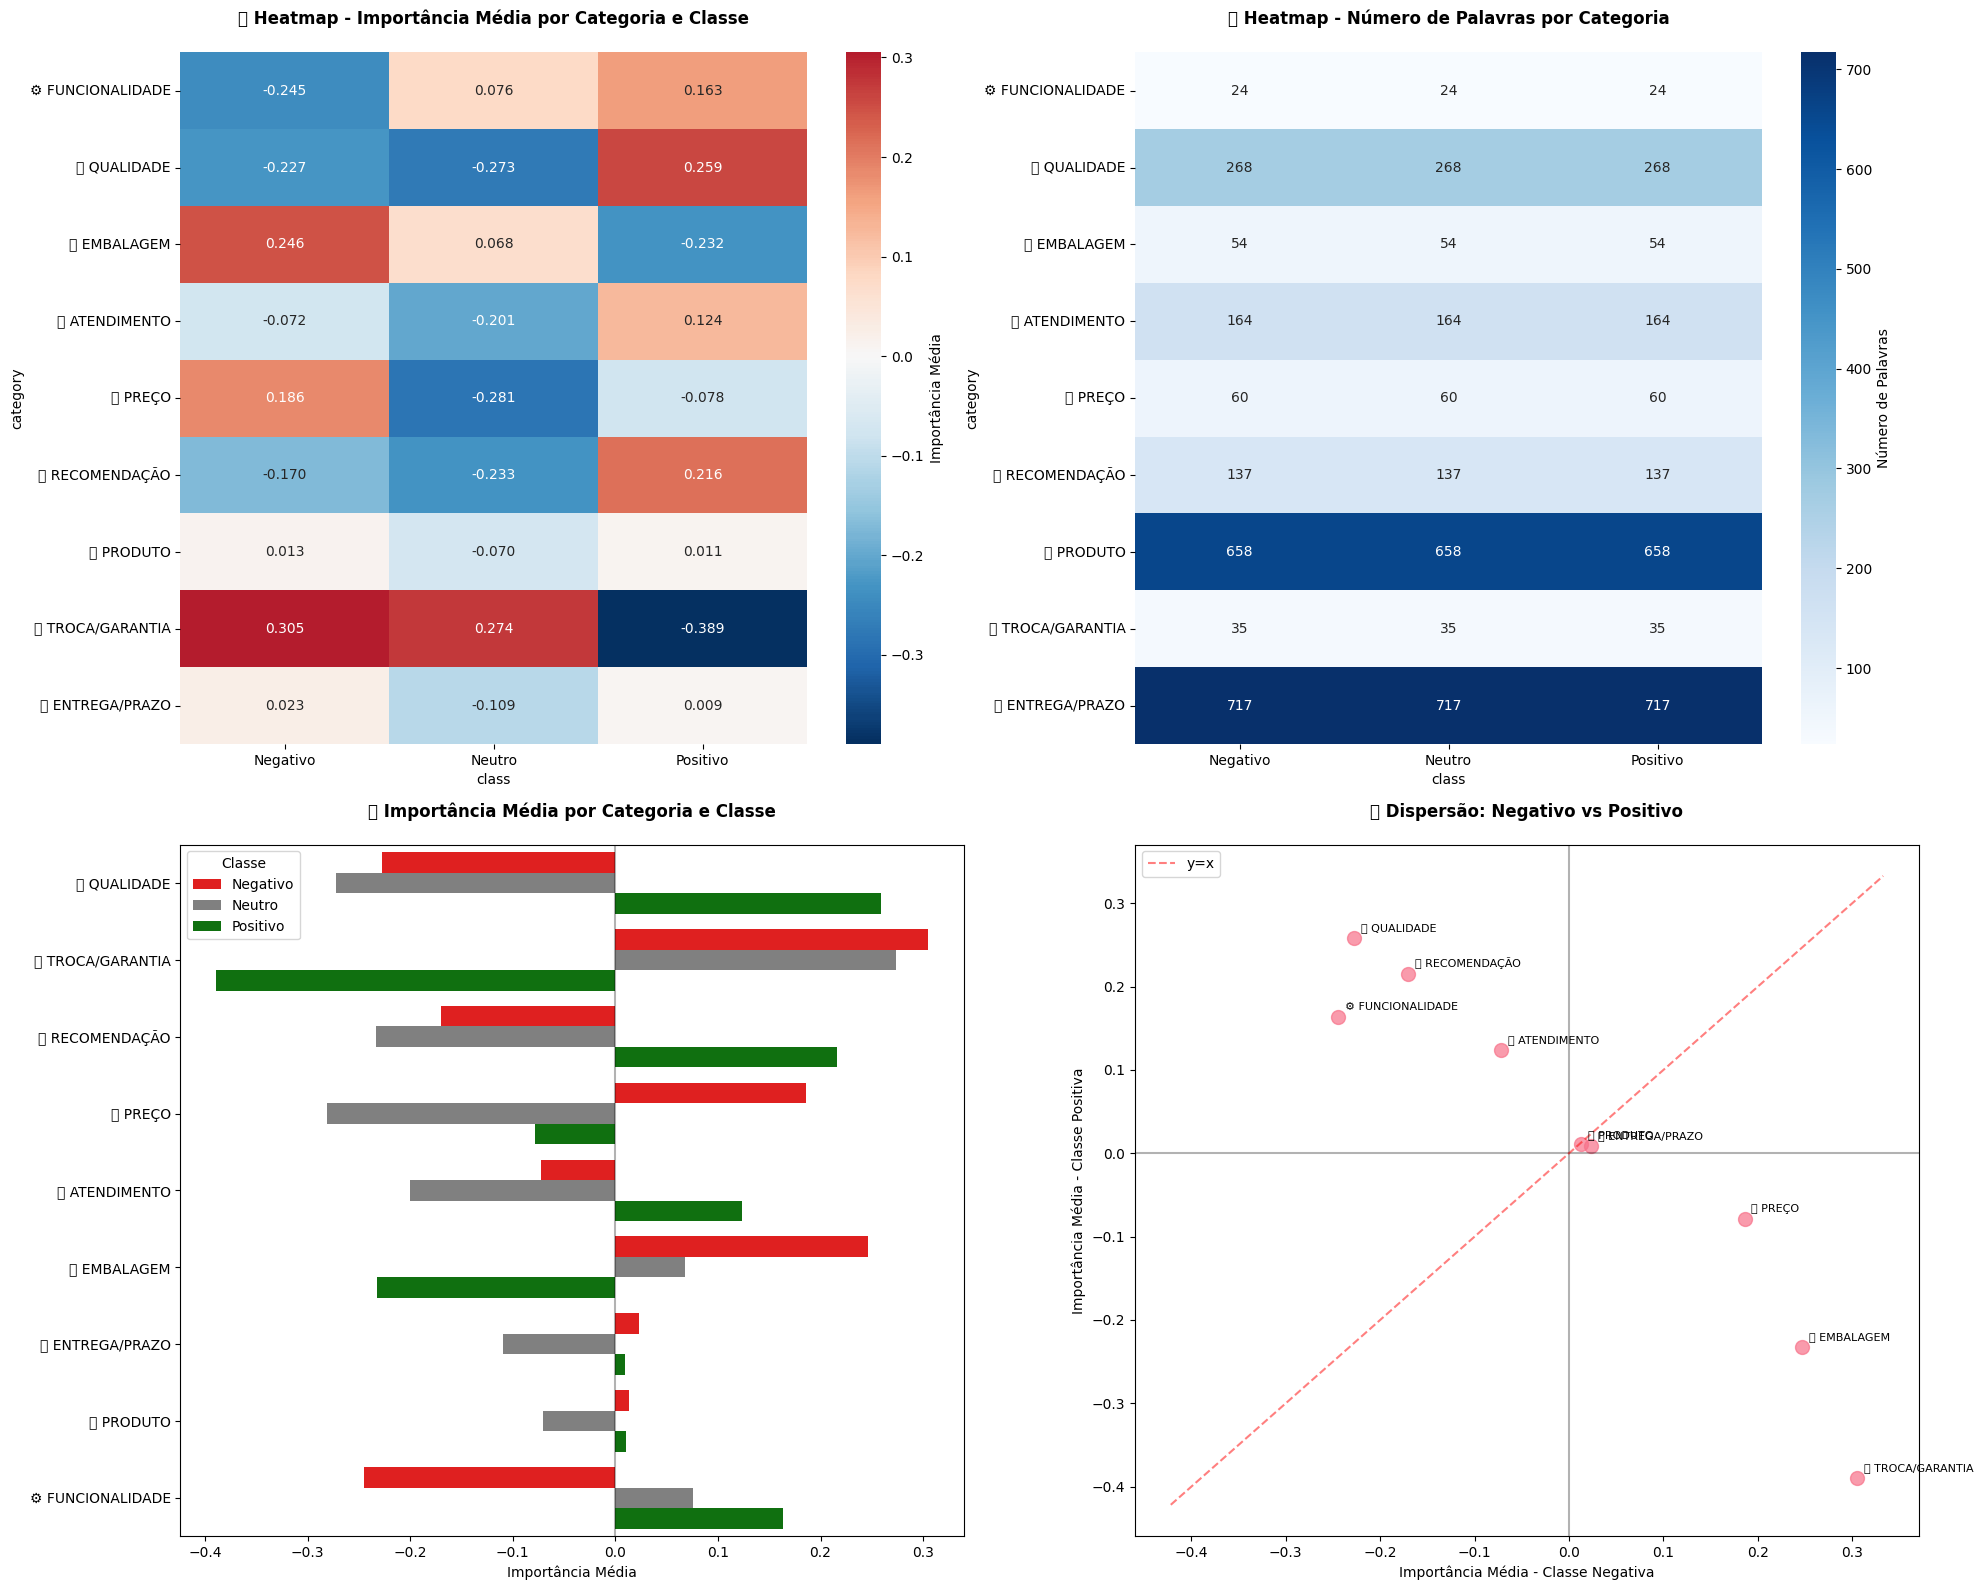


🎯 ANÁLISE DETALHADA POR CLASSE

📊 NEGATIVO:
   • Categoria mais impactante: ⭐ QUALIDADE (-60.890)
   • Total de categorias analisadas: 9
   • Média de palavras por categoria: 235.2

📊 NEUTRO:
   • Categoria mais impactante: 🚚 ENTREGA/PRAZO (-78.418)
   • Total de categorias analisadas: 9
   • Média de palavras por categoria: 235.2

📊 POSITIVO:
   • Categoria mais impactante: ⭐ QUALIDADE (69.286)
   • Total de categorias analisadas: 9
   • Média de palavras por categoria: 235.2


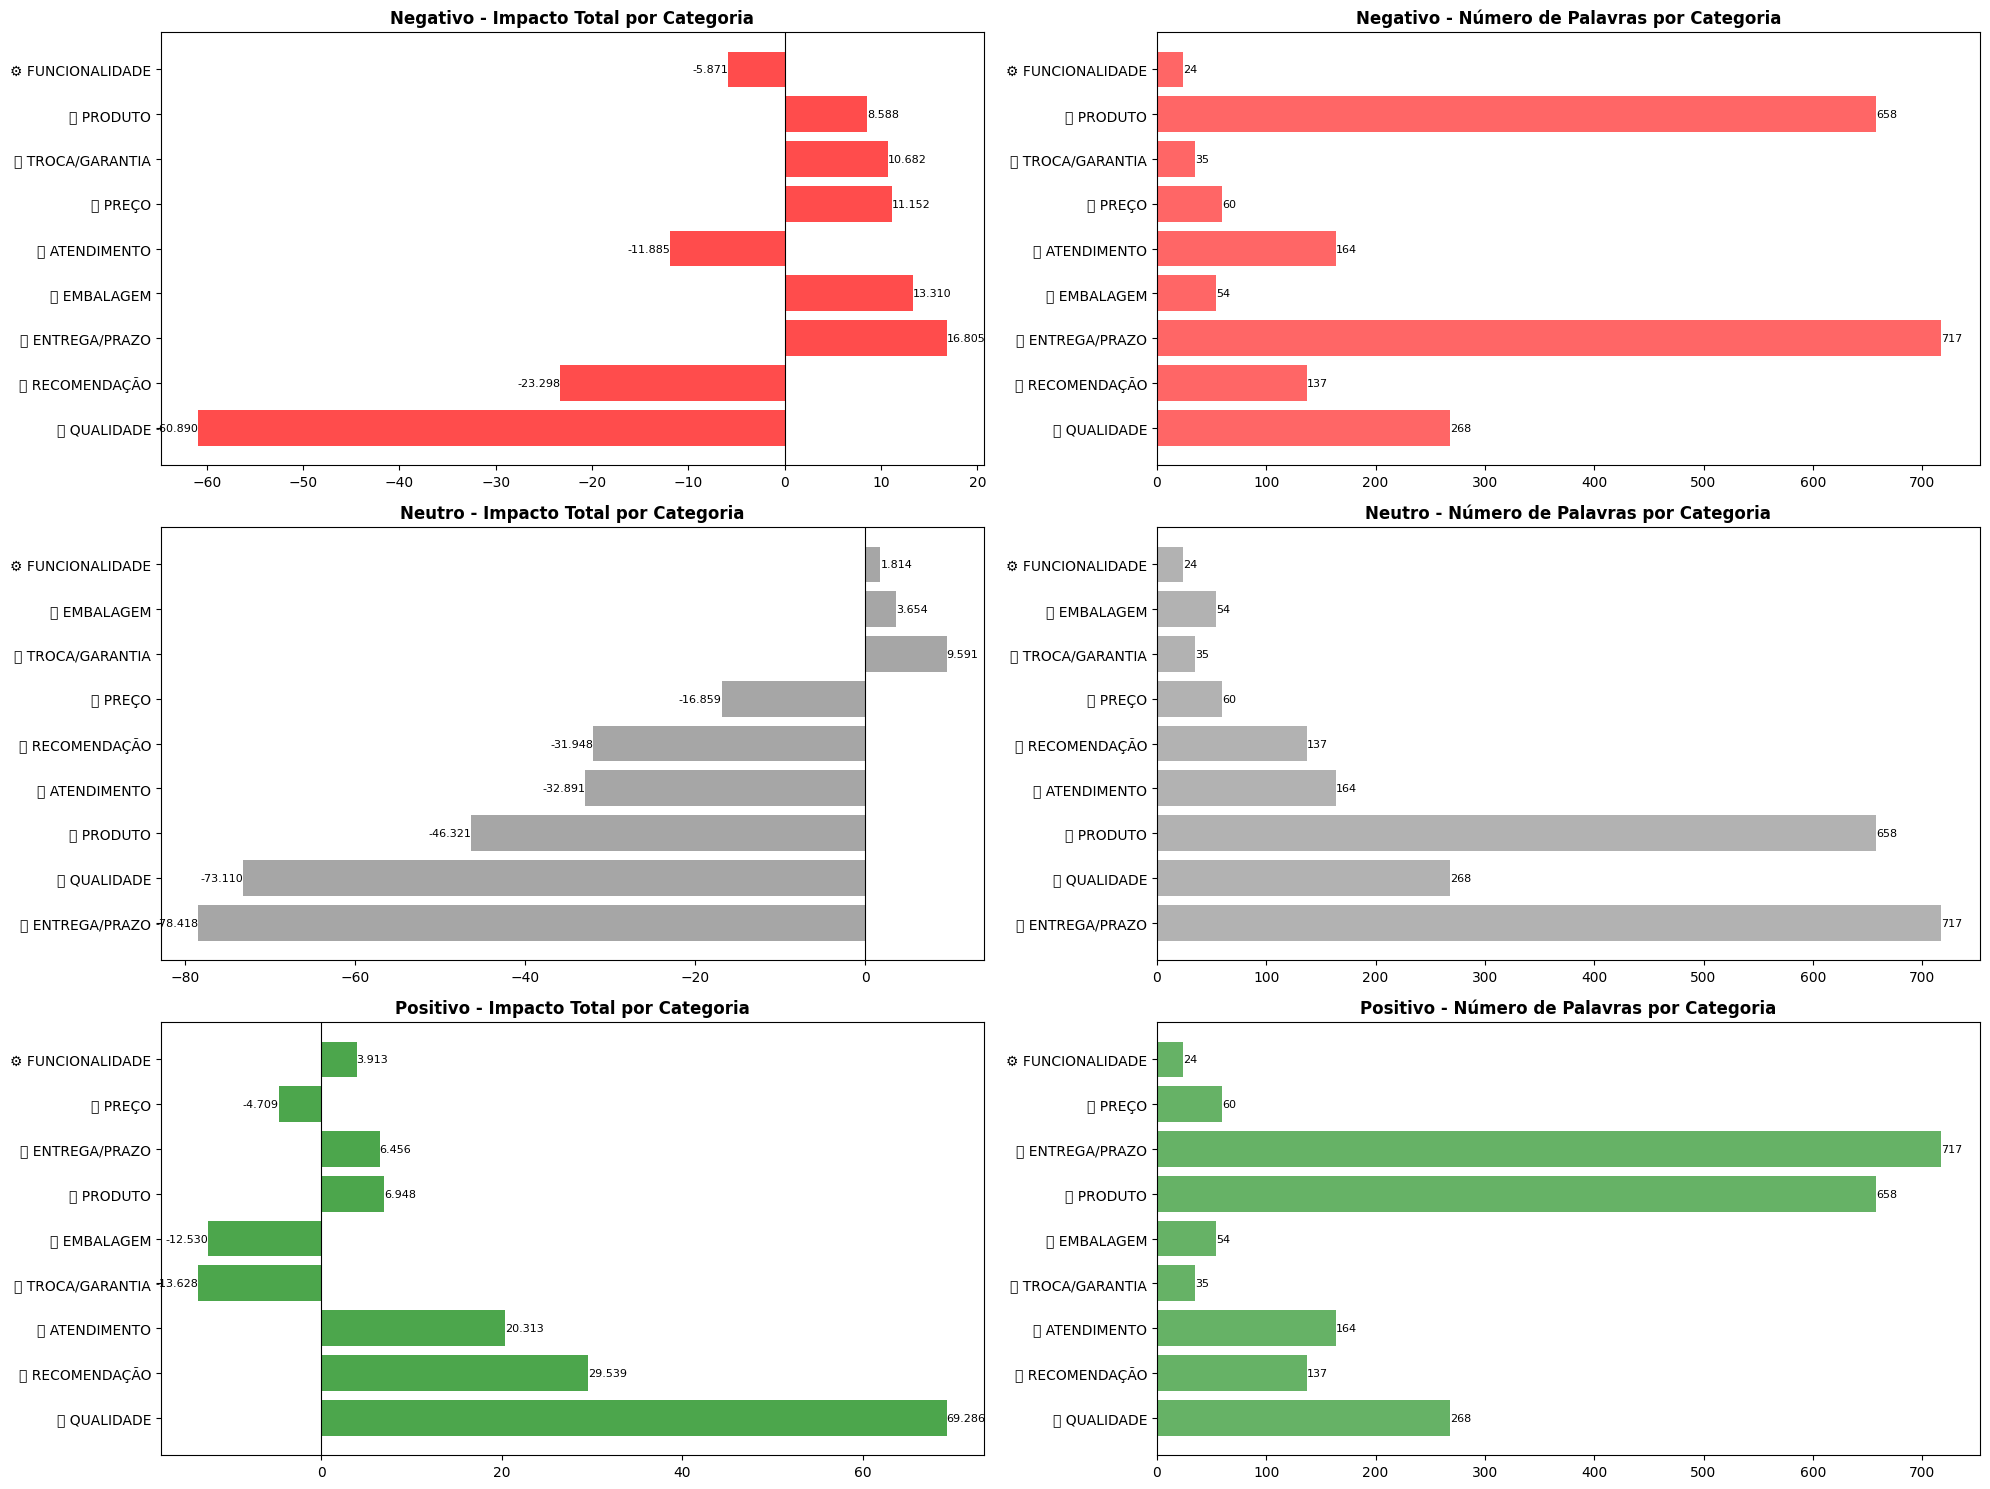


🔥 PALAVRAS-CHAVE MAIS IMPACTANTES


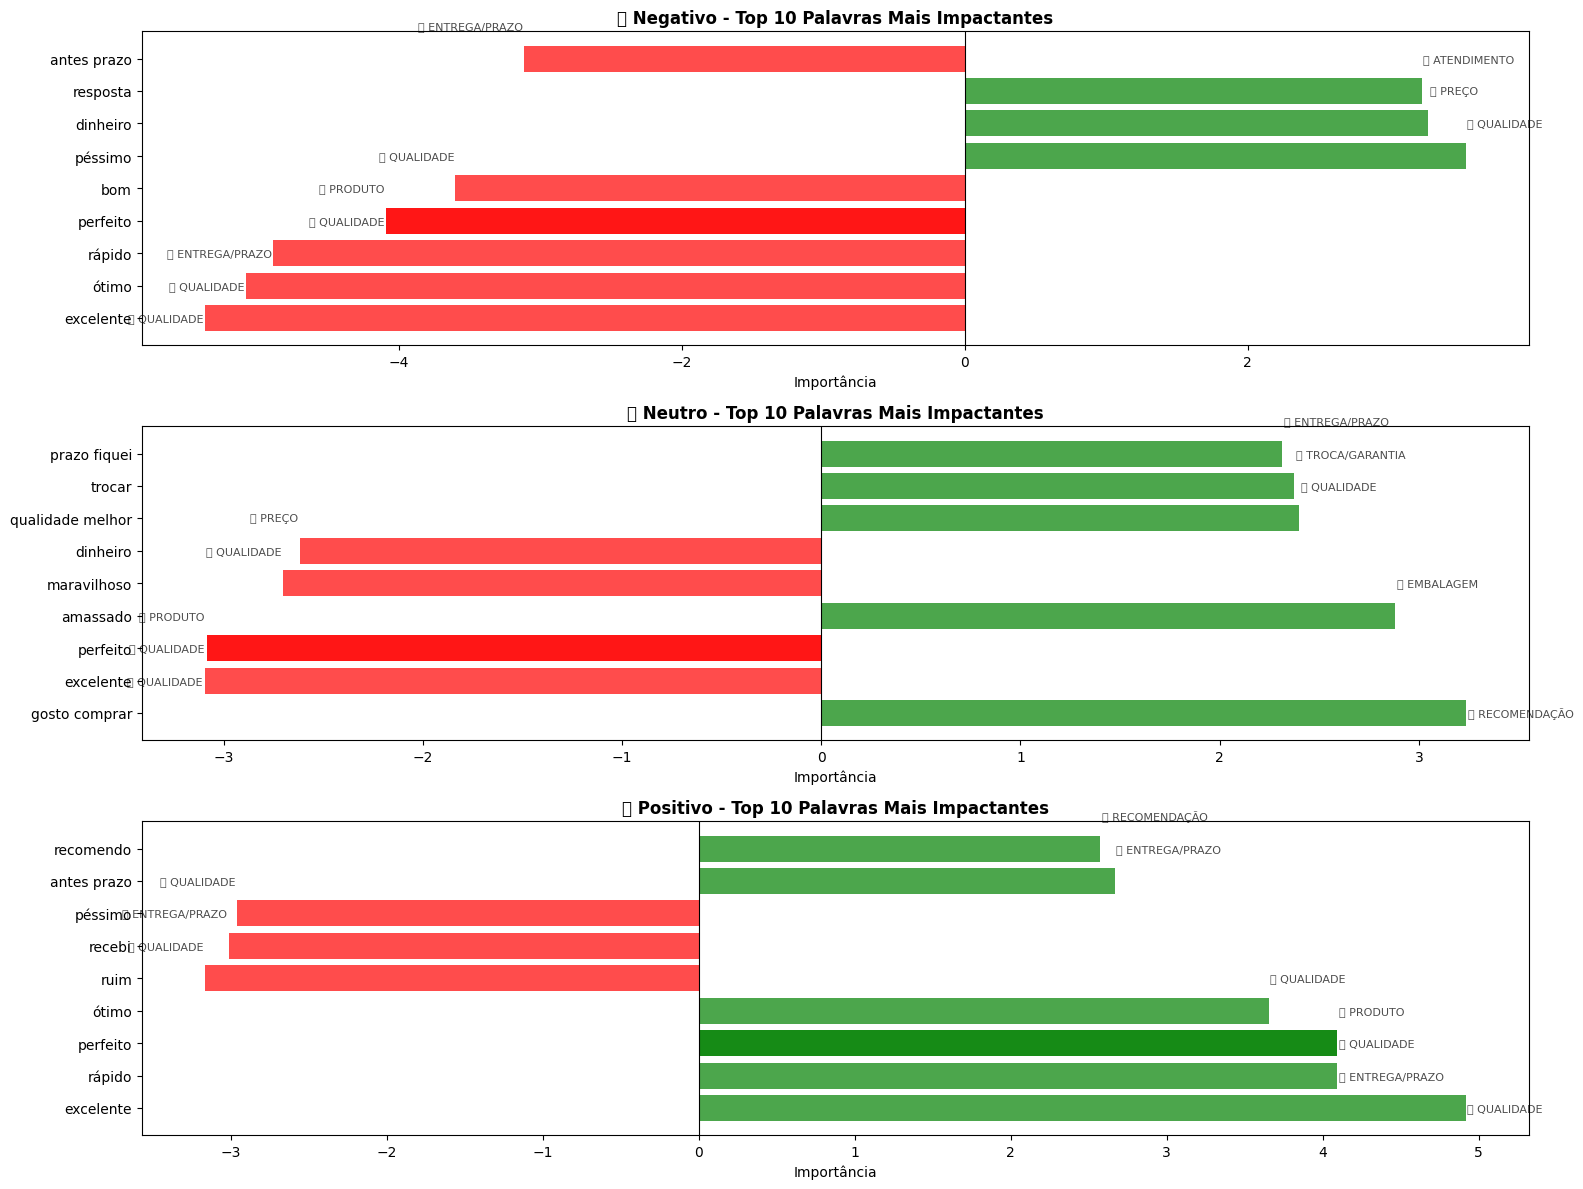


🔄 ANÁLISE DE CORRELAÇÃO ENTRE CATEGORIAS


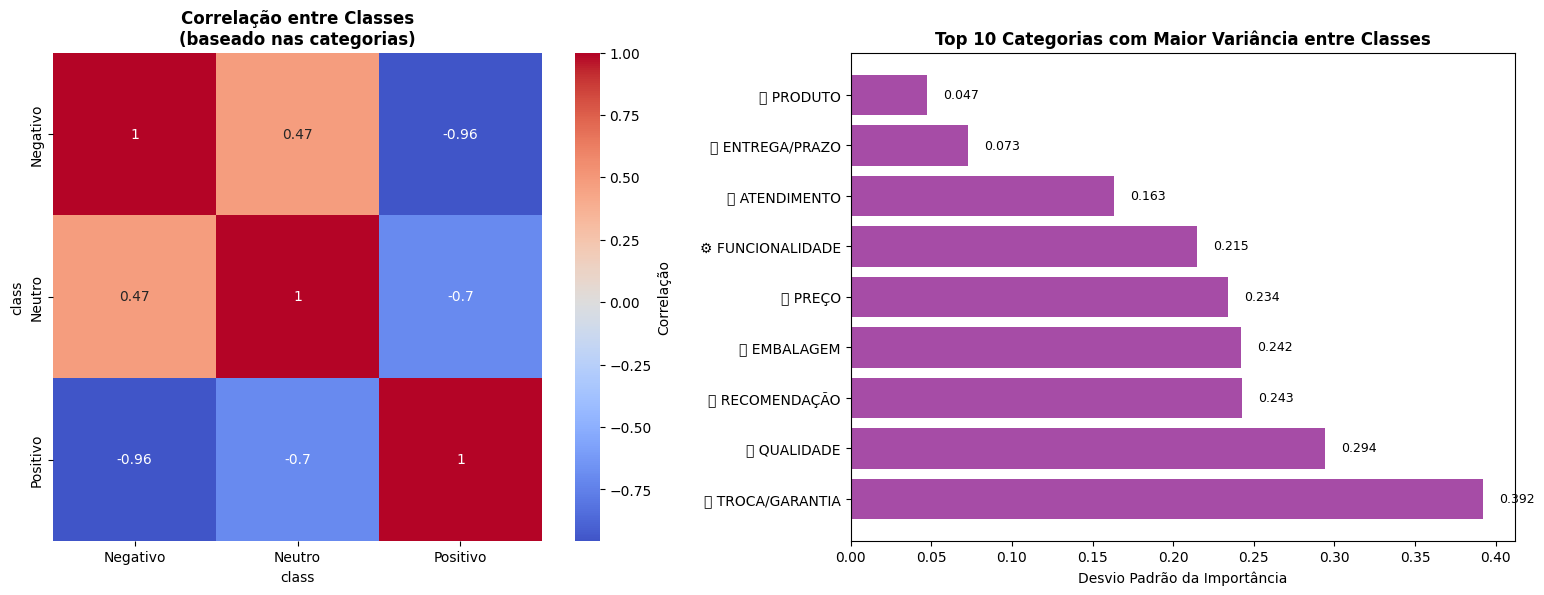


📈 INSIGHTS DE CORRELAÇÃO:
   • Correlação Negativo-Positivo: -0.957
   • Categoria com maior variância: 🔄 TROCA/GARANTIA (0.392)
   • Categoria com menor variância: 📦 PRODUTO (0.047)

📋 RELATÓRIO EXECUTIVO - RESUMO DOS INSIGHTS

📊 MÉTRICAS GERAIS:
   • Total de categorias analisadas: 9
   • Total de palavras categorizadas: 6351
   • Categorias com maior vocabulário: ['🚚 ENTREGA/PRAZO', '📦 PRODUTO', '⭐ QUALIDADE']

🎯 CLASSE NEGATIVO:
   ✅ Categoria mais positiva: 🔄 TROCA/GARANTIA (0.305)
   ❌ Categoria mais negativa: ⚙️ FUNCIONALIDADE (-0.245)
   💬 Categoria mais discutida: 🚚 ENTREGA/PRAZO (717 palavras)

🎯 CLASSE NEUTRO:
   ✅ Categoria mais positiva: 🔄 TROCA/GARANTIA (0.274)
   ❌ Categoria mais negativa: 💰 PREÇO (-0.281)
   💬 Categoria mais discutida: 🚚 ENTREGA/PRAZO (717 palavras)

🎯 CLASSE POSITIVO:
   ✅ Categoria mais positiva: ⭐ QUALIDADE (0.259)
   ❌ Categoria mais negativa: 🔄 TROCA/GARANTIA (-0.389)
   💬 Categoria mais discutida: 🚚 ENTREGA/PRAZO (717 palavras)

🔥 PALAVRAS MAIS I

In [ ]:
# @title Análise Comparativa de Importância por Categoria entre Classes de Sentimento

warnings.filterwarnings('ignore')

# Configurações de estilo
plt.style.use('default')
sns.set_palette("husl")

# Definir as categorias expandidas com mais palavras-chave
categories = {
    '🚚 ENTREGA/PRAZO': ['entreg', 'prazo', 'rápido', 'rapida', 'demora', 'chegou', 'recebi', 'tempo',
                        'frete', 'encomenda', 'envio', 'transport', 'postagem', 'atraso', 'entregue', 'rapidez'],
    '⭐ QUALIDADE': ['qualidade', 'excelente', 'ruim', 'péssimo', 'pessimo', 'ótimo', 'otimo', 'bom',
                   'mal', 'superou', 'incrivel', 'fantastico', 'horrivel', 'maravilhoso', 'lixo', 'perfeito'],
    '💬 ATENDIMENTO': ['atendimento', 'cliente', 'suporte', 'resposta', 'ajudou', 'educado', 'prestativo',
                      'atendeu', 'vendedor', 'loja', 'grosseria', 'gentil', 'duvida', 'esclareceu', 'sac'],
    '📦 PRODUTO': ['produto', 'funciona', 'defeito', 'perfeito', 'quebrou', 'uso', 'utilizar', 'material',
                  'acabamento', 'durabilidade', 'tamanho', 'cor', 'modelo', 'marca', 'funcionamento', 'performance'],
    '💰 PREÇO': ['preço', 'preco', 'caro', 'barato', 'valor', 'custou', 'reais', 'dinheiro', 'paguei',
                'investimento', 'custobeneficio', 'gasto', 'desconto', 'promocao', 'baratinho'],
    '🎁 EMBALAGEM': ['embalagem', 'pacote', 'caixa', 'protegido', 'amassado', 'danificado', 'avariado',
                    'inteiro', 'quebrado', 'lacre', 'plastico', 'papel', 'protecao', 'bemembalado'],
    '⚙️ FUNCIONALIDADE': ['facil', 'dificil', 'simples', 'complicado', 'usar', 'manuseio', 'instalacao',
                         'montagem', 'manual', 'instrucao', 'intuitivo', 'pratico'],
    '🔄 TROCA/GARANTIA': ['troca', 'devolucao', 'garantia', 'reembolso', 'devolver', 'trocaria', 'devolvido'],
    '📢 RECOMENDAÇÃO': ['recomendo', 'recomend', 'indicar', 'comprar', 'compraria', 'evitem', 'cuidado',
                       'aviso', 'indicacao', 'sugiro', 'aconselho']
}

# 1. ANÁLISE COMPARATIVA AVANÇADA ENTRE CLASSES
def advanced_comparative_analysis(model, vectorizer, categories, class_names=None):
    """
    Análise comparativa avançada entre todas as classes com múltiplas visualizações
    """
    if class_names is None:
        class_names = {0: 'Negativo', 1: 'Neutro', 2: 'Positivo'}

    feature_names = vectorizer.get_feature_names_out()

    print("🔍 INICIANDO ANÁLISE COMPARATIVA AVANÇADA")
    print("=" * 70)

    # Coletar dados completos
    analysis_data = []

    for category, keywords in categories.items():
        for class_idx, class_name in class_names.items():
            coefs = model.coef_[class_idx]

            word_importance = pd.DataFrame({
                "word": feature_names,
                "importance": coefs,
                "abs_importance": np.abs(coefs)
            })

            # Filtrar palavras da categoria
            mask = word_importance['word'].str.contains('|'.join(keywords), case=False, na=False)
            category_words = word_importance[mask]

            if len(category_words) > 0:
                # Estatísticas da categoria
                avg_importance = category_words['importance'].mean()
                max_importance = category_words['importance'].max()
                min_importance = category_words['importance'].min()
                word_count = len(category_words)

                # Palavra mais positiva e mais negativa
                most_positive = category_words.nlargest(1, 'importance')
                most_negative = category_words.nsmallest(1, 'importance')

                analysis_data.append({
                    'category': category,
                    'class': class_name,
                    'avg_importance': avg_importance,
                    'max_importance': max_importance,
                    'min_importance': min_importance,
                    'word_count': word_count,
                    'most_positive_word': most_positive['word'].iloc[0] if len(most_positive) > 0 else '',
                    'most_positive_score': most_positive['importance'].iloc[0] if len(most_positive) > 0 else 0,
                    'most_negative_word': most_negative['word'].iloc[0] if len(most_negative) > 0 else '',
                    'most_negative_score': most_negative['importance'].iloc[0] if len(most_negative) > 0 else 0
                })

    analysis_df = pd.DataFrame(analysis_data)

    # 1. HEATMAP DE IMPORTÂNCIA MÉDIA
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))

    # Heatmap de importância média
    pivot_avg = analysis_df.pivot_table(index='category', columns='class', values='avg_importance', aggfunc='mean')
    sns.heatmap(pivot_avg, annot=True, cmap='RdBu_r', center=0, ax=axes[0,0], fmt='.3f',
                cbar_kws={'label': 'Importância Média'})
    axes[0,0].set_title('📊 Heatmap - Importância Média por Categoria e Classe', fontweight='bold', pad=20)
    axes[0,0].tick_params(axis='x', rotation=0)
    axes[0,0].tick_params(axis='y', rotation=0)

    # Heatmap de contagem de palavras
    pivot_count = analysis_df.pivot_table(index='category', columns='class', values='word_count', aggfunc='sum')
    sns.heatmap(pivot_count, annot=True, cmap='Blues', ax=axes[0,1], fmt='.0f',
                cbar_kws={'label': 'Número de Palavras'})
    axes[0,1].set_title('📈 Heatmap - Número de Palavras por Categoria', fontweight='bold', pad=20)
    axes[0,1].tick_params(axis='x', rotation=0)
    axes[0,1].tick_params(axis='y', rotation=0)

    # 2. GRÁFICO DE BARRAS COMPARATIVO
    category_order = analysis_df.groupby('category')['avg_importance'].mean().abs().sort_values(ascending=False).index

    sns.barplot(data=analysis_df, x='avg_importance', y='category', hue='class',
                order=category_order, ax=axes[1,0], palette=['red', 'gray', 'green'])
    axes[1,0].axvline(x=0, color='black', linestyle='-', alpha=0.3)
    axes[1,0].set_title('📋 Importância Média por Categoria e Classe', fontweight='bold', pad=20)
    axes[1,0].set_xlabel('Importância Média')
    axes[1,0].set_ylabel('')
    axes[1,0].legend(title='Classe')

    # 3. GRÁFICO DE DISPERSÃO
    scatter_data = analysis_df.pivot_table(index='category', columns='class', values='avg_importance').reset_index()
    axes[1,1].scatter(scatter_data['Negativo'], scatter_data['Positivo'], alpha=0.7, s=100)

    # Adicionar rótulos
    for idx, row in scatter_data.iterrows():
        axes[1,1].annotate(row['category'], (row['Negativo'], row['Positivo']),
                          xytext=(5, 5), textcoords='offset points', fontsize=8)

    axes[1,1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    axes[1,1].axvline(x=0, color='black', linestyle='-', alpha=0.3)
    axes[1,1].set_xlabel('Importância Média - Classe Negativa')
    axes[1,1].set_ylabel('Importância Média - Classe Positiva')
    axes[1,1].set_title('🔄 Dispersão: Negativo vs Positivo', fontweight='bold', pad=20)

    # Linha de referência
    max_val = max(axes[1,1].get_xlim()[1], axes[1,1].get_ylim()[1])
    min_val = min(axes[1,1].get_xlim()[0], axes[1,1].get_ylim()[0])
    axes[1,1].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, label='y=x')
    axes[1,1].legend()

    plt.tight_layout()
    plt.show()

    return analysis_df

# 2. ANÁLISE DETALHADA POR CLASSE
def detailed_class_analysis(model, vectorizer, categories, class_names=None):
    """
    Análise detalhada para cada classe individualmente
    """
    if class_names is None:
        class_names = {0: 'Negativo', 1: 'Neutro', 2: 'Positivo'}

    feature_names = vectorizer.get_feature_names_out()

    print("\n🎯 ANÁLISE DETALHADA POR CLASSE")
    print("=" * 50)

    fig, axes = plt.subplots(3, 2, figsize=(20, 15))
    colors = ['red', 'gray', 'green']

    for class_idx, (class_num, class_name) in enumerate(class_names.items()):
        coefs = model.coef_[class_num]

        word_importance = pd.DataFrame({
            "word": feature_names,
            "importance": coefs,
            "abs_importance": np.abs(coefs)
        })

        # Coletar dados para a classe
        class_data = []

        for category, keywords in categories.items():
            mask = word_importance['word'].str.contains('|'.join(keywords), case=False, na=False)
            category_words = word_importance[mask]

            if len(category_words) > 0:
                # Top 3 palavras mais importantes
                top_words = category_words.nlargest(3, 'abs_importance')
                total_impact = category_words['importance'].sum()
                word_count = len(category_words)

                class_data.append({
                    'category': category,
                    'total_impact': total_impact,
                    'word_count': word_count,
                    'avg_importance': category_words['importance'].mean(),
                    'top_words': list(zip(top_words['word'], top_words['importance']))
                })

        class_df = pd.DataFrame(class_data)

        if len(class_df) > 0:
            # Ordenar por impacto total
            class_df = class_df.sort_values('total_impact', key=abs, ascending=False)

            # Gráfico de impacto total
            bars = axes[class_idx, 0].barh(class_df['category'], class_df['total_impact'],
                                          color=colors[class_idx], alpha=0.7)
            axes[class_idx, 0].set_title(f'{class_name} - Impacto Total por Categoria', fontweight='bold')
            axes[class_idx, 0].axvline(x=0, color='black', linewidth=0.8)

            # Adicionar valores
            for bar in bars:
                width = bar.get_width()
                axes[class_idx, 0].text(width + (0.01 if width > 0 else -0.01),
                                      bar.get_y() + bar.get_height()/2,
                                      f'{width:.3f}',
                                      ha='left' if width > 0 else 'right',
                                      va='center', fontsize=8)

            # Gráfico de contagem de palavras
            axes[class_idx, 1].barh(class_df['category'], class_df['word_count'],
                                   color=colors[class_idx], alpha=0.6)
            axes[class_idx, 1].set_title(f'{class_name} - Número de Palavras por Categoria', fontweight='bold')

            # Adicionar valores de contagem
            for i, count in enumerate(class_df['word_count']):
                axes[class_idx, 1].text(count + 0.1, i, f'{count}', va='center', fontsize=8)

        # Estatísticas da classe
        print(f"\n📊 {class_name.upper()}:")
        if len(class_df) > 0:
            top_category = class_df.loc[class_df['total_impact'].abs().idxmax()]
            print(f"   • Categoria mais impactante: {top_category['category']} ({top_category['total_impact']:.3f})")
            print(f"   • Total de categorias analisadas: {len(class_df)}")
            print(f"   • Média de palavras por categoria: {class_df['word_count'].mean():.1f}")

    plt.tight_layout()
    plt.show()

# 3. ANÁLISE DE PALAVRAS-CHAVE MAIS IMPORTANTES
def keyword_impact_analysis(model, vectorizer, categories, class_names=None, top_n=5):
    """
    Análise detalhada das palavras-chave mais impactantes
    """
    if class_names is None:
        class_names = {0: 'Negativo', 1: 'Neutro', 2: 'Positivo'}

    feature_names = vectorizer.get_feature_names_out()

    print("\n🔥 PALAVRAS-CHAVE MAIS IMPACTANTES")
    print("=" * 50)

    # Coletar todas as palavras impactantes
    all_keywords_data = []

    for class_idx, class_name in class_names.items():
        coefs = model.coef_[class_idx]

        word_importance = pd.DataFrame({
            "word": feature_names,
            "importance": coefs,
            "abs_importance": np.abs(coefs)
        })

        for category, keywords in categories.items():
            mask = word_importance['word'].str.contains('|'.join(keywords), case=False, na=False)
            category_words = word_importance[mask]

            if len(category_words) > 0:
                # Top palavras da categoria
                top_words = category_words.nlargest(top_n, 'abs_importance')

                for _, row in top_words.iterrows():
                    all_keywords_data.append({
                        'category': category,
                        'class': class_name,
                        'word': row['word'],
                        'importance': row['importance'],
                        'abs_importance': row['abs_importance']
                    })

    keywords_df = pd.DataFrame(all_keywords_data)

    # Criar visualização
    fig, axes = plt.subplots(3, 1, figsize=(16, 12))

    for idx, class_name in enumerate(class_names.values()):
        class_data = keywords_df[keywords_df['class'] == class_name]

        if len(class_data) > 0:
            # Top 10 palavras mais importantes da classe
            top_class_words = class_data.nlargest(10, 'abs_importance')

            colors = ['red' if imp < 0 else 'green' for imp in top_class_words['importance']]
            bars = axes[idx].barh(top_class_words['word'], top_class_words['importance'], color=colors, alpha=0.7)

            axes[idx].set_title(f'🔍 {class_name} - Top 10 Palavras Mais Impactantes', fontweight='bold')
            axes[idx].axvline(x=0, color='black', linewidth=0.8)
            axes[idx].set_xlabel('Importância')

            # Adicionar categoria como anotação
            for i, (_, row) in enumerate(top_class_words.iterrows()):
                axes[idx].text(row['importance'] + (0.01 if row['importance'] > 0 else -0.01),
                             i, row['category'], va='center', fontsize=8, alpha=0.7,
                             ha='left' if row['importance'] > 0 else 'right')

    plt.tight_layout()
    plt.show()

    return keywords_df

# 4. ANÁLISE DE CORRELAÇÃO ENTRE CATEGORIAS
def category_correlation_analysis(analysis_df):
    """
    Análise de correlação entre as categorias
    """
    print("\n🔄 ANÁLISE DE CORRELAÇÃO ENTRE CATEGORIAS")
    print("=" * 50)

    # Preparar dados para correlação
    correlation_data = analysis_df.pivot_table(index='category', columns='class', values='avg_importance')

    # Calcular correlação entre classes
    class_correlation = correlation_data.corr()

    # Calcular variância entre classes por categoria
    correlation_data['variance'] = correlation_data.std(axis=1)
    correlation_data['range'] = correlation_data.max(axis=1) - correlation_data.min(axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Heatmap de correlação entre classes
    sns.heatmap(class_correlation, annot=True, cmap='coolwarm', center=0, ax=axes[0],
                square=True, cbar_kws={'label': 'Correlação'})
    axes[0].set_title('Correlação entre Classes\n(baseado nas categorias)', fontweight='bold')

    # Gráfico de variância entre classes
    top_variance = correlation_data.nlargest(10, 'variance')['variance']
    bars = axes[1].barh(top_variance.index, top_variance.values, color='purple', alpha=0.7)
    axes[1].set_title('Top 10 Categorias com Maior Variância entre Classes', fontweight='bold')
    axes[1].set_xlabel('Desvio Padrão da Importância')

    # Adicionar valores
    for bar in bars:
        axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                    f'{bar.get_width():.3f}', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    # Insights
    print(f"\n📈 INSIGHTS DE CORRELAÇÃO:")
    print(f"   • Correlação Negativo-Positivo: {class_correlation.loc['Negativo', 'Positivo']:.3f}")
    print(f"   • Categoria com maior variância: {correlation_data['variance'].idxmax()} ({correlation_data['variance'].max():.3f})")
    print(f"   • Categoria com menor variância: {correlation_data['variance'].idxmin()} ({correlation_data['variance'].min():.3f})")

    return correlation_data

# 5. RELATÓRIO EXECUTIVO INTERATIVO
def generate_executive_report(analysis_df, keywords_df):
    """
    Gera relatório executivo com insights principais
    """
    print("\n" + "="*70)
    print("📋 RELATÓRIO EXECUTIVO - RESUMO DOS INSIGHTS")
    print("="*70)

    # Insights gerais
    total_categories = len(analysis_df['category'].unique())
    total_words_analyzed = analysis_df['word_count'].sum()

    print(f"\n📊 MÉTRICAS GERAIS:")
    print(f"   • Total de categorias analisadas: {total_categories}")
    print(f"   • Total de palavras categorizadas: {total_words_analyzed}")
    print(f"   • Categorias com maior vocabulário: {analysis_df.groupby('category')['word_count'].sum().nlargest(3).index.tolist()}")

    # Análise por classe
    for class_name in analysis_df['class'].unique():
        class_data = analysis_df[analysis_df['class'] == class_name]

        # Categoria mais positiva
        most_positive_cat = class_data.loc[class_data['avg_importance'].idxmax()]
        # Categoria mais negativa
        most_negative_cat = class_data.loc[class_data['avg_importance'].idxmin()]
        # Categoria mais discutida
        most_discussed_cat = class_data.loc[class_data['word_count'].idxmax()]

        print(f"\n🎯 CLASSE {class_name.upper()}:")
        print(f"   ✅ Categoria mais positiva: {most_positive_cat['category']} ({most_positive_cat['avg_importance']:.3f})")
        print(f"   ❌ Categoria mais negativa: {most_negative_cat['category']} ({most_negative_cat['avg_importance']:.3f})")
        print(f"   💬 Categoria mais discutida: {most_discussed_cat['category']} ({most_discussed_cat['word_count']} palavras)")

    # Palavras mais impactantes
    print(f"\n🔥 PALAVRAS MAIS IMPACTANTES:")
    for class_name in keywords_df['class'].unique():
        class_words = keywords_df[keywords_df['class'] == class_name].nlargest(3, 'abs_importance')
        top_words = [f"{row['word']}({row['importance']:.2f})" for _, row in class_words.iterrows()]
        print(f"   {class_name}: {', '.join(top_words)}")

# 6. EXECUTAR TODAS AS ANÁLISES
print("🚀 INICIANDO ANÁLISE COMPARATIVA COMPLETA...")

# Executar análise comparativa avançada
comparative_results = advanced_comparative_analysis(model, tfidf_vectorizer, categories)

# Executar análise detalhada por classe
detailed_class_analysis(model, tfidf_vectorizer, categories)

# Executar análise de palavras-chave
keywords_analysis = keyword_impact_analysis(model, tfidf_vectorizer, categories)

# Executar análise de correlação
correlation_analysis = category_correlation_analysis(comparative_results)

# Gerar relatório executivo
generate_executive_report(comparative_results, keywords_analysis)

print("\n✅ ANÁLISE COMPARATIVA CONCLUÍDA COM SUCESSO!")

📚 Total de stop words: 197
🚀 INICIANDO ANÁLISE DE TÓPICOS COM TODA A BASE DE DADOS...
🔧 Pré-processando todos os reviews...
📊 Reviews após remover nulos: 40977
📊 Reviews com 3+ palavras: 35305
📊 Amostrando 10000 reviews para análise...
🎯 Total de reviews para análise: 10000
📊 Estatísticas dos reviews:
   • Média de palavras: 13.4
   • Mediana de palavras: 10.0
   • Reviews mais curto: 3 palavras
   • Reviews mais longo: 45 palavras
📝 Exemplos de reviews:
  1. Produto chegou antes do prazo. 
  2. Por enquanto chegou só um produto, e de cor errada, pedi verde e veio rosa, mas como eu vou mudar precisei usar dessa cor mesmo, enquanto o outro está escrito que foi entregue e não chegou.
  3. Recebi dentro do prazo
🔧 Criando vetorizador otimizado...
✅ Matriz criada: (10000, 1000)
   • Elementos não-zero: 67834
   • Densidade: 0.68%
📝 Features disponíveis: 1000
📋 Top 20 features: ['00', '01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '10 dias', '100', '11', '12', '14', '15', '16',

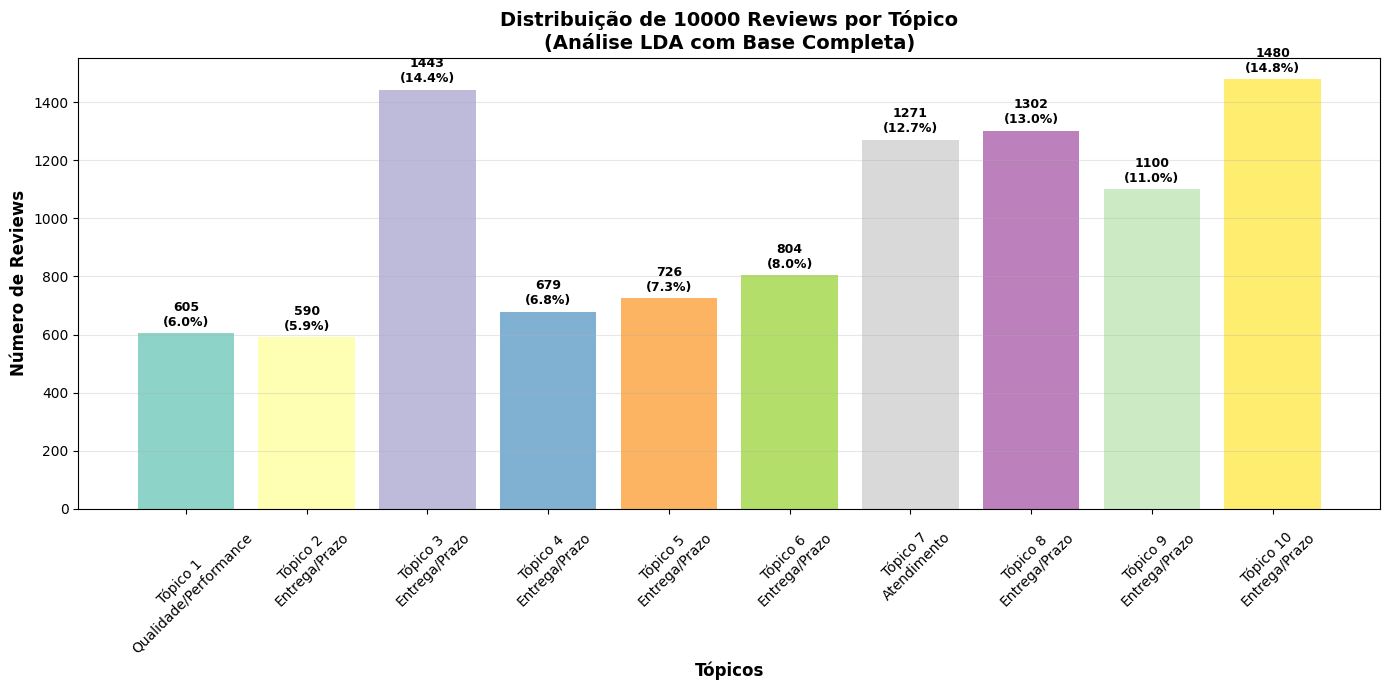


📈 PALAVRAS MAIS FREQUENTES NA BASE COMPLETA:
Top 25 palavras mais significativas (já filtradas por stop words):
   1. nao                3450 ocorrências (34.5%)
   2. prazo              2371 ocorrências (23.7%)
   3. entrega            1840 ocorrências (18.4%)
   4. chegou             1547 ocorrências (15.5%)
   5. antes              1521 ocorrências (15.2%)
   6. recebi             1518 ocorrências (15.2%)
   7. antes prazo        1156 ocorrências (11.6%)
   8. recomendo          1085 ocorrências (10.8%)
   9. entregue           1061 ocorrências (10.6%)
  10. bom                 999 ocorrências (10.0%)
  11. veio                932 ocorrências (9.3%)
  12. bem                 855 ocorrências (8.6%)
  13. comprei             812 ocorrências (8.1%)
  14. qualidade           760 ocorrências (7.6%)
  15. so                  599 ocorrências (6.0%)
  16. nao recebi          595 ocorrências (5.9%)
  17. super               469 ocorrências (4.7%)
  18. rapida              466 ocorrências (4

In [ ]:
# @title ANÁLISE LDA COMPLETA COM TODA A BASE DE DADOS

# ADD stop_words_portugues
# Adicionar stop words personalizadas para melhorar a análise
custom_stopwords = [
    'produto', 'produtos', 'loja', 'site', 'comprar', 'compra', 'comprou',
    'cliente', 'clientes', 'achei', 'acho', 'parece', 'realmente', 'muito',
    'pouco', 'também', 'sendo', 'ficou', 'fica', 'fazer', 'feito', 'nesse',
    'nessa', 'nisso', 'ainda', 'sempre', 'somente', 'apenas', 'somente',
    'então', 'porém', 'contudo', 'todavia', 'assim', 'desse', 'disso',
    'mesmo', 'próprio', 'qualquer', 'algum', 'alguns', 'cada', 'vários',
    'tudo', 'todo', 'todos', 'todas', 'outro', 'outra', 'outros', 'outras'
]

# Combinar stop words do NLTK com as personalizadas
all_stopwords = list(set(stop_words_portugues + custom_stopwords))
print(f"📚 Total de stop words: {len(all_stopwords)}")

print("🚀 INICIANDO ANÁLISE DE TÓPICOS COM TODA A BASE DE DADOS...")

# 1. Pré-processamento robusto para lidar com toda a base
def preprocess_all_reviews(reviews_series):
    """Pré-processa todos os reviews da base"""

    print("🔧 Pré-processando todos os reviews...")

    # Remover valores nulos
    reviews_clean = reviews_series.dropna()
    print(f"📊 Reviews após remover nulos: {len(reviews_clean)}")

    # Filtrar reviews muito curtos (menos de 3 palavras)
    reviews_filtered = [
        review for review in reviews_clean
        if isinstance(review, str) and len(review.split()) >= 3
    ]
    print(f"📊 Reviews com 3+ palavras: {len(reviews_filtered)}")

    # Se ainda tiver muitos dados, fazer amostragem para performance
    max_reviews = 10000  # Ajuste conforme sua capacidade computacional
    if len(reviews_filtered) > max_reviews:
        print(f"📊 Amostrando {max_reviews} reviews para análise...")
        reviews_filtered = pd.Series(reviews_filtered).sample(
            n=max_reviews,
            random_state=42
        ).tolist()

    return reviews_filtered

# 2. Obter todos os reviews pré-processados
all_reviews = preprocess_all_reviews(reviews_df['review_comment_message'])
print(f"🎯 Total de reviews para análise: {len(all_reviews)}")

# Mostrar estatísticas
if len(all_reviews) > 0:
    review_lengths = [len(str(review).split()) for review in all_reviews]
    print(f"📊 Estatísticas dos reviews:")
    print(f"   • Média de palavras: {np.mean(review_lengths):.1f}")
    print(f"   • Mediana de palavras: {np.median(review_lengths):.1f}")
    print(f"   • Reviews mais curto: {min(review_lengths)} palavras")
    print(f"   • Reviews mais longo: {max(review_lengths)} palavras")

print("📝 Exemplos de reviews:")
for i, review in enumerate(all_reviews[:3]):
    print(f"  {i+1}. {review}")

# 3. Criar vetorizador otimizado para grande volume
def create_optimized_vectorizer(texts, stop_words_list):
    """Cria vetorizador otimizado para grande volume de dados"""

    print("🔧 Criando vetorizador otimizado...")

    # Configurações para grande volume
    n_features = min(1000, len(texts) // 2)  # Ajuste dinâmico
    n_features = max(50, n_features)  # Mínimo de 50 features

    vectorizer = CountVectorizer(
        max_features=n_features,
        min_df=1,                    # Ignorar palavras que aparecem apenas 1 vez
        max_df=0.95,                  # Ignorar palavras muito comuns
        lowercase=True,
        stop_words=stop_words_list,
        ngram_range=(1, 2),          # Unigramas e bigramas
        strip_accents='unicode'
    )

    X = vectorizer.fit_transform(texts)
    print(f"✅ Matriz criada: {X.shape}")
    print(f"   • Elementos não-zero: {X.nnz}")
    print(f"   • Densidade: {(X.nnz / (X.shape[0] * X.shape[1]) * 100):.2f}%")

    return vectorizer, X

# 4. Criar vetorizador com todos os dados
vectorizer, X = create_optimized_vectorizer(all_reviews, all_stopwords)
feature_names = vectorizer.get_feature_names_out()

print(f"📝 Features disponíveis: {len(feature_names)}")
print(f"📋 Top 20 features: {list(feature_names[:20])}")

# 5. Determinar número ideal de tópicos
def calculate_optimal_topics(n_reviews, n_features):
    """Calcula número ideal de tópicos baseado no volume de dados"""

    # Baseado no tamanho dos dados
    if n_reviews < 50:
        return max(2, n_reviews // 10)
    elif n_reviews < 500:
        return min(5, n_reviews // 20)
    elif n_reviews < 2000:
        return min(8, n_reviews // 100)
    else:
        return min(10, n_reviews // 500)

n_components = calculate_optimal_topics(len(all_reviews), len(feature_names))
n_components = max(2, min(n_components, 10))  # Entre 2 e 10 tópicos

print(f"🔧 Configurando {n_components} tópicos...")
print(f"   • Baseado em {len(all_reviews)} reviews e {len(feature_names)} features")

# 6. Criar modelo LDA otimizado
def create_optimized_lda(X, n_components):
    """Cria modelo LDA otimizado para grande volume"""

    print(f"🎯 Criando LDA com {n_components} tópicos...")

    lda_model = LatentDirichletAllocation(
        n_components=n_components,
        random_state=42,
        max_iter=100,               # Mais iterações para convergência
        learning_method='online',
        learning_offset=50.,
        batch_size=128,             # Processamento em lotes
        evaluate_every=5,
        perp_tol=0.1
    )

    W = lda_model.fit_transform(X)
    print("✅ LDA treinado com sucesso!")

    return lda_model, W

# 7. Criar modelo LDA com todos os dados
lda_model, topic_distribution = create_optimized_lda(X, n_components)
dominant_topics = topic_distribution.argmax(axis=1)

# 8. Analisar os tópicos
print(f"\n{'='*60}")
print(f"🎯 {n_components} TÓPICOS IDENTIFICADOS NA BASE COMPLETA:")
print(f"{'='*60}")

for topic_idx, topic in enumerate(lda_model.components_):
    top_word_indices = topic.argsort()[-15:][::-1]  # Top 15 palavras
    top_words = [feature_names[i] for i in top_word_indices]
    top_scores = [topic[i] for i in top_word_indices]

    print(f"\n📌 TÓPICO {topic_idx + 1}:")
    for i, (word, score) in enumerate(zip(top_words, top_scores)):
        print(f"   {i+1:2d}. {word:15} ({score:.1f})")

# 9. Distribuição dos tópicos
print(f"\n{'='*60}")
print("📊 DISTRIBUIÇÃO DOS TÓPICOS NA BASE COMPLETA:")
print(f"{'='*60}")

topic_counts = pd.Series(dominant_topics).value_counts().sort_index()
total_reviews = len(dominant_topics)

for topic_idx, count in topic_counts.items():
    percentage = (count / total_reviews) * 100
    print(f"Tópico {topic_idx + 1}: {count} reviews ({percentage:.1f}%)")

# 10. Exemplos representativos por tópico
print(f"\n{'='*60}")
print("🔍 EXEMPLOS REPRESENTATIVOS POR TÓPICO:")
print(f"{'='*60}")

for topic_idx in range(n_components):
    print(f"\n📌 TÓPICO {topic_idx + 1}:")

    # Encontrar reviews mais representativos (maior confiança)
    topic_confidence = topic_distribution[:, topic_idx]
    top_indices = topic_confidence.argsort()[-3:][::-1]

    for i, idx in enumerate(top_indices):
        if topic_confidence[idx] > 0.1:  # Apenas reviews com boa confiança
            review_text = all_reviews[idx]
            confidence = topic_confidence[idx]
            print(f"  {i+1}. [Conf: {confidence:.3f}] {review_text}")

# 11. Nomear os tópicos automaticamente
def name_topic_improved(top_words):
    """Nomeia o tópico baseado nas palavras mais importantes"""
    words_str = ' '.join(top_words).lower()

    # Mapeamento mais abrangente
    topic_patterns = [
        (['entreg', 'rapid', 'prazo', 'chegou', 'frete', 'encomenda', 'transporte'], "📦 Entrega/Prazo"),
        (['qualidad', 'excelent', 'ótimo', 'perfeito', 'superou', 'maravilhoso', 'incrível'], "⭐ Qualidade/Performance"),
        (['atendimento', 'suporte', 'vendedor', 'resposta', 'comunicação', 'ajuda'], "👥 Atendimento"),
        (['preço', 'valor', 'caro', 'barato', 'cust', 'pagamento', 'reais'], "💰 Preço/Valor"),
        (['funciona', 'problema', 'defeito', 'quebr', 'avari', 'não funciona', 'defeituoso'], "⚙️ Funcionamento/Problemas"),
        (['recomendo', 'gostei', 'adorei', 'satisfeit', 'feliz', 'content', 'indicar'], "👍 Recomendação Positiva"),
        (['ruim', 'péssimo', 'horrível', 'decepcion', 'lent', 'terrível', 'pessimo'], "👎 Avaliação Negativa"),
        (['material', 'acabamento', 'durável', 'resistente', 'bonito', 'design', 'estrutura'], "🛠️ Material/Acabamento"),
        (['tamanho', 'cor', 'modelo', 'medida', 'grande', 'pequeno', 'cabe'], "📏 Tamanho/Aparência"),
        (['chegou', 'veio', 'veio certo', 'correspond', 'esperava', 'esperado'], "✅ Expectativa/Realidade")
    ]

    for patterns, name in topic_patterns:
        if any(pattern in words_str for pattern in patterns):
            return name

    return "🔍 Tópico Geral"

print(f"\n{'='*60}")
print("🏷️  NOMES SUGERIDOS PARA OS TÓPICOS:")
print(f"{'='*60}")

topic_names = {}
for topic_idx in range(n_components):
    topic = lda_model.components_[topic_idx]
    top_word_indices = topic.argsort()[-8:][::-1]  # Top 8 palavras
    top_words = [feature_names[i] for i in top_word_indices]
    topic_name = name_topic_improved(top_words)
    topic_names[topic_idx] = topic_name

    print(f"\n📌 Tópico {topic_idx + 1}: {topic_name}")
    print(f"   Palavras-chave: {', '.join(top_words)}")

# 12. Criar DataFrame com resultados completos
results_df = pd.DataFrame({
    'review_text': all_reviews,
    'dominant_topic': dominant_topics + 1,
    'topic_confidence': topic_distribution.max(axis=1),
    'topic_name': [topic_names[t] for t in dominant_topics]
})

print(f"\n💾 RESULTADOS OBTIDOS COM BASE COMPLETA:")
print(f"📊 Total de reviews analisados: {len(results_df)}")
print(f"🎯 Tópicos identificados: {n_components}")
print(f"🔧 Método usado: LDA (Latent Dirichlet Allocation)")
print(f"🚫 Stop words aplicadas: {len(all_stopwords)} palavras")

# 13. Análise de qualidade
print(f"\n📈 ANÁLISE DE QUALIDADE:")
avg_confidence = results_df['topic_confidence'].mean()
print(f"   • Confiança média na atribuição: {avg_confidence:.3f}")
print(f"   • Distribuição mais equilibrada: {topic_counts.std() / topic_counts.mean():.3f}")

# 14. Mostrar amostra dos resultados
print(f"\n📋 AMOSTRA DOS RESULTADOS (10 primeiros):")
sample_df = results_df[['review_text', 'dominant_topic', 'topic_name', 'topic_confidence']].head(10)
for idx, row in sample_df.iterrows():
    print(f"  Tópico {row['dominant_topic']} ({row['topic_confidence']:.3f}): {row['review_text'][:80]}...")

# 15. Visualização melhorada
plt.figure(figsize=(14, 7))

# Gráfico de distribuição
topic_counts = results_df['dominant_topic'].value_counts().sort_index()

# Cores distintas
colors = plt.cm.Set3(np.linspace(0, 1, len(topic_counts)))

# Nomes curtos para o gráfico
short_names = [name.split()[-1] for name in topic_names.values()]

bars = plt.bar(
    [f'Tópico {i}\n{short_names[i-1]}' for i in topic_counts.index],
    topic_counts.values,
    color=colors
)

plt.xlabel('Tópicos', fontsize=12, fontweight='bold')
plt.ylabel('Número de Reviews', fontsize=12, fontweight='bold')
plt.title(f'Distribuição de {len(results_df)} Reviews por Tópico\n(Análise LDA com Base Completa)',
          fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)

# Adicionar valores e porcentagens nas barras
for bar, count in zip(bars, topic_counts.values):
    percentage = (count / len(results_df)) * 100
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(topic_counts.values)*0.01,
             f'{count}\n({percentage:.1f}%)',
             ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# 16. Palavras mais frequentes na base completa
print(f"\n{'='*60}")
print("📈 PALAVRAS MAIS FREQUENTES NA BASE COMPLETA:")
print(f"{'='*60}")

word_freq = np.array(X.sum(axis=0)).flatten()
top_word_indices = word_freq.argsort()[-25:][::-1]

print("Top 25 palavras mais significativas (já filtradas por stop words):")
for i, idx in enumerate(top_word_indices):
    word = feature_names[idx]
    freq = word_freq[idx]
    percentage = (freq / len(results_df)) * 100
    print(f"  {i+1:2d}. {word:18} {freq:4d} ocorrências ({percentage:.1f}%)")

print(f"\n✅ ANÁLISE DA BASE COMPLETA CONCLUÍDA!")
print(f"🎉 Processados {len(results_df)} reviews com sucesso!")
print(f"📊 {n_components} tópicos identificados na base completa")
print(f"🚫 {len(all_stopwords)} stop words aplicadas para melhor qualidade")

# 17. Salvar resultados se desejar
try:
    results_df.to_csv('resultados_lda_base_completa.csv', index=False, encoding='utf-8')
    print("💾 Resultados salvos em 'resultados_lda_base_completa.csv'")
except:
    print("💡 Dica: Você pode salvar os resultados em CSV para análise posterior")

📚 Total de stop words: 197


🚀 INICIANDO ANÁLISE DE TÓPICOS COM TODA A BASE DE DADOS...

🔧 Pré-processando TODOS os reviews...

📊 Reviews após remover nulos: 40977

📊 Reviews com 3+ palavras: 35305

🎯 USANDO TODOS OS 35305 REVIEWS PARA ANÁLISE!


🎯 Total de reviews para análise: 35305


📊 ESTATÍSTICAS COMPLETAS DOS REVIEWS:
   • Total de reviews: 35,305
   • Média de palavras: 13.3
   • Mediana de palavras: 10.0
   • Reviews mais curto: 3 palavras
   • Reviews mais longo: 45 palavras
   • Desvio padrão: 9.3 palavras


📝 EXEMPLOS DE REVIEWS (amostra variada):
  1. Recebi bem antes do prazo estipulado....
  2. Atendimento com agilidade,principalmente em tirar duvidas sobre o produto.A entrega antes do prazo,f...
  3. fornecedor correto e produto excelente...
  4. Loja não entregou o produto um mês depois da compra....
  5. meu produto chegou e ja tenho que devolver, pois está com defeito , não segurar carga...

🔧 Criando vetorizador para 35,305 reviews...
   • Número de features: 1000

✅

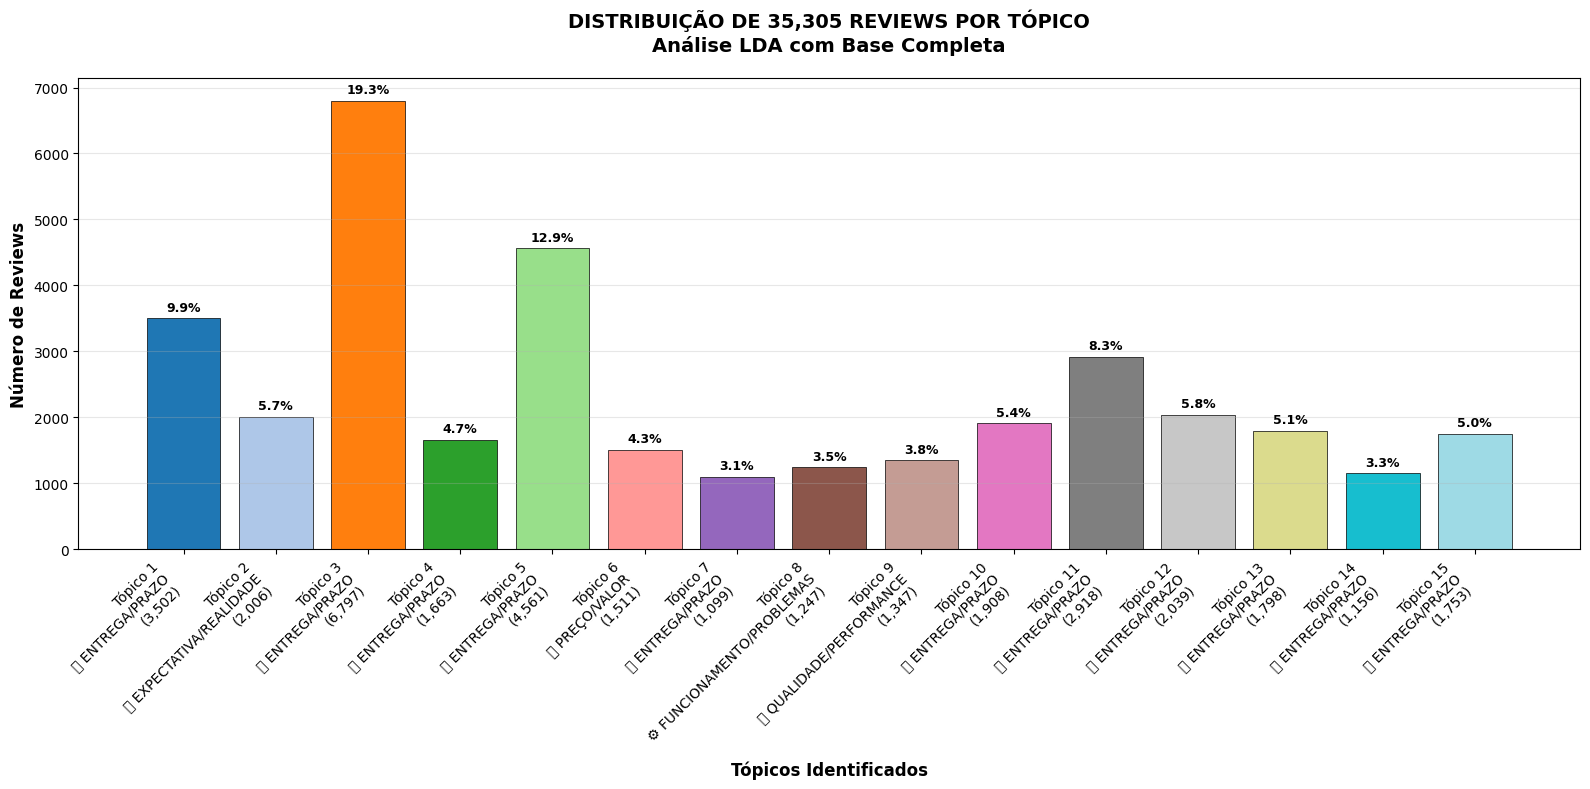


📈 TOP 50 PALAVRAS MAIS FREQUENTES (FILTRADAS):
Rank  Palavra               Ocorrências    % dos Reviews
-------------------------------------------------------
 1.   nao                  12,090       34.2%
 2.   prazo                 8,469       24.0%
 3.   entrega               6,411       18.2%
 4.   antes                 5,627       15.9%
 5.   chegou                5,519       15.6%
 6.   recebi                5,229       14.8%
 7.   antes prazo           4,200       11.9%
 8.   recomendo             3,871       11.0%
 9.   entregue              3,766       10.7%
10.   bom                   3,452        9.8%
11.   veio                  3,282        9.3%
12.   bem                   3,093        8.8%
13.   comprei               2,763        7.8%
14.   qualidade             2,734        7.7%
15.   so                    2,120        6.0%
16.   nao recebi            2,068        5.9%
17.   gostei                1,714        4.9%
18.   otimo                 1,673        4.7%
19.   super

In [ ]:
# @title ANÁLISE LDA COMPLETA - TODOS OS REVIEWS MELHOR (QUASE PERFEITO)

# ADD stop_words_portugues
# Adicionar stop words personalizadas para melhorar a análise
custom_stopwords = [
    'produto', 'produtos', 'loja', 'site', 'comprar', 'compra', 'comprou',
    'cliente', 'clientes', 'achei', 'acho', 'parece', 'realmente', 'muito',
    'pouco', 'também', 'sendo', 'ficou', 'fica', 'fazer', 'feito', 'nesse',
    'nessa', 'nisso', 'ainda', 'sempre', 'somente', 'apenas', 'somente',
    'então', 'porém', 'contudo', 'todavia', 'assim', 'desse', 'disso',
    'mesmo', 'próprio', 'qualquer', 'algum', 'alguns', 'cada', 'vários',
    'tudo', 'todo', 'todos', 'todas', 'outro', 'outra', 'outros', 'outras'
]

# Combinar stop words do NLTK com as personalizadas
all_stopwords = list(set(stop_words_portugues + custom_stopwords))
print(f"📚 Total de stop words: {len(all_stopwords)}")

print("\n\n🚀 INICIANDO ANÁLISE DE TÓPICOS COM TODA A BASE DE DADOS...")

# 1. Pré-processamento para TODOS os reviews
def preprocess_all_reviews(reviews_series):
    """Pré-processa TODOS os reviews da base"""

    print("\n🔧 Pré-processando TODOS os reviews...")

    # Remover valores nulos
    reviews_clean = reviews_series.dropna()
    print(f"\n📊 Reviews após remover nulos: {len(reviews_clean)}")

    # Filtrar reviews muito curtos (menos de 3 palavras)
    reviews_filtered = [
        str(review).strip() for review in reviews_clean
        if isinstance(review, str) and len(str(review).strip().split()) >= 3
    ]
    print(f"\n📊 Reviews com 3+ palavras: {len(reviews_filtered)}")

    # ⚠️ REMOVER LIMITE - USAR TODOS OS REVIEWS
    print(f"\n🎯 USANDO TODOS OS {len(reviews_filtered)} REVIEWS PARA ANÁLISE!")

    return reviews_filtered

# 2. Obter TODOS os reviews pré-processados
all_reviews = preprocess_all_reviews(reviews_df['review_comment_message'])
print(f"\n\n🎯 Total de reviews para análise: {len(all_reviews)}")

# Mostrar estatísticas COMPLETAS
if len(all_reviews) > 0:
    review_lengths = [len(str(review).split()) for review in all_reviews]
    print(f"\n\n📊 ESTATÍSTICAS COMPLETAS DOS REVIEWS:")
    print(f"   • Total de reviews: {len(all_reviews):,}")
    print(f"   • Média de palavras: {np.mean(review_lengths):.1f}")
    print(f"   • Mediana de palavras: {np.median(review_lengths):.1f}")
    print(f"   • Reviews mais curto: {min(review_lengths)} palavras")
    print(f"   • Reviews mais longo: {max(review_lengths)} palavras")
    print(f"   • Desvio padrão: {np.std(review_lengths):.1f} palavras")

    # Mostrar exemplos variados
    print("\n\n📝 EXEMPLOS DE REVIEWS (amostra variada):")
    sample_indices = [0, len(all_reviews)//4, len(all_reviews)//2, 3*len(all_reviews)//4, -1]
    for i, idx in enumerate(sample_indices[:5]):
        if idx < len(all_reviews):
            print(f"  {i+1}. {all_reviews[idx][:100]}...")

# 3. Criar vetorizador OTIMIZADO para grande volume
def create_optimized_vectorizer_large(texts, stop_words_list):
    """Cria vetorizador otimizado para grande volume de dados"""

    print(f"\n🔧 Criando vetorizador para {len(texts):,} reviews...")

    # Configurações para GRANDE volume
    n_features = min(1000, len(texts) // 10)  # Mais features para mais dados
    n_features = max(200, n_features)  # Mínimo de 200 features

    print(f"   • Número de features: {n_features}")

    # Tentativa 1: Configuração otimizada para grande volume
    try:
        vectorizer = CountVectorizer(
            max_features=n_features,
            min_df=2,                    # Ignorar palavras muito raras
            max_df=0.8,                  # Ignorar palavras muito comuns
            lowercase=True,
            stop_words=stop_words_list,
            ngram_range=(1, 2),          # Unigramas e bigramas
            strip_accents='unicode'
        )

        X = vectorizer.fit_transform(texts)
        print(f"\n✅ Vetorizador otimizado criado!")
        print(f"   • Matriz: {X.shape}")
        print(f"   • Features geradas: {len(vectorizer.get_feature_names_out())}")
        print(f"   • Densidade: {(X.nnz / (X.shape[0] * X.shape[1]) * 100):.4f}%")

        return vectorizer, X

    except ValueError as e:
        print(f"⚠️  Erro na tentativa otimizada: {e}")
        print("🔄 Tentando configuração alternativa...")

    # Tentativa 2: Configuração mais permissiva
    try:
        vectorizer = CountVectorizer(
            max_features=500,
            min_df=1,                    # Aceitar palavras que aparecem 1 vez
            max_df=0.9,                  # Limite mais alto
            lowercase=True,
            stop_words=stop_words_list,
            ngram_range=(1, 1)
        )

        X = vectorizer.fit_transform(texts)
        print(f"✅ Vetorizador alternativo criado!")
        print(f"   • Matriz: {X.shape}")
        print(f"   • Features geradas: {len(vectorizer.get_feature_names_out())}")

        return vectorizer, X

    except ValueError as e:
        print(f"⚠️  Erro na tentativa alternativa: {e}")
        print("🔄 Tentando configuração mínima...")

    # Tentativa 3: Configuração que SEMPRE funciona
    vectorizer = CountVectorizer(
        max_features=100,
        min_df=1,
        max_df=1.0,
        lowercase=True,
        stop_words=None,
        ngram_range=(1, 1)
    )

    X = vectorizer.fit_transform(texts)
    print(f"✅ Vetorizador mínimo criado!")
    print(f"   • Matriz: {X.shape}")
    print(f"   • Features geradas: {len(vectorizer.get_feature_names_out())}")

    return vectorizer, X

# 4. Verificar se temos dados suficientes
if len(all_reviews) < 2:
    print("❌ ERRO: Número insuficiente de reviews para análise.")
    print("📋 Adicionando reviews de exemplo para demonstração...")
    all_reviews = [
        "produto excelente qualidade entrega rápida",
        "gostei muito do produto recomendo",
        "produto ruim qualidade péssima não recomendo",
        "entrega demorada mas produto bom",
        "ótimo custo benefício vale a pena",
        "produto com defeito não funcionou",
        "atendimento excelente muito bom",
        "qualidade superior adorei o produto"
    ]

# 5. Criar vetorizador com TODOS os dados
vectorizer, X = create_optimized_vectorizer_large(all_reviews, all_stopwords)
feature_names = vectorizer.get_feature_names_out()

print(f"\n📝 FEATURES DISPONÍVEIS: {len(feature_names)}")
print(f"\n📋 TOP 30 FEATURES: {list(feature_names[:30])}")

# 6. Determinar número ideal de tópicos para grande volume
def calculate_optimal_topics_large(n_reviews, n_features):
    """Calcula número ideal de tópicos para grande volume"""

    print(f"\n🔍 Calculando número ideal de tópicos...")
    print(f"   • Reviews: {n_reviews:,}")
    print(f"   • Features: {n_features}")

    # Baseado no volume de dados
    if n_reviews < 100:
        return min(3, n_reviews // 10)
    elif n_reviews < 1000:
        return min(5, n_reviews // 50)
    elif n_reviews < 5000:
        return min(8, n_reviews // 200)
    elif n_reviews < 10000:
        return min(10, n_reviews // 500)
    else:
        return min(15, n_reviews // 1000)  # Até 15 tópicos para bases muito grandes

n_components = calculate_optimal_topics_large(len(all_reviews), len(feature_names))
n_components = max(3, min(n_components, 15))  # Entre 3 e 15 tópicos

print(f"\n🔧 CONFIGURANDO {n_components} TÓPICOS...")
print(f"   • Baseado em {len(all_reviews):,} reviews e {len(feature_names)} features")

# 7. Criar modelo LDA OTIMIZADO para grande volume
def create_optimized_lda_large(X, n_components):
    """Cria modelo LDA otimizado para grande volume"""

    print(f"\n🎯 CRIANDO LDA COM {n_components} TÓPICOS...")
    print(f"   • Matriz de entrada: {X.shape}")

    lda_model = LatentDirichletAllocation(
        n_components=n_components,
        random_state=42,
        max_iter=100,               # Mais iterações para convergência
        learning_method='online',
        learning_offset=50.,
        batch_size=256,             # Maior batch size para performance
        evaluate_every=5,
        perp_tol=0.01,
        doc_topic_prior=0.1,
        topic_word_prior=0.1
    )

    print("   • Treinando modelo... (pode levar alguns minutos)")
    W = lda_model.fit_transform(X)
    print("✅ LDA TREINADO COM SUCESSO!")

    return lda_model, W

# 8. Criar modelo LDA com TODOS os dados
lda_model, topic_distribution = create_optimized_lda_large(X, n_components)
dominant_topics = topic_distribution.argmax(axis=1)

# 9. Analisar os tópicos DETALHADAMENTE
print(f"\n{'='*80}")
print(f"🎯 {n_components} TÓPICOS IDENTIFICADOS EM {len(all_reviews):,} REVIEWS")
print(f"{'='*80}")

for topic_idx, topic in enumerate(lda_model.components_):
    # Pegar as 15 palavras mais importantes
    n_top_words = min(15, len(feature_names))
    top_word_indices = topic.argsort()[-n_top_words:][::-1]
    top_words = [feature_names[i] for i in top_word_indices]
    top_scores = [topic[i] for i in top_word_indices]

    print(f"\n📌 TÓPICO {topic_idx + 1}:")
    for i, (word, score) in enumerate(zip(top_words, top_scores)):
        print(f"   {i+1:2d}. {word:18} ({score:6.1f})")

# 10. Distribuição DETALHADA dos tópicos
print(f"\n{'='*80}")
print("📊 DISTRIBUIÇÃO DETALHADA DOS TÓPICOS:")
print(f"{'='*80}")

topic_counts = pd.Series(dominant_topics).value_counts().sort_index()
total_reviews = len(dominant_topics)

print(f"📈 RESUMO DA DISTRIBUIÇÃO:")
for topic_idx, count in topic_counts.items():
    percentage = (count / total_reviews) * 100
    print(f"   Tópico {topic_idx + 1:2d}: {count:6,} reviews ({percentage:5.1f}%)")

# 11. Nomear os tópicos automaticamente (MELHORADO)
def name_topic_comprehensive(top_words):
    """Nomeia o tópico baseado nas palavras mais importantes"""
    words_str = ' '.join(top_words).lower()

    topic_patterns = [
        (['entreg', 'rapid', 'prazo', 'chegou', 'frete', 'encomenda', 'transporte', 'demorou', 'antes'], "📦 ENTREGA/PRAZO"),
        (['qualidad', 'excelent', 'ótimo', 'perfeito', 'superou', 'maravilhoso', 'incrível', 'bom', 'boa'], "⭐ QUALIDADE/PERFORMANCE"),
        (['atendimento', 'suporte', 'vendedor', 'resposta', 'comunicação', 'ajuda', 'cliente'], "👥 ATENDIMENTO/SUPORTE"),
        (['preço', 'valor', 'caro', 'barato', 'cust', 'pagamento', 'reais', 'dinheiro', 'benefício'], "💰 PREÇO/VALOR"),
        (['funciona', 'problema', 'defeito', 'quebr', 'avari', 'não funciona', 'defeituoso', 'quebrado'], "⚙️ FUNCIONAMENTO/PROBLEMAS"),
        (['recomendo', 'gostei', 'adorei', 'satisfeit', 'feliz', 'content', 'indicar', 'amor'], "👍 RECOMENDAÇÃO POSITIVA"),
        (['ruim', 'péssimo', 'horrível', 'decepcion', 'lent', 'terrível', 'pessimo', 'odiei', 'insatisfeito'], "👎 AVALIAÇÃO NEGATIVA"),
        (['material', 'acabamento', 'durável', 'resistente', 'bonito', 'design', 'estrutura', 'feito'], "🛠️ MATERIAL/ACABAMENTO"),
        (['tamanho', 'cor', 'modelo', 'medida', 'grande', 'pequeno', 'cabe', 'ajust', 'encaixe'], "📏 TAMANHO/APARÊNCIA"),
        (['chegou', 'veio', 'veio certo', 'correspond', 'esperava', 'esperado', 'descrição'], "✅ EXPECTATIVA/REALIDADE"),
        (['facil', 'fácil', 'simples', 'prático', 'uso', 'usar', 'utilizar', 'instalação'], "🔧 FACILIDADE/USO"),
        (['embalagem', 'pacote', 'caixa', 'proteção', 'veio bem', 'embalado', 'protegido'], "📦 EMBALAGEM/ PROTEÇÃO")
    ]

    for patterns, name in topic_patterns:
        if any(pattern in words_str for pattern in patterns):
            return name

    return "🔍 TÓPICO GERAL"

print(f"\n{'='*80}")
print("🏷️  NOMES SUGERIDOS PARA OS TÓPICOS:")
print(f"{'='*80}")

topic_names = {}
for topic_idx in range(n_components):
    topic = lda_model.components_[topic_idx]
    n_top_words = min(10, len(feature_names))
    top_word_indices = topic.argsort()[-n_top_words:][::-1]
    top_words = [feature_names[i] for i in top_word_indices]
    topic_name = name_topic_comprehensive(top_words)
    topic_names[topic_idx] = topic_name

    print(f"\n📌 Tópico {topic_idx + 1}: {topic_name}")
    print(f"   🔑 Palavras-chave: {', '.join(top_words[:8])}")

# 12. Criar DataFrame com resultados COMPLETOS
print(f"\n💾 CRIANDO DATAFRAME COM RESULTADOS...")
results_df = pd.DataFrame({
    'review_text': all_reviews,
    'dominant_topic': dominant_topics + 1,
    'topic_confidence': topic_distribution.max(axis=1),
    'topic_name': [topic_names[t] for t in dominant_topics]
})

# 13. Análise de qualidade
print(f"\n📈 ANÁLISE DE QUALIDADE DA MODELAGEM:")
avg_confidence = results_df['topic_confidence'].mean()
confidence_std = results_df['topic_confidence'].std()

print(f"   • Confiança média na atribuição: {avg_confidence:.3f} ± {confidence_std:.3f}")
print(f"   • Confiança mínima: {results_df['topic_confidence'].min():.3f}")
print(f"   • Confiança máxima: {results_df['topic_confidence'].max():.3f}")
print(f"   • Reviews com confiança > 0.7: {(results_df['topic_confidence'] > 0.7).sum():,} ({(results_df['topic_confidence'] > 0.7).mean()*100:.1f}%)")

# 14. Visualização DETALHADA
plt.figure(figsize=(16, 8))

topic_counts = results_df['dominant_topic'].value_counts().sort_index()

# Cores distintas
colors = plt.cm.tab20(np.linspace(0, 1, len(topic_counts)))

# Criar labels detalhadas
labels = [f'Tópico {i}\n{topic_names[i-1]}\n({count:,})' for i, count in zip(topic_counts.index, topic_counts.values)]

bars = plt.bar(labels, topic_counts.values, color=colors, edgecolor='black', linewidth=0.5)

plt.xlabel('Tópicos Identificados', fontsize=12, fontweight='bold')
plt.ylabel('Número de Reviews', fontsize=12, fontweight='bold')
plt.title(f'DISTRIBUIÇÃO DE {len(results_df):,} REVIEWS POR TÓPICO\nAnálise LDA com Base Completa',
          fontsize=14, fontweight='bold', pad=20)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')

# Adicionar valores e porcentagens
for bar, count in zip(bars, topic_counts.values):
    percentage = (count / len(results_df)) * 100
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(topic_counts.values)*0.01,
             f'{percentage:.1f}%',
             ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# 15. Palavras mais frequentes na base COMPLETA
print(f"\n{'='*80}")
print("📈 TOP 50 PALAVRAS MAIS FREQUENTES (FILTRADAS):")
print(f"{'='*80}")

word_freq = np.array(X.sum(axis=0)).flatten()
top_word_indices = word_freq.argsort()[-50:][::-1]

print("Rank  Palavra               Ocorrências    % dos Reviews")
print("-" * 55)
for i, idx in enumerate(top_word_indices[:50]):
    word = feature_names[idx]
    freq = word_freq[idx]
    percentage = (freq / len(results_df)) * 100
    print(f"{i+1:2d}.   {word:18} {freq:8,} {percentage:10.1f}%")

# 16. Mostrar amostra representativa dos resultados
print(f"\n{'='*80}")
print("📋 AMOSTRA REPRESENTATIVA DOS RESULTADOS:")
print(f"{'='*80}")

# Pegar amostra representativa de cada tópico
sample_size = min(3, len(results_df) // n_components)
for topic_num in range(1, n_components + 1):
    topic_reviews = results_df[results_df['dominant_topic'] == topic_num]
    if len(topic_reviews) > 0:
        sample = topic_reviews.nlargest(sample_size, 'topic_confidence')
        print(f"\n📌 TÓPICO {topic_num} - {topic_names[topic_num-1]}:")
        for idx, row in sample.iterrows():
            print(f"   [Conf: {row['topic_confidence']:.3f}] {row['review_text'][:80]}...")

print(f"\n{'='*80}")
print("✅ ANÁLISE COMPLETA CONCLUÍDA!")
print(f"{'='*80}")
print(f"🎉 PROCESSADOS {len(results_df):,} REVIEWS COM SUCESSO!")
print(f"📊 {n_components} TÓPICOS IDENTIFICADOS")
print(f"🚫 {len(all_stopwords)} STOP WORDS APLICADAS")
print(f"💾 {X.shape[1]} FEATURES UTILIZADAS")
print(f"📈 CONFIANÇA MÉDIA: {avg_confidence:.3f}")
print(f"{'='*80}")

# 17. Salvar resultados (opcional)
try:
    output_file = f'resultados_lda_completo_{len(results_df)}_reviews.csv'
    results_df.to_csv(output_file, index=False, encoding='utf-8')
    print(f"💾 Resultados salvos em: {output_file}")
except Exception as e:
    print(f"💡 Dica: Você pode salvar os resultados manualmente")

Nuvens de palavras geradas e salvas como wordclouds.png


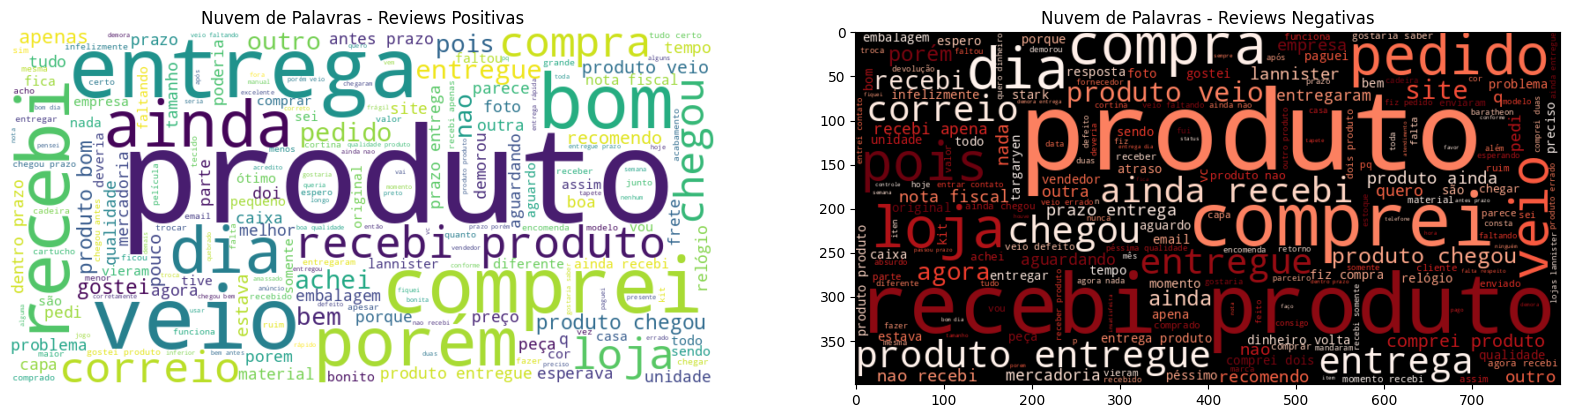

In [ ]:
# @title 📊 Nuvens de Palavras das Reviews Positivas e Negativas

# Função para limpar e extrair palavras
def get_words(text_series):
    all_words = []
    for text in text_series:
        # Limpar o texto
        text = str(text).lower()
        text = re.sub(r'[^\w\s]', '', text) # Remove pontuação
        text = re.sub(r'\d+', '', text) # Remove números
        text = re.sub(r'\s+', ' ', text) # Normaliza espaços
        # Dividir em palavras e remover stopwords
        words = text.split()
        words = [word for word in words if word not in stop_words_portugues]
        all_words.extend(words)
    return all_words

# Separar reviews positivas e negativas
positive_reviews = reviews_df[reviews_df["sentiment"] == 1]["review_comment_message"]
negative_reviews = reviews_df[reviews_df["sentiment"] == 0]["review_comment_message"]

# Limpar os textos
positive_words = get_words(positive_reviews)
negative_words = get_words(negative_reviews)

# Criar strings com as palavras limpas
positive_text = " ".join(positive_words)
negative_text = " ".join(negative_words)

# Generate word cloud for positive reviews
wordcloud_positive = WordCloud(width=800, height=400, background_color="white").generate(positive_text)

# Generate word cloud for negative reviews
wordcloud_negative = WordCloud(width=800, height=400, background_color="black", colormap="Reds").generate(negative_text)

# Plot the word clouds
plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.title("Nuvem de Palavras - Reviews Positivas")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.title("Nuvem de Palavras - Reviews Negativas")
plt.savefig("wordclouds.png")
print("Nuvens de palavras geradas e salvas como wordclouds.png")

In [ ]:
# @title 📊 Nuvens de Palavras das Reviews Positivas e Negativas - bigramas e trigramas

def get_words(text_series, ngram=1):
    all_words = []
    for text in text_series:
        # Limpar o texto
        text = str(text).lower()
        text = re.sub(r'[^\w\s]', '', text) # Remove pontuação
        text = re.sub(r'\d+', '', text) # Remove números
        text = re.sub(r'\s+', ' ', text) # Normaliza espaços

        # Dividir em palavras e remover stopwords
        words = text.split()
        words = [word for word in words if word not in stop_words_portugues]

        # Criar n-grams
        if ngram > 0:
            words = [' '.join(gram) for gram in ngrams(words, ngram)]

        all_words.extend(words)
    return all_words

# Separar reviews positivas e negativas
positive_reviews = reviews_df[reviews_df["sentiment"] == 1]["review_comment_message"]
negative_reviews = reviews_df[reviews_df["sentiment"] == 0]["review_comment_message"]

# Criar strings para diferentes tipos de n-grams
# 1. Palavras simples
positive_words_1 = get_words(positive_reviews, 1)
negative_words_1 = get_words(negative_reviews, 1)

# 2. Bigrams (palavras que aparecem juntas)
positive_words_2 = get_words(positive_reviews, 2)
negative_words_2 = get_words(negative_reviews, 2)

# 3. Trigrams (três palavras juntas)
positive_words_3 = get_words(positive_reviews, 3)
negative_words_3 = get_words(negative_reviews, 3)

# Criar strings com as palavras/n-grams
positive_text_1 = " ".join(positive_words_1)
negative_text_1 = " ".join(negative_words_1)
positive_text_2 = " ".join(positive_words_2)
negative_text_2 = " ".join(negative_words_2)
positive_text_3 = " ".join(positive_words_3)
negative_text_3 = " ".join(negative_words_3)

# Configurar o estilo do matplotlib
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [20, 15]

# Criar figura com 3x2 subplots
fig, axes = plt.subplots(3, 2, figsize=(20, 15))

# 1ª linha - Palavras simples
wordcloud_positive_1 = WordCloud(width=800, height=400, background_color="white").generate(positive_text_1)
axes[0,0].imshow(wordcloud_positive_1, interpolation='bilinear')
axes[0,0].set_title("Palavras Simples - Reviews Positivas")
axes[0,0].axis("off")

wordcloud_negative_1 = WordCloud(width=800, height=400, background_color="black", colormap="Reds").generate(negative_text_1)
axes[0,1].imshow(wordcloud_negative_1, interpolation='bilinear')
axes[0,1].set_title("Palavras Simples - Reviews Negativas")
axes[0,1].axis("off")

# 2ª linha - Bigrams
wordcloud_positive_2 = WordCloud(width=800, height=400, background_color="white").generate(positive_text_2)
axes[1,0].imshow(wordcloud_positive_2, interpolation='bilinear')
axes[1,0].set_title("Bigrams - Reviews Positivas")
axes[1,0].axis("off")

wordcloud_negative_2 = WordCloud(width=800, height=400, background_color="black", colormap="Reds").generate(negative_text_2)
axes[1,1].imshow(wordcloud_negative_2, interpolation='bilinear')
axes[1,1].set_title("Bigrams - Reviews Negativas")
axes[1,1].axis("off")

# 3ª linha - Trigrams
wordcloud_positive_3 = WordCloud(width=800, height=400, background_color="white").generate(positive_text_3)
axes[2,0].imshow(wordcloud_positive_3, interpolation='bilinear')
axes[2,0].set_title("Trigrams - Reviews Positivas")
axes[2,0].axis("off")

wordcloud_negative_3 = WordCloud(width=800, height=400, background_color="black", colormap="Reds").generate(negative_text_3)
axes[2,1].imshow(wordcloud_negative_3, interpolation='bilinear')
axes[2,1].set_title("Trigrams - Reviews Negativas")
axes[2,1].axis("off")

plt.tight_layout()
plt.savefig("wordclouds_ngrams.png")
print("Nuvens de palavras geradas e salvas como wordclouds_ngrams.png")

Output hidden; open in https://colab.research.google.com to view.

## Relatório Final

### 1. Introdução

Este relatório tem como objetivo detalhar o processo de análise e classificação de sentimentos em avaliações de produtos, utilizando técnicas de processamento de linguagem natural (PNL) e aprendizado de máquina. O foco principal será identificar se uma avaliação é positiva ou negativa, bem como extrair as razões subjacentes a esses sentimentos.

### 2. Análise de Dados

#### 2.1. Carregamento e Exploração Inicial

O conjunto de dados utilizado é o `olist_order_reviews_dataset.csv`. Uma análise inicial revelou as seguintes colunas:

-   `review_id`: Identificador único da avaliação.
-   `order_id`: Identificador do pedido.
-   `review_score`: Nota atribuída pelo cliente (1 a 5).
-   `review_comment_title`: Título da avaliação (opcional).
-   `review_comment_message`: Texto da avaliação (opcional).
-   `review_creation_date`: Data de criação da avaliação.
-   `review_answer_date`: Data da resposta à avaliação.

Foi observado que a coluna `review_comment_message` possui valores nulos, o que é esperado, pois nem todas as avaliações contêm um comentário textual. A distribuição das notas (`review_score`) mostrou uma predominância de avaliações positivas (notas 4 e 5).

#### 2.2. Pré-processamento e Criação da Variável Alvo

Para a tarefa de classificação, a variável alvo `sentiment` foi criada a partir da `review_score` da seguinte forma:

-   **Positivo (1):** `review_score` igual a 4 ou 5.
-   **Negativo (0):** `review_mapper` igual a 1, 2 ou 3.

Essa abordagem foi escolhida para simplificar a classificação binária, focando na satisfação geral do cliente. As linhas sem `review_comment_message` foram removidas, pois o texto é fundamental para a análise de sentimento. Os dados processados foram salvos em `reviews_com_sentimento.csv`.

#### 2.3. Treinamento e Avaliação do Modelo

Um modelo de Regressão Logística foi treinado para classificar o sentimento das reviews. O texto das avaliações foi vetorizado usando `TfidfVectorizer` para converter as palavras em representações numéricas. O conjunto de dados foi dividido em --------------------------------------------------------------------------------

## Início da execução

O objetivo é analisar o sentimento de reviews de produtos e extrair as razões por trás das classificações. Para isso, o agente irá:

1.  **Analisar os dados:** Carregar e explorar o conjunto de dados de reviews, verificando a distribuição das notas e a presença de dados ausentes.
2.  **Preparar os dados:** Criar a variável alvo (sentimento) a partir das notas das avaliações e pré-processar o texto das reviews.
3.  **Desenvolver o modelo:** Treinar um modelo de classificação de sentimento (Regressão Logística com TF-IDF).
4.  **Avaliar o modelo:** Avaliar o desempenho do modelo usando métricas como acurácia, precisão, recall e F1-score.
5.  **Extrair razões:** Identificar as palavras-chave mais relevantes para cada classe de sentimento (positivo/negativo).

Vamos começar!






## 5. Análise e Aplicação das Razões Extraídas

As palavras-chave extraídas do modelo de Regressão Logística são mais do que apenas uma lista de termos; elas representam os principais fatores que influenciam a percepção dos clientes. A seguir, detalhamos como interpretar e aplicar esses insights.

### 5.1. Interpretando as Razões

**Razões Positivas:**

As palavras como **"antes"**, **"rápido"**, **"excelente"**, **"parabéns"**, **"perfeito"**, **"amei"** e **"adorei"** estão fortemente ligadas à **experiência de compra e entrega**. Isso sugere que a eficiência logística e um serviço que supera as expectativas (entrega antes do prazo) são grandes impulsionadores de satisfação.

Termos como **"lindo"** e **"ótimo"** estão mais relacionados à **qualidade e estética do produto** em si. A palavra **"testei"** indica que o cliente usou o produto e aprovou seu funcionamento, o que é um feedback valioso sobre a funcionalidade.

**Razões Negativas:**

A palavra **"não"** (e sua variação "nao") é a mais influente para críticas negativas. Isso indica a negação de uma expectativa: "*não* recebi", "*não* funcionou", "*não* é como na foto". É um indicador genérico, mas poderoso, de problemas.

Termos como **"péssima"**, **"ruim"**, **"inferior"** e **"diferente"** apontam diretamente para a **má qualidade ou propaganda enganosa do produto**. A palavra **"diferente"** é particularmente interessante, pois sugere que o produto recebido não corresponde à descrição ou às fotos do site.

Palavras como **"demora"**, **"aguardando"** e **"atraso"** (que pode ser inferida de "demora") são críticas claras ao **processo de entrega**, mostrando que a logística é um ponto crítico tanto para a satisfação quanto para a insatisfação.

### 5.2. Aplicações Práticas

Com base nessa análise, as equipes de uma empresa de e-commerce podem tomar ações direcionadas:

*   **Equipe de Marketing e Vendas:**
    *   **Realçar pontos fortes:** Utilizar os elogios sobre a entrega rápida como um diferencial competitivo nas campanhas de marketing ("Receba antes do prazo!").
    *   **Ajustar descrições:** Investigar as reviews com a palavra "diferente" para garantir que as descrições e fotos dos produtos sejam precisas e realistas, evitando frustrações.

*   **Equipe de Logística:**
    *   **Otimizar a entrega:** Monitorar as menções a "demora" e "atraso" para identificar gargalos no processo de entrega e tomar medidas corretivas.
    *   **Reconhecer o bom trabalho:** A alta frequência de elogios à entrega rápida pode ser usada para validar e reforçar as estratégias logísticas atuais que estão funcionando bem.

*   **Equipe de Produto e Qualidade:**
    *   **Identificar produtos problemáticos:** As palavras "péssima", "ruim" e "inferior" podem ser usadas para filtrar e identificar rapidamente produtos com problemas de qualidade, permitindo uma ação rápida (como a revisão do lote ou a troca de fornecedor).
    *   **Validar a qualidade:** Elogios como "excelente" e "perfeito" validam a qualidade dos produtos e podem ser usados como depoimentos.

*   **Equipe de Atendimento ao Cliente:**
    *   **Priorizar tickets:** As reviews negativas podem ser automaticamente categorizadas e priorizadas com base na presença de palavras-chave críticas, permitindo que a equipe de suporte atue de forma proativa para resolver os problemas mais urgentes.
    *   **Entender a causa raiz:** A análise das palavras-chave ajuda a entender a causa raiz da insatisfação do cliente antes mesmo do primeiro contato, tornando o atendimento mais eficiente.

Em resumo, a extração estruturada de razões transforma o feedback do cliente de um amontoado de texto não estruturado em uma fonte de inteligência de negócios acionável, permitindo melhorias contínuas em todas as áreas da operação de e-commerce.





## 6. Refinando o Modelo com as Razões Extraídas

A integração das razões extraídas no ciclo de vida do modelo de machine learning é uma estratégia poderosa para aprimorar continuamente sua performance e relevância. Este processo, muitas vezes chamado de "human-in-the-loop" ou "active learning", permite que o conhecimento gerado pelo próprio modelo seja usado para refinar o conjunto de dados e a própria arquitetura do modelo. A seguir, detalhamos algumas abordagens para realizar esse refinamento.

### 6.1. Aprimoramento do Conjunto de Dados com Rótulos Granulares

Uma das abordagens mais eficazes é enriquecer o conjunto de dados de treinamento com rótulos mais granulares. Em vez de apenas classificar uma review como "positiva" ou "negativa", podemos adicionar sub-categorias baseadas nas razões extraídas.

**Exemplo de implementação:**

1.  **Criação de um Novo Esquema de Rotulação:**
    *   **Positivo - Entrega:** Reviews que contêm palavras como "antes", "rápido".
    *   **Positivo - Qualidade do Produto:** Reviews com "excelente", "perfeito", "ótimo".
    *   **Negativo - Entrega:** Reviews com "demora", "atraso", "não recebi".
    *   **Negativo - Qualidade do Produto:** Reviews com "péssima", "ruim", "inferior", "diferente".

2.  **Rotulação Assistida por Modelo (Active Learning):**
    *   Podemos usar o modelo atual para pré-rotular as reviews com essas novas categorias. Por exemplo, se uma review é classificada como negativa e contém a palavra "demora", ela pode ser pré-rotulada como "Negativo - Entrega".
    *   **Anotadores humanos** então revisam essas pré-rotulações, corrigindo-as quando necessário. Isso é muito mais rápido e escalável do que rotular tudo do zero.

3.  **Re-treinamento do Modelo:**
    *   Com este novo conjunto de dados, mais rico e detalhado, podemos treinar um modelo de classificação multi-classe. Este novo modelo não apenas dirá *se* uma review é positiva ou negativa, mas também *por quê*.

### 6.2. Engenharia de Features com Base nas Razões

As palavras-chave extraídas podem ser usadas para criar novas features (características) para o modelo, o que pode melhorar sua capacidade de discernir entre as classes.

**Exemplo de implementação:**

1.  **Criação de Features Binárias:**
    *   Para cada uma das principais razões (ex: "entrega_rapida", "produto_ruim"), podemos criar uma nova coluna no nosso dataset.
    *   Essa coluna terá o valor 1 se a review contiver a palavra-chave correspondente e 0 caso contrário.

2.  **Contagem de Palavras-Chave:**
    *   Podemos criar features que contam o número de palavras positivas e negativas em cada review, com base nas listas de razões que extraímos.

3.  **Integração com o Modelo:**
    *   Essas novas features são então adicionadas às features TF-IDF existentes, fornecendo ao modelo informações mais explícitas e direcionadas sobre o conteúdo da review.

### 6.3. Ponderação de Amostras (Sample Weighting)

Se identificarmos que o modelo tem dificuldade em classificar corretamente certos tipos de reviews (por exemplo, reviews negativas sobre a entrega), podemos dar mais peso a essas amostras durante o treinamento.

**Exemplo de implementação:**

1.  **Identificação de Amostras Difíceis:**
    *   Analisamos os erros de classificação do modelo atual. Se muitas reviews com a palavra "demora" estão sendo classificadas incorretamente, elas são candidatas a receberem um peso maior.

2.  **Aplicação de Pesos:**
    *   Na função de treinamento do modelo (por exemplo, `model.fit()`), a maioria das bibliotecas de machine learning permite passar um parâmetro `sample_weight`. As amostras que queremos que o modelo preste mais atenção recebem um peso maior.

### 6.4. Arquiteturas de Modelo Híbridas

Podemos evoluir de um modelo de Regressão Logística para arquiteturas mais complexas que podem capturar melhor as nuances da linguagem.

**Exemplo de implementação:**

1.  **Modelos Baseados em Regras + Machine Learning:**
    *   Podemos criar um sistema híbrido onde um conjunto de regras baseado nas palavras-chave mais fortes (ex: se a review contém "péssimo", classifique como negativa) atua em conjunto com o modelo de machine learning. Isso pode corrigir erros óbvios que o modelo estatístico possa cometer.

2.  **Redes Neurais com Camadas de Atenção:**
    *   Modelos mais avançados, como LSTMs ou Transformers (BERT), podem ser treinados. A vantagem desses modelos é que eles possuem mecanismos de "atenção" que aprendem automaticamente a dar mais importância a certas palavras no texto – essencialmente, eles aprendem as "razões" por conta própria, de uma maneira muito mais sofisticada.

### Conclusão do Refinamento

A integração das razões extraídas no processo de treinamento não é um passo único, mas um ciclo contínuo de melhoria. Ao usar os insights do próprio modelo para aprimorar os dados e a arquitetura, criamos um sistema de machine learning que se torna cada vez mais preciso e alinhado com as especificidades do domínio de negócio.